# SNS 서비스의 초기 안착과 재방문: 통합 분석 노트북

**팀 제출용 통합 정리본 · 전처리 원본 코드는 후속 추가 예정**

분석 질문은 **“첫 이용 이후 어떤 경험이 질문세트 재완료와 연관되는가?”**이다.
데이터 범위를 확인한 뒤 초기 반복 완료, 최근 선택받는 경험, 친구 관계를 살펴보고,
개선 실험과 조기 위험 예측으로 연결한다. 관찰된 연관성을 인과효과로 해석하지 않는다.

### 읽는 순서
0. 실행 환경과 전처리 연결 → 1. 데이터 범위와 유지율 → 2. 초기 반복 완료 →
3. 최근 선택받는 경험 → 4. 친구 관계 → 5. 개선 실험 → 6. 예측모델 → 7. 결론 → 부록

### 분석 기준을 합치지 않은 이유
원본별 정의를 보존하라는 팀의 결정에 따라 아래 기준을 유지했다. **서로 다른 D7/D14 수치를 직접 합산하지 않는다.**

| 분석 | 기준 시점 및 시간 | 완료 대리 시각 | 결과변수 |
|---|---|---|---|
| 초기 반복 완료(팀원) | 학교 40명·친구 4명 충족 및 가입 이후, KST | F 상태 세트에 연결된 `answer_updated_at` 최댓값; 오픈 이전 답장 포함 세트 제외 | 기준 시점 이후 D1~D15의 각 24시간 재완료 |
| 핑·예측모델 | 첫 완료 기준, UTC | F 상태 세트의 발신 투표 `created_at` 최댓값 | UTC 달력 날짜의 D7 또는 D14 하루 재완료 |
| 가입 초기 친구(팀원) | 가입+24시간과 첫 완료 중 늦은 시각, KST | 팀원 완료 대리 시각 | 해당 기준 이후 D1~D15 각 24시간 재완료 |

`answer_updated_at`은 답장 갱신 시각이므로 실제 질문 완료 시각과 차이가 있을 수 있다.
친구 수는 제공된 친구 이력/수락 기록으로 추정하며, 삭제된 관계나 상태 변경 이력을 완전히 복원하지 못할 수 있다.

**실행 확인:** 기존 BigQuery 데이터와 로컬 프로젝트 환경에서 코드 셀 170개를 순서대로 실행해 오류 없이 완료했다. 집계표와 차트를 저장했으며 개별 원본 행은 포함하지 않았다.

**모델링 흐름 보완:** D14 예측 한계와 D7·D14 연관성 검정을 복원했다. 기존 170개 셀 전체 실행 결과를 보존하고, 추가 검정 1개 셀은 저장된 교차표로 별도 실행하여 확인했다.

## 0. 실행 환경과 전처리 연결

VS Code 또는 Jupyter에서 이 `.ipynb` 파일을 열고, 프로젝트의 Python 환경을 커널로 선택하여
처음부터 순서대로 실행한다. 아래에서 불러오는 라이브러리가 해당 환경에 설치되어 있어야 한다.
검증에 사용한 라이브러리 버전은 노트북 마지막 표에서 확인할 수 있다.

BigQuery는 실행 환경에 설정된 기본 Google 인증을 사용한다. 해당 계정에는 데이터셋의 읽기 권한과
쿼리 실행 권한이 필요하다. 기존 분석에 사용한 환경이라면 기존 인증 설정을 그대로 사용한다.
원본 데이터와 인증키는 이 노트북에 포함하지 않는다. 프로젝트·데이터셋을 복제했다면 다음 설정을 바꾼다.
한글 차트는 실행 환경에 설치된 나눔고딕·맑은 고딕·AppleGothic 중 사용 가능한 글꼴을 선택한다.

In [1]:
# 데이터 소유 프로젝트와 쿼리 비용 청구 프로젝트가 같으면 동일하게 둔다.
PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"
BILLING_PROJECT_ID = PROJECT_ID
TEAM_OBSERVATION_END = "2024-05-07 20:29:07+09:00"  # 팀원 원본의 관찰 종료
TARGET_SCHOOL_IDS = [271, 352, 369, 1478, 1719, 4426, 4516, 5372, 5491, 5520]

In [6]:
import json
from numbers import Number
import pymysql
from dotenv import load_dotenv
import os
import ast
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
from matplotlib import font_manager
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest
from IPython.display import display
from google.cloud import bigquery
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_recall_curve, precision_score, recall_score, f1_score)

font_names = {f.name for f in font_manager.fontManager.ttflist}
for font_name in ["NanumGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]:
    if font_name in font_names:
        plt.rcParams["font.family"] = [font_name, "DejaVu Sans"]
        break
plt.rcParams["axes.unicode_minus"] = False
client = bigquery.Client(project=BILLING_PROJECT_ID)
print("공통 환경 준비 완료")

공통 환경 준비 완료


# 0-1. 원천 전처리

## accounts_attendance

In [ ]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [ ]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_attendance`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

df.head()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,attendance_date_list,user_id
0,7923,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",1355335
1,38921,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",892265
2,777,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",913054
3,6557,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",947077
4,2534,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",1233366


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 349637 entries, 0 to 349636
Data columns (total 3 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   id                    349637 non-null  Int64
 1   attendance_date_list  349637 non-null  str  
 2   user_id               349637 non-null  Int64
dtypes: Int64(2), str(1)
memory usage: 38.4 MB


### 데이터 타입 등 정보 확인
- 결측값 확인 안됨
- attendance_date_list str 타입.

In [ ]:
print(df.duplicated().sum())
df['user_id'].duplicated().sum()

0


np.int64(0)

### 중복값 확인
- 전체 중복값 0
- 유저아이디 기준 중복값 0

### 특이값 확인

In [ ]:
df[df['attendance_date_list'] == '[]']

,id,attendance_date_list,user_id
328692,20,[],1484400
328693,243,[],1284925
328694,312,[],1451267
328695,339,[],1483247
328696,375,[],1173480
...,...,...,...
349632,360487,[],1162275
349633,360491,[],935331
349634,360497,[],1127910
349635,360498,[],851491


In [ ]:
# str형태의 데이터를 리스트로 변환

df['attendance_date_list'] = (
    df['attendance_date_list']
    .apply(ast.literal_eval)
)

In [ ]:
# 리스트형식 날짜형으로 변환 후 첫날 날짜와 마지막 날짜 확인 

dates = pd.to_datetime(
    df['attendance_date_list'].explode(),
    errors='coerce'
)

dates.agg(['min', 'max'])

min   2023-05-27
max   2024-05-09
Name: attendance_date_list, dtype: datetime64[us]

In [ ]:
# 가입일자 확인용 유저 테이블 호출
sql = f"""
    SELECT id,
        created_at 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
"""

# 판다스 데이터프레임으로 변환
df1 = client.query(sql).to_dataframe()

df1.head()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,created_at
0,831956,2023-03-29 03:44:14.047130+00:00
1,831962,2023-03-29 05:18:56.162368+00:00
2,832151,2023-03-29 12:56:34.989468+00:00
3,832340,2023-03-29 12:56:35.020790+00:00
4,832520,2023-03-29 12:56:35.049311+00:00


In [ ]:
# 출석 테이블에 존재하는 유저를 변수에 지정 > 유저 테이블에서 해당 유저 필터링

check_id = df['user_id']

check_df = df1[~(df1['id'].isin(check_id))]
print(f"출석 테이블에 존재하지 않는 유저 : {check_df.shape[0]}명")
print(f"출석 테이블에 존재하지 않는 유저의 가장 빠른 가입일 : {check_df['created_at'].min()}")
print(f"출석 테이블에 존재하지 않는 유저의 가장 늦은 가입일 : {check_df['created_at'].max()}")

# 빈 리스트의 값을 가진 유저를 변수에 지정 > 유저 테이블에서 해당 유저 필터링

check_id1 = df[df['attendance_date_list'].apply(len) == 0]['user_id']

check_df1 = df1[df1['id'].isin(check_id1)]
print(f"출석 테이블의 빈 리스트 값을 가진 유저 : {check_df1.shape[0]}명")
print(f"빈 리스트 값을 가진 유저의 가장 빠른 가입일 : {check_df1['created_at'].min()}")
print(f"빈 리스트 값을 가진 유저의 가장 늦은 가입일 :{check_df1['created_at'].max()}")


출석 테이블에 존재하지 않는 유저 : 327448명
출석 테이블에 존재하지 않는 유저의 가장 빠른 가입일 : 2023-03-29 03:44:14.047130+00:00
출석 테이블에 존재하지 않는 유저의 가장 늦은 가입일 : 2024-05-09 08:31:17.710824+00:00
출석 테이블의 빈 리스트 값을 가진 유저 : 20945명
빈 리스트 값을 가진 유저의 가장 빠른 가입일 : 2023-03-31 16:55:28.590111+00:00
빈 리스트 값을 가진 유저의 가장 늦은 가입일 :2024-05-05 04:48:17.223190+00:00


### 출석 테이블 빈 리스트 값 확인 결과
- 출석 테이블의 349,637명 중 20,945명(약 6%)에서 attendance_date_list가 빈 리스트([])로 확인되었다.
- 빈 리스트 발생 원인을 확인하기 위해 와이어프레임과 출석 날짜 범위를 확인한 결과, 최초 출석 기록은 2023-05-27부터 존재하여 해당 시점 전후에 출석 기능이 도입된 것으로 추정하였다.
- 기능 도입 이후 가입자에게 출석 리스트가 자동 생성되는 구조인지 확인하였으나, 출석 테이블에 레코드가 없는 유저와 빈 리스트를 가진 유저의 가입 시점이 서로 겹치는 것으로 확인되었다. 따라서 단순히 기능 도입 이후 가입으로 인해 빈 리스트가 생성되는 구조라고 보기는 어려웠다.
- 추가로 와이어프레임을 확인한 결과, 출석 데이터는 홈 화면의 출석체크 버튼 상호작용을 통해 수집되는 데이터로 판단하였다. 따라서 해당 테이블은 전체 서비스 이용 로그를 나타내는 데이터가 아니며, 이 테이블만으로 서비스 전체의 활성일자·유지기간·리텐션을 측정하기에는 한계가 있다.

- **최종적으로 분석 목적상 실제 출석 이벤트가 존재하지 않는 빈 리스트 레코드는 활용 가치가 낮다고 판단하여 해당 내용을 공유했으며, 향후 세부 분석방향에 따라 데이터 분석 사용자가 해당 빈 리스트에 대해 추가로 처리 후 분석하는 방향으로 해당 데이터는 원본으로 유지한다.**

### 유저별 출석 날짜 중복 및 이상값 체크

In [ ]:
# 리스트 내 데이터 중복 여부 및 갯수

df['has_duplicate'] = df['attendance_date_list'].apply(
    lambda x: len(x) != len(set(x))
)
# 중복이 있었다면 True, 없다면 False로 값 입력

df[df['has_duplicate']]

df['has_duplicate'].sum()

np.int64(0)

In [ ]:
# 리스트의 값을 하나씩 형태나 비정상 데이터를 판단.

def find_invalid_dates(date_list):
    invalid = []

    for date in date_list:
        parsed = pd.to_datetime(
            date,
            format='%Y-%m-%d',
            errors='coerce'
        )

        if pd.isna(parsed):
            invalid.append(date)

    return invalid

In [ ]:
df['invalid_dates'] = (
    df['attendance_date_list']
    .apply(find_invalid_dates)
)

In [ ]:
(df['invalid_dates'].apply(len) > 0).sum()

np.int64(0)

- 리스트 안의 날짜는 모두 이상이 없는 것으로 확인되었으며, 중복도 존재하지 않기 때문에 다른 처리 없이 전처리를 마무리 함.

## accounts_blockrecord

In [ ]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [ ]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_blockrecord`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

df.head()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,reason,created_at,block_user_id,user_id
0,1,그냥...,2023-05-04 23:01:53+00:00,867483,878476
1,6,그냥...,2023-05-05 05:21:52+00:00,883696,883511
2,7,그냥...,2023-05-05 06:40:34+00:00,871349,870177
3,14,그냥...,2023-05-05 13:04:52+00:00,885794,879662
4,21,그냥...,2023-05-05 15:36:34+00:00,887434,881108


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19482 entries, 0 to 19481
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   id             19482 non-null  Int64              
 1   reason         19482 non-null  str                
 2   created_at     19482 non-null  datetime64[us, UTC]
 3   block_user_id  19482 non-null  Int64              
 4   user_id        19482 non-null  Int64              
dtypes: Int64(3), datetime64[us, UTC](1), str(1)
memory usage: 1.2 MB


- 다른 테이블도 created_at 날짜가 모두 동일한 UTC기준인지 확인 필요.

### 중복 체크
- 전체 중복 및 유저 아이디 기준 중복체크 결과.
유저단위의 테이블이 아닌 신고 개별 건수가 기록되는 테이블로 확인되어 유저 아이디 기준 중복은 따로 처리하지 않음.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['user_id'].duplicated().sum()

np.int64(6930)

### 결측 추가 체크
- info() 결과 null값은 확인되지 않았으며, 추가 체크에서도 결측으로 존재하는 값은 없다고 확인.

In [ ]:
df.isna().sum()

id               0
reason           0
created_at       0
block_user_id    0
user_id          0
dtype: int64

### reason 컬럼의 이상값 체크
- 사유가 이상한 데이터가 있는지 확인.
- 각 사유에 대한 비율 확인.

In [ ]:
df['reason'].value_counts()

reason
모르는 사람임               9640
친구 사이가 어색해짐           5805
사칭 계정                 2022
나랑 관련 없는 질문을 자꾸 보냄    1083
너무 많은 양의 질문을 보냄        919
기타                       7
그냥...                    6
Name: count, dtype: int64

### 신고한, 신고 당한 유저아이디 체크
- 각각의 유저아이디의 이상값을 확인한 결과.
모두 숫자형 데이터로 최소값과 최대값으로 범위를 확인하여 유저 테이블의 아이디와 비교해본 결과 특이값이 없다고 판단

In [ ]:
print(df['user_id'].min())
print(df['user_id'].max())

837615
1583612


In [ ]:
df[df['user_id'] == 1583612]

,id,reason,created_at,block_user_id,user_id
11356,25360,모르는 사람임,2024-05-05 11:06:31+00:00,1582869,1583612


In [ ]:
df['block_user_id'].nunique()

16240

In [ ]:
print(df['block_user_id'].min())
print(df['block_user_id'].max())

832740
1582869


- reason의 값이 이상하거나 수치적으로 문제가 있어보이지 않음.
- 신고 당한 유저의 고유 수 16,240명

In [ ]:
df[df['block_user_id'] == 1582869]

,id,reason,created_at,block_user_id,user_id
11356,25360,모르는 사람임,2024-05-05 11:06:31+00:00,1582869,1583612


In [ ]:
df['block_user_id'].value_counts().head(10)

block_user_id
898020     76
897681     25
877266     25
1380465    25
876207     24
1395312    24
1198628    21
1495281    19
1031842    18
1186363    17
Name: count, dtype: Int64

### 정리
- 모든 테이블의 날짜 데이터의 기준은 확인필요.
- 다른 전처리 작업은 없음. 그대로 유지하는 것을 결론으로 수정 및 처리 코딩없이 유지함.

### 추가 이상값 발견

In [ ]:
df.head()

,id,reason,created_at,block_user_id,user_id
0,1,그냥...,2023-05-04 23:01:53+00:00,867483,878476
1,6,그냥...,2023-05-05 05:21:52+00:00,883696,883511
2,7,그냥...,2023-05-05 06:40:34+00:00,871349,870177
3,14,그냥...,2023-05-05 13:04:52+00:00,885794,879662
4,21,그냥...,2023-05-05 15:36:34+00:00,887434,881108


In [ ]:
self_df = df[df['block_user_id'] == df['user_id']]
self_df

,id,reason,created_at,block_user_id,user_id
562,11423,나랑 관련 없는 질문을 자꾸 보냄,2023-05-20 12:54:32+00:00,1141855,1141855
596,12295,나랑 관련 없는 질문을 자꾸 보냄,2023-05-21 14:06:23+00:00,1423102,1423102
1611,10784,너무 많은 양의 질문을 보냄,2023-05-19 12:39:31+00:00,1365534,1365534
4174,6311,모르는 사람임,2023-05-13 16:18:21+00:00,877237,877237
4191,6347,모르는 사람임,2023-05-13 16:50:57+00:00,1095213,1095213
4895,8373,모르는 사람임,2023-05-16 09:12:16+00:00,1315402,1315402
5197,9208,모르는 사람임,2023-05-17 10:04:46+00:00,1347875,1347875
5826,10777,모르는 사람임,2023-05-19 12:23:58+00:00,1374659,1374659
6121,11506,모르는 사람임,2023-05-20 13:47:48+00:00,1013968,1013968
6262,12061,모르는 사람임,2023-05-21 08:38:00+00:00,1247150,1247150


In [ ]:
self_df.groupby('reason')['id'].count().reset_index()

,reason,id
0,나랑 관련 없는 질문을 자꾸 보냄,2
1,너무 많은 양의 질문을 보냄,1
2,모르는 사람임,9
3,사칭 계정,18
4,친구 사이가 어색해짐,3


In [ ]:
self_df['user_id'].nunique()

33

### 자기차단 이상 레코드 확인
- 자신이 자신을 차단한 데이터 존재 33건

- 23년 5월에만 해당 문제 발생.
- 신고 사유 사칭 의심이 다수 발견.

accounts_blockrecord에서 차단 수행자와 차단 대상이 동일한 (user_id = block_user_id) 사용자 33명이 확인되었으며, 해당 기록은 2023년 5월에만 존재하였다. 이 중 사칭 계정 18건, 모르는 사람임 9건으로 두 사유가 전체의 약 81.8%를 차지하였다. 정상적인 서비스 이용 흐름에서는 자기 자신을 차단하는 행위가 발생하기 어렵기 때문에 비정상 레코드일 가능성이 있다. 특정 화면에서 자기 계정이 타인처럼 노출되었거나 차단 정보 저장 과정에서 오류가 발생했을 가능성을 고려할 수 있으나, 해당 기간의 행동 로그가 존재하지 않아 정확한 원인은 확인할 수 없다. 

따라서 해당 데이터의 수가 33건정도로 소수이고, 23년 5월에 일시적으로 발생한 문제라는 점과 명확한 원인을 확인하기에는 데이터의 한계가 있으며, 서비스 이용간 자신이 자신을 차단하는 일은 일반적이지 않다는 사유로 해당 데이터에서 제거한다. 

In [ ]:
# 자기 자신을 차단한 이상 레코드 수 확인
check_sql = f"""
SELECT COUNT(*) AS cnt
FROM `{PROJECT_ID}.{DATA_SET}.accounts_blockrecord`
WHERE user_id = block_user_id
"""

check_df = client.query(check_sql).to_dataframe()

delete_count = check_df.loc[0, 'cnt']

print(f"삭제 예정 행 수: {delete_count}")

# 만약에 삭제 할 행 수가 같으면 삭제
# 만약 수가 같지않으면 경고.

EXPECTED_COUNT = 33

if delete_count == EXPECTED_COUNT:

    delete_sql = f"""
    DELETE FROM `{PROJECT_ID}.{DATA_SET}.accounts_blockrecord`
    WHERE user_id = block_user_id
    """

    query_job = client.query(delete_sql)
    query_job.result()

    print(f"삭제 완료: {query_job.num_dml_affected_rows}건")

else:
    print(
        f"⚠️ 삭제 중단: 예상 {EXPECTED_COUNT}건과 "
        f"실제 {delete_count}건이 일치하지 않습니다."
    )

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


삭제 예정 행 수: 33
삭제 완료: 33건


## accounts_friendrequest

In [7]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [8]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_friendrequest`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

df.head()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,status,created_at,updated_at,receive_user_id,send_user_id
0,683526,P,2023-05-03 21:21:32+00:00,2023-05-03 21:21:32+00:00,877244,878039
1,10350969,P,2023-05-16 04:20:38+00:00,2023-05-16 04:20:38+00:00,1038688,1067245
2,12096197,P,2023-05-18 08:52:11+00:00,2023-05-18 08:52:11+00:00,1317934,1340090
3,13496515,P,2023-05-21 00:42:56+00:00,2023-05-21 00:42:56+00:00,1089772,1025477
4,4055293,P,2023-05-09 12:10:51+00:00,2023-05-09 12:10:51+00:00,983472,1034012


- 신청시 created_at이 생성되고 동일한 값으로 updated_at이 생성되며, 상태(status)값이 업데이트 되는 순간 updated_at이 수정되는 것으로 보임.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17147175 entries, 0 to 17147174
Data columns (total 6 columns):
 #   Column           Dtype         
---  ------           -----         
 0   id               int64         
 1   status           str           
 2   created_at       datetime64[us]
 3   updated_at       datetime64[us]
 4   receive_user_id  int64         
 5   send_user_id     int64         
dtypes: datetime64[us](2), int64(3), str(1)
memory usage: 801.3 MB


- 총 17,147,175 행 확인.
- 날짜형태도 결측없이 존재하는 것으로 특이값은 없다고 판단.

### 결측 체크
- 결측 없음.

In [ ]:
df.isna().sum()

id                 0
status             0
created_at         0
updated_at         0
receive_user_id    0
send_user_id       0
dtype: int64

### 중복 체크
- 중복 없음.
- 유저아이디 기준 친구 요청 및 요청 수신 유저 모두 요청 건수에 따라서 중복되는 결과 확인. 따로 처리하지 않음.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['send_user_id'].nunique()

649072

### 컬럼별 특이값 확인

In [ ]:
df.columns

Index(['id', 'status', 'created_at', 'updated_at', 'receive_user_id',
       'send_user_id'],
      dtype='str')

In [ ]:
df['status'].value_counts()

status
A    12878407
P     3938608
R      330160
Name: count, dtype: int64

- A (수락), P (대기), R (거절) 범주 이상없음.

In [ ]:
print(df['created_at'].min())
print(df['created_at'].max())

2023-04-17 18:29:11
2024-05-09 09:21:47


In [ ]:
print(f"보낸 유저 아이디 중 가장 낮은 유저 아이디 : {df['send_user_id'].min()}")
print(f"보낸 유저 아이디 중 가장 큰 유저 아이디 : {df['send_user_id'].max()}")

print(f"수신 유저 아이디 중 가장 낮은 유저 아이디 : {df['receive_user_id'].min()}")
print(f"수신 유저 아이디 중 가장 큰 유저 아이디 : {df['receive_user_id'].max()}")

보낸 유저 아이디 중 가장 낮은 유저 아이디 : 831962
보낸 유저 아이디 중 가장 큰 유저 아이디 : 1583732
수신 유저 아이디 중 가장 낮은 유저 아이디 : 831962
수신 유저 아이디 중 가장 큰 유저 아이디 : 1583731


- 숫자형 아이디의 범위가 모두 유저 테이블에 부합한다고 판단. 특이값 없음.

### 정리
- 모든 테이블의 날짜 데이터의 기준은 확인필요.
- 다른 전처리 작업은 없음. 그대로 유지하는 것을 결론으로 수정 및 처리 코딩없이 유지함.

### 친구 관계 형성 테이블 제작
* 친구 요청 기록과 요청 상태 등을 파악하여, 친구 관계 형성을 트래킹 할 수 있는 데이터 제작
* 'A' 상태값을 가진 행이 관계가 형성되었다고 판단.
* 관계 형성 시기를 나타내야 하므로, updated_at를 활용

In [ ]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT send_user_id, receive_user_id, updated_at
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_friendrequest`
    WHERE status = 'A'
    ORDER BY updated_at ASC
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

df.head()

,send_user_id,receive_user_id,updated_at
0,837521,832340,2023-04-18 19:28:41+00:00
1,837532,837530,2023-04-19 06:06:31+00:00
2,837543,837531,2023-04-19 06:08:19+00:00
3,837538,837531,2023-04-19 06:08:20+00:00
4,837537,837531,2023-04-19 06:08:21+00:00


In [ ]:
df.shape

(12878407, 3)

### 셀프 친구 관계 확인

In [ ]:
self_friendships = df[
    df['send_user_id'].eq(
        df['receive_user_id']
    )
].copy()

print(
    f'자기 자신에게 친구 신청한 기록 수: '
    f'{len(self_friendships):,}건'
)

display(self_friendships.head(20))

자기 자신에게 친구 신청한 기록 수: 0건


,send_user_id,receive_user_id,updated_at


### 중복 친구 관계 확인

In [ ]:
friendship_check = df.copy()

friendship_check['user_id_1'] = friendship_check[
    ['send_user_id', 'receive_user_id']
].min(axis=1)

friendship_check['user_id_2'] = friendship_check[
    ['send_user_id', 'receive_user_id']
].max(axis=1)

In [ ]:
friendship_duplicate_summary = (
    friendship_check
    .groupby(
        ['user_id_1', 'user_id_2'],
        as_index=False,
    )
    .agg(
        수락기록수=('updated_at', 'size'),
        최초수락시각=('updated_at', 'min'),
        최종수락시각=('updated_at', 'max'),
    )
)

duplicate_friendships = (
    friendship_duplicate_summary[
        friendship_duplicate_summary['수락기록수'].gt(1)
    ]
    .sort_values(
        '수락기록수',
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    f'수락 기록이 2건 이상인 친구 관계: '
    f'{len(duplicate_friendships):,}개'
)

display(duplicate_friendships.head(20))

수락 기록이 2건 이상인 친구 관계: 2,960개


,user_id_1,user_id_2,수락기록수,최초수락시각,최종수락시각
0,1264506,1314988,3,2023-05-18 14:08:37+00:00,2023-05-19 15:50:05+00:00
1,1356713,1357864,3,2023-05-18 14:06:26+00:00,2023-05-19 02:38:02+00:00
2,838452,1138849,2,2023-05-18 21:49:54+00:00,2023-05-19 09:18:25+00:00
3,1231352,1340467,2,2023-05-20 15:09:48+00:00,2023-05-22 12:57:08+00:00
4,1230851,1270112,2,2023-05-19 11:19:40+00:00,2023-05-19 15:39:29+00:00
5,1230882,1311674,2,2023-05-18 14:41:50+00:00,2023-09-18 06:32:33+00:00
6,1230896,1239858,2,2023-05-22 13:15:14+00:00,2023-06-03 03:30:19+00:00
7,1230941,1306131,2,2023-05-18 12:54:10+00:00,2023-05-19 13:16:52+00:00
8,1230955,1579196,2,2023-07-26 01:09:52+00:00,2023-07-26 01:09:55+00:00
9,1231088,1231865,2,2023-05-18 23:08:14+00:00,2023-05-19 01:36:57+00:00


In [ ]:
print(
    f'중복으로 판단되는 추가 기록 수: '
    f'{(duplicate_friendships["수락기록수"] - 1).sum():,}건'
)

중복으로 판단되는 추가 기록 수: 2,962건


In [ ]:
first_accepted_friendships = (
    friendship_check
    .sort_values(
        'updated_at',
        kind='stable',
    )
    .drop_duplicates(
        subset=['user_id_1', 'user_id_2'],
        keep='first',
    )
    .reset_index(drop=True)
)

In [ ]:
print(f'중복 처리 전 기록 수: {len(df):,}건')
print(
    f'중복 처리 후 친구 관계 수: '
    f'{len(first_accepted_friendships):,}건'
)

print(
    '중복 처리 후 남은 중복 관계 수:',
    first_accepted_friendships[
        ['user_id_1', 'user_id_2']
    ].duplicated().sum(),
)

중복 처리 전 기록 수: 12,878,407건
중복 처리 후 친구 관계 수: 12,875,445건
중복 처리 후 남은 중복 관계 수: 0


In [ ]:
first_accepted_friendships

,send_user_id,receive_user_id,updated_at,user_id_1,user_id_2
0,837521,832340,2023-04-18 19:28:41+00:00,832340,837521
1,837532,837530,2023-04-19 06:06:31+00:00,837530,837532
2,837543,837531,2023-04-19 06:08:19+00:00,837531,837543
3,837538,837531,2023-04-19 06:08:20+00:00,837531,837538
4,837537,837531,2023-04-19 06:08:21+00:00,837531,837537
...,...,...,...,...,...
12875440,1110948,1197989,2024-05-09 05:21:40+00:00,1110948,1197989
12875441,1054750,1197989,2024-05-09 05:21:40+00:00,1054750,1197989
12875442,1583732,1583731,2024-05-09 07:25:52+00:00,1583731,1583732
12875443,1583732,1583730,2024-05-09 07:32:54+00:00,1583730,1583732


### 친구 관계 형성 확인

In [ ]:
# user_id_1 관점
user_1_events = (
    first_accepted_friendships[
        ['user_id_1', 'user_id_2', 'updated_at']
    ]
    .rename(
        columns={
            'user_id_1': 'user_id',
            'user_id_2': 'friend_user_id',
            'updated_at': 'friendship_at',
        }
    )
)

# user_id_2 관점
user_2_events = (
    first_accepted_friendships[
        ['user_id_1', 'user_id_2', 'updated_at']
    ]
    .rename(
        columns={
            'user_id_2': 'user_id',
            'user_id_1': 'friend_user_id',
            'updated_at': 'friendship_at',
        }
    )
)

In [ ]:
friend_count_log = pd.concat(
    [
        user_1_events,
        user_2_events,
    ],
    ignore_index=True,
)

friend_count_log = (
    friend_count_log
    .sort_values(
        [
            'user_id',
            'friendship_at',
            'friend_user_id',
        ]
    )
    .reset_index(drop=True)
)

In [ ]:
friend_count_log['friend_cnt_before'] = (
    friend_count_log
    .groupby('user_id')
    .cumcount()
)

friend_count_log['friend_cnt_after'] = (
    friend_count_log['friend_cnt_before'] + 1
)

In [ ]:
display(friend_count_log.head(20))

,user_id,friend_user_id,friendship_at,friend_cnt_before,friend_cnt_after
0,831962,1446852,2023-09-11 15:38:43+00:00,0,1
1,832151,841037,2023-04-22 06:02:44+00:00,0,1
2,832151,838785,2023-04-22 06:02:46+00:00,1,2
3,832151,837950,2023-04-22 06:02:48+00:00,2,3
4,832151,838541,2023-04-22 06:02:51+00:00,3,4
5,832151,837521,2023-04-22 06:02:53+00:00,4,5
6,832151,836498,2023-04-22 13:39:22+00:00,5,6
7,832151,840046,2023-04-23 08:57:27+00:00,6,7
8,832151,862823,2023-05-16 04:44:32+00:00,7,8
9,832340,837521,2023-04-18 19:28:41+00:00,0,1


In [ ]:
print(
    f'최초 친구 관계 수: '
    f'{len(first_accepted_friendships):,}개'
)

print(
    f'예상 로그 수: '
    f'{len(first_accepted_friendships) * 2:,}개'
)

print(
    f'실제 로그 수: '
    f'{len(friend_count_log):,}개'
)

최초 친구 관계 수: 12,875,445개
예상 로그 수: 25,750,890개
실제 로그 수: 25,750,890개


In [ ]:
friend_count_log[friend_count_log['user_id'] == 1446852]

,user_id,friend_user_id,friendship_at,friend_cnt_before,friend_cnt_after
22169057,1446852,838541,2023-06-20 12:17:20+00:00,0,1
22169058,1446852,849763,2023-06-20 12:17:33+00:00,1,2
22169059,1446852,1577131,2023-06-25 05:33:23+00:00,2,3
22169060,1446852,1578013,2023-07-11 04:50:46+00:00,3,4
22169061,1446852,836498,2023-07-11 07:54:35+00:00,4,5
22169062,1446852,1578661,2023-07-15 04:25:33+00:00,5,6
22169063,1446852,1579656,2023-08-08 12:28:04+00:00,6,7
22169064,1446852,1437875,2023-08-19 05:01:44+00:00,7,8
22169065,1446852,1577954,2023-08-19 15:46:10+00:00,8,9
22169066,1446852,1579542,2023-08-21 12:35:15+00:00,9,10


### 최종 테이블

In [ ]:
friend_count_log[['user_id', 'friend_user_id', 'friend_cnt_after', 'friendship_at']]

,user_id,friend_user_id,friend_cnt_after,friendship_at
0,831962,1446852,1,2023-09-11 15:38:43+00:00
1,832151,841037,1,2023-04-22 06:02:44+00:00
2,832151,838785,2,2023-04-22 06:02:46+00:00
3,832151,837950,3,2023-04-22 06:02:48+00:00
4,832151,838541,4,2023-04-22 06:02:51+00:00
...,...,...,...,...
25750885,1583730,1583732,1,2024-05-09 07:32:54+00:00
25750886,1583731,1583732,1,2024-05-09 07:25:52+00:00
25750887,1583731,1583673,2,2024-05-09 07:33:06+00:00
25750888,1583732,1583731,1,2024-05-09 07:25:52+00:00


### 테이블 생성

In [ ]:
table_id = (
    f'{PROJECT_ID}.{DATA_SET}.user_friend_count_history'
)

job_config = bigquery.LoadJobConfig(
    schema=[
        bigquery.SchemaField(
            'user_id',
            'INTEGER',
            mode='REQUIRED',
        ),
        bigquery.SchemaField(
            'friend_user_id',
            'INTEGER',
            mode='REQUIRED',
        ),
        bigquery.SchemaField(
            'friendship_at',
            'TIMESTAMP',
            mode='REQUIRED',
        ),
        bigquery.SchemaField(
            'friend_cnt_before',
            'INTEGER',
            mode='REQUIRED',
        ),
        bigquery.SchemaField(
            'friend_cnt_after',
            'INTEGER',
            mode='REQUIRED',
        ),
    ],
    write_disposition='WRITE_EMPTY',
)

In [ ]:
load_job = client.load_table_from_dataframe(
    friend_count_log[
        [
            'user_id',
            'friend_user_id',
            'friendship_at',
            'friend_cnt_before',
            'friend_cnt_after',
        ]
    ],
    table_id,
    job_config=job_config,
)

load_job.result()

destination_table = client.get_table(table_id)

print(
    f'{table_id}에 '
    f'{destination_table.num_rows:,}개 행 업로드 완료'
)

sns-analysis-prj.sns_analysis.user_friend_count_history에 25,750,890개 행 업로드 완료


## hackle_events

In [ ]:
load_dotenv()

conn = pymysql.connect(
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

print("DB 연결 성공!")

DB 연결 성공!


In [ ]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [ ]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.hackle_events`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

df.head()

C:\Users\kkw53\AppData\Local\Temp\ipykernel_11084\1316781957.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,event_id,event_datetime,event_key,session_id,id,item_name,page_name,friend_count,votes_count,heart_balance,question_id
0,00000533-3f1c-4b3b-81f1-0c8f35754b4e,2023-07-18 19:40:17,$session_start,4OzYh3seq3VKytpSn5pvQkZNQii1,00000533-3f1c-4b3b-81f1-0c8f35754b4e,,,NaN,NaN,NaN,NaN
1,00000716-27e9-4e72-a602-d0ce61784b06,2023-07-18 21:07:24,click_question_open,8QXy31PQxbW9qLzq0Y1dhR8Ypm52,00000716-27e9-4e72-a602-d0ce61784b06,,,64.0,436.0,4830.0,NaN
2,000007c8-68ce-40e6-9b1e-f0e34e8ff9cc,2023-08-06 20:18:03,click_bottom_navigation_profile,6bcea65d-9f40-46fc-888c-700fe707483f,000007c8-68ce-40e6-9b1e-f0e34e8ff9cc,,,26.0,174.0,4729.0,NaN
3,00000981-5e2a-4111-993e-4f1891ad9a53,2023-08-05 01:46:10,view_shop,XVYNT6zfhFWqIg9omwg2AHDjTLx2,00000981-5e2a-4111-993e-4f1891ad9a53,,,61.0,44.0,142.0,NaN
4,00000a7a-ba72-4332-b4a9-7910670aaeb2,2023-07-24 15:03:37,click_bottom_navigation_lab,XFB2SPiGfjbVhvJ3Q3DBsaT3m2B3,00000a7a-ba72-4332-b4a9-7910670aaeb2,,,119.0,545.0,3287.0,NaN


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11441319 entries, 0 to 11441318
Data columns (total 11 columns):
 #   Column          Dtype         
---  ------          -----         
 0   event_id        str           
 1   event_datetime  datetime64[us]
 2   event_key       str           
 3   session_id      str           
 4   id              str           
 5   item_name       str           
 6   page_name       str           
 7   friend_count    float64       
 8   votes_count     float64       
 9   heart_balance   float64       
 10  question_id     float64       
dtypes: datetime64[us](1), float64(4), str(6)
memory usage: 2.2 GB


### 중복 체크

In [ ]:
df.duplicated().sum()

np.int64(0)

- id(auto-increment)가 따로 없으므로 전체 중복만 확인하고 마무리

In [ ]:
df['session_id'].nunique()

253616

- 전체 중복은 없음.
- 행동 로그 단위의 테이블로 session_id는 중복이 있을 수 밖에 없다고 판단.
따라서, 중복 처리는 따로 진행하지 않는다.

### 이상치 체크

In [ ]:
pd.set_option('display.float_format', '{:,.2f}'.format)
df.describe()

,event_datetime,friend_count,votes_count,heart_balance,question_id
count,11441319,"10,688,763.00","10,686,765.00","10,712,676.00","449,484.00"
mean,2023-07-29 01:58:17.236437,54.34,257.27,"16,269.29","2,766.39"
min,2023-07-18 00:00:00,0.00,0.00,0.00,99.00
25%,2023-07-22 21:31:17,32.00,97.00,434.00,"1,393.00"
50%,2023-07-28 17:08:58,49.00,210.00,"1,249.00","2,569.00"
75%,2023-08-04 17:59:10,71.00,362.00,"3,188.00","4,459.00"
max,2023-08-10 23:59:59,"1,365.00","3,017.00","884,999,804.00","5,133.00"
std,NaN,33.51,218.07,"3,317,340.09","1,599.97"


- 유저 테이블에서 발견된 하트 이상치가 동일하게 확인됨 -> 유지하되 향후 포인트 히스토리 등의 데이터화 결합하여 사용시 값이 발생한 시점 등을 파악 후 조치
- 각 세션별 일부 높은 수치의 친구수와 질문수를 가진 세션이 존재 -> 해당 수치는 세션(유저)별 사용량을 나타내는 지표일 수 있으므로 유지

### 결측 체크

In [ ]:
df.head()

,event_id,event_datetime,event_key,session_id,id,item_name,page_name,friend_count,votes_count,heart_balance,question_id
0,00000533-3f1c-4b3b-81f1-0c8f35754b4e,2023-07-18 19:40:17,$session_start,4OzYh3seq3VKytpSn5pvQkZNQii1,00000533-3f1c-4b3b-81f1-0c8f35754b4e,,,NaN,NaN,NaN,NaN
1,00000716-27e9-4e72-a602-d0ce61784b06,2023-07-18 21:07:24,click_question_open,8QXy31PQxbW9qLzq0Y1dhR8Ypm52,00000716-27e9-4e72-a602-d0ce61784b06,,,64.0,436.0,4830.0,NaN
2,000007c8-68ce-40e6-9b1e-f0e34e8ff9cc,2023-08-06 20:18:03,click_bottom_navigation_profile,6bcea65d-9f40-46fc-888c-700fe707483f,000007c8-68ce-40e6-9b1e-f0e34e8ff9cc,,,26.0,174.0,4729.0,NaN
3,00000981-5e2a-4111-993e-4f1891ad9a53,2023-08-05 01:46:10,view_shop,XVYNT6zfhFWqIg9omwg2AHDjTLx2,00000981-5e2a-4111-993e-4f1891ad9a53,,,61.0,44.0,142.0,NaN
4,00000a7a-ba72-4332-b4a9-7910670aaeb2,2023-07-24 15:03:37,click_bottom_navigation_lab,XFB2SPiGfjbVhvJ3Q3DBsaT3m2B3,00000a7a-ba72-4332-b4a9-7910670aaeb2,,,119.0,545.0,3287.0,NaN


In [ ]:
df.isna().sum()

event_id                 0
event_datetime           0
event_key                0
session_id               0
id                       0
item_name                0
page_name                0
friend_count        752556
votes_count         754554
heart_balance       728643
question_id       10991835
dtype: int64

- 데이터 프레임상 item_name, page_name에서도 빈 문자열 확인 결측으로 집계되고 있지 않음.

### page_name 체크

In [ ]:
df['page_name'].unique()

<ArrowStringArray>
[       '',  'notice',    'home', 'profile',    '학교선택',    '학년선택',     '반선택',
    '번호인증',    '성별선택',   '아이디입력',    '프사설정',  'invite',    '이름입력']
Length: 13, dtype: str

In [ ]:
(df['page_name'] == '').sum()

np.int64(10652540)

In [ ]:
filter_event_key = df[df['page_name'] == '']['event_key'].unique()

In [ ]:
df[df['event_key'].isin(filter_event_key)]['page_name'].unique()

<ArrowStringArray>
['']
Length: 1, dtype: str

In [ ]:
df[~(df['event_key'].isin(filter_event_key))]['event_key'].unique()

<ArrowStringArray>
[ 'click_notice_detail',     'click_attendance',   'click_question_ask',
 'click_question_start',    'click_profile_ask',          'view_signup',
  'click_friend_invite',  'click_invite_friend',         'click_notice']
Length: 9, dtype: str

- 9개의 event_key를 제외한 다른 event_key는 모두 빈 문자열로 데이터가 들어가있으므로 해당 부분은 빈 문자열로 유지

### item_name

In [ ]:
df[df['event_key'] == "click_purchase"]['item_name'].unique()

<ArrowStringArray>
['777 하트', '무료충전소', '1000 하트', '200 하트', '4000 하트']
Length: 5, dtype: str

- item_name의 경우 빈 문자열 발생은 event_key가 "click_purchase"가 아닌 모든 경우 빈 문자열이 발생한다. 따라서 해당 내용도 빈 문자열로 유지한다.

### friend_count 체크

In [ ]:
df[df['friend_count'].isna()].shape

(752556, 11)

- friend_count가 결측인 데이터 752,556건 확인

In [ ]:
# 결측의 원인이 session_id인가?

users = df[df['friend_count'].isna()]['session_id'].unique()
users

<ArrowStringArray>
[        '4OzYh3seq3VKytpSn5pvQkZNQii1',
         'LztzUUFoRxdqTSPgQrX3MAAyNkM2',
         'NOdvth0cBJV15fIP2sXxMAMEUEr1',
         'qLdDlFGK9qObRuGXK20KAGbqzRZ2',
         'i6toBlZRPDNAnwhvkIWwD16Fcts1',
 '98078b29-9edc-4097-bb7a-500141473bb3',
         'ijJOxCkzhyZ0DJaQYq0JAbCnURO2',
         '3nBBDbvgWaNeqPvsE4YnCQT9ILt2',
 '841DDE93-BBF3-4DFE-8003-CE695AD696FF',
         'Smot2x4FSsNL1rXLWRGWCpbz2Hw2',
 ...
         'oYzJSxKWpfeMJ5Vfl8A81Abdb0J2',
         'WfAsiCiDb5UPKdvM5JwlFxmUNbG2',
         'rj9ILcLEjiS3XWEkkC9yXxhGPnR2',
 '5596edc7-6270-4c3c-ae4c-7385b66dffd2',
         'KehKcSS3HENKnyMgd9Ml76FQTZ13',
         'cK6MxakwE7fmYLNIhvqYnFpuQ6H3',
         'ALLToGjPIiNhvj2g3RDZNuayuYj1',
         'aoNxEWgG20Ry14fC6UP5u7qh9YX2',
 'dc217f9c-f03a-44c5-8647-ab27ed75b87f',
         'ydmCUtVhR7VcWUtjKZ3iHdLAHPz2']
Length: 167435, dtype: str

In [ ]:
# 특정 시기에 결측이 있는가?

print(df[df['friend_count'].isna()]['event_datetime'].min())
print(df[df['friend_count'].isna()]['event_datetime'].max())

2023-07-18 00:00:06
2023-08-10 23:59:57


- 해당데이터의 전체 기간에 해당하는 것으로 특정기간에 발생한 결측은 아닌 것으로 확인

In [ ]:
friend_check_event = df[df['friend_count'].isna()]['event_key'].unique()
friend_check_event

<ArrowStringArray>
[      '$session_start',         '$session_end',           'launch_app',
           'view_login',        'view_home_tap',          'view_signup',
               'button',     'view_profile_tap',  'view_friendplus_tap',
    'view_timeline_tap',   'view_questions_tap',  'click_question_open',
 'click_question_share',         'click_notice',  'click_notice_detail']
Length: 15, dtype: str

- friend_count가 결측인 이벤트를 확인해보니 15개의 이벤트가 확인됨.

In [ ]:
nnfriend_check_event = df[~(df['friend_count'].isna())]['event_key'].unique()
nnfriend_check_event

<ArrowStringArray>
[              'click_question_open',   'click_bottom_navigation_profile',
                         'view_shop',       'click_bottom_navigation_lab',
                        'launch_app', 'click_bottom_navigation_questions',
                      'view_lab_tap',                     'skip_question',
                'view_questions_tap',                 'view_timeline_tap',
  'click_bottom_navigation_timeline',                    '$session_start',
                      '$session_end',               'click_notice_detail',
          'click_random_ask_shuffle',                 'complete_question',
         'click_appbar_alarm_center',           'click_appbar_chat_rooms',
                  'view_profile_tap',         'click_timeline_chat_start',
                  'click_attendance',                'click_question_ask',
              'click_question_share',          'click_appbar_friend_plus',
              'click_appbar_setting',              'click_question_start',
      

### 결측 발생의 원인 탐색을 위한 가설 수립

- 특정 이벤트에서 결측이 발생했을 것이다.
- 특정 날짜에 서버 등의 오류로 인해 발생한 결측일 것이다.

위 가설을 기반으로 결측 원인을 확인하여 로그 데이터 적재 프로세스의 개선점을 찾거나, 결측을 처리할 방법을 정한다. 

### 이벤트 설명 + 이벤트별 결측데이터 체크

In [ ]:
# 이벤트 별 설명 추가

event_desc = {
    '$session_start': '세션 시작',
    '$session_end': '세션 종료',
    'button': '-',
    'click_appbar_alarm_center': '상단 appbar에서 알림 모양 클릭',
    'click_appbar_chat_rooms': '상단 appbar에서 메시지 모양 클릭',
    'click_appbar_friend_plus': '상단 appbar에서 친구 모양 클릭',
    'click_appbar_setting': '-',
    'click_attendance': '출석체크 클릭',
    'click_autoadd_contact': '친구 추천 탭 위의 연락처 자동 친구 추가하기 버튼 클릭',
    'click_bottom_navigation_lab': '하단 네비게이션에서 lab 클릭',
    'click_bottom_navigation_profile': '하단 네비게이션에서 프로필 클릭',
    'click_bottom_navigation_questions': '하단 네비게이션에서 질문 클릭',
    'click_bottom_navigation_timeline': '하단 네비게이션에서 타임라인 클릭',
    'click_community_chat': '채팅 클릭',
    'click_copy_profile_link_ask': 'ask에서 내 프로필 링크 복사하기 클릭',
    'click_copy_profile_link_profile': '본인 프로필 링크 복사하기 클릭',
    'click_friend_invite': '질문 대기상태에서 친구 초대하고 바로 받기 클릭',
    'click_invite_friend': 'ask에서 친구 초대하기 클릭',
    'click_notice': '알림 센터 클릭',
    'click_notice_detail': '알림 센터 디테일에서 특정 알림 클릭',
    'click_profile_ask': '친구 프로필에서 친구에게 글 남기기 버튼 클릭',
    'click_purchase': '구매할 하트 상품 클릭',
    'click_question_ask': '홈화면에서 ask 클릭',
    'click_question_open': '받은 질문을 열 때',
    'click_question_share': '받은 질문을 공유할 때',
    'click_question_start': '홈화면에서 질문 start 클릭',
    'click_random_ask_normal': '기존 타임라인에서 일반적인 ask 클릭',
    'click_random_ask_other': '기존 타임라인에서 다른 친구에게 글 남기기 클릭',
    'click_random_ask_shuffle': '기존 타임라인 상단 ask 랜덤 셔플 클릭',
    'click_timeline_chat_start': '기존 타임라인에서 채팅 클릭',
    'complete_purchase': '하트 구입 완료',
    'complete_question': '질문 완료',
    'complete_signup': '회원가입 완료',
    'launch_app': '앱 실행',
    'skip_question': '질문 스킵',
    'view_friendplus_tap': '친구 추천 화면 진입',
    'view_home_tap': '홈 진입',
    'view_lab_tap': '실험실 탭에 진입',
    'view_login': '로그인 페이지 진입',
    'view_profile_tap': '프로필 화면 진입',
    'view_questions_tap': '질문 화면 진입',
    'view_shop': '하트 충전소 진입',
    'view_signup': '회원가입 페이지 진입',
    'view_timeline_tap': '타임라인 화면 진입'
}

In [ ]:
# 결측 패턴을 확인할 컬럼
columns = [
    'friend_count',
    'votes_count',
    'heart_balance'
]

missing_by_event = {}

for col in columns:
    
    result = (
        df.groupby('event_key')
          .agg(
              total_count=(col, 'size'),
              missing_count=(col, lambda x: x.isna().sum()),
              non_missing_count=(col, lambda x: x.notna().sum())
          )
    )

    # 결측률 계산
    result['missing_rate'] = (
        result['missing_count']
        / result['total_count']
    )

    # 이벤트 설명 추가
    result['event_desc'] = result.index.map(event_desc)

    # 이벤트 설명을 첫 번째 컬럼으로 이동
    result.insert(
        0,
        'event_desc',
        result.pop('event_desc')
    )

    # 결측률 기준 정렬
    result = result.sort_values(
        'missing_rate',
        ascending=False
    )

    # 결과 저장
    missing_by_event[col] = result

In [ ]:
friend_missing_by_event = missing_by_event['friend_count']
votes_missing_by_event = missing_by_event['votes_count']
heart_missing_by_event = missing_by_event['heart_balance']

In [ ]:
friend_missing_by_event[friend_missing_by_event['missing_count'] != 0].sort_values(by='missing_count', ascending=False)

,event_desc,total_count,missing_count,non_missing_count,missing_rate
event_key,,,,,
$session_start,세션 시작,1036852,337709,699143,0.325706
launch_app,앱 실행,986388,201902,784486,0.204688
$session_end,세션 종료,649658,171391,478267,0.263817
view_login,로그인 페이지 진입,49275,18963,30312,0.384840
view_signup,회원가입 페이지 진입,25630,16744,8886,0.653297
view_home_tap,홈 진입,5392,5375,17,0.996847
button,-,428,425,3,0.992991
view_timeline_tap,타임라인 화면 진입,1194508,15,1194493,0.000013
view_questions_tap,질문 화면 진입,353400,14,353386,0.000040


### friend_count 결측치 확인

`friend_count`의 결측이 특정 이벤트에서 발생하는지 확인하기 위해
`event_key`별 전체 로그 수, 결측 수, 비결측 수 및 결측률을 비교하였다.

확인 결과 `friend_count`의 결측은 모든 이벤트에서 동일하게 발생하지 않고,
일부 이벤트에서 상대적으로 높은 비율로 관찰되었다.

- `view_home_tap(홈 진입)`은 대부분의 로그에서 `friend_count`가 결측으로 나타났다.
- `view_signup(회원가입 페이지 진입)`, `view_login(로그인 페이지 진입)`에서도 비교적 높은 결측률이 확인되었다.
- `$session_start`, `$session_end`, `launch_app`에서는 결측과 비결측이 함께 존재하였다.
- 반면 질문, 타임라인, 출석 등 서비스 내부 행동과 관련된 다수의 이벤트에서는 결측이 거의 발생하지 않았다.

따라서 `friend_count`의 결측은 단순한 무작위 결측이라기보다
이벤트의 발생 시점이나 사용자 상태, 로그 수집 방식 등에 따라 발생할 가능성이 있다.

다만 동일 이벤트 내에서도 결측과 비결측이 함께 존재하는 경우가 있으므로,
이벤트 종류만으로 결측 원인을 단정하기는 어렵다.
추가적으로 이벤트 발생 시점 및 다른 속성의 결측 패턴을 확인할 필요가 있다.

단, 현재 친구와 관련된 이벤트 `친구추천 화면 진입`의 경우를 제외한 친구관련 이벤트의 결측은 없는것으로 보이고 결측으로 남겨두는 것이 적합하다고 판단된다.

### votes_count 체크

In [ ]:
# 특정 시기에 결측이 있는가?

print(df[df['votes_count'].isna()]['event_datetime'].min())
print(df[df['votes_count'].isna()]['event_datetime'].max())

2023-07-18 00:00:06
2023-08-10 23:59:57


In [ ]:
votes_missing_by_event[votes_missing_by_event['missing_count'] != 0].sort_values(by='missing_count', ascending=False)

,event_desc,total_count,missing_count,non_missing_count,missing_rate
event_key,,,,,
$session_start,세션 시작,1036852,338613,698239,0.326578
launch_app,앱 실행,986388,202446,783942,0.205240
$session_end,세션 종료,649658,171858,477800,0.264536
view_login,로그인 페이지 진입,49275,19007,30268,0.385733
view_signup,회원가입 페이지 진입,25630,16766,8864,0.654155
view_home_tap,홈 진입,5392,5392,0,1.000000
button,-,428,425,3,0.992991
view_timeline_tap,타임라인 화면 진입,1194508,15,1194493,0.000013
view_questions_tap,질문 화면 진입,353400,14,353386,0.000040


### votes_count 결측치 확인

`votes_count`의 결측도 동일한 방식으로 확인한 결과.

`votes_count`의 결측 또한, 모든 이벤트에서 동일하게 발생하지 않고,
일부 이벤트에서 상대적으로 높은 비율로 관찰되었다.

- 홈, 앱, 세션시작, 종료 로그인 페이지 등 질문과 관계가 약한 이벤트에서 결측이 높게 나타났다.

단, 결측이 높지만 결측이 아닌 값들 또한 존재하여 해당 이벤트들이 `votes_count`의 값을 불러오지 않는다고는 볼 수 없다.

따라서 `votes_count`의 결측도 발생 시점이나 사용자 상태, 로그 수집 방식 등에 따라 발생할 가능성이 있지만 현재까지는 근거 확인이 되지 않은 상태이다.

### heart_balance 체크

In [ ]:
# 특정 시기에 결측이 있는가?

print(df[df['heart_balance'].isna()]['event_datetime'].min())
print(df[df['heart_balance'].isna()]['event_datetime'].max())

2023-07-18 00:00:06
2023-08-10 23:59:57


In [ ]:
heart_missing_by_event[heart_missing_by_event['missing_count'] != 0].sort_values(by='missing_count', ascending=False)

,event_desc,total_count,missing_count,non_missing_count,missing_rate
event_key,,,,,
$session_start,세션 시작,1036852,326980,709872,0.315358
launch_app,앱 실행,986388,195336,791052,0.198032
$session_end,세션 종료,649658,165822,483836,0.255245
view_login,로그인 페이지 진입,49275,18352,30923,0.372440
view_signup,회원가입 페이지 진입,25630,16471,9159,0.642645
view_home_tap,홈 진입,5392,5210,182,0.966246
button,-,428,425,3,0.992991
view_timeline_tap,타임라인 화면 진입,1194508,15,1194493,0.000013
view_questions_tap,질문 화면 진입,353400,14,353386,0.000040


### heart_balance 결측치 확인

`heart_balance`의 결측도 동일한 방식으로 확인한 결과.

`heart_balance`의 결측 또한, 모든 이벤트에서 동일하게 발생하지 않고,
일부 이벤트에서 상대적으로 높은 비율로 관찰되었다.

- 홈, 앱, 세션시작, 종료 로그인 페이지 등 질문과 관계가 약한 이벤트에서 결측이 높게 나타났다.

단, 결측이 높지만 결측이 아닌 값들 또한 존재하여 해당 이벤트들이 `heart_balance`의 값을 불러오지 않는다고는 볼 수 없다.

따라서 `heart_balance`의 결측도 발생 시점이나 사용자 상태, 로그 수집 방식 등에 따라 발생할 가능성이 있지만 현재까지는 근거 확인이 되지 않은 상태이다.

### 날짜의 따른 결측인가?

In [ ]:
target = df[df['event_key'] == '$session_start'].copy()

target['date'] = target['event_datetime'].dt.date

daily_missing = (
    target.groupby('date')
          .agg(
              total_count=('friend_count', 'size'),
              missing_count=('friend_count', lambda x: x.isna().sum()),
              non_missing_count=('friend_count', lambda x: x.notna().sum())
          )
)

daily_missing['missing_rate'] = (
    daily_missing['missing_count']
    / daily_missing['total_count']
)

daily_missing

,total_count,missing_count,non_missing_count,missing_rate
date,,,,
2023-07-18,67748,32140,35608,0.474405
2023-07-19,49632,16743,32889,0.337343
2023-07-20,71559,32910,38649,0.459900
2023-07-21,72828,31619,41209,0.434160
2023-07-22,45710,12828,32882,0.280639
2023-07-23,60808,24336,36472,0.400210
2023-07-24,41569,10880,30689,0.261734
2023-07-25,36720,9073,27647,0.247086
2023-07-26,34156,8144,26012,0.238435


### 날짜별 결측을 확인한 결과.

- 가장 많은 수의 이벤트를 가졌던 `세션 시작` 기준으로 확인한 결과 결측 비율이 대체적으로 처음에 비해 낮아지는 것처럼 보이지만 중간중간 튀는 값들이 존재. 전체 모수가 늘어남에 따른 변화정도로 읽혀지며, 해당 결측이 특정 기간에 몰리는 현상으로 보기에는 어렵다. 따라서, 특정기간의 오류로인해 결측이 발생했다고 보기 어렵다.

### 세션 아이디에 따른 결측인가?
- 유저별 특성 및 세부 정보 등에 의한 결측인가를 확인

In [ ]:
target = df[df['event_key'] == '$session_start'].copy()

user_missing_pattern = (
    target.groupby('session_id')['friend_count']
          .agg(
              event_count='size',
              missing_count=lambda x: x.isna().sum(),
              non_missing_count=lambda x: x.notna().sum()
          )
)

user_missing_pattern['pattern'] = 'mixed'

user_missing_pattern.loc[
    user_missing_pattern['missing_count'] == 0,
    'pattern'
] = 'always_value'

user_missing_pattern.loc[
    user_missing_pattern['non_missing_count'] == 0,
    'pattern'
] = 'always_missing'

user_missing_pattern['pattern'].value_counts()

pattern
always_missing    93837
always_value      86086
mixed             72954
Name: count, dtype: int64

### friend_count 컬럼 대상 세션아이디에 따른 결측 확인 결과
- 지속적으로 결측이 발생하는 세션아이디, 항상 값이 존재하는 세션아이디, 두 경우 모두 해당되는 세션 아이디의 수를 확인한 결과로 동일 사용자에서도 결측과 비결측이 모두 발생하는 사례가 다수 확인되었다.

따라서 특정 사용자에게만 고정적으로 발생하는 결측으로 보기 어려우며,
동일 사용자 내에서도 특정 상태 또는 로그 발생 조건에 따라
결측 여부가 달라질 가능성이 있다.

In [ ]:
df[
    ['friend_count', 'votes_count', 'heart_balance']
].isna().value_counts()

friend_count  votes_count  heart_balance
False         False        False            10686765
True          True         True               727097
                           False               25459
False         True         True                 1546
                           False                 452
Name: count, dtype: int64

### 특정 컬럼이 아닌 세 컬럼이 모두 결측인 경우를 확인한 결과

friend_count, votes_count, heart_balance의 결측 여부를 함께 확인한 결과, 대부분의 로그에서 세 컬럼이 모두 존재하거나 모두 결측되는 패턴이 나타났다. 따라서 세 컬럼의 결측은 서로 독립적으로 발생하기보다 공통된 로그 수집 조건 또는 사용자 상태와 관련되어 있을 가능성이 있다. 다만 일부 로그에서는 개별 컬럼만 결측되는 예외 패턴도 존재한다.

### 같은 세션아이디의 경우 특정 이벤트에서 결측, 정상인가?

In [ ]:
# 셋 모두 결측, 모두 정상인 값 표시 컬럼 추가

cols = ['friend_count', 'votes_count', 'heart_balance']

df['missing_status'] = 'partial'

df.loc[
    df[cols].isna().all(axis=1), # all : 전부 True인가? (행방향)
    'missing_status'             # df.loc[조건, '바꿀 컬럼'] = 값
] = 'all_missing'

df.loc[
    df[cols].notna().all(axis=1),
    'missing_status'
] = 'all_present'

In [ ]:
# 모두 정상, 모두 결측, 특정 값만 결측 비율 체크

df['missing_status'].value_counts()

missing_status
all_present    10686765
all_missing      727097
partial           27457
Name: count, dtype: int64

In [ ]:
# 세션에서 모두 정상, 모두 결측인 세션 체크

session_status = (
    df[
        df['missing_status'].isin(['all_missing', 'all_present'])
    ]
    .groupby('session_id')['missing_status']
    .nunique()
)

(session_status == 2).sum()

np.int64(135392)

In [ ]:
session_status.value_counts()

missing_status
2    135392
1    117608
Name: count, dtype: int64

### 총 253,000건의 세션 아이디 중
- 총 135,392개 세션에서 모두 정상이거나, 모두 결측인 경우가 모두 나타남.
- 총 117,608개 세션에서는 모두 정상 또는 모두 결측인 경우가 1가지만 나타남.

In [ ]:
# set() 사용하여 결측, 정상 모두 존재, 결측만 존재, 정상만 존재 3그룹으로 세션 나누기
df[
    df['missing_status'].isin(['all_missing', 'all_present'])
].groupby('session_id')['missing_status'].agg(set).value_counts()

missing_status
{all_missing, all_present}    135392
{all_present}                  91043
{all_missing}                  26565
Name: count, dtype: int64

In [ ]:
df['session_id'].nunique()

253616

### 결측이 특정 세션아이디에서 발생하는 것이 아니다.

- 전체 세션의 절반 이상에서 같은 세션 안에 정상 로그와 결측 로그가 같이 존재.

In [ ]:
partial_only_sessions = (
    df.groupby('session_id')['missing_status']
      .agg(set)
)

partial_only_sessions[
    partial_only_sessions.apply(lambda x: x == {'partial'})
].shape

(616,)

- 616건은 일부 값만 결측인 세션.

In [ ]:
# 결측과 정상이 모두 존재하는 세션 ID
mixed_sessions = session_status[session_status == 2].index

# 우선 세션 하나 선택
sample_session = mixed_sessions[200]

df[
    (df['session_id'] == sample_session) #& (df['event_key'] == 'view_login')
].sort_values('event_datetime')[
    ['session_id', 'event_datetime', 'event_key',
     'friend_count', 'votes_count', 'heart_balance', 'missing_status']
].head(20)

,session_id,event_datetime,event_key,friend_count,votes_count,heart_balance,missing_status
4747748,018C162D-104F-4924-813D-BC70A5B812A1,2023-08-06 20:15:50,launch_app,NaN,NaN,NaN,all_missing
4767759,018C162D-104F-4924-813D-BC70A5B812A1,2023-08-06 20:15:50,$session_start,NaN,NaN,NaN,all_missing
8757876,018C162D-104F-4924-813D-BC70A5B812A1,2023-08-06 20:15:54,$session_end,NaN,NaN,NaN,all_missing
287661,018C162D-104F-4924-813D-BC70A5B812A1,2023-08-06 20:15:58,$session_start,NaN,NaN,NaN,all_missing
10960184,018C162D-104F-4924-813D-BC70A5B812A1,2023-08-06 20:16:02,click_appbar_alarm_center,28.0,77.0,4433.0,all_present
2741679,018C162D-104F-4924-813D-BC70A5B812A1,2023-08-06 20:16:05,click_notice_detail,28.0,77.0,4433.0,all_present
4981981,018C162D-104F-4924-813D-BC70A5B812A1,2023-08-06 20:16:20,$session_end,28.0,77.0,4433.0,all_present


- 어라? 세션 아이디 기준 시간 순서로 나열해보니까 대부분 첫번째 날짜나 초반에 결측이 모여있네..?
- 세션 아이디[0927654E-9478-4048-9221-7707EEE3DEFF] 8월 6일 결측이네? 아이디는 [1316851] 5월가입자고 친구수도 이미 집계가 되는 시기였는데도 결측으로 나오네?

- 결측과 정상이 모두 존재했던 세션 약 13만개만 확인해보자.

In [ ]:
# 결측과 정상이 모두 존재했던 세션 약 13만개 데이터를 시간 순서로 정렬

mixed_ids = session_status[session_status == 2].index

mixed_df = (
    df[df['session_id'].isin(mixed_ids)]
    .sort_values(['session_id', 'event_datetime'])
    .copy()
)

In [ ]:
# is_present 컬럼에 불린형으로 missing_status컬럼이 all_present면 True 아니면 False로 표시되게

mixed_df['is_present'] = (
    mixed_df['missing_status'] == 'all_present'
)

In [ ]:
# cummax()이용 앞에서부터 지금까지 나온 값 중 최댓값을 누적해서 기록.
# 불린 값에서는 False < True
# present_started의 의미 : 이 로그가 발생한 시점까지 해당 세션에서 all_present가 한 번이라도 등장했는가?

mixed_df['present_started'] = (
    mixed_df.groupby('session_id')['is_present']
            .cummax()
)

In [ ]:
# 정상값이 출력된 이후이면서 모두 결측이 발생한 데이터 필터링

back_to_missing = mixed_df[
    (mixed_df['present_started']) &
    (mixed_df['missing_status'] == 'all_missing')
]

In [ ]:
back_to_missing['session_id'].nunique()

2367

- 총 135,392의 세션 아이디 중

정상값 등장 후 다시 결측이 발생한 세션: 2,367개

그런 현상이 없는 세션: 133,025개

비율로는 약 1.75% vs 98.25%

즉 혼합 세션의 98.25%에서는 all_present가 최초로 등장한 뒤 다시 all_missing으로 돌아가는 경우가 훨씬 적다고 보여짐.

가설 : 세션 시작 직후 해당 사용자 상태값이 로그에 반영되기까지 어떤 과정이 존재한다.

### 결측 전처리 내용 총 정리

#### - 최종 원본형태 유지 결정

### 결측 탐색 결과

`friend_count`, `votes_count`, `heart_balance` 컬럼에서 다수의 결측이 확인되어,
결측이 특정 이벤트, 발생 시점 또는 사용자에 의해 발생하는지 추가 탐색을 진행하였다.

#### 1. 이벤트별 결측 패턴

`event_key`별 결측률을 확인한 결과,
회원가입·로그인·앱 실행·세션 시작/종료 등 일부 이벤트에서 상대적으로 높은 결측률이 관찰되었다.

반면 질문, 타임라인, 출석 등 서비스 내부 행동과 관련된 다수의 이벤트에서는
결측이 거의 발생하지 않았다.

그러나 `$session_start` 등 동일한 이벤트 내에서도 결측과 비결측이 함께 존재하여,
이벤트 종류만으로 결측 발생 여부를 설명하기는 어려웠다.


#### 2. 발생 시점에 따른 결측 패턴

`$session_start` 이벤트를 기준으로 `friend_count`의 일자별 결측률을 확인하였다.

날짜에 따라 결측률의 차이는 존재했으나,
결측은 로그 수집 기간(2023-07-18 ~ 2023-08-10) 전반에 걸쳐 지속적으로 발생하였다.

특정 시점 이후 결측이 일관되게 발생하거나 해소되는 형태는 확인되지 않아,
특정 기간의 일시적인 수집 문제만으로 결측을 설명하기는 어려웠다.


#### 3. 사용자별 결측 패턴

`$session_start` 이벤트에서 `session_id`를 사용자 식별 기준으로 하여
`friend_count`의 결측 여부를 확인하였다.

- 항상 결측인 사용자: 93,837
- 항상 값이 존재하는 사용자: 86,086
- 결측과 비결측이 모두 존재하는 사용자: 72,954

동일 사용자에서도 결측과 비결측이 모두 발생하는 사례가 다수 확인되었다.

따라서 특정 사용자에게만 고정적으로 발생하는 결측으로 보기 어려우며,
동일 사용자 내에서도 특정 상태 또는 로그 발생 조건에 따라
결측 여부가 달라질 가능성이 있다.


#### 4. 세 컬럼의 동시 결측 여부

`friend_count`, `votes_count`, `heart_balance`의 결측 여부를 함께 비교한 결과,
대부분의 로그는 세 컬럼이 모두 존재하거나 모두 결측되는 형태로 나타났다.

- 세 컬럼 모두 값 존재: 10,686,765건
- 세 컬럼 모두 결측: 727,097건
- 일부 컬럼만 결측: 27,457건

일부 예외는 존재하지만, 결측이 발생한 로그에서는 세 컬럼이 함께 결측되는 패턴이
두드러지게 나타났다.

따라서 세 컬럼의 결측이 각각 독립적인 원인으로 발생하기보다는
공통된 사용자 상태 또는 로그 수집 조건과 관련되어 있을 가능성이 있다고 판단하였다.


#### 5. 현재까지의 판단

현재까지의 탐색 결과만으로 결측의 정확한 원인을 특정하기는 어렵다.

다만,

- 특정 이벤트만의 문제로 설명하기 어려움
- 특정 기간의 일시적인 문제로 설명하기 어려움
- 특정 사용자만의 문제로 설명하기 어려움
- 세 사용자 상태 관련 컬럼이 함께 결측되는 강한 패턴이 존재함

을 확인하였다.

따라서 현 단계에서는 해당 결측을 단순한 데이터 오류로 판단하여
삭제하거나 임의의 값으로 대체하지 않고 유지한다.

이후 세 컬럼이 모두 결측인 로그와 값이 존재하는 로그의 사용자 상태 및
행동 특성을 추가 비교하여 공통 결측이 발생하는 조건을 탐색할 예정이다.

#### 6. 세션 내 결측 발생 순서 추가 탐색
세 컬럼이 모두 결측인 로그와 모두 값이 존재하는 로그를 기준으로 추가 탐색을 진행하였다.
전체 로그를 다음과 같이 구분한 뒤 session_id 단위로 결측 상태를 비교하였다.
- 세 컬럼 모두 결측: all_missing
- 세 컬럼 모두 값 존재: all_present
- 일부 컬럼만 결측: partial
전체 253,616개 세션 중 all_missing과 all_present를 기준으로 비교 가능한 253,000개 세션의 상태는 다음과 같이 나타났다.
- 결측과 비결측이 모두 존재하는 세션: 135,392개 (53.5%)
- 비결측 로그만 존재하는 세션: 91,043개 (36.0%)
- 결측 로그만 존재하는 세션: 26,565개 (10.5%)
- 나머지 616개 세션은 partial 상태의 로그만 존재
전체의 절반이 넘는 세션에서 결측과 비결측 로그가 함께 존재하므로, 결측 여부가 세션 자체에 고정된 특성으로 발생한다고 보기는 어려웠다.
이에 결측과 비결측이 모두 존재하는 135,392개 세션을 시간순으로 정렬하여 로그 발생 순서를 추가 확인하였다.
표본 세션들을 확인한 결과, 세 컬럼의 결측은 주로 세션 초반부 로그에 집중되고 이후 값이 존재하는 상태로 전환되는 패턴이 반복적으로 관찰되었다.
이를 전체 혼합 세션을 대상으로 검증한 결과, 최초 all_present 상태가 관측된 이후 다시 all_missing 상태가 발생한 세션은 **2,367개로 전체 혼합 세션의 약 1.75%**에 불과하였다.
즉, 약 98.25%의 혼합 세션에서는 세 컬럼의 값이 최초로 정상 관측된 이후 다시 전체 결측 상태로 돌아가지 않았다.
이를 통해 세 컬럼의 결측은 완전히 불규칙하게 발생하기보다는 세션 초기 구간에 집중되는 시간적 패턴을 가지고 있을 가능성이 높은 것으로 판단하였다.
다만 현재 로그 데이터만으로는 앱 실행 직후 사용자 상태값의 초기화, 데이터 로딩 시점, 로그 수집 방식 등 구체적인 기술적 원인까지 확인하기 어렵기 때문에 원인을 단정하지 않는다.

#### 7. 최종 처리 방향
추가 탐색을 통해 friend_count, votes_count, heart_balance의 공통 결측이 세션 초반에 집중되는 패턴을 확인하였으나, 현재 분석 단계에서는 해당 컬럼의 정확한 생성 및 수집 로직까지 확인하기 어렵다.
또한 현 프로젝트에서 즉시 해당 컬럼을 핵심 분석 변수로 활용할 필요성이 높지 않으므로, 추가적인 원인 탐색 및 결측 처리는 현 단계에서 중단한다.
따라서 해당 결측값은 삭제하거나 임의의 값으로 대체하지 않고 원본 상태를 유지하며, 향후 세 컬럼을 분석에 활용할 경우 다음 사항을 재확인한 뒤 처리 방법을 결정한다.
- 세션 초기 결측이 분석 결과에 미치는 영향
- 분석 대상 이벤트가 세션 내 어느 시점에 주로 발생하는지
- 결측 로그 제외 시 표본 선택 편향 발생 가능성
- 필요 시 사용자 상태값의 생성·수집 로직 추가 확인
현재 단계에서는 결측의 존재와 세션 초기 집중 패턴을 데이터 품질 특성으로 기록한 뒤 분석을 진행한다.

## polls_questionset

In [ ]:
PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"
TABLE_NAME = "polls_questionset"

client = bigquery.Client(project=PROJECT_ID)

In [ ]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.{TABLE_NAME}`
"""

df = client.query(sql).to_dataframe()
df.head()

/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,question_piece_id_list,opening_time,status,created_at,user_id
0,7993167,"[79931958, 79931960, 79931962, 79931966, 79931...",2023-05-17 00:22:16+00:00,C,2023-05-16 23:42:16+00:00,841333
1,8298931,"[82989582, 82989587, 82989592, 82989596, 82989...",2023-05-17 09:54:57+00:00,C,2023-05-17 09:14:57+00:00,845326
2,20617202,"[206172781, 206172782, 206172783, 206172784, 2...",2023-07-29 16:13:18+00:00,C,2023-07-29 15:33:18+00:00,847375
3,20017608,"[200176841, 200176842, 200176843, 200176844, 2...",2023-06-16 15:13:10+00:00,C,2023-06-16 14:33:10+00:00,849438
4,20673673,"[206737491, 206737492, 206737493, 206737494, 2...",2023-08-10 09:20:44+00:00,C,2023-08-10 08:40:44+00:00,849451


### 결측치 및 데이터 정보 확인

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158384 entries, 0 to 158383
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   id                      158384 non-null  Int64              
 1   question_piece_id_list  158384 non-null  str                
 2   opening_time            158384 non-null  datetime64[us, UTC]
 3   status                  158384 non-null  str                
 4   created_at              158384 non-null  datetime64[us, UTC]
 5   user_id                 158384 non-null  Int64              
dtypes: Int64(2), datetime64[us, UTC](2), str(2)
memory usage: 23.0 MB


In [ ]:
df.isna().sum()

id                        0
question_piece_id_list    0
opening_time              0
status                    0
created_at                0
user_id                   0
dtype: int64

### 중복값 확인

In [ ]:
duplicate_rows = df.assign(question_piece_id_list=df["question_piece_id_list"].astype("string")).duplicated().sum()
print("전체 행 중복:", duplicate_rows)
print("id 중복:", df["id"].duplicated().sum())

전체 행 중복: 0
id 중복: 0


### 날짜 범위 및 미래 날짜 확인

In [ ]:
date_cols = ["created_at", "opening_time"]
display(df[date_cols].agg(["min", "max"]))

now_utc = pd.Timestamp.now(tz="UTC")
for col in date_cols:
    print(f"{col} 미래 날짜: {(df[col] > now_utc).sum()}건")

,created_at,opening_time
min,2023-04-28 12:27:23+00:00,2023-04-28 12:27:22+00:00
max,2024-05-07 11:32:30+00:00,2024-05-07 12:12:30+00:00


created_at 미래 날짜: 0건
opening_time 미래 날짜: 0건


### 범주형 컬럼 확인

In [ ]:
df["status"].value_counts(dropna=False)

status
F    153411
O      4407
C       566
Name: count, dtype: int64

- `status`: C(닫힘), O(열림), F(종료)

### 질문 ID 리스트 확인

In [ ]:
# 문자열(JSON)과 배열 형식을 모두 리스트로 통일
def parse_ids(value):
    try:
        result = json.loads(value) if isinstance(value, str) else list(value)
        return result if isinstance(result, list) else None
    except (TypeError, ValueError):
        return None

question_ids = df["question_piece_id_list"].apply(parse_ids)
valid_list = question_ids.notna()
item_count = question_ids.apply(lambda x: len(x) if isinstance(x, list) else pd.NA)
all_numeric = question_ids[valid_list].apply(
    lambda values: all(isinstance(item, Number) and not isinstance(item, bool) for item in values)
)

print("대괄호로 묶인 목록 형식이 아닌 행:", (~valid_list).sum())
print("빈 리스트:", item_count.eq(0).sum())
print("10개가 아닌 행:", (valid_list & item_count.ne(10)).sum())
print("숫자가 아닌 값이 포함된 행:", (~all_numeric).sum())
print("리스트 내부 중복:", question_ids[valid_list].apply(lambda x: len(x) != len(set(x))).sum())
print(item_count.describe())

대괄호로 묶인 목록 형식이 아닌 행: 0
빈 리스트: 0
10개가 아닌 행: 0
숫자가 아닌 값이 포함된 행: 0
리스트 내부 중복: 0
count    158384.0
mean         10.0
std           0.0
min          10.0
25%          10.0
50%          10.0
75%          10.0
max          10.0
Name: question_piece_id_list, dtype: float64


### 시간 순서 확인

In [ ]:
# 질문 오픈 시간이 생성 시간보다 이른 행과 시간 차이 확인
early_open = df["opening_time"] < df["created_at"]
time_gap = (df.loc[early_open, "created_at"] - df.loc[early_open, "opening_time"]).dt.total_seconds()

print("오픈 시간이 이른 행:", early_open.sum())
print(time_gap.describe())

오픈 시간이 이른 행: 679
count    679.000000
mean       1.378498
std        1.923970
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       29.000000
dtype: float64


### 전처리 확인 결과

- 날짜 최솟값·최댓값과 미래 날짜 여부를 확인한다.
- `question_piece_id_list`는 유효한 배열이며 각 행에 질문 ID 10개가 저장되어 있는지 확인한다.
- 질문 ID가 모두 숫자형인지와 리스트 내부 중복 여부를 확인한다.
- `opening_time`이 `created_at`보다 최대 1~29초 이른 일부 행은 세션 처리 지연으로 판단하여 유지한다.
- 데이터 수정 여부는 확인 결과를 바탕으로 팀 협의 후 결정한다.

## accounts_group

In [9]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_group`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


      id  grade  class_num  school_id
0   5758      1          1         24
1  16136      1          1         44
2  17274      1          1         94
3  22068      1          1        102
4   6071      1          1        120


### 결측치 확인 및 데이터 정보 확인

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84512 entries, 0 to 84511
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         84512 non-null  Int64
 1   grade      84512 non-null  Int64
 2   class_num  84512 non-null  Int64
 3   school_id  84512 non-null  Int64
dtypes: Int64(4)
memory usage: 2.9 MB


* 결측치(Missing Value) 없음

* 전체 컬럼 수치형(Numeric) 데이터로 구성

### 중복값 체크

In [11]:
# 중복값 체크 
df.duplicated().sum()

df['id'].duplicated().sum()

# 학교, 학년, 반 중복 확인
df[df[['grade', 'class_num', 'school_id']].duplicated(keep=False)]

,id,grade,class_num,school_id
301,77120,1,1,5899
2499,58724,1,1,5899
7325,58711,1,4,4383
8944,76464,1,4,4383
53937,80809,2,20,5900
54518,82115,2,20,5900
55295,75762,3,1,4383
56868,79806,3,1,4383
57356,73234,3,1,5900
59566,58927,3,1,5900


* 완전 중복행 없음: 전체 행 기준 중복값 및 식별자(ID) 중복 없음

* 반 정보 중복 허용: 학교·학년·반 조합이 동일한 데이터가 존재하나, 학년도(연도) 변경에 따른 신규 학급 생성 가능성을 고려하여 정상 데이터로 처리

### 이상치 판별

In [12]:
# 이상치 판별
df.describe()

,id,grade,class_num,school_id
count,84512.0,84512.0,84512.0,84512.0
mean,42278.928259,2.113771,5.318109,3079.496202
std,24401.090609,0.75236,4.088095,1675.035434
min,1.0,1.0,0.0,1.0
25%,21146.75,2.0,2.0,1752.0
50%,42278.5,2.0,4.0,3023.0
75%,63411.25,3.0,7.0,4620.0
max,84546.0,3.0,20.0,5965.0


* 학년(grade) 이상치: '20학년' 등 비현실적인 학년값 식별 → 오기입 여부 확인 및 처리 기준 수립 필요

* 반(class_num) 이상치: '41반' 등 통상적인 학급 범위를 벗어난 값 존재 → 특수 학급/가상 코드 여부 확인 필요

#### 학년 이상치 확인
* 3학년을 넘어가는 학급 확인

In [13]:
# grade 이상치 확인
df[df['grade'] > 3]

,id,grade,class_num,school_id


In [14]:
# 학 학교의 학년 및 반 배치 분포 확인
df[(df['school_id'] == 4658) | (df['school_id'] == 3867)].sort_values(by=['school_id', 'grade', 'class_num'])

,id,grade,class_num,school_id
22537,41808,2,1,3867
27275,55675,2,2,3867
31948,54817,2,3,3867
36180,54976,2,4,3867
37586,43476,2,5,3867
41109,47050,2,6,3867
45970,39224,2,7,3867
50456,84108,2,10,3867
53241,62159,2,16,3867
54507,56063,2,20,3867


* 학년 표기 오류 판별 한계: 학교별 학년 분포만으로는 해당 학년 데이터의 실제 오류 여부를 확정하기 어려움

In [15]:
# 학년 이상 그룹의 학생 수 조회

temp_sql = f"""
    SELECT group_id, COUNT(*)
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
    WHERE group_id IN (32644, 61647)
    GROUP BY group_id
"""

# 판다스 데이터프레임으로 변환
temp_df = client.query(temp_sql).to_dataframe()

temp_df.head()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,group_id,f0_


* 구성 데이터(표본)가 존재하지 않는 해당 2개 그룹 삭제 진행

#### 반 이상치 확인

In [16]:
# 반별 개수 (반 번호 순서 정렬)
df['class_num'].value_counts().sort_index()

class_num
0         2
1     12125
2     11077
3     10276
4      9506
5      8578
6      7555
7      6389
8      5294
9      3799
10     3066
11     1600
12      998
13      506
14      311
15      216
16      152
17      214
18      217
19      177
20     2454
Name: count, dtype: Int64

* 희소 학급(0반·41반): 빈도수가 극히 적어 입력 오류 등 이상치일 가능성이 높음

* 분포 역전 학급(20반): 후순위 반 번호일수록 빈도가 감소하는 일반적인 우하향 패턴과 달리 빈도가 급증하여 비정상적 분포를 형성함

In [17]:
df[(df['class_num'] == 0) | (df['class_num'] == 41)]

,id,grade,class_num,school_id
19658,62651,2,0,1820
19659,62259,2,0,4348


In [18]:
# 반 이상 그룹의 학생 수 조회

temp_sql = f"""
    SELECT group_id, COUNT(*)
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
    WHERE group_id IN (70394, 62651, 62259)
    GROUP BY group_id
"""

# 판다스 데이터프레임으로 변환
temp_df = client.query(temp_sql).to_dataframe()

temp_df.head()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,group_id,f0_
0,62259,1
1,62651,1


In [19]:
# 반 이상 그룹의 학생 조회

temp_sql = f"""
    SELECT * FROM {PROJECT_ID}.{DATA_SET}.accounts_user
    WHERE group_id IN (62651, 62259);
"""

# 판다스 데이터프레임으로 변환
temp_df = client.query(temp_sql).to_dataframe()

temp_df.head()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,1007923,0,0,M,712,"[1114348, 960589, 1480173, 1428913, 939604, 89...",1,2023-05-08 12:15:48.935126+00:00,[],[],N,0,2,0,8,62651
1,1291095,0,0,F,314,"[1246371, 1242117, 1282836, 1231928, 1213467, ...",1,2023-05-15 12:26:16.121182+00:00,[],[],N,0,1,0,1,62259


* 결측 그룹 정제: 구성원이 0명인 '70394' 그룹은 유효 데이터가 아니므로 영구 삭제 처리함.

* 극소 표본 그룹(2개) 유지 결정 사유:

* 정상 유저 확인: 해당 그룹의 유저(각 1명)는 친구 목록 및 활동 이력이 확인된 유효 계정임.

* 소속 유지 필요성: 향후 소셜 네트워크(친구 관계) 기반 그룹 재분류 전까지 임시 소속 유지 필요.

* 분석 영향도 미미: 반(그룹) 단위 분석 지표는 주로 집단 가입 건에 한정되어 있어, 해당 단일 구성원 그룹을 유지하더라도 전체 분석 결과에 미치는 왜곡이 미미하다고 판단하여 현 상태 유지.

In [20]:
# 20반 중 학생 수가 0인 곳이 있는지 파악

temp_sql = f"""
    SELECT u.group_id
            , COUNT(*) AS cnt
    FROM {PROJECT_ID}.{DATA_SET}.accounts_user AS u
    INNER JOIN {PROJECT_ID}.{DATA_SET}.accounts_group AS g
    ON u.group_id = g.id
    WHERE g.class_num = 20
    GROUP BY u.group_id
    HAVING cnt = 0
"""

# 판다스 데이터프레임으로 변환
temp_df = client.query(temp_sql).to_dataframe()

temp_df.head()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,group_id,cnt


In [21]:
# 20반 중 학생 수가 1인 곳이 있는지 파악

temp_sql = f"""
WITH class_summary AS (
    SELECT 
        u.group_id,
        COUNT(*) AS student_count
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user` AS u
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_group` AS g
        ON u.group_id = g.id
    WHERE g.class_num = 20
    GROUP BY u.group_id
)
SELECT 
    COUNT(*) AS total_class_count,
    COUNTIF(student_count = 1) AS single_student_class_count,
    ROUND(COUNTIF(student_count = 1) / COUNT(*) * 100, 2) AS ratio_pct
FROM class_summary;
"""

# 판다스 데이터프레임으로 변환
temp_df = client.query(temp_sql).to_dataframe()

temp_df.head()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,total_class_count,single_student_class_count,ratio_pct
0,2015,1226,60.84


* 학급 표본 유효성 검증: 전체 20개 학급 모두 최소 1명 이상의 학생이 배정되어 결측 학급(0명)은 존재하지 않음.

* 단일 학생 학급 유지 사유: 전체의 절반 이상이 학생 수 1명인 학급으로 구성되어 있으나, 정상 유저 확인 및 반 단위 분석에 미치는 왜곡이 제한적인 점을 고려하여 해당 학급들은 현행 유지하기로 결정함.

In [22]:
# 데이터 삭제 진행
# 학년 이상 그룹 (32644, 61647)
# 반 이상 그룹 (70394)
del_sql = f"""
        DELETE FROM `{PROJECT_ID}.{DATA_SET}.accounts_group`
        WHERE id IN (32644, 61647, 70394)
"""

# 1. 삭제 전 사전 검증
check_sql = f"""
    SELECT 
        g.id AS group_id,
        COUNT(u.id) AS user_cnt
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_group` AS g
    LEFT JOIN `{PROJECT_ID}.{DATA_SET}.accounts_user` AS u
        ON g.id = u.group_id
    WHERE g.id IN (32644, 61647, 70394)
    GROUP BY g.id
"""

check_df = client.query(check_sql).to_dataframe()
print("=== 삭제 대상 사전 검증 ===")
print(check_df)

# 유저가 1명 이상 남아있는 그룹이 있는지 확인
active_groups = check_df[check_df['user_cnt'] > 0]

if not active_groups.empty:
    print(f"\n[경고] 연결된 유저가 존재하는 그룹이 있습니다:\n{active_groups}")
    print("삭제를 중단합니다. 유저 매핑을 먼저 정리해 주세요.")
else:
    print("\n연결된 유저가 0명이므로 안전하게 삭제를 진행합니다.")
    query_job = client.query(del_sql)
    query_job.result()
    print(f"삭제 완료! 삭제된 행 수: {query_job.num_dml_affected_rows}")

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== 삭제 대상 사전 검증 ===
Empty DataFrame
Columns: [group_id, user_cnt]
Index: []

연결된 유저가 0명이므로 안전하게 삭제를 진행합니다.
삭제 완료! 삭제된 행 수: 0


## accounts_nearbyschool

In [23]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_nearbyschool`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


       id  distance  nearby_school_id  school_id
0  119123  0.009783                 4          6
1  119024  0.013590                 4          7
2  119134  0.027686                 4          9
3  119052  0.007764                 4         13
4  119097  0.027389                 4         18


### 결측치 확인 및 데이터 정보 확인

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66696 entries, 0 to 66695
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                66696 non-null  Int64  
 1   distance          66696 non-null  float64
 2   nearby_school_id  66696 non-null  Int64  
 3   school_id         66696 non-null  Int64  
dtypes: Int64(3), float64(1)
memory usage: 2.2 MB


* 결측치(Missing Value) 없음

* 전체 컬럼 수치형(Numeric) 데이터로 구성

### 중복값 체크

In [25]:
# 중복값 체크 
df.duplicated().sum()

df['id'].duplicated().sum()

# 학교, 학년, 반 중복 확인
df[df[['nearby_school_id', 'school_id']].duplicated(keep=False)]

,id,distance,nearby_school_id,school_id


* 레코드 유일성: 전체 행 기준 완전 중복 및 고유 식별자(id) 중복 없음 확인 (0건)

* 학교 간 관계 매핑 중복: 학교(school_id)와 근접 학교(nearby_school_id) 쌍(Pair) 기준 중복 레코드 부재 확인

### 이상치 판별

In [26]:
# 이상치 판별
df.describe()

,id,distance,nearby_school_id,school_id
count,66696.0,66696.000000,66696.0,66696.0
mean,155933.086542,0.059682,2972.922349,2972.922349
std,21183.145214,0.087141,1715.156842,1715.156842
min,119021.0,0.000000,4.0,4.0
25%,137546.75,0.016309,1481.0,1481.0
50%,156073.5,0.029329,2991.0,2991.0
75%,174599.5,0.084413,4454.0,4454.0
max,191702.0,1.807119,5964.0,5964.0


* 거리(distance) 컬럼의 양극단값 검토 필요:

  * 최솟값(0): 동일 학교 간의 자기 참조(Self-Join)로 인한 것인지 유효성 확인 필요

  * 최댓값(49): 전체 분포 대비 유독 튀는 극단치(Outlier)로 식별됨

  * 단위 기준 정의 필요: 데이터 수집 단위(km, m 등)와 일반적인 근접 학교 반경을 고려할 때 이상 입력값일 가능성이 있어 도메인 기준 검증 필요

#### 거리 이상치 확인

In [27]:
# 거리 0인 데이터 확인
df[df['distance'] == 0]['id'].count()

np.int64(264)

In [28]:
# 거리가 0이지만 본인 학교를 참조한 케이스
df[(df['distance'] == 0) & (df['nearby_school_id'] == df['school_id'])] # 5950건

# 거리가 0이지만 본인 학교가 아닌 케이스 필터링
df[(df['distance'] == 0) & (df['nearby_school_id'] != df['school_id'])] # 264건

,id,distance,nearby_school_id,school_id
278,119251,0.0,27,28
289,119241,0.0,28,27
3653,122221,0.0,323,324
3665,122191,0.0,324,323
3700,122261,0.0,328,329
...,...,...,...,...
62229,174481,0.0,5553,5552
62749,175141,0.0,5598,5619
62962,174971,0.0,5619,5598
63963,176101,0.0,5713,5720


In [29]:
# 거리 0인 비-자기참조 쌍 추출 (264건)
zero_dist_pairs = df[(df['distance'] == 0) & (df['nearby_school_id'] != df['school_id'])]

# A-B, B-A 중복을 없애기 위해 정렬된 튜플 쌍으로 고유 쌍 추출 (총 132쌍 예상)
unique_pairs = set(
    tuple(sorted([row['school_id'], row['nearby_school_id']]))
    for _, row in zero_dist_pairs.iterrows()
)

# 각 학교별 주변 학교 집합(Set) 미리 생성 (단, 자기 자신과 상대방 ID는 비교에서 제외)
school_to_nearby = df.groupby('school_id')['nearby_school_id'].apply(set).to_dict()

# 각 쌍별 주변 학교 목록 일치 여부 및 유사도(Jaccard Similarity) 계산
results = []
for s1, s2 in unique_pairs:
    # 각 학교의 주변 학교 목록에서 서로의 ID와 자기 자신을 제외한 순수 주변 학교 추출
    neighbors1 = school_to_nearby.get(s1, set()) - {s1, s2}
    neighbors2 = school_to_nearby.get(s2, set()) - {s1, s2}
    
    # 교집합과 합집합 계산
    intersection = neighbors1 & neighbors2
    union = neighbors1 | neighbors2
    
    similarity = len(intersection) / len(union) if union else 1.0
    
    results.append({
        'school_A': s1,
        'school_B': s2,
        'A_neighbors_cnt': len(neighbors1),
        'B_neighbors_cnt': len(neighbors2),
        'common_cnt': len(intersection),
        'similarity': round(similarity, 4),
        'is_exact_match': neighbors1 == neighbors2
    })

# 결과 데이터프레임 변환
verification_df = pd.DataFrame(results).sort_values(by='similarity', ascending=False)
display(verification_df.head(15))

# 전체 요약 출력
print(f"총 검증 대상 쌍: {len(verification_df)}쌍")
print(f"주변 학교가 100% 일치하는 쌍: {verification_df['is_exact_match'].sum()}쌍")
print(f"유사도 90% 이상인 쌍: {(verification_df['similarity'] >= 0.9).sum()}쌍")

,school_A,school_B,A_neighbors_cnt,B_neighbors_cnt,common_cnt,similarity,is_exact_match
0,3408,3409,8,8,8,1.0,True
80,1451,1453,10,10,10,1.0,True
99,4509,4510,13,13,13,1.0,True
97,3051,3053,11,11,11,1.0,True
64,1779,1781,10,10,10,1.0,True
90,2447,2448,12,12,12,1.0,True
34,5197,5200,10,10,10,1.0,True
35,1413,1415,10,10,10,1.0,True
36,1446,1448,10,10,10,1.0,True
89,4535,4536,16,16,16,1.0,True


총 검증 대상 쌍: 132쌍
주변 학교가 100% 일치하는 쌍: 50쌍
유사도 90% 이상인 쌍: 81쌍


* 동일 좌표 학교군(132쌍) 식별 및 원인 분석:

  * 식별 현상: 상호 거리(distance = 0.0) 및 주변 학교 네트워크가 완전 일치하는 학교 쌍이 총 264건(132쌍) 확인됨.

  * 도메인 원인: 동일 부지/캠퍼스를 공유하여 지리적 좌표가 일치하는 병설 학교군으로 확인됨.

    * 중·고등학교 병설 사례 (예: 휘문중 - 휘문고)

    * 남·여 고등학교 병설 사례 (예: 세화고 - 세화여고)

* 데이터 정제 및 유지 의사결정:

  * 학교 식별자(ID) 유지: 본 분석의 핵심 목적이 '학교별 주변 영향도 파악'이므로, 물리적 위치가 같더라도 개별 학교 단위의 고유 엔티티(ID)로서의 가치를 인정하여 데이터 통합 없이 유지 결정.

  * 자기 참조 레코드 정제: 불필요한 중복 연산 방지 및 영향도 지표의 순도 확보를 위해 본인을 참조하는 행(`school_id == nearby_school_id`, 0.0km)은 삭제 처리 진행 예정.

In [30]:
# 0부터 최대값(또는 50)까지 1 단위로 구간 생성
bins = np.arange(0, np.ceil(df['distance'].max()) + 1, 1)

# 구간별 카운트 (오름차순 정렬)
dist_distribution = pd.cut(df['distance'], bins=bins, right=False).value_counts().sort_index()

# 0건인 구간 제외하고 데이터가 있는 구간만 출력
print(dist_distribution[dist_distribution > 0])

distance
[0.0, 1.0)    66596
[1.0, 2.0)      100
Name: count, dtype: int64


* 원거리(distance ≥ 6.0km) 이상치 식별 및 검토:

  * 분포 왜곡 현상: 전체 레코드의 약 99.9%가 2.0km 미만에 집중되어 있는 반면, 6.0km 이상 구간은 총 18건(6~7km: 9건, 43~50km: 9건)으로 표본이 극히 제한적임.

  * 근접 기준 불일치: '근접 학교'라는 정의상 도보/통학 생활권을 벗어난 40km 이상의 극단값은 좌표 결측(대체값)이나 수집 파이프라인 상의 오류일 가능성이 높음.

  * 조치 계획: 해당 원거리 데이터 18건의 소속 학교 및 좌표를 직접 대조하여 유효성 확인 후 필터링 기준선(Cut-off) 수립 예정.

In [31]:
# 6km 이상인 18건의 데이터 상세 확인
outliers = df[df['distance'] >= 6.0].sort_values(by='distance', ascending=False)
display(outliers[['school_id', 'nearby_school_id', 'distance']])

,school_id,nearby_school_id,distance


* 이상치 발생 군집 식별:

  * 6km 이상 및 40km대에 달하는 극단값(Outlier) 전량이 특정 학교군(school_id: 5948, 5949)에만 국한되어 나타나는 현상 확인.

  * 전체 데이터셋 전반의 분산 오류가 아닌, 해당 두 개 학교의 지리 좌표 수집 누락·오기입 등 개별 엔티티 단위의 수집 파이프라인 결함일 가능성이 높음.

In [32]:
df[df['school_id'].isin([5948, 5949])].count()

id                  0
distance            0
nearby_school_id    0
school_id           0
dtype: int64

In [33]:
df[df['nearby_school_id'].isin([5948, 5949])]

,id,distance,nearby_school_id,school_id


* 이상 학교군(5948, 5949) 전수 오류 진단:

  * 연결 구조 분석: 두 학교 각각 매핑된 근접 학교 레코드는 총 10건(두 학교 합산 20건)이며, 이는 자기 참조 행(distance = 0)을 포함한 전체 연결 데이터에 해당함.

  * 결론 및 판단: 두 학교에 할당된 전체 근접 학교 매핑이 전반적으로 비정상 거리(6km 이상 및 40km대 극단값)를 나타내고 있어, 일부 연결의 문제가 아닌 해당 학교들의 '기준 좌표 자체가 잘못 입력된 원천 데이터 오류'로 최종 판단됨.

In [34]:
temp_sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_school`
    WHERE id IN (5948, 5949)
"""

# 판다스 데이터프레임으로 변환
temp_df = client.query(temp_sql).to_dataframe()

print(temp_df.head())

Empty DataFrame
Columns: [id, address, student_count, school_type]
Index: []


/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


* 식별 및 추적 한계:

  * 해당 이상 학교군(5948, 5949)은 학교 데이터 내 기본 주소 정보가 결측되어 있어, 실제 학교를 특정하거나 정확한 물리적 위치 및 주변 연결 관계를 보정·검증하기 불가능함.

* 데이터 정제(삭제) 조치 결정:

  * 좌표 오류로 인해 연결된 데이터 전반의 신뢰도가 상실되었고 보정이 불가하므로, 분석 왜곡 방지를 위해 해당 두 학교와 관련된 모든 근접 매핑 레코드(총 20건)는 삭제 처리하기로 결정함.

#### 역방향 관계 확인 (추가)

In [35]:
# 원본에서 역관계 기준으로 사용할 데이터 생성
reverse_df = df[["school_id", "nearby_school_id", "distance"]].copy()

# school_id <-> nearby_school_id 뒤집기
reverse_df = reverse_df.rename(columns={
    "school_id": "nearby_school_id",
    "nearby_school_id": "school_id"
})

# 현재 행의 역관계 + distance가 존재하는지 확인
check_df = df.merge(
    reverse_df.drop_duplicates(),
    on=["school_id", "nearby_school_id", "distance"],
    how="left",
    indicator=True
)

# 역관계가 없는 행만 추출
missing_reverse = check_df[
    check_df["_merge"] == "left_only"
].drop(columns="_merge")

print(missing_reverse)

Empty DataFrame
Columns: [id, distance, nearby_school_id, school_id]
Index: []


* 역방향 기록이 없는 데이터가 있으므로 확인 진행

* 역방향의 데이터가 없는 13182건 데이터 확인

In [36]:
# 제외 대상 ID 리스트
target_ids = [5948, 5949]

has_target = missing_reverse['nearby_school_id'].isin(target_ids) | missing_reverse['school_id'].isin(target_ids)

# 해당 조건을 만족하지 않는(~) 행만 필터링
result_df = missing_reverse[~has_target]

# 결과 확인
result_df

,id,distance,nearby_school_id,school_id


* 이상 학교 (5948, 5949)를 제외하더라도 13164건의 데이터가 쌍으로 존재하지는 않고 있다.

In [37]:
# missing_reverse의 역관계 생성
insert_rows = missing_reverse[
    ["distance", "nearby_school_id", "school_id"]
].copy()

insert_rows = insert_rows.rename(columns={
    "nearby_school_id": "school_id",
    "school_id": "nearby_school_id"
})

# 현재 전체 데이터에서 가장 큰 ID 확인 후 순차적 부여
max_id = df["id"].max()

insert_rows.insert(
    0,
    "id",
    range(max_id + 1, max_id + 1 + len(insert_rows))
)

# BigQuery Load Job을 사용하여 직접 데이터프레임 업로드
table_id = f"{PROJECT_ID}.{DATA_SET}.accounts_nearbyschool"

# 기존 테이블 끝에 데이터를 추가(WRITE_APPEND)하는 설정
job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_APPEND,
)

print(f"{len(insert_rows)}건의 데이터를 BigQuery에 업로드 중...")

# DataFrame을 BigQuery 테이블로 직접 로드
load_job = client.load_table_from_dataframe(
    insert_rows, table_id, job_config=job_config
)

# 작업 완료 대기
load_job.result()

print(f"추가완료 : {len(insert_rows)}건")

0건의 데이터를 BigQuery에 업로드 중...


/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


추가완료 : 0건


In [38]:
# 거리가 0이면서 자기참조가 되어있는 데이터 삭제
# 5948 학교와 5949 학교의 모든 거리 관계 삭제

# DML 삭제 쿼리 실행
delete_sql = f"""
DELETE FROM `{PROJECT_ID}.{DATA_SET}.accounts_nearbyschool`
WHERE 
    -- 1) 거리가 0이면서 자기 참조인 데이터 삭제
    (distance = 0 AND school_id = nearby_school_id)
    
    -- 2) 5948, 5949 학교와 관련된 모든 거리 관계 삭제 (기준 학교 및 근접 학교 포함)
    OR (school_id IN (5948, 5949) OR nearby_school_id IN (5948, 5949))
"""

query_job = client.query(delete_sql)
query_job.result()  # DML 완료 대기

print(f"\n삭제 완료! 총 삭제된 행 수: {query_job.num_dml_affected_rows}건")


삭제 완료! 총 삭제된 행 수: 0건


## accounts_paymenthistory

In [39]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_paymenthistory`
"""

# 판다스 데이터프레임으로 변환|
df = client.query(sql).to_dataframe()

print(df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


      id  productId phone_type                created_at  user_id
0  89584  heart.777          A 2023-06-06 04:58:49+00:00   835888
1  89585  heart.200          A 2023-06-06 04:59:22+00:00   835888
2   2403  heart.777          A 2023-05-14 04:22:44+00:00   837641
3  79774  heart.777          A 2023-05-29 10:13:55+00:00   837737
4    195  heart.777          A 2023-05-13 23:10:10+00:00   837842


### 결측치 확인 및 데이터 정보 확인

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95140 entries, 0 to 95139
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   id          95140 non-null  Int64              
 1   productId   95140 non-null  str                
 2   phone_type  95140 non-null  str                
 3   created_at  95140 non-null  datetime64[us, UTC]
 4   user_id     95140 non-null  Int64              
dtypes: Int64(2), datetime64[us, UTC](1), str(2)
memory usage: 4.7 MB


* 결측치(Missing Value) 없음

### 중복값 체크

In [41]:
# 중복값 체크 
df.duplicated().sum()

df['id'].duplicated().sum()

df[df[['productId','phone_type','user_id','created_at']].duplicated(keep=False)]

df[df[['phone_type','user_id','created_at']].duplicated(keep=False)]

,id,productId,phone_type,created_at,user_id
1768,97427,heart.777,A,2023-11-30 16:23:06+00:00,928960
1769,97428,heart.777,A,2023-11-30 16:23:06+00:00,928960
3136,97388,heart.1000,A,2023-11-19 09:52:36+00:00,974093
3137,97389,heart.1000,A,2023-11-19 09:52:36+00:00,974093
5264,97569,heart.777,A,2023-12-21 03:41:18+00:00,1044654
...,...,...,...,...,...
95131,96958,heart.777,I,2023-09-27 10:41:13+00:00,1580828
95132,96959,heart.777,I,2023-09-27 10:41:31+00:00,1580828
95133,96960,heart.777,I,2023-09-27 10:41:31+00:00,1580828
95134,97167,heart.777,I,2023-10-20 12:57:25+00:00,1581215


* 결제 데이터 중복 적재 이상 식별:

  * 현상 분석: 동일 유저(user_id) 기준으로 1초의 오차도 없이 동일 시각에 복수의 구매 이력이 기록된 사례가 다수 확인됨.

  * 도메인/비즈니스 검증: 서비스 기획 구조상 장바구니 일괄 결제 기능이 부재하며 단일 건 구매만 지원하므로, 동일 시점에 복수 결제가 일어나는 것은 물리적으로 불가능함.

  * 원인 확정: 네트워크 타임아웃, 클라이언트 다중 클릭(더블 클릭), 또는 결제 웹훅(Webhook) 처리 파이프라인의 일시적 오류로 인한 중복 적재로 판단.

* 정제(Deduplication) 조치:

  * 중복 결제 트랜잭션 중 발생 시각 기준 최초 1건(First Record)만 정상 결제로 인정하고, 이후 생성된 나머지 중복 레코드는 전량 삭제(또는 제외) 처리 결정.

### 이상치 확인

In [42]:
df['phone_type'].unique()

<ArrowStringArray>
['A', 'I']
Length: 2, dtype: str

In [ ]:
# 날짜 변환 시도 (문법/달력상 불가능한 날짜는 NaT로 변환됨)
converted = pd.to_datetime(df['created_at'], errors='coerce')

# 원래 값이 있었는데(notna), 날짜 파싱에 실패해 NaT가 된 비정상 행 필터링
invalid_dates = df[df['created_at'].notna() & converted.isna()]

print(f"비상식적인 날짜 데이터 수: {len(invalid_dates)}건")
display(invalid_dates[['created_at']])

비상식적인 날짜 데이터 수: 0건


,created_at


In [44]:
# 중복 데이터 531건 삭제 진행

delete_sql = f"""
DELETE FROM `{PROJECT_ID}.{DATA_SET}.accounts_paymenthistory`
WHERE id IN (
    SELECT id
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_paymenthistory`
    QUALIFY ROW_NUMBER() OVER(PARTITION BY user_id, created_at ORDER BY id ASC) > 1
);
"""

# 위 쿼리와 동일한 기능 (QUALIFY절은 빅쿼리를 포함한 일부 엔진에서만 지원)
# DELETE FROM accounts_paymenthistory
# WHERE id IN (
#     SELECT id 
#     FROM (SELECT *
#             , ROW_NUMBER() OVER(PARTITION BY user_id, created_at ORDER BY id ASC) AS RN
#         FROM accounts_paymenthistory
#         ) AS t
#     WHERE RN > 1
# )

query_job = client.query(delete_sql)
query_job.result()  # DML 완료 대기

print(f"\n삭제 완료! 총 삭제된 행 수: {query_job.num_dml_affected_rows}건")


삭제 완료! 총 삭제된 행 수: 531건


## accounts_pointhistory

In [45]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_pointhistory`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


          id  delta_point                created_at  user_id  \
0  156668469         -500 2023-05-19 11:18:43+00:00  1166696   
1  161225101         -500 2023-05-19 15:59:26+00:00  1225963   
2  163562372         -500 2023-05-20 02:02:44+00:00   878498   
3  169268667         -500 2023-05-20 10:18:48+00:00   884536   
4  177807242         -500 2023-05-21 03:02:30+00:00  1175705   

   user_question_record_id  
0                 73007921  
1                 77667111  
2                 74170034  
3                 68836833  
4                 86178660  


### 결측치 확인 및 데이터 정보 확인

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2336978 entries, 0 to 2336977
Data columns (total 5 columns):
 #   Column                   Dtype              
---  ------                   -----              
 0   id                       Int64              
 1   delta_point              Int64              
 2   created_at               datetime64[us, UTC]
 3   user_id                  Int64              
 4   user_question_record_id  Int64              
dtypes: Int64(4), datetime64[us, UTC](1)
memory usage: 98.1 MB


In [47]:
df.isna().sum()

id                            0
delta_point                   0
created_at                    0
user_id                       0
user_question_record_id    2985
dtype: int64

* `user_question_record_id` 2992건 결측 발견

In [48]:
df[df['user_question_record_id'].isna()]

,id,delta_point,created_at,user_id,user_question_record_id
10,334617378,200,2023-07-12 12:53:13+00:00,949715,<NA>
11,335020238,200,2023-07-14 10:38:48+00:00,1392642,<NA>
12,335724246,500,2023-07-18 10:08:07+00:00,1041046,<NA>
13,336440311,200,2023-07-22 18:43:34+00:00,885127,<NA>
14,337086349,200,2023-07-28 09:15:16+00:00,1271555,<NA>
...,...,...,...,...,...
2324910,336045174,500,2023-07-20 11:42:10+00:00,1072453,<NA>
2326004,334372346,500,2023-07-11 09:46:47+00:00,890476,<NA>
2326005,336135456,300,2023-07-20 18:42:39+00:00,849103,<NA>
2326006,339362139,50,2023-09-20 11:17:28+00:00,887164,<NA>


In [49]:
# 각각의 집계 결과 계산
na_size = df[df['user_question_record_id'].isna()].groupby('delta_point').size()
total_size = df.groupby('delta_point').size()

# 하나의 데이터프레임으로 나란히 병합
result = pd.concat([na_size, total_size], axis=1, keys=['na_count', 'total_count']).fillna(0)

# 비율(%) 파생변수까지 추가하면 더 직관적입니다
result['na_ratio(%)'] = (result['na_count'] / result['total_count'] * 100).round(2)

result

,na_count,total_count,na_ratio(%)
delta_point,,,
50,322.0,322,100.0
60,47.0,47,100.0
70,16.0,16,100.0
80,10.0,10,100.0
90,7.0,7,100.0
100,10.0,10,100.0
110,6.0,6,100.0
120,6.0,6,100.0
130,5.0,5,100.0


In [50]:
# 전처리 수행 대상 테이블 호출
temp_sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.events`
"""

# 판다스 데이터프레임으로 변환
temp_df = client.query(temp_sql).to_dataframe()

print(temp_df.head())

   id           title  plus_point event_type  is_expired  \
0   1   코드잇 은행 가입 이벤트         500       FCFS           1   
1   3   예고 영상 기대평 이벤트         500       FCFS           1   
2   2  코드잇 멤버십 가입 이벤트        1000       FCFS           1   

                 created_at  
0 2023-06-20 11:56:38+00:00  
1 2023-09-24 17:05:59+00:00  
2 2023-08-08 07:43:45+00:00  


/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


* 200, 777, 1000에서 발견된 결측은 충전 과정에서 발생된 history로 판단된다.
* 또한 500포인트와 1000포인트를 지급하는 이벤트를 진행했으므로, 500포인트 역시 user_question_record_id 결측 설명이 가능.

* -30, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 210, 220, 230, 240, 250, 260, 270, 280, 300 포인트 확인 필요

* 과거 다른 형태의 요금제가 있었는지 확인

In [51]:
# 전처리 수행 대상 테이블 호출
temp_sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_paymenthistory`
"""

# 판다스 데이터프레임으로 변환
temp_df = client.query(temp_sql).to_dataframe()

print(temp_df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


      id   productId phone_type                created_at  user_id
0   2684  heart.1000          A 2023-05-14 04:36:52+00:00   851271
1  93647  heart.1000          A 2023-07-15 02:51:06+00:00   860113
2  71758  heart.1000          A 2023-05-27 02:54:30+00:00   871022
3  27823  heart.1000          A 2023-05-16 19:02:04+00:00   900807
4  18112  heart.1000          A 2023-05-15 13:27:08+00:00   902887


In [52]:
temp_df.groupby(by='productId').count()

,id,phone_type,created_at,user_id
productId,,,,
heart.1000,19189,19189,19189,19189
heart.200,15722,15722,15722,15722
heart.4000,2130,2130,2130,2130
heart.777,57568,57568,57568,57568


In [53]:
print(df['created_at'].min())
print(df['created_at'].max())
print(temp_df['created_at'].min())
print(temp_df['created_at'].max())

2023-04-28 12:27:49+00:00
2024-05-08 01:36:18+00:00
2023-05-13 21:28:34+00:00
2024-05-08 14:12:45+00:00


* 요금제의 변경은 없었던 것으로 판단되며,
* 기간 중 4000포인트의 충전이 꽤 있었으나, 포인트 기록 히스토리에서는 보이지 않고,
* 777포인트도 수의 차이가 보임.

* 기획서 상 포인트 수급처를 추가로 확인해 본 결과 출석체크도 있긴 함.
* 그리고 연속 출석 일 수등 다양한 조건에 따라 보너스 포인트를 주기도 함. (기획서 상 240포인트는 확인)
* (추정) 이번주 출석 일 수 / 이번달 출석 일 수 / 연속 출석 일 수 등 다양한 조합에 따라 포인트가 쌓이는 것이 아닐지 추측
* 또한 주요 포인트 사용처는 초성확인으로 각각 200포인트 , 500포인트, 1000포인트가 소모.
* -10 포인트는 받은 핑에 대한 답장 시 소모
* -300, -30 등에 대한 사용처 추가 확인이 필요해 보임.

In [54]:
# -30 포인트 확인
df[df['delta_point'] == -30]

,id,delta_point,created_at,user_id,user_question_record_id


In [55]:
temp_sql = f"""
    SELECT * FROM {PROJECT_ID}.{DATA_SET}.accounts_user
    WHERE id = 1250603;
"""

# 판다스 데이터프레임으로 변환
temp_df = client.query(temp_sql).to_dataframe()

temp_df.head()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,1250603,0,0,F,25,"[1185408, 1206529, 1377288, 1211020, 1259413, ...",1,2023-05-14 06:10:22.407500+00:00,[],[],N,0,0,0,29,49478


In [56]:
temp_sql = f"""
    SELECT * FROM {PROJECT_ID}.{DATA_SET}.accounts_group
    WHERE id = 49478;
"""

# 판다스 데이터프레임으로 변환
temp_df = client.query(temp_sql).to_dataframe()

temp_df.head()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,grade,class_num,school_id
0,49478,1,2,1719


In [57]:
temp_sql = f"""
    SELECT * FROM {PROJECT_ID}.{DATA_SET}.accounts_school
    WHERE id = 1719;
"""

# 판다스 데이터프레임으로 변환
temp_df = client.query(temp_sql).to_dataframe()

temp_df.head()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,address,student_count,school_type
0,1719,울산광역시 울주군,550,H


In [58]:
df[df['user_id'] == 1250603].sort_values('created_at')

,id,delta_point,created_at,user_id,user_question_record_id
1097063,84665376,13,2023-05-14 06:20:47+00:00,1250603,42226336
839186,84666936,5,2023-05-14 06:20:53+00:00,1250603,42227088
2029976,84775674,7,2023-05-14 06:28:05+00:00,1250603,42280045
1870511,85387563,14,2023-05-14 07:08:41+00:00,1250603,42577955
915571,85395447,8,2023-05-14 07:09:13+00:00,1250603,42581789
...,...,...,...,...,...
201712,337622906,11,2023-08-04 01:29:36+00:00,1250603,160353235
2129155,337622919,11,2023-08-04 01:29:42+00:00,1250603,160353240
1677268,337622925,7,2023-08-04 01:29:49+00:00,1250603,160353243
1364276,337622936,12,2023-08-04 01:29:59+00:00,1250603,160353248


* 해당 기록이 찍힌 유저 자체는 특별할 것이 없어보이지만, -30포인트가 발생한 사례는 단 한 건으로 오류로 보입니다.
* 업체 측에서 오류에 대한 보상을 확인해보려고 했으나, 관련된 움직임은 보여지지 않았음.

In [59]:
user_df = df[df['user_id'] == 1250603]

user_df[
    user_df[['delta_point', 'created_at', 'user_id']].duplicated(keep=False)
].sort_values('created_at')

,id,delta_point,created_at,user_id,user_question_record_id


* 또 다른 가능성으로 포인트 중복 수령 발생으로 인해 회수된 포인트가 아닐지? 확인 진행.
* 의심이 되는 가능성이지만, 데이터 상 명료하게 보이지는 않음.
* 해당 데이터가 단 한건이고, 보유 포인트의 영향을 크게 주지 않는다고 판단하여, 삭제를 진행함.

In [60]:
# -300 포인트 확인
df[df['delta_point'] == -300].sort_values('created_at')

,id,delta_point,created_at,user_id,user_question_record_id
1351592,808783,-300,2023-04-28 14:31:21+00:00,849479,773997
1088480,808861,-300,2023-04-28 14:31:49+00:00,849452,788254
486881,810295,-300,2023-04-28 14:41:47+00:00,849762,787307
1197526,812641,-300,2023-04-28 14:55:08+00:00,849670,782368
1624564,815628,-300,2023-04-28 15:15:43+00:00,849439,790323
...,...,...,...,...,...
989741,145949736,-300,2023-05-18 13:03:24+00:00,1303729,56455390
1870969,145960673,-300,2023-05-18 13:03:59+00:00,1366896,71751550
1722921,145995077,-300,2023-05-18 13:05:49+00:00,1370566,72053972
2194624,146077050,-300,2023-05-18 13:09:45+00:00,1201068,45569578


In [61]:
# 각 사용 금액 날짜 기록 범주 확인
print('10포인트')
display(df[df['delta_point'] == -10]['created_at'].min())
display(df[df['delta_point'] == -10]['created_at'].max())
print('200포인트')
display(df[df['delta_point'] == -200]['created_at'].min())
display(df[df['delta_point'] == -200]['created_at'].max())
print('300포인트')
display(df[df['delta_point'] == -300]['created_at'].min())
display(df[df['delta_point'] == -300]['created_at'].max())
print('500포인트')
display(df[df['delta_point'] == -500]['created_at'].min())
display(df[df['delta_point'] == -500]['created_at'].max())
print('1000포인트')
display(df[df['delta_point'] == -1000]['created_at'].min())
display(df[df['delta_point'] == -1000]['created_at'].max())

10포인트


Timestamp('2023-05-18 12:18:54+0000', tz='UTC')

Timestamp('2023-06-07 18:02:41+0000', tz='UTC')

200포인트


Timestamp('2023-05-18 12:19:05+0000', tz='UTC')

...

Timestamp('2023-05-18 12:24:21+0000', tz='UTC')

Timestamp('2024-05-07 02:26:58+0000', tz='UTC')

1000포인트


Timestamp('2023-05-18 12:51:30+0000', tz='UTC')

Timestamp('2024-04-30 10:33:13+0000', tz='UTC')

In [ ]:
df[df['delta_point'] == -300].sort_values('created_at')

# delta_point가 -300인 데이터만 먼저 필터링
filtered_df = df[df['delta_point'] == -300]

# 유저ID와 질문기록ID가 중복된 행 추출 (sort_values 후 duplicated 적용)
target_cols = ['user_id', 'user_question_record_id']
result = filtered_df[filtered_df.duplicated(subset=target_cols, keep=False)].sort_values('created_at')

result

,id,delta_point,created_at,user_id,user_question_record_id
1206140,825616,-300,2023-04-28 16:39:11+00:00,850098,789980
1672658,864153,-300,2023-04-29 04:20:38+00:00,849559,827821
297419,890018,-300,2023-04-29 07:28:19+00:00,850229,868172
1047951,922755,-300,2023-04-29 10:09:43+00:00,849535,897647
1672659,966629,-300,2023-04-29 13:10:28+00:00,849634,886343
...,...,...,...,...,...
1334022,145771435,-300,2023-05-18 12:54:54+00:00,1017960,51714208
1515013,145820697,-300,2023-05-18 12:57:19+00:00,1017960,51714208
1552386,145896999,-300,2023-05-18 13:00:57+00:00,1253264,65297782
878035,145899373,-300,2023-05-18 13:01:03+00:00,1253264,65297782


* 소모 내역 변화 추이: 데이터 기록상 10, 200, 500, 1,000포인트 소모는 2023년 5월 18일부터 시작되었으며, 기존의 300포인트 소모 기록은 같은 날인 5월 18일을 기점으로 끊긴 것을 확인했습니다.

* 대규모 재화 업데이트 추정: 업데이트 반영 시간에 따른 약간의 오차를 감안하더라도, 5월 18일을 기점으로 플랫폼 내 재화 소모 체계에 대규모 업데이트가 진행된 것으로 추정됩니다.

* 300포인트의 기존 소모처 분석: 기획서상 관련 언급은 없으나, 질문 기록 ID와의 연관성을 볼 때 300포인트는 5월 18일 재화 업데이트 이전의 '초성 확인 기능' 소모 비용으로 판단됩니다.

* 단위 금액 추정: 동일 유저가 동일 레코드에 연속으로 재화를 소모한 기록이 존재하는 것으로 보아, 전체 초성이 아닌 '한 글자 초성 확인'에 대한 소모 금액으로 추정됩니다.

따라서 300포인트 소모 기록은 정상 데이터로 판단되며, 향후 재화 소모 관련 데이터 분석 시 해당 변경 이력을 유의하여 진행해 주시면 감사하겠습니다.

## accounts_school

In [63]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_school`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


     id      address  student_count school_type
0  2435    서울특별시 관악구              0           H
1   572  제주특별자치도 제주시              0           H
2  1425    인천광역시 옹진군              0           H
3  3865     경상북도 구미시              0           H
4   800     전라북도 익산시              0           H


### 결측치 확인 및 데이터 정보 확인

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5948 entries, 0 to 5947
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             5948 non-null   Int64
 1   address        5948 non-null   str  
 2   student_count  5948 non-null   Int64
 3   school_type    5948 non-null   str  
dtypes: Int64(2), str(2)
memory usage: 342.1 KB


- 결측치 없음
- id, student_count는 수치형
- address, school_type는 문자형

### 중복값 체크

In [65]:
df.duplicated().sum()

df['id'].duplicated().sum()

np.int64(0)

- 중복 데이터 없음

### 이상치

In [66]:
df.describe()

,id,student_count
count,5948.0,5948.0
mean,2979.526732,113.829691
std,1718.220217,102.858356
min,4.0,0.0
25%,1492.75,16.0
50%,2979.5,97.0
75%,4467.25,183.0
max,5965.0,578.0


In [67]:
df['school_type'].unique()

<ArrowStringArray>
['H', 'M']
Length: 2, dtype: str

In [68]:
df.sort_values(by='student_count').head(20)

,id,address,student_count,school_type
0,2435,서울특별시 관악구,0,H
2781,5843,강원도 양구군,0,M
2782,1129,전라남도 여수시,0,M
2783,5654,강원도 횡성군,0,M
2784,3644,경상북도 예천군,0,M
2785,1114,전라남도 여수시,0,M
2786,1159,전라남도 신안군,0,M
2787,5676,강원도 홍천군,0,M
2788,21,충청북도 충주시,0,M
2789,5663,강원도 화천군,0,M


### (추가 전처리 진행)

* 분석 과정에서 일부 주소 표기 및 데이터 간 싱크 문제가 확인되어, 정확한 분석을 위해 추가적인 데이터 확인 및 전처리를 진행하고자 함.

### 주소 값이 존재하지 않는 데이터 존재

In [69]:
df[df['address'] == '-']

,id,address,student_count,school_type


* `5949`, `5948` 학교는 `nearbyschool` 전처리 과정에서 거리 이상치가 확인되어 이상 학교 또는 테스트 학교로 판단, 삭제 진행
* `5964` 학교는 전처리 과정에서 이상 학교로 판단되지 않았으나, 주소 정보가 누락되어 인근 학교의 주소를 확인하여 주소 복원 시도

In [70]:
temp_sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_nearbyschool` AS ns
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_school` AS sch
    ON ns.nearby_school_id = sch.id
    WHERE ns.school_id = 5964
"""

temp_df = client.query(temp_sql).to_dataframe()

print(temp_df.head(30))

       id  distance  nearby_school_id  school_id  id_1      address  \
0  178491  0.039154              4513       5964  4513      경기도 화성시   
1  178496  0.055266              4514       5964  4514      경기도 화성시   
2  178498  0.058339              4583       5964  4583      경기도 평택시   
3  178497  0.055511              4585       5964  4585      경기도 평택시   
4  189042  0.079570              4751       5964  4751  경기도 용인시 처인구   
5  178495  0.054407              4764       5964  4764  경기도 용인시 처인구   
6  178494  0.053842              4832       5964  4832      경기도 오산시   
7  178493  0.052513              4833       5964  4833      경기도 오산시   
8  178492  0.044422              4840       5964  4840      경기도 오산시   
9  178499  0.069071              4844       5964  4844      경기도 오산시   

   student_count school_type  
0            348           H  
1              0           H  
2              0           H  
3            115           H  
4             83           H  
5            238           H  
6

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [71]:
temp_sql = f"""
    SELECT * FROM `sns-analysis-prj.sns_analysis.accounts_group`
    WHERE school_id = 5964
"""

temp_df = client.query(temp_sql).to_dataframe()

print(temp_df.head())

      id  grade  class_num  school_id
0  83939      1          1       5964
1  83938      2          2       5964


/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [72]:
temp_sql = f"""
    SELECT * FROM `sns-analysis-prj.sns_analysis.accounts_user`
    WHERE group_id IN (83939, 83938)
"""

temp_df = client.query(temp_sql).to_dataframe()

print(temp_df.head())

Empty DataFrame
Columns: [id, is_superuser, is_staff, gender, point, friend_id_list, is_push_on, created_at, block_user_id_list, hide_user_id_list, ban_status, report_count, alarm_count, pending_chat, pending_votes, group_id]
Index: []


/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


* 인근 학교의 주소를 추가로 확인하였으나, 특정 지역에 소속된 학교가 아니어서 해당 학교의 주소를 추정하기 어렵다고 판단
* 해당 학교 소속 학생이 1명으로 매우 적어 분석에 미치는 영향이 미미할 것으로 판단되고
* 또한 분석 대상 학생 중 해당 학교 소속 그룹에 포함된 학생이 없어 삭제 진행

### 주소 형태가 동일하지 않은 문제 발견

In [73]:
df['address'].unique()

<ArrowStringArray>
[   '서울특별시 관악구',  '제주특별자치도 제주시',    '인천광역시 옹진군',     '경상북도 구미시',
     '전라북도 익산시',    '인천광역시 연수구', '충청남도 천안시 동남구',  '경기도 성남시 수정구',
     '경상북도 영천시',     '경상남도 진주시',
 ...
     '부산광역시 북구',  '경기도 수원시 팔달구',      '경기도 구리시',  '경기도 안양시 동안구',
     '광주광역시 동구',     '충청남도 청양군',     '충청북도 괴산군',     '대구광역시 중구',
  '경기도 용인시 수지구',     '충청남도 계룡시']
Length: 251, dtype: str

In [ ]:
# 주소의 첫 단어(시/도)만 추출해서 어떤 표기들이 있는지 확인
df['sido'] = df['address'].str.split().str[0]
df['sido'].value_counts()

sido
경기도        1201
서울특별시       766
경상남도        478
경상북도        469
전라남도        410
충청남도        369
전라북도        355
부산광역시       331
인천광역시       287
강원도         286
대구광역시       234
충청북도        227
광주광역시       168
대전광역시       160
울산광역시       126
제주특별자치도      81
Name: count, dtype: int64

* 일부 행정구역명이 축약된 형태로 표기되어 있음
* 대한민국 관련 부분은 정확성 여부를 별도로 확인할 필요가 있음

In [75]:
df[df['sido'] == '대한민국']

,id,address,student_count,school_type,sido


In [76]:
df[df['sido'].isin(['대한민국', '경기', '서울', '경남', '경북', '충남', '전북', '대구', '인천', '강원', '제주'])]

,id,address,student_count,school_type,sido


* 대한민국이 표기된 데이터는 강원도의 학교를 나타내고 있음
* 이외 행정구역명이 축약된 형태를 가지고 있으므로, 이에 대한 값 대체 진행

### 쿼리 수행

In [77]:
del_sql = f"""
DELETE FROM `{PROJECT_ID}.{DATA_SET}.accounts_school`
WHERE address = '-'
"""

query_job = client.query(del_sql)
query_job.result()  # DML 완료 대기

print(f"\n삭제 완료! 총 삭제된 행 수: {query_job.num_dml_affected_rows}건")


삭제 완료! 총 삭제된 행 수: 0건


In [78]:
update_sql = f"""
UPDATE `{PROJECT_ID}.{DATA_SET}.accounts_school`
SET address = CASE
    WHEN address LIKE '대한민국 %' THEN REPLACE(address, '대한민국 ', '')
    WHEN address LIKE '경기 %' THEN REPLACE(address, '경기 ', '경기도 ')
    WHEN address LIKE '서울 %' THEN REPLACE(address, '서울 ', '서울특별시 ')
    WHEN address LIKE '경남 %' THEN REPLACE(address, '경남 ', '경상남도 ')
    WHEN address LIKE '경북 %' THEN REPLACE(address, '경북 ', '경상북도 ')
    WHEN address LIKE '충남 %' THEN REPLACE(address, '충남 ', '충청남도 ')
    WHEN address LIKE '전북 %' THEN REPLACE(address, '전북 ', '전라북도 ')
    WHEN address LIKE '대구 %' THEN REPLACE(address, '대구 ', '대구광역시 ')
    WHEN address LIKE '인천 %' THEN REPLACE(address, '인천 ', '인천광역시 ')
    WHEN address LIKE '강원 %' THEN REPLACE(address, '강원 ', '강원도 ')
    WHEN address LIKE '제주 %' THEN REPLACE(address, '제주 ', '제주특별자치도 ')
    ELSE address
END
WHERE address IS NOT NULL;
"""

query_job = client.query(update_sql)
query_job.result()  # DML 완료 대기

print(f"\n수정 완료! 총 수정된 행 수: {query_job.num_dml_affected_rows}건")


수정 완료! 총 수정된 행 수: 5948건


## accounts_timelinereport

In [79]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_timelinereport`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

display(df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,reason,created_at,reported_user_id,user_id,user_question_record_id
0,4794,광고,2023-05-10 14:27:44+00:00,917587,1084275,18272641
1,7168,광고,2023-05-12 14:54:46+00:00,967873,1184397,28992803
2,7169,광고,2023-05-12 14:54:52+00:00,967873,1184397,28992803
3,9998,광고,2023-05-14 16:49:58+00:00,1207784,1214760,46645583
4,10257,광고,2023-05-15 06:08:04+00:00,1250642,1228033,48820574


### 결측치 확인 및 데이터 정보 확인

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   id                       208 non-null    Int64              
 1   reason                   208 non-null    str                
 2   created_at               208 non-null    datetime64[us, UTC]
 3   reported_user_id         208 non-null    Int64              
 4   user_id                  208 non-null    Int64              
 5   user_question_record_id  208 non-null    Int64              
dtypes: Int64(4), datetime64[us, UTC](1), str(1)
memory usage: 16.9 KB


- 결측 없음

### 중복값

In [81]:
df.duplicated().sum()

np.int64(0)

- 중복값 0
- 따로 확인해야할 컬럼이 있는 것 같지는 않아서 전체 행 중복값만 확인

In [82]:
# id 컬럼을 제외하고 모든 컬럼이 완전히 일치하는 중복 행 확인
columns_except_id = [col for col in df.columns if col != 'id']

# 중복된 행 개수 확인
duplicate_count = df.duplicated(subset=columns_except_id).sum()
print(f"id 제외 중복 데이터 개수: {duplicate_count}행")

# 중복된 데이터가 있다면 실제로 어떤 행들인지 조회
if duplicate_count > 0:
    duplicate_rows = df[df.duplicated(subset=columns_except_id, keep=False)]
    display(duplicate_rows.sort_values(by=columns_except_id).head(10))

id 제외 중복 데이터 개수: 0행


### 이상치

In [83]:
df.describe()

,id,reported_user_id,user_id,user_question_record_id
count,208.0,208.0,208.0,208.0
mean,9786.269231,1132496.875,1159945.668269,49325579.326923
std,5713.767759,169412.066968,180095.938183,33112807.364359
min,28.0,837235.0,834089.0,3920588.0
25%,6123.75,966470.25,967120.25,24611783.5
50%,10095.0,1144432.0,1184397.0,47403268.0
75%,14182.25,1225963.0,1291813.0,71795781.0
max,23108.0,1562736.0,1548002.0,140765885.0


In [84]:
df['reason'].unique()

<ArrowStringArray>
['광고', '선정적이거나 폭력적인 내용', '친구를 비하하거나 조롱하는 어투', '타인을 사칭함', '허위 사실 언급']
Length: 5, dtype: str

## accounts_user

In [85]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

display(df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,855284,0,0,F,5509,"[857088, 856981, 852248, 854554, 852124, 84739...",1,2023-04-29 16:13:15.312334+00:00,[],[],N,0,2,0,0,3319
1,862801,0,0,F,1515,"[858112, 853505, 852612, 853381, 853636, 85095...",1,2023-05-01 02:17:10.929300+00:00,[],[],N,0,1,0,0,3116
2,875116,0,0,F,1215,"[902016, 870790, 895369, 874250, 899721, 90459...",1,2023-05-03 09:02:41.931364+00:00,[],[],N,0,0,0,0,30
3,884169,0,0,F,271,"[911360, 898056, 945675, 987668, 942105, 99740...",1,2023-05-05 06:32:11.861364+00:00,"[1084651, 1173543]","[905750, 1090502]",N,0,0,1,0,12176
4,890678,0,0,F,4102,"[889601, 886786, 871937, 875908, 887813, 88730...",1,2023-05-05 23:43:22.667518+00:00,[],[],N,0,2,0,0,9533


### 결측치 및 데이터 정보 확인

In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 677080 entries, 0 to 677079
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  677080 non-null  Int64              
 1   is_superuser        677080 non-null  Int64              
 2   is_staff            677080 non-null  Int64              
 3   gender              677080 non-null  str                
 4   point               677080 non-null  Int64              
 5   friend_id_list      677080 non-null  str                
 6   is_push_on          677080 non-null  Int64              
 7   created_at          677080 non-null  datetime64[us, UTC]
 8   block_user_id_list  677080 non-null  str                
 9   hide_user_id_list   677080 non-null  str                
 10  ban_status          677080 non-null  str                
 11  report_count        677080 non-null  Int64              
 12  alarm_count         677080 

In [87]:
df.isna().sum()

id                    0
is_superuser          0
is_staff              0
gender                0
point                 0
friend_id_list        0
is_push_on            0
created_at            0
block_user_id_list    0
hide_user_id_list     0
ban_status            0
report_count          0
alarm_count           0
pending_chat          0
pending_votes         0
group_id              0
dtype: int64

- gender, group_id 결측 존재

In [88]:
missing_rows = df[df.isnull().any(axis=1)]
display(missing_rows)

,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id


- 677,085행 중 단 3행만 결측치라면 데이터 손실 걱정 없이 그냥 삭제하는 것이 훨씬 효율적이고 안전할 것이라고 판단
- 학급 id부분이 결측이라 그냥 삭제하는 게 나을 것 같음

In [89]:
# 전처리 수행 대상 테이블 호출 (결측치인 행을 SQL에서 직접 제외)
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
    WHERE gender IS NOT NULL 
      AND group_id IS NOT NULL
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

display(df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,835057,0,0,F,3162,"[1061122, 1131399, 991368, 1115913, 1061256, 1...",1,2023-04-04 13:16:02.781676+00:00,[],[],N,0,0,0,0,85
1,854727,0,0,F,399,"[854561, 906063, 907143, 909193, 909552, 91194...",0,2023-04-29 15:14:23.029107+00:00,[],[],N,0,0,0,0,5422
2,859110,0,0,F,580,"[873606, 870795, 860688, 864402, 861589, 86095...",0,2023-04-30 12:04:42.352383+00:00,[],[869715],N,0,0,0,0,6505
3,870552,0,0,F,600,"[872944, 1304759, 1302161, 1468274, 1398370, 1...",1,2023-05-02 10:48:01.870657+00:00,[],[],W,0,0,0,0,9154
4,904150,0,0,F,763,"[1398277, 1402373, 1255944, 908827, 1382957, 1...",1,2023-05-06 10:22:36.543120+00:00,[],[],N,0,0,0,0,16332


### 중복값

In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
df['id'].duplicated().sum()

np.int64(0)

### 이상치

- 전체적으로 이상치 제거하지 않고 그대로 진행. 각자 진행하시는 분석에 따라서 아래 마크다운 참고해주세요

In [92]:
df.describe()

,id,is_superuser,is_staff,point,is_push_on,report_count,alarm_count,pending_chat,pending_votes,group_id
count,677080.0,677080.0,677080.0,677080.0,677080.0,677080.0,677080.0,677080.0,677080.0,677080.0
mean,1212968.380525,0.0,0.0,3039.164622,0.8431,0.037291,0.946653,0.09847,84.631143,37023.089168
std,213895.776661,0.0,0.0,1076023.91604,0.363707,0.588107,56.115065,11.08781,123.262928,21997.706464
min,831962.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0
25%,1028075.75,0.0,0.0,400.0,1.0,0.0,0.0,0.0,2.0,18488.0
50%,1211728.5,0.0,0.0,965.0,1.0,0.0,1.0,0.0,29.0,35614.0
75%,1397904.25,0.0,0.0,2183.0,1.0,0.0,1.0,0.0,122.0,54534.0
max,1583733.0,0.0,0.0,885000006.0,1.0,253.0,40878.0,5712.0,3352.0,84546.0


- point : 75% 수준이 2,183인 것에 비해 최대값이 너무 큼(885000006.0)
- - 일단 지우지 않고 진행
- alarm_count도 비슷
- - 2~3행정도 이상치라고 판단되는데 이것도 alarm_count 컬럼 사용하시는 분들 참고하시면 좋을 것 같습니다!
- pending_chat, pending_votes 
- - 동일

- is_superuser이거나 is_Staff일 가능성이 있다고 생각했는데 각각 1명씩만 잇고 이상치 컬럼에 해당되지 않는 걸 보면 단순 이상치가 맞는 것 같습니다

In [93]:
# 전처리 수행 대상 테이블 호출 (결측치 제외 + 관리자(is_staff, is_superuser = 1) 제외)
    # 관리자이거나, 기존 분석 대상 조건에 어긋나는(결측치가 있는 등) 데이터들을 정리하는 경우
sql = f"""
    DELETE FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
    WHERE gender IS NULL 
       OR group_id IS NULL
       OR is_staff = 1 
       OR is_superuser = 1
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

display(df.head())

""


In [94]:
# 삭제 대상이었던 데이터가 아직 남아있는지 확인
check_sql = f"""
    SELECT COUNT(*) as remaining_count
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
    WHERE gender IS NULL 
       OR group_id IS NULL
       OR is_staff = 1 
       OR is_superuser = 1
"""

df_check = client.query(check_sql).to_dataframe()
display(df_check)

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,remaining_count
0,0


### 파생변수

- block_user_id_list, hide_user_id_list, friend_id_list 컬럼
- - str형 리스트값으로 저장되어 있음

- - 리스트 원소 수를 센 값을 파생변수로써 지정
- - friend_count, block_count, hide_count

In [95]:
# # 전처리 수행 대상 테이블 호출 및 SQL 내에서 리스트 개수 컬럼 생성
# sql = f"""
#     SELECT 
#         *,
#         -- 빈 리스트 '[]'인 경우 0, 아니면 콤마 개수 + 1로 친구 수 계산
#         CASE 
#             WHEN friend_id_list = '[]' THEN 0
#             ELSE (LENGTH(friend_id_list) - LENGTH(REPLACE(friend_id_list, ',', ''))) + 1
#         END AS friend_count,
        
#         CASE 
#             WHEN block_user_id_list = '[]' THEN 0
#             ELSE (LENGTH(block_user_id_list) - LENGTH(REPLACE(block_user_id_list, ',', ''))) + 1
#         END AS block_count,

#         CASE 
#             WHEN hide_user_id_list = '[]' THEN 0
#             ELSE (LENGTH(hide_user_id_list) - LENGTH(REPLACE(hide_user_id_list, ',', ''))) + 1
#         END AS hide_count

#     FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
#     WHERE gender IS NOT NULL 
#       AND group_id IS NOT NULL
# """
# # 판다스 데이터프레임으로 변환
# df = client.query(sql).to_dataframe()

# display(df.head())

## accounts_userquestion

In [96]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord`
"""

df = client.query(sql).to_dataframe()
df.head()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times
0,945319,I,2023-04-29 13:22:05+00:00,849995,132,851717,1213085,1,P,2023-05-06 10:31:30+00:00,0,3
1,978922,I,2023-04-29 14:49:06+00:00,849922,180,849450,1235436,1,N,2023-04-29 14:49:06+00:00,0,3
2,1095692,I,2023-04-30 03:29:48+00:00,850031,132,850229,1395859,1,N,2023-04-30 03:29:48+00:00,0,3
3,1167181,I,2023-04-30 07:43:10+00:00,856172,116,857422,1509130,1,N,2023-04-30 07:43:10+00:00,0,3
4,1171173,I,2023-04-30 07:58:36+00:00,855039,132,855117,1511169,1,N,2023-04-30 07:58:36+00:00,0,3


### 결측치 및 데이터 정보 확인

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1217558 entries, 0 to 1217557
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype              
---  ------             --------------    -----              
 0   id                 1217558 non-null  Int64              
 1   status             1217558 non-null  str                
 2   created_at         1217558 non-null  datetime64[us, UTC]
 3   chosen_user_id     1217558 non-null  Int64              
 4   question_id        1217558 non-null  Int64              
 5   user_id            1217558 non-null  Int64              
 6   question_piece_id  1217558 non-null  Int64              
 7   has_read           1217558 non-null  Int64              
 8   answer_status      1217558 non-null  str                
 9   answer_updated_at  1217558 non-null  datetime64[us, UTC]
 10  report_count       1217558 non-null  Int64              
 11  opened_times       1217558 non-null  Int64              
dtypes: Int64(8), datetime64[u

In [98]:
df.isna().sum()

id                   0
status               0
created_at           0
chosen_user_id       0
question_id          0
user_id              0
question_piece_id    0
has_read             0
answer_status        0
answer_updated_at    0
report_count         0
opened_times         0
dtype: int64

### 중복값 확인

In [99]:
print("전체 행 중복:", df.duplicated().sum())
print("id 중복:", df["id"].duplicated().sum())

전체 행 중복: 0
id 중복: 0


### 날짜 범위 및 미래 날짜 확인

In [100]:
date_cols = ["created_at", "answer_updated_at"]
display(df[date_cols].agg(["min", "max"]))

now_utc = pd.Timestamp.now(tz="UTC")
for col in date_cols:
    print(f"{col} 미래 날짜: {(df[col] > now_utc).sum()}건")

,created_at,answer_updated_at
min,2023-04-28 12:27:49+00:00,2023-04-28 12:27:49+00:00
max,2024-05-08 01:36:18+00:00,2024-05-08 01:36:18+00:00


created_at 미래 날짜: 0건
answer_updated_at 미래 날짜: 0건


### 수치형 컬럼 이상치 확인

In [101]:
df[["opened_times", "report_count"]].describe()

,opened_times,report_count
count,1217558.0,1217558.0
mean,0.063325,0.000177
std,0.301147,0.020405
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,3.0,14.0


In [102]:
# 횟수형 컬럼의 음수 여부
(df[["opened_times", "report_count"]] < 0).sum()

opened_times    0
report_count    0
dtype: Int64

### 범주형 컬럼 확인

In [103]:
for col in ["status", "answer_status", "has_read"]:
    print(f"[{col}]")
    print(df[col].value_counts(dropna=False), "\n")

[status]
status
C    1156322
I      60578
B        658
Name: count, dtype: int64 

[answer_status]
answer_status
N    1097932
A     111761
P       7865
Name: count, dtype: int64 

[has_read]
has_read
1    675931
0    541627
Name: count, dtype: Int64 



- `status`: C(닫힘), I(초성 열림), B(차단)
- `answer_status`: N(미답변), P(비공개), A(공개)
- `has_read`: 투표 열람 여부

### 시간 순서 확인

In [104]:
# 답변 시간이 투표 생성 시간보다 이른 행과 시간 차이
invalid_time = (
    df["answer_updated_at"].notna()
    & (df["answer_updated_at"] < df["created_at"])
)
time_gap = (
    df.loc[invalid_time, "created_at"]
    - df.loc[invalid_time, "answer_updated_at"]
).dt.total_seconds()

print("시간 역전 행:", invalid_time.sum())
print(time_gap.describe())

시간 역전 행: 1426
count    1426.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64


### 전처리 확인 결과

- `id`를 기준으로 중복 여부를 확인한다.
- 날짜 최솟값·최댓값과 미래 날짜 여부를 확인한다.
- 횟수형 컬럼의 음수, 상태 코드, 시간 역전 여부와 차이를 확인한다.
- 데이터 수정 여부는 확인 결과를 바탕으로 팀 협의 후 결정한다.

## accounts_withdraw


- 유저 탈퇴 테이블에는 **탈퇴 사유와 탈퇴 일시만 기록**되어 있어, 이탈한 사용자의 개별 특성이나 서비스 이용 행태를 직접적으로 파악하기에는 한계가 있습니다.

- 따라서 본 분석에서는 기록된 **탈퇴 사유와 시점에 나타나는 패턴을 탐색적으로 분석**하여, 사용자들이 어떤 이유로 서비스를 이탈하고 있는지 확인하고자 합니다.

- 이를 통해 서비스 이용 과정에서 발생할 수 있는 **불편 요소와 이탈에 영향을 미치는 요인을 간접적으로 파악**하고, 최종적으로 **사용자 이탈을 줄이기 위한 서비스 개선 방향을 도출하는 것**을 목표로 합니다.

In [105]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_userwithdraw`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


      id       reason                created_at
0  69901  구독료가 너무 비싸서 2024-01-26 12:50:37+00:00
1  25824  구독료가 너무 비싸서 2023-05-15 10:37:40+00:00
2  44701  구독료가 너무 비싸서 2023-05-25 13:29:19+00:00
3  53418  구독료가 너무 비싸서 2023-06-15 08:15:47+00:00
4  23058  구독료가 너무 비싸서 2023-05-14 06:26:31+00:00


In [106]:
df.shape

(70281, 3)

### 전처리 수행을 위한 데이터 확인

In [107]:
# 결측값 확인
df.isnull().sum()

id            0
reason        0
created_at    0
dtype: int64

In [108]:
# 중복값 확인
df.duplicated().sum() #0
df[['reason', 'created_at']].duplicated().sum() # 369

np.int64(0)

In [109]:
df[df[['reason', 'created_at']].duplicated(keep=False)]

,id,reason,created_at


In [110]:
df[df[['reason', 'created_at']].duplicated(keep=False)]['reason'].value_counts()

Series([], Name: count, dtype: int64)

In [111]:
# 이상치 확인
df['reason'].value_counts()

reason
기타              40019
함께 할 친구가 없어서    14393
재밌는 질문이 없어서     13109
버그가 너무 많아서       2030
구독료가 너무 비싸서       730
Name: count, dtype: int64

In [112]:
display(df[df['reason'] == 'admin']['created_at'].min(), df[df['reason'] == 'admin']['created_at'].max())
display(df[df['reason'] == 'test']['created_at'].min(), df[df['reason'] == 'test']['created_at'].max())

NaT

NaT

NaT

NaT

In [113]:
display(df[df['reason'] == '기타']['created_at'].min(), df[df['reason'] == '기타']['created_at'].max())
display(df[df['reason'] == '기타 이유']['created_at'].min(), df[df['reason'] == '기타 이유']['created_at'].max())

Timestamp('2023-03-30 00:34:23+0000', tz='UTC')

Timestamp('2024-05-09 08:49:06+0000', tz='UTC')

NaT

NaT

### 전처리 수행 계획

### 1. `reason` 컬럼 정제

#### `test`, `admin` 데이터 제외

- `reason` 값이 **`test`, `admin`인 데이터는 분석 대상에서 제외**합니다.
- 해당 값은 기획서상 일반 사용자가 선택할 수 없는 값으로, 실제 사용자의 탈퇴보다는 **관리자 또는 내부 테스트 과정에서 생성된 데이터일 가능성이 높다**고 판단했습니다.
- 따라서 일반 사용자의 탈퇴 사유를 분석하는 본 분석의 목적과 맞지 않는 데이터로 판단하여 제외합니다.

#### `기타`, `기타 이유` 통합

- 기획서상 사용자가 선택할 수 있는 탈퇴 사유는 **`기타`**로 명시되어 있으나, 실제 데이터에는 `기타`와 `기타 이유`가 별도로 존재합니다.
- 두 값이 각각 **추가 사유를 작성하지 않은 경우와 주관식 사유를 작성한 경우**일 가능성은 있으나, 현재 데이터와 기획서만으로는 이를 명확하게 구분할 근거가 없습니다.
- 따라서 임의로 두 유형을 구분하지 않고, **`기타 이유`를 `기타`로 통합하여 동일한 탈퇴 사유로 처리**합니다.

### 2. 중복 이벤트 제거

- 전체 3개 컬럼을 기준으로는 완전히 동일한 행이 존재하지 않지만, **탈퇴 사유(`reason`)와 탈퇴 일시를 기준으로 중복 이벤트가 확인**됩니다.
- 사용자 식별 정보가 존재하지 않아 서로 다른 사용자가 동일한 시각에 같은 사유로 탈퇴했을 가능성을 완전히 배제할 수는 없습니다.
- 다만 여러 사용자가 **동일한 시각에 동일한 사유로 탈퇴했을 가능성은 상대적으로 낮다**고 판단했으며, 중복 데이터를 제거하더라도 전체 데이터 규모에 미치는 영향이 크지 않음을 확인했습니다.
- 이에 따라 해당 데이터를 **중복 이벤트로 간주하여 제거한 후 분석을 진행**합니다.

> **유의사항:** 사용자 식별 정보가 없는 데이터 구조의 한계로 인해 중복 여부를 확정할 수 없으므로, 해당 처리는 분석을 위한 전처리 가정에 해당합니다.

### 전처리 진행

In [114]:
del_sql = f"""
DELETE FROM `{PROJECT_ID}.{DATA_SET}.accounts_userwithdraw`
WHERE reason IN ('admin', 'test')
"""

query_job = client.query(del_sql)
query_job.result()  # DML 완료 대기

print(f"\n삭제 완료! 총 삭제된 행 수: {query_job.num_dml_affected_rows}건")


삭제 완료! 총 삭제된 행 수: 0건


In [115]:
update_sql = f"""
UPDATE `{PROJECT_ID}.{DATA_SET}.accounts_userwithdraw`
SET reason = CASE
    WHEN reason = '기타 이유' THEN '기타'
    ELSE reason
END
WHERE reason IS NOT NULL;
"""

query_job = client.query(update_sql)
query_job.result()  # DML 완료 대기

print(f"\n수정 완료! 총 수정된 행 수: {query_job.num_dml_affected_rows}건")


수정 완료! 총 수정된 행 수: 70281건


In [116]:
# 중복 데이터 삭제

delete_sql = f"""
DELETE FROM `{PROJECT_ID}.{DATA_SET}.accounts_userwithdraw`
WHERE id IN (
    SELECT id
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_userwithdraw`
    QUALIFY ROW_NUMBER() OVER(PARTITION BY reason, created_at ORDER BY id ASC) > 1
);
"""

query_job = client.query(delete_sql)
query_job.result()  # DML 완료 대기

print(f"\n삭제 완료! 총 삭제된 행 수: {query_job.num_dml_affected_rows}건")


삭제 완료! 총 삭제된 행 수: 0건


In [117]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_userwithdraw`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


      id       reason                created_at
0   1007  구독료가 너무 비싸서 2023-04-26 14:02:33+00:00
1  35083  구독료가 너무 비싸서 2023-05-20 14:09:18+00:00
2  63128  구독료가 너무 비싸서 2023-08-15 04:32:30+00:00
3  49022  구독료가 너무 비싸서 2023-06-04 20:53:16+00:00
4  29332  구독료가 너무 비싸서 2023-05-17 05:19:46+00:00


## polls_questionreport

In [118]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.polls_questionreport`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


      id reason                created_at  question_id  user_id
0   4852  그냥 싫어 2023-05-07 12:14:13+00:00           99   894226
1   4971  그냥 싫어 2023-05-07 13:43:20+00:00           99   906185
2   5389  그냥 싫어 2023-05-08 02:16:54+00:00           99   944035
3   7884  그냥 싫어 2023-05-09 14:19:10+00:00           99   981801
4  11094  그냥 싫어 2023-05-11 13:26:01+00:00           99   887923


### 결측치 및 중복값 확인

In [119]:
df.isna().sum()

id             0
reason         0
created_at     0
question_id    0
user_id        0
dtype: int64

In [120]:
df[['reason', 'created_at', 'question_id', 'user_id']].duplicated().sum()

np.int64(0)

In [121]:
df.value_counts('reason')

reason
그냥 싫어                   28446
나랑 맞지 않는 질문인 것 같음        9541
불쾌한 질문 내용                5386
자꾸 같은 내용의 질문 반복          3202
어떻게 이런 생각을? 이 질문 최고!     1821
한 친구가 질문을 반복적으로 보냄       1701
기타                        480
이 질문은 재미없어요               471
불쾌한 내용이 포함되어 있음           250
오타가 있음                     68
선정적이거나 자극적인 질문             58
Name: count, dtype: int64

* 결측이나 중복값은 없는 것으로 파악됩니다.
* 따라서 해당 단계에서는 별도의 추가 전처리를 수행하지 않습니다.

### question (질문)

In [122]:
# 전처리 수행 대상 테이블 호출
sql2 = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.polls_question`
"""

# 판다스 데이터프레임으로 변환
df2 = client.query(sql2).to_dataframe()

print(df2.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


    id                 question_text                created_at
0   99            가장 신비한 매력이 있는 사람은? 2023-03-31 15:22:53+00:00
1  100  "이 사람으로 한 번 살아보고 싶다" 하는 사람은? 2023-03-31 15:22:53+00:00
2  101                     미래의 틱톡커는? 2023-03-31 15:22:54+00:00
3  102               여기서 제일 특이한 친구는? 2023-03-31 15:22:54+00:00
4  103               가장 지켜주고 싶은 사람은? 2023-03-31 15:22:55+00:00


#### 결측치 및 중복값 확인

In [123]:
df2.isna().sum()

id               0
question_text    0
created_at       0
dtype: int64

In [124]:
df2[df2[['question_text', 'created_at']].duplicated()]

,id,question_text,created_at
1543,1652,vote,2023-06-02 08:06:23+00:00
1544,1653,vote,2023-06-02 08:06:23+00:00
1545,1654,vote,2023-06-02 08:06:23+00:00
1546,1655,vote,2023-06-02 08:06:23+00:00
1547,1656,vote,2023-06-02 08:06:23+00:00
1548,1657,vote,2023-06-02 08:06:23+00:00
1549,1658,vote,2023-06-02 08:06:23+00:00
1561,1670,회사 비서에 잘 어울리는 사람,2023-06-02 08:06:23+00:00
1640,1749,vote,2023-06-02 08:06:26+00:00
1664,1773,플래너 잘 쓸 것 같은 사람은?,2023-06-02 08:06:26+00:00


* 'vote'라는 질문을 포함해서 중복으로 질문이 쌓여있는 질문셋을 확인하였습니다.

In [125]:
df2[
    df2[['question_text', 'created_at']].duplicated(keep=False)
    & (df2['question_text'] != 'vote')
]

,id,question_text,created_at
1560,1669,회사 비서에 잘 어울리는 사람,2023-06-02 08:06:23+00:00
1561,1670,회사 비서에 잘 어울리는 사람,2023-06-02 08:06:23+00:00
1663,1772,플래너 잘 쓸 것 같은 사람은?,2023-06-02 08:06:26+00:00
1664,1773,플래너 잘 쓸 것 같은 사람은?,2023-06-02 08:06:26+00:00
1820,1929,집안일을 가장 잘 할 것 같은 사람은?,2023-06-02 08:06:32+00:00
1821,1930,집안일을 가장 잘 할 것 같은 사람은?,2023-06-02 08:06:32+00:00
1897,2006,제일 마음씨 착할 것 같은 친구,2023-06-02 08:06:34+00:00
1898,2007,제일 마음씨 착할 것 같은 친구,2023-06-02 08:06:34+00:00
1942,2051,잠버릇이 특이할 것 같은 친구,2023-06-02 08:06:35+00:00
1943,2052,잠버릇이 특이할 것 같은 친구,2023-06-02 08:06:35+00:00


In [126]:
df2[
    df2[['question_text', 'created_at']].duplicated(keep=False)
    & (df2['question_text'] == 'vote')
]

,id,question_text,created_at
1542,1651,vote,2023-06-02 08:06:23+00:00
1543,1652,vote,2023-06-02 08:06:23+00:00
1544,1653,vote,2023-06-02 08:06:23+00:00
1545,1654,vote,2023-06-02 08:06:23+00:00
1546,1655,vote,2023-06-02 08:06:23+00:00
1547,1656,vote,2023-06-02 08:06:23+00:00
1548,1657,vote,2023-06-02 08:06:23+00:00
1549,1658,vote,2023-06-02 08:06:23+00:00
1638,1747,vote,2023-06-02 08:06:26+00:00
1640,1749,vote,2023-06-02 08:06:26+00:00


In [127]:
question_report_counts = (
    df.groupby('question_id')['id']
    .nunique()
    .reset_index(name='신고 횟수')
    .sort_values('신고 횟수', ascending=False)
)

display(question_report_counts)

,question_id,신고 횟수
12,111,988
311,410,803
299,398,660
325,424,533
206,305,493
...,...,...
2439,2980,1
1801,2019,1
2441,2983,1
2443,2986,1


In [128]:
# 중복 질문이거나 question_text가 vote인 질문
target_question_mask = (
    df2[['question_text', 'created_at']].duplicated(keep=False)
    | df2['question_text'].eq('vote')
)

target_questions = (
    df2.loc[
        target_question_mask,
        ['id', 'question_text', 'created_at'],
    ]
    .copy()
)

In [129]:
# 질문별 고유 신고 횟수
question_report_counts = (
    df.groupby('question_id')['id']
    .nunique()
    .reset_index(name='신고 횟수')
)

target_questions_with_reports = (
    target_questions
    .merge(
        question_report_counts,
        left_on='id',
        right_on='question_id',
        how='left',
        validate='one_to_one',
    )
    .drop(columns='question_id')
    .rename(columns={'id': 'question_id'})
)

target_questions_with_reports['신고 횟수'] = (
    target_questions_with_reports['신고 횟수']
    .fillna(0)
    .astype(int)
)

In [130]:
target_questions_with_reports['질문 구분'] = np.where(
    target_questions_with_reports['question_text'].eq('vote'),
    'vote',
    '중복 질문',
)

target_questions_with_reports = (
    target_questions_with_reports
    .sort_values(
        ['질문 구분', '신고 횟수'],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None,
    'display.max_colwidth', None,
):
    display(target_questions_with_reports)

,question_id,question_text,created_at,신고 횟수,질문 구분
0,483,vote,2023-05-02 05:33:11+00:00,73,vote
1,186,vote,2023-04-01 11:09:15+00:00,45,vote
2,881,vote,2023-05-15 13:59:44+00:00,39,vote
3,1232,vote,2023-05-15 14:02:08+00:00,36,vote
4,696,vote,2023-05-15 13:58:24+00:00,34,vote
5,807,vote,2023-05-15 13:59:11+00:00,34,vote
6,736,vote,2023-05-15 13:58:40+00:00,32,vote
7,1139,vote,2023-05-15 14:01:32+00:00,32,vote
8,1320,vote,2023-05-15 14:02:46+00:00,21,vote
9,940,vote,2023-05-15 14:00:10+00:00,20,vote


* polls_question 데이터의 중복값 및 vote 데이터에 대한 전처리 여부를 검토했습니다.

* 최초에는 중복 질문과 vote 데이터를 제외하려고 했으나, 데이터를 추가로 확인한 결과 동일한 내용의 질문이 서로 다른 id로 존재하며, 각각에 신고 기록이 발생한 사례가 확인되었습니다.
* 이를 고려하면 중복으로 보이는 질문들도 실제로 각각 사용자에게 노출되었을 가능성이 있으며, vote 데이터 역시 현재 정보만으로 실제 노출 여부를 명확하게 구분하기 어렵다고 판단했습니다.
* 따라서 해당 데이터를 임의로 제거할 경우 질문 노출, 신고 등 다른 분석 결과에 영향을 줄 가능성이 있어, 별도의 삭제 전처리는 진행하지 않기로 했습니다.
* 중복 질문 및 vote 데이터가 존재한다는 데이터 특이사항만 공유드리며, 이후 분석 목적에 따라 필요한 경우 별도로 처리하는 방향이 적절할 것 같습니다.

## hackle_properties

In [131]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"
TABLE_ID = f"{PROJECT_ID}.{DATA_SET}.hackle_properties"

client = bigquery.Client(project=PROJECT_ID)

print(TABLE_ID)

sns-analysis-prj.sns_analysis.hackle_properties


### 데이터 정보 및 결측치 확인

In [139]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51424 entries, 0 to 51423
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   id           51424 non-null  Int64              
 1   reason       51424 non-null  str                
 2   created_at   51424 non-null  datetime64[us, UTC]
 3   question_id  51424 non-null  Int64              
 4   user_id      51424 non-null  Int64              
dtypes: Int64(3), datetime64[us, UTC](1), str(1)
memory usage: 3.2 MB


In [140]:
df.isna().sum()

id             0
reason         0
created_at     0
question_id    0
user_id        0
dtype: int64

### 중복값 확인

In [141]:
print("전체 행 중복:", df.duplicated().sum())
print("id 중복:", df["id"].duplicated().sum())

전체 행 중복: 0
id 중복: 0


### 삭제 대상 확인

- 회원 단위 분석을 위해 `user_id`가 비어 있거나 숫자로만 구성되지 않은 행을 제거합니다.  
- 실제 삭제 전에 각 유형의 행 수를 확인합니다.

In [132]:
sql = f"""
    SELECT
        COUNT(*) AS total_rows,

        COUNTIF(
            user_id IS NULL
        ) AS null_user_rows,

        COUNTIF(
            user_id IS NOT NULL
            AND TRIM(user_id) = ''
        ) AS blank_user_rows,

        COUNTIF(
            TRIM(user_id) != ''
            AND NOT REGEXP_CONTAINS(TRIM(user_id), r'^[0-9]+$')
        ) AS non_numeric_user_rows,

        COUNTIF(
            user_id IS NULL
            OR TRIM(user_id) = ''
            OR NOT REGEXP_CONTAINS(TRIM(user_id), r'^[0-9]+$')
        ) AS delete_rows

    FROM `{TABLE_ID}`
"""

check_before = client.query(sql).to_dataframe()
display(check_before)

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,total_rows,null_user_rows,blank_user_rows,non_numeric_user_rows,delete_rows
0,333896,0,0,0,0


### 결측·비숫자 user_id 제거

- 아래 DML 셀을 실행하면 BigQuery의 `hackle_properties` 원본 테이블에서 해당 행이 실제로 삭제됩니다.

In [133]:
sql = f"""
    DELETE FROM `{TABLE_ID}`
    WHERE user_id IS NULL
       OR TRIM(user_id) = ''
       OR NOT REGEXP_CONTAINS(TRIM(user_id), r'^[0-9]+$')
"""

query_job = client.query(sql)
query_job.result()

print(
    f"삭제 완료! 삭제된 행 수: "
    f"{query_job.num_dml_affected_rows:,}건"
)

삭제 완료! 삭제된 행 수: 0건


### user_id 전처리 결과 확인

- 삭제 후 남은 행 수와 비정상 `user_id` 존재 여부를 확인

In [134]:
sql = f"""
    SELECT
        COUNT(*) AS remaining_rows,

        COUNT(DISTINCT TRIM(user_id)) AS remaining_users,

        COUNTIF(
            user_id IS NULL
            OR TRIM(user_id) = ''
            OR NOT REGEXP_CONTAINS(TRIM(user_id), r'^[0-9]+$')
        ) AS invalid_user_rows

    FROM `{TABLE_ID}`
"""

check_after = client.query(sql).to_dataframe()
display(check_after)

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,remaining_rows,remaining_users,invalid_user_rows
0,333896,230740,0


### 여러 회원이 연결된 기기 확인

In [135]:
sql = f"""
SELECT
    COUNT(*) AS conflicting_device_count,
    SUM(row_count) AS affected_rows
FROM (
    SELECT
        device_id,
        COUNT(DISTINCT user_id) AS linked_user_count,
        COUNT(*) AS row_count
    FROM `{TABLE_ID}`
    WHERE device_id IS NOT NULL
      AND TRIM(device_id) != ''
    GROUP BY device_id
    HAVING COUNT(DISTINCT user_id) > 1
)
"""

client.query(sql).to_dataframe()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,conflicting_device_count,affected_rows
0,0,<NA>


- 다중 회원 기기 데이터 제거

In [136]:
sql = f"""
DELETE FROM `{TABLE_ID}`
WHERE device_id IN (
    SELECT device_id
    FROM `{TABLE_ID}`
    WHERE device_id IS NOT NULL
      AND TRIM(device_id) != ''
    GROUP BY device_id
    HAVING COUNT(DISTINCT user_id) > 1
)
"""

query_job = client.query(sql)
query_job.result()

print("삭제된 행:", query_job.num_dml_affected_rows)

삭제된 행: 0


### 최종 전처리 결과 확인

#### 최종 행 수·비정상 ID 확인

In [137]:
sql = f"""
SELECT
    COUNT(*) AS remaining_rows,
    COUNTIF(
        user_id IS NULL
        OR TRIM(user_id) = ''
        OR NOT REGEXP_CONTAINS(TRIM(user_id), r'^[0-9]+$')
    ) AS invalid_user_rows
FROM `{TABLE_ID}`
"""

client.query(sql).to_dataframe()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,remaining_rows,invalid_user_rows
0,333896,0


#### 다중 회원 기기 확인

In [138]:
sql = f"""
SELECT COUNT(*) AS conflicting_device_count
FROM (
    SELECT device_id
    FROM `{TABLE_ID}`
    WHERE device_id IS NOT NULL
      AND TRIM(device_id) != ''
    GROUP BY device_id
    HAVING COUNT(DISTINCT user_id) > 1
)
"""

client.query(sql).to_dataframe()

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,conflicting_device_count
0,0


### 전처리 결과

### 1. 결측·비숫자 `user_id` 제거

* 전체 525,350건 중 `user_id`가 빈 문자열인 82,255건을 제거했습니다.
* 숫자로만 구성되지 않은 `user_id` 109,004건은 Hackle의 익명 또는 이벤트 추적용 식별자로 추정되어 회원 단위 분석에서 제외했습니다.
* 총 191,259건을 제거한 결과 334,091건이 남았습니다.

### 2. 다중 회원 기기 데이터 제거

* 숫자형 `user_id`만 남긴 후 기기별 회원 연결 관계를 다시 확인했습니다.
* 하나의 `device_id`에 여러 숫자형 회원 ID가 연결된 기기는 68개였으며, 관련 데이터는 195건이었습니다.
* 해당 데이터는 다중 계정 사용 또는 조작 가능성이 있다고 판단하여 분석 대상에서 제외했습니다.

### 3. 최종 결과

* 최종 데이터는 333,896건입니다.
* 결측·비숫자 `user_id`는 0건입니다.
* 여러 숫자형 회원 ID가 연결된 `device_id`는 0개입니다.
* 전처리는 BigQuery의 `DELETE` DML을 사용하여 적용했습니다.

## 1. 데이터 범위와 첫 2주의 유지율

### 1-1. 전체 사용자와 질문 기록의 범위를 먼저 확인
사용자 테이블과 질문 기록의 커버리지가 다르다. 질문 기록이 없는 전체 사용자를 곧바로
‘투표하지 않은 사람’으로 단정하지 않는다. 후속 완료·핑 분석은 기록이 존재하는 10개 학교로 제한한다.

In [4]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.mart_user_activation`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe(create_bqstorage_client=False)

In [5]:
count_cols = [
    'questionset_count',
    'vote_count',
    'selected_count',
    'read_selected_count',
    'payment_count'
]

df[count_cols] = df[count_cols].fillna(0)

In [6]:
assert df["user_id"].is_unique
coverage_summary = pd.DataFrame({
    "구분": ["사용자마트 전체", "질문세트 기록 보유", "투표 기록 보유", "대상 10개 학교"],
    "사용자 수": [df["user_id"].nunique(),
                   df.loc[df["questionset_count"] > 0, "user_id"].nunique(),
                   df.loc[df["vote_count"] > 0, "user_id"].nunique(),
                   df.loc[df["school_id"].isin(TARGET_SCHOOL_IDS), "user_id"].nunique()]
})
display(coverage_summary)
school_coverage = df.loc[df["questionset_count"] > 0].groupby("school_id").agg(
    사용자수=("user_id", "nunique"), 질문세트수=("questionset_count", "sum")
).reset_index()
display(school_coverage)

,구분,사용자 수
0,사용자마트 전체,677080
1,질문세트 기록 보유,4972
2,투표 기록 보유,4849
3,대상 10개 학교,5090


,school_id,사용자수,질문세트수
0,271,478,14908
1,352,477,11898
2,369,557,15734
3,1478,477,13818
4,1719,546,20083
5,4426,481,17779
6,4516,489,14875
7,5372,500,14572
8,5491,474,15808
9,5520,493,18909


### 1-2. 핑 분석 표본과 완료 시각 구성
F 상태인 질문세트를 투표 기록과 `user_id + question_piece_id`로 연결한다.
첫 완료 시각을 추정할 수 있고 D14까지 관찰 가능한 사용자만 분석한다.
원본 결과는 **4,812명, D14 재완료 882명(18.33%)**이다. 아래 코드는 표본 구성 과정을 재집계한다.
관찰 종료는 투표의 마지막 기록을 대리 기준으로 쓰며, 공식 추출 종료와 동일하다고 단정하지 않는다.

In [7]:
# 새 분석 01. 초기 수신 경험과 D+14 완료 분석 설정
# 기존 라이브러리와 BigQuery 연결만 재사용

early_project = PROJECT_ID
early_dataset = DATA_SET

# 기존 분석과 같은 10개 학교
early_school_ids = list(TARGET_SCHOOL_IDS)

# 첫 완료 추정 시각부터의 관찰 기간
early_windows = {
    "24h": 24,
    "3d": 72,
    "7d": 168
}

# D+14는 첫 완료 날짜를 기준으로 계산
# 기존 18.33% 결과와 비교하기 위해 저장된 UTC 날짜 기준 유지
early_date_timezone = "UTC"
early_outcome_day = 14

# 분석에 필요한 테이블과 컬럼
early_required_columns = {
    "mart_user_activation": [
        "user_id",
        "signup_at",
        "school_id"
    ],
    "polls_questionset": [
        "id",
        "user_id",
        "question_piece_id_list",
        "status"
    ],
    "accounts_userquestionrecord": [
        "user_id",
        "chosen_user_id",
        "question_piece_id",
        "created_at"
    ],
    "accounts_friendrequest": [
        "send_user_id",
        "receive_user_id",
        "status",
        "updated_at"
    ]
}

early_schema_rows = []
early_missing_columns = []

for table_name, required_columns in early_required_columns.items():
    table_path = f"{early_project}.{early_dataset}.{table_name}"
    table_info = client.get_table(table_path)

    actual_columns = {
        field.name: field.field_type
        for field in table_info.schema
    }

    for column_name in required_columns:
        exists = column_name in actual_columns

        early_schema_rows.append({
            "테이블": table_name,
            "필수 컬럼": column_name,
            "자료형": actual_columns.get(column_name, "없음"),
            "확인 결과": "확인" if exists else "누락"
        })

        if not exists:
            early_missing_columns.append(
                f"{table_name}.{column_name}"
            )

early_schema_check = pd.DataFrame(early_schema_rows)
display(early_schema_check)

assert not early_missing_columns, (
    "필수 컬럼이 없습니다: "
    + ", ".join(early_missing_columns)
)

print("분석 설정과 필수 컬럼 확인 완료")
print(f"대상 학교: {len(early_school_ids)}개")

,테이블,필수 컬럼,자료형,확인 결과
0,mart_user_activation,user_id,INTEGER,확인
1,mart_user_activation,signup_at,TIMESTAMP,확인
2,mart_user_activation,school_id,INTEGER,확인
3,polls_questionset,id,INTEGER,확인
4,polls_questionset,user_id,INTEGER,확인
5,polls_questionset,question_piece_id_list,STRING,확인
6,polls_questionset,status,STRING,확인
7,accounts_userquestionrecord,user_id,INTEGER,확인
8,accounts_userquestionrecord,chosen_user_id,INTEGER,확인
9,accounts_userquestionrecord,question_piece_id,INTEGER,확인


분석 설정과 필수 컬럼 확인 완료
대상 학교: 10개


In [8]:
print("수신량·활동량: 첫 완료 추정 시각부터 24시간 또는 7일 미만")
print("친구 규모: 각 관찰 기간 종료 시점의 추정 친구 수")
print("결과: 첫 완료 날짜 기준 D+14의 질문세트 완료 여부")
print("수신량 범위: 제공된 내부 투표 데이터")

수신량·활동량: 첫 완료 추정 시각부터 24시간 또는 7일 미만
친구 규모: 각 관찰 기간 종료 시점의 추정 친구 수
결과: 첫 완료 날짜 기준 D+14의 질문세트 완료 여부
수신량 범위: 제공된 내부 투표 데이터


In [9]:
# 새 분석 02. 대상 사용자와 완료 시각 추정용 원본 준비

# 1. 대상 학교 사용자 조회
early_users_sql = f"""
SELECT
    user_id,
    signup_at,
    school_id
FROM `{early_project}.{early_dataset}.mart_user_activation`
WHERE school_id IN UNNEST(@school_ids)
"""

early_school_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter(
            "school_ids", "INT64", early_school_ids
        )
    ]
)

early_cohort_users = client.query(
    early_users_sql,
    job_config=early_school_config
).to_dataframe(create_bqstorage_client=False)

assert len(early_cohort_users) > 0, "분석 대상 사용자가 없습니다."
assert early_cohort_users["user_id"].notna().all()
assert early_cohort_users["user_id"].is_unique, (
    "사용자 테이블에 동일 사용자 ID가 여러 행 있습니다."
)

early_cohort_users["signup_at"] = pd.to_datetime(
    early_cohort_users["signup_at"], utc=True
)

early_user_ids = (
    early_cohort_users["user_id"].astype(int).tolist()
)

early_user_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter(
            "user_ids", "INT64", early_user_ids
        )
    ]
)

# 2. 완료 상태 질문세트 조회
early_finished_sets_sql = f"""
SELECT
    id AS questionset_id,
    user_id,
    question_piece_id_list,
    status
FROM `{early_project}.{early_dataset}.polls_questionset`
WHERE user_id IN UNNEST(@user_ids)
  AND status = 'F'
"""

early_finished_sets = client.query(
    early_finished_sets_sql,
    job_config=early_user_config
).to_dataframe(create_bqstorage_client=False)

assert early_finished_sets["questionset_id"].notna().all()
assert early_finished_sets["questionset_id"].is_unique, (
    "완료 질문세트 ID에 중복이 있습니다."
)

# 3. 완료 시각 추정에 사용할 발신 투표 기록 조회
early_sent_votes_sql = f"""
SELECT
    user_id,
    question_piece_id,
    created_at
FROM `{early_project}.{early_dataset}.accounts_userquestionrecord`
WHERE user_id IN UNNEST(@user_ids)
"""

early_sent_votes = client.query(
    early_sent_votes_sql,
    job_config=early_user_config
).to_dataframe(create_bqstorage_client=False)

early_sent_votes["created_at"] = pd.to_datetime(
    early_sent_votes["created_at"], utc=True
)

In [10]:
# 사용자와 질문 조각을 연결 키로 사용할 수 있는지 확인
early_valid_vote_keys = early_sent_votes.dropna(
    subset=["user_id", "question_piece_id"]
)

early_duplicate_vote_rows = int(
    early_valid_vote_keys.duplicated(
        subset=["user_id", "question_piece_id"],
        keep=False
    ).sum()
)

print(f"대상 사용자: {len(early_cohort_users):,}명")
print(f"확인된 학교: {early_cohort_users['school_id'].nunique():,}개")
print(f"가입 시각 누락: {early_cohort_users['signup_at'].isna().sum():,}명")
print(f"완료 상태 질문세트: {len(early_finished_sets):,}개")
print(
    "완료 상태 질문세트가 있는 사용자: "
    f"{early_finished_sets['user_id'].nunique():,}명"
)
print(f"완료 시각 추정용 투표 기록: {len(early_sent_votes):,}건")
print(f"투표 시각 누락: {early_sent_votes['created_at'].isna().sum():,}건")
print(
    "질문 조각 ID 누락: "
    f"{early_sent_votes['question_piece_id'].isna().sum():,}건"
)
print(f"사용자·질문 조각 연결 키 중복 행: {early_duplicate_vote_rows:,}건")

assert early_duplicate_vote_rows == 0, (
    "같은 사용자·질문 조각의 투표가 여러 건입니다. "
    "완료 시각을 추정하기 전에 중복 내용을 확인해야 합니다."
)

대상 사용자: 5,090명
확인된 학교: 10개
가입 시각 누락: 0명
완료 상태 질문세트: 153,411개
완료 상태 질문세트가 있는 사용자: 4,846명
완료 시각 추정용 투표 기록: 1,217,558건
투표 시각 누락: 0건
질문 조각 ID 누락: 0건
사용자·질문 조각 연결 키 중복 행: 0건


In [11]:
# 새 분석 03. 질문세트별 완료 시각과 사용자별 첫 완료 시각 추정

# 1. 질문 조각 목록을 파이썬 목록으로 통일
def early_parse_piece_ids(value):
    if isinstance(value, str):
        value = ast.literal_eval(value)

    if isinstance(value, (list, tuple, np.ndarray)):
        return list(value)

    raise ValueError(
        f"질문 조각 목록의 형식을 확인해야 합니다: {type(value).__name__}"
    )

early_set_pieces = early_finished_sets[
    ["questionset_id", "user_id", "question_piece_id_list"]
].copy()

early_set_pieces["question_piece_id_list"] = (
    early_set_pieces["question_piece_id_list"]
    .map(early_parse_piece_ids)
)

assert early_set_pieces["question_piece_id_list"].map(len).gt(0).all(), (
    "질문 조각 목록이 비어 있는 세트가 있습니다."
)

# 질문세트의 질문 조각을 한 행씩 펼침
early_set_pieces = (
    early_set_pieces
    .explode("question_piece_id_list")
    .rename(columns={"question_piece_id_list": "question_piece_id"})
)

early_set_pieces["question_piece_id"] = pd.to_numeric(
    early_set_pieces["question_piece_id"], errors="raise"
).astype("Int64")

assert early_set_pieces["question_piece_id"].notna().all()
assert not early_set_pieces.duplicated(
    ["questionset_id", "question_piece_id"]
).any(), "한 질문세트 안에 같은 질문 조각이 중복되어 있습니다."

# 2. 사용자와 질문 조각이 같은 투표 기록 연결
early_vote_links = early_sent_votes[
    ["user_id", "question_piece_id", "created_at"]
].copy()

early_vote_links["question_piece_id"] = pd.to_numeric(
    early_vote_links["question_piece_id"], errors="raise"
).astype("Int64")

early_joined_votes = early_set_pieces.merge(
    early_vote_links,
    on=["user_id", "question_piece_id"],
    how="left",
    validate="many_to_one"
)

# 3. 완료 상태 세트별 마지막 연결 투표 시각 계산
early_set_times = (
    early_joined_votes
    .groupby(["questionset_id", "user_id"], as_index=False)
    .agg(
        estimated_finished_at=("created_at", "max"),
        matched_vote_count=("created_at", "count")
    )
)

early_set_times["estimated_finished_at"] = pd.to_datetime(
    early_set_times["estimated_finished_at"], utc=True
)

assert len(early_set_times) == len(early_finished_sets)

# 시각을 추정할 수 있는 완료 세트만 별도로 보관
early_valid_sets = early_set_times.loc[
    early_set_times["estimated_finished_at"].notna()
].copy()

# 4. 사용자별 최초 추정 완료 시각
early_user_completion = (
    early_valid_sets
    .groupby("user_id", as_index=False)
    .agg(
        first_finished_at=("estimated_finished_at", "min"),
        last_finished_at=("estimated_finished_at", "max"),
        timed_finished_count=("questionset_id", "nunique")
    )
)

In [12]:
# 분석 대상자의 가입·학교 정보 연결
early_analysis_users = early_cohort_users.merge(
    early_user_completion,
    on="user_id",
    how="inner",
    validate="one_to_one"
)

assert early_analysis_users["user_id"].is_unique
assert (
    early_analysis_users["first_finished_at"]
    >= early_analysis_users["signup_at"]
).all(), "가입 시각보다 첫 완료 추정 시각이 빠른 사용자가 있습니다."

early_untimed_set_count = int(
    early_set_times["estimated_finished_at"].isna().sum()
)

early_untimed_user_count = (
    early_finished_sets["user_id"].nunique()
    - early_user_completion["user_id"].nunique()
)

print(f"완료 상태 질문세트: {len(early_set_times):,}개")
print(f"완료 시각 추정 가능 세트: {len(early_valid_sets):,}개")
print(f"완료 시각 추정 불가 세트: {early_untimed_set_count:,}개")
print(f"첫 완료 추정 가능 사용자: {len(early_analysis_users):,}명")
print(
    "완료 상태 세트는 있으나 첫 완료 시각 추정 불가 사용자: "
    f"{early_untimed_user_count:,}명"
)

완료 상태 질문세트: 153,411개
완료 시각 추정 가능 세트: 151,566개
완료 시각 추정 불가 세트: 1,845개
첫 완료 추정 가능 사용자: 4,812명
완료 상태 세트는 있으나 첫 완료 시각 추정 불가 사용자: 34명


In [13]:
# 04. 초기 관찰 구간과 D+14 질문세트 재완료 여부 생성

early_analysis_users = early_analysis_users.copy()

# 초기 활동과 받은 핑을 집계할 구간
# 시작 시각은 포함하고 종료 시각은 포함하지 않음
early_analysis_users["window_24h_end"] = (
    early_analysis_users["first_finished_at"]
    + pd.Timedelta(hours=24)
)

early_analysis_users["window_7d_end"] = (
    early_analysis_users["first_finished_at"]
    + pd.Timedelta(days=7)
)

# 기존 분석과 동일하게 UTC 날짜를 기준으로 D+14를 정의
early_analysis_users["first_finished_date"] = (
    early_analysis_users["first_finished_at"]
    .dt.tz_convert(early_date_timezone)
    .dt.normalize()
)

early_analysis_users["d14_start"] = (
    early_analysis_users["first_finished_date"]
    + pd.Timedelta(days=early_outcome_day)
)

early_analysis_users["d14_end"] = (
    early_analysis_users["d14_start"]
    + pd.Timedelta(days=1)
)

# 제공된 투표 데이터의 마지막 기록을 관찰 종료의 대리 기준으로 사용
# 공식 데이터 추출 종료 시각이 확인되면 해당 시각으로 교체
early_observed_end = early_sent_votes["created_at"].max()

assert pd.notna(early_observed_end), "관찰 종료 기준 시각을 확인할 수 없습니다."

early_analysis_users["d14_observable"] = (
    early_analysis_users["d14_end"] <= early_observed_end
)

# 초기 7일 관찰 구간이 결과 측정 구간과 겹치지 않는지 확인
assert (
    early_analysis_users["window_7d_end"]
    <= early_analysis_users["d14_start"]
).all(), "초기 관찰 구간과 결과 측정 구간이 겹칩니다."

# 사용자별 D+14에 완료된 질문세트 확인
early_d14_candidates = early_valid_sets[
    ["user_id", "questionset_id", "estimated_finished_at"]
].merge(
    early_analysis_users[["user_id", "d14_start", "d14_end"]],
    on="user_id",
    how="inner",
    validate="many_to_one"
)

early_d14_mask = (
    (
        early_d14_candidates["estimated_finished_at"]
        >= early_d14_candidates["d14_start"]
    )
    & (
        early_d14_candidates["estimated_finished_at"]
        < early_d14_candidates["d14_end"]
    )
)

early_d14_counts = (
    early_d14_candidates.loc[early_d14_mask]
    .groupby("user_id")["questionset_id"]
    .nunique()
)

# 관찰 기간이 부족한 사용자는 0으로 분류하지 않고 결측값으로 유지
early_analysis_users["d14_completed_count"] = (
    early_analysis_users["user_id"]
    .map(early_d14_counts)
    .fillna(0)
    .astype("Int64")
)

early_analysis_users.loc[
    ~early_analysis_users["d14_observable"],
    "d14_completed_count"
] = pd.NA

In [14]:
early_analysis_users["d14_retained"] = (
    early_analysis_users["d14_completed_count"] > 0
).astype("Int64")

# 두 관찰 구간 분석에 공통으로 사용할 사용자
early_model_users = early_analysis_users.loc[
    early_analysis_users["d14_observable"]
].copy()

early_eligible_count = len(early_model_users)
early_excluded_count = len(early_analysis_users) - early_eligible_count
early_retained_count = int(early_model_users["d14_retained"].sum())

print(f"관찰 종료 대리 기준: {early_observed_end}")
print(f"첫 완료 시각 추정 가능 사용자: {len(early_analysis_users):,}명")
print(f"D+14까지 평가 가능한 사용자: {early_eligible_count:,}명")
print(f"관찰 기간 부족으로 제외된 사용자: {early_excluded_count:,}명")
print(f"D+14 질문세트 재완료 사용자: {early_retained_count:,}명")

if early_eligible_count > 0:
    print(
        f"D+14 질문세트 재완료율: "
        f"{early_retained_count / early_eligible_count:.2%}"
    )

관찰 종료 대리 기준: 2024-05-08 01:36:18+00:00
첫 완료 시각 추정 가능 사용자: 4,812명
D+14까지 평가 가능한 사용자: 4,812명
관찰 기간 부족으로 제외된 사용자: 0명
D+14 질문세트 재완료 사용자: 882명
D+14 질문세트 재완료율: 18.33%


,경과일,사용자 수,재완료율(%)
0,0,4812,100.00
1,1,4355,90.50
2,2,4092,85.04
3,3,3795,78.87
4,4,3366,69.95
5,5,3041,63.20
6,6,2699,56.09
7,7,2369,49.23
8,8,2060,42.81
9,9,1765,36.68


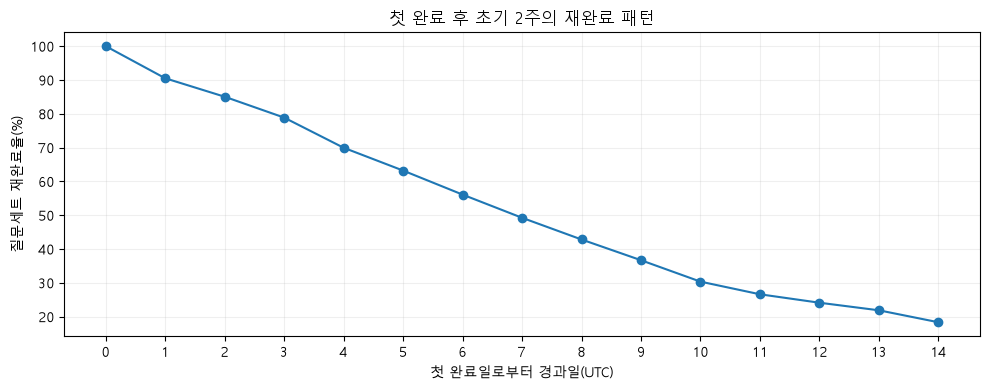

In [15]:
# 첫 완료 UTC 날짜 기준 D0~D14. D14까지 관찰 가능한 동일 코호트를 사용한다.
retention_daily_records = early_valid_sets.merge(
    early_model_users[["user_id", "first_finished_date"]],
    on="user_id", how="inner", validate="many_to_one")
retention_daily_records["day"] = (
    retention_daily_records["estimated_finished_at"].dt.normalize()
    - retention_daily_records["first_finished_date"]
).dt.days
retention_daily_counts = retention_daily_records.groupby("day")["user_id"].nunique()
retention_daily_summary = pd.DataFrame({"경과일": range(15)})
retention_daily_summary["사용자 수"] = retention_daily_summary["경과일"].map(retention_daily_counts).fillna(0).astype(int)
retention_daily_summary["재완료율(%)"] = retention_daily_summary["사용자 수"] / len(early_model_users) * 100
display(retention_daily_summary.round(2))
plt.figure(figsize=(10, 4))
plt.plot(retention_daily_summary["경과일"], retention_daily_summary["재완료율(%)"], marker="o")
plt.xticks(range(15)); plt.xlabel("첫 완료일로부터 경과일(UTC)")
plt.ylabel("질문세트 재완료율(%)"); plt.title("첫 완료 후 초기 2주의 재완료 패턴")
plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

**해석:** 원본에서 D7 약 49.2%, D14 약 18.3%로 감소한다. 같은 날의 재완료율과
한 주 중 한 번이라도 재완료한 비율은 다른 지표이다. 이 패턴을 근거로 첫 2주의 경험에 집중한다.

## 2. 초기 반복 완료: 24시간 안의 경험과 이후 유지

**여기부터 팀원 기준(KST)이다.** 학교 40명·친구 4명 조건을 충족한 시점을 활성화의 대리 기준으로 쓴다.
그 후 24시간 완료 수와 이후 각 24시간 구간의 완료 여부를 비교한다.
이 조건은 분석상의 가정이며 실제 서비스의 모든 예외를 설명하지 못한다.
질문세트 생성·시작 횟수 분석은 본문에서 제외했다.

In [16]:
ANALYSIS_TIMEZONE = "Asia/Seoul"


def to_analysis_timezone(series):
    """BigQuery 시각 컬럼을 KST timezone-aware datetime으로 통일한다."""
    return (
        pd.to_datetime(series, utc=True)
        .dt.tz_convert(ANALYSIS_TIMEZONE)
    )

In [17]:
target_school_ids = tuple(TARGET_SCHOOL_IDS)

In [18]:
target_user_sql = f"""
SELECT
    u.id AS user_id,
    u.created_at AS signup_at,
    u.group_id,
    g.school_id
FROM `{PROJECT_ID}.{DATA_SET}.accounts_user` AS u
INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_group` AS g
    ON u.group_id = g.id
WHERE g.school_id IN {target_school_ids}
"""

target_users = (
    client.query(target_user_sql)
    .to_dataframe(create_bqstorage_client=False)
)

target_users['signup_at'] = to_analysis_timezone(
    target_users['signup_at']
)

In [19]:
school_signup_order = (
    target_users
    .sort_values(
        ['school_id', 'signup_at', 'user_id']
    )
    .copy()
)

school_signup_order['school_signup_order'] = (
    school_signup_order
    .groupby('school_id')
    .cumcount()
    + 1
)

In [20]:
school_40_at = (
    school_signup_order[
        school_signup_order['school_signup_order'].eq(40)
    ]
    [
        [
            'school_id',
            'signup_at',
        ]
    ]
    .rename(
        columns={
            'signup_at': 'school_40_at',
        }
    )
    .reset_index(drop=True)
)

display(school_40_at)

,school_id,school_40_at
0,271,2023-04-28 12:43:18.503902+09:00
1,352,2023-05-05 13:07:00.053881+09:00
2,369,2023-05-03 07:44:27.267798+09:00
3,1478,2023-05-06 23:18:58.057918+09:00
4,1719,2023-05-13 17:00:50.712386+09:00
5,4426,2023-05-16 09:18:41.426463+09:00
6,4516,2023-05-03 00:17:04.497555+09:00
7,5372,2023-05-11 08:47:35.094548+09:00
8,5491,2023-05-07 11:57:28.039304+09:00
9,5520,2023-05-08 22:49:27.604223+09:00


In [21]:
target_friend_history_sql = f"""
WITH target_users AS (
    SELECT
        u.id AS user_id,
        g.school_id
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user` AS u
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_group` AS g
        ON u.group_id = g.id
    WHERE g.school_id IN {target_school_ids}
)

SELECT
    f.user_id,
    f.friendship_at,
    f.friend_cnt_after
FROM `{PROJECT_ID}.{DATA_SET}.user_friend_count_history` AS f
INNER JOIN target_users AS u
    ON f.user_id = u.user_id
ORDER BY
    f.user_id,
    f.friendship_at,
    f.friend_user_id
"""

target_friend_history = (
    client.query(target_friend_history_sql)
    .to_dataframe(create_bqstorage_client=False)
)

target_friend_history['friendship_at'] = to_analysis_timezone(
    target_friend_history['friendship_at']
)

In [22]:
user_4th_friend_at = (
    target_friend_history[
        target_friend_history['friend_cnt_after'].eq(4)
    ]
    [
        [
            'user_id',
            'friendship_at',
        ]
    ]
    .rename(
        columns={
            'friendship_at': 'friend_4_at',
        }
    )
    .reset_index(drop=True)
)

In [23]:
user_activation = (
    target_users
    .merge(
        school_40_at,
        on='school_id',
        how='left',
        validate='many_to_one',
    )
    .merge(
        user_4th_friend_at,
        on='user_id',
        how='left',
        validate='one_to_one',
    )
)

In [24]:
user_activation['activation_eligible'] = (
    user_activation['school_40_at'].notna()
    & user_activation['friend_4_at'].notna()
)

In [25]:
user_activation['activation_at'] = (
    user_activation[
        [
            'signup_at',
            'school_40_at',
            'friend_4_at',
        ]
    ]
    .max(axis=1)
)

# 두 활성화 조건을 모두 충족하지 못한 사용자는 활성화 시각 없음
user_activation.loc[
    ~user_activation['activation_eligible'],
    'activation_at',
] = pd.NaT

In [26]:
target_questionset_sql = f"""
WITH target_users AS (
    SELECT
        u.id AS user_id
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user` AS u
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_group` AS g
        ON u.group_id = g.id
    WHERE g.school_id IN {target_school_ids}
),

finished_questionsets AS (
    SELECT
        qs.id AS questionset_id,
        qs.user_id,
        qs.opening_time,
        qs.question_piece_id_list
    FROM `{PROJECT_ID}.{DATA_SET}.polls_questionset` AS qs
    INNER JOIN target_users AS u
        ON qs.user_id = u.user_id
    WHERE qs.status = 'F'
),

questionset_pieces AS (
    SELECT
        qs.questionset_id,
        qs.user_id,
        qs.opening_time,
        SAFE_CAST(question_piece_id AS INT64) AS question_piece_id
    FROM finished_questionsets AS qs
    CROSS JOIN UNNEST(
        JSON_VALUE_ARRAY(qs.question_piece_id_list)
    ) AS question_piece_id
)

SELECT
    qp.questionset_id,
    qp.user_id,
    qp.opening_time,
    COUNT(*) AS question_piece_count,
    COUNTIF(uqr.id IS NOT NULL) AS matched_record_count,
    COUNTIF(uqr.answer_updated_at IS NOT NULL) AS answered_piece_count,
    COUNTIF(uqr.answer_updated_at < qp.opening_time) AS answer_before_open_count,
    MAX(
        IF(
            uqr.answer_updated_at >= qp.opening_time,
            uqr.answer_updated_at,
            NULL
        )
    ) AS estimated_completed_at
FROM questionset_pieces AS qp
LEFT JOIN `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord` AS uqr
    ON qp.user_id = uqr.user_id
    AND qp.question_piece_id = uqr.question_piece_id
GROUP BY
    qp.questionset_id,
    qp.user_id,
    qp.opening_time
ORDER BY
    qp.user_id,
    qp.opening_time
"""

target_questionsets = (
    client.query(target_questionset_sql)
    .to_dataframe(create_bqstorage_client=False)
)

for column in ['opening_time', 'estimated_completed_at']:
    target_questionsets[column] = to_analysis_timezone(
        target_questionsets[column]
    )

In [27]:
target_questionsets['completion_time_usable'] = (
    target_questionsets['estimated_completed_at'].notna()
    & target_questionsets['answer_before_open_count'].eq(0)
)


print(f'완료 질문셋 수: {len(target_questionsets):,}개')
print(
    '대리 완료 시각을 사용할 수 있는 질문셋 수: '
    f'{target_questionsets["completion_time_usable"].sum():,}개'
)
print(
    '대리 완료 시각 사용 가능 비율: '
    f'{target_questionsets["completion_time_usable"].mean() * 100:.2f}%'
)

완료 질문셋 수: 153,411개
대리 완료 시각을 사용할 수 있는 질문셋 수: 151,562개
대리 완료 시각 사용 가능 비율: 98.79%


In [28]:
questionset_completion = (
    target_questionsets[
        target_questionsets['completion_time_usable']
    ]
    [[
        'questionset_id',
        'user_id',
        'opening_time',
        'estimated_completed_at',
    ]]
    .copy()
)

In [29]:
# 활성화 후 초기 24시간 질문셋 완료 수 계산

# 활성화된 사용자
early_activity_users = (
    user_activation[
        user_activation['activation_at'].notna()
    ][
        ['user_id', 'activation_at']
    ]
    .drop_duplicates('user_id')
    .copy()
)

# 질문셋 완료 기록 연결
early_activity_records = (
    early_activity_users
    .merge(
        questionset_completion[
            ['user_id', 'questionset_id', 'estimated_completed_at']
        ],
        on='user_id',
        how='left',
        validate='one_to_many',
    )
)

# 활성화 후 24시간 이내 완료 여부
early_activity_records['completed_within_24h'] = (
    early_activity_records['estimated_completed_at'].ge(
        early_activity_records['activation_at']
    )
    & early_activity_records['estimated_completed_at'].lt(
        early_activity_records['activation_at']
        + pd.Timedelta(hours=24)
    )
)

# 사용자별 초기 24시간 질문셋 완료 수
early_24h_activity = (
    early_activity_records
    .groupby(
        ['user_id', 'activation_at'],
        as_index=False,
    )
    .agg(
        completed_questionsets_24h=(
            'completed_within_24h',
            'sum',
        )
    )
)

early_24h_activity['completed_questionsets_24h'] = (
    early_24h_activity['completed_questionsets_24h'].astype(int)
)

display(
    early_24h_activity['completed_questionsets_24h']
    .describe(percentiles=[.25, .5, .75, .9, .95, .99])
)

count    4880.000000
mean        5.417623
std         4.312094
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
90%        11.000000
95%        14.000000
99%        17.000000
max        25.000000
Name: completed_questionsets_24h, dtype: float64

In [30]:
early_24h_distribution = (
    early_24h_activity
    .groupby(
        'completed_questionsets_24h',
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique')
    )
    .sort_values('completed_questionsets_24h')
)

early_24h_distribution['사용자비율(%)'] = (
    early_24h_distribution['사용자수']
    / early_24h_distribution['사용자수'].sum()
    * 100
).round(2)

display(early_24h_distribution)

,completed_questionsets_24h,사용자수,사용자비율(%)
0,0,627,12.85
1,1,390,7.99
2,2,448,9.18
3,3,454,9.30
4,4,428,8.77
5,5,432,8.85
6,6,402,8.24
7,7,299,6.13
8,8,278,5.70
9,9,252,5.16


In [31]:
early_24h_distribution['누적사용자비율(%)'] = (
    early_24h_distribution['사용자비율(%)']
    .cumsum()
    .round(2)
)

display(early_24h_distribution)

,completed_questionsets_24h,사용자수,사용자비율(%),누적사용자비율(%)
0,0,627,12.85,12.85
1,1,390,7.99,20.84
2,2,448,9.18,30.02
3,3,454,9.30,39.32
4,4,428,8.77,48.09
5,5,432,8.85,56.94
6,6,402,8.24,65.18
7,7,299,6.13,71.31
8,8,278,5.70,77.01
9,9,252,5.16,82.17


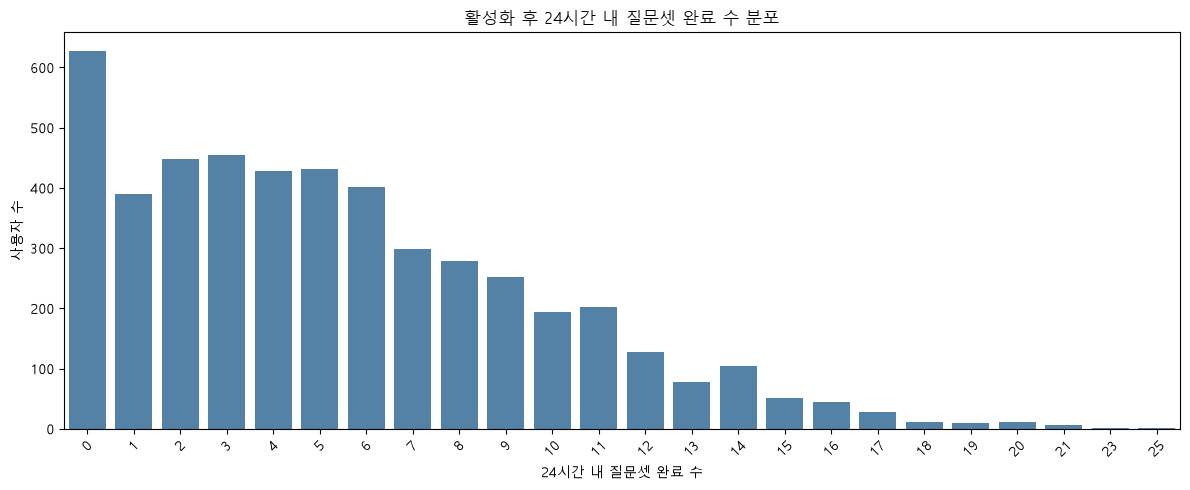

In [32]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=early_24h_distribution,
    x='completed_questionsets_24h',
    y='사용자수',
    color='steelblue',
)

plt.title('활성화 후 24시간 내 질문셋 완료 수 분포')
plt.xlabel('24시간 내 질문셋 완료 수')
plt.ylabel('사용자 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
early_24h_activity['early_activity_group'] = pd.cut(
    early_24h_activity['completed_questionsets_24h'],
    bins=[-1, 0, 1, 2, 3, 5, 10, float('inf')],
    labels=[
        '0회',
        '1회',
        '2회',
        '3회',
        '4~5회',
        '6~10회',
        '11회 이상',
    ],
)

early_activity_group_summary = (
    early_24h_activity
    .groupby(
        'early_activity_group',
        observed=False,
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
        평균완료수=('completed_questionsets_24h', 'mean'),
    )
)

early_activity_group_summary['사용자비율(%)'] = (
    early_activity_group_summary['사용자수']
    / early_activity_group_summary['사용자수'].sum()
    * 100
).round(2)

early_activity_group_summary['평균완료수'] = (
    early_activity_group_summary['평균완료수'].round(2)
)

display(early_activity_group_summary)

,early_activity_group,사용자수,평균완료수,사용자비율(%)
0,0회,627,0.00,12.85
1,1회,390,1.00,7.99
2,2회,448,2.00,9.18
3,3회,454,3.00,9.30
4,4~5회,860,4.50,17.62
5,6~10회,1425,7.68,29.20
6,11회 이상,676,13.29,13.85


In [34]:
retention_days = pd.DataFrame({
    'retention_day': range(1, 16)
})

early_retention_base = (
    early_24h_activity
    .merge(
        retention_days,
        how='cross',
    )
)

# 각 리텐션 일자의 관찰 시작·종료 시각
early_retention_base['window_start_at'] = (
    early_retention_base['activation_at']
    + pd.to_timedelta(
        early_retention_base['retention_day'],
        unit='D',
    )
)

early_retention_base['window_end_at'] = (
    early_retention_base['window_start_at']
    + pd.Timedelta(days=1)
)

In [35]:
completion_elapsed = (
    questionset_completion[
        ['user_id', 'estimated_completed_at']
    ]
    .merge(
        early_24h_activity[
            ['user_id', 'activation_at']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one',
    )
)

# 활성화 이전 완료 기록 제외
completion_elapsed = completion_elapsed[
    completion_elapsed['estimated_completed_at']
    >= completion_elapsed['activation_at']
].copy()

# 활성화 이후 몇 번째 24시간 구간인지 계산
completion_elapsed['retention_day'] = (
    (
        completion_elapsed['estimated_completed_at']
        - completion_elapsed['activation_at']
    )
    // pd.Timedelta(days=1)
).astype(int)

# 초기 24시간(D0)을 제외하고 D1~D15만 사용
completion_elapsed = completion_elapsed[
    completion_elapsed['retention_day'].between(1, 15)
].copy()

In [36]:
retained_user_day = (
    completion_elapsed[
        ['user_id', 'retention_day']
    ]
    .drop_duplicates()
    .assign(retained=True)
)

early_retention_user_day = (
    early_retention_base
    .merge(
        retained_user_day,
        on=['user_id', 'retention_day'],
        how='left',
        validate='one_to_one',
    )
)

early_retention_user_day['retained'] = (
    early_retention_user_day['retained']
    .fillna(False)
    .astype(bool)
)

In [37]:
analysis_end_at = pd.Timestamp(TEAM_OBSERVATION_END).tz_convert(ANALYSIS_TIMEZONE)

In [38]:
early_retention_observed = (
    early_retention_user_day[
        early_retention_user_day['window_end_at']
        <= analysis_end_at
    ]
    .copy()
)

print(
    '필터링 전 행 수:',
    len(early_retention_user_day),
)

print(
    '관찰 가능한 행 수:',
    len(early_retention_observed),
)

필터링 전 행 수: 73200
관찰 가능한 행 수: 73200


In [39]:
observed_user_count = (
    early_retention_observed
    .groupby(
        'retention_day',
        as_index=False,
    )
    .agg(
        관찰가능사용자수=('user_id', 'nunique')
    )
)

display(observed_user_count)

,retention_day,관찰가능사용자수
0,1,4880
1,2,4880
2,3,4880
3,4,4880
4,5,4880
5,6,4880
6,7,4880
7,8,4880
8,9,4880
9,10,4880


In [40]:
early_activity_retention_summary = (
    early_retention_observed
    .groupby(
        [
            'early_activity_group',
            'retention_day',
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
        리텐션사용자수=('retained', 'sum'),
        리텐션율=('retained', 'mean'),
    )
)

early_activity_retention_summary['리텐션율(%)'] = (
    early_activity_retention_summary['리텐션율']
    * 100
).round(2)

early_activity_retention_summary = (
    early_activity_retention_summary
    .drop(columns='리텐션율')
)

In [41]:
early_activity_retention_pivot = (
    early_activity_retention_summary
    .pivot(
        index='early_activity_group',
        columns='retention_day',
        values='리텐션율(%)',
    )
)

early_activity_retention_pivot.columns = [
    f'D{day}'
    for day in early_activity_retention_pivot.columns
]

display(early_activity_retention_pivot)

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
early_activity_group,,,,,,,,,,,,,,,
0회,36.36,40.03,39.39,40.83,37.00,34.61,31.42,27.91,26.63,22.17,18.02,15.95,16.43,16.75,11.64
1회,68.46,64.10,57.95,51.79,42.82,39.23,31.28,31.28,27.69,23.08,18.21,18.21,15.90,13.33,13.59
2회,80.13,70.09,64.06,54.91,52.01,45.09,39.29,33.93,31.70,26.12,22.99,18.30,17.86,14.29,12.05
3회,87.67,76.87,71.15,61.01,53.30,48.02,41.63,36.34,31.28,22.69,25.99,19.16,16.52,16.08,14.76
4~5회,93.37,85.81,78.14,71.86,61.74,54.53,45.12,37.79,34.88,29.42,25.35,22.33,21.63,17.67,18.49
6~10회,97.61,91.65,83.16,74.67,65.68,57.75,50.95,44.63,35.86,31.37,29.05,25.89,22.18,20.07,18.95
11회 이상,99.85,97.04,93.49,85.36,79.73,68.49,65.83,56.07,45.27,36.24,33.88,29.44,25.74,29.59,23.82


In [42]:
early_activity_user_count_pivot = (
    early_activity_retention_summary
    .pivot(
        index='early_activity_group',
        columns='retention_day',
        values='사용자수',
    )
)

early_activity_user_count_pivot.columns = [
    f'D{day}'
    for day in early_activity_user_count_pivot.columns
]

display(early_activity_user_count_pivot)

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
early_activity_group,,,,,,,,,,,,,,,
0회,627,627,627,627,627,627,627,627,627,627,627,627,627,627,627
1회,390,390,390,390,390,390,390,390,390,390,390,390,390,390,390
2회,448,448,448,448,448,448,448,448,448,448,448,448,448,448,448
3회,454,454,454,454,454,454,454,454,454,454,454,454,454,454,454
4~5회,860,860,860,860,860,860,860,860,860,860,860,860,860,860,860
6~10회,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425
11회 이상,676,676,676,676,676,676,676,676,676,676,676,676,676,676,676


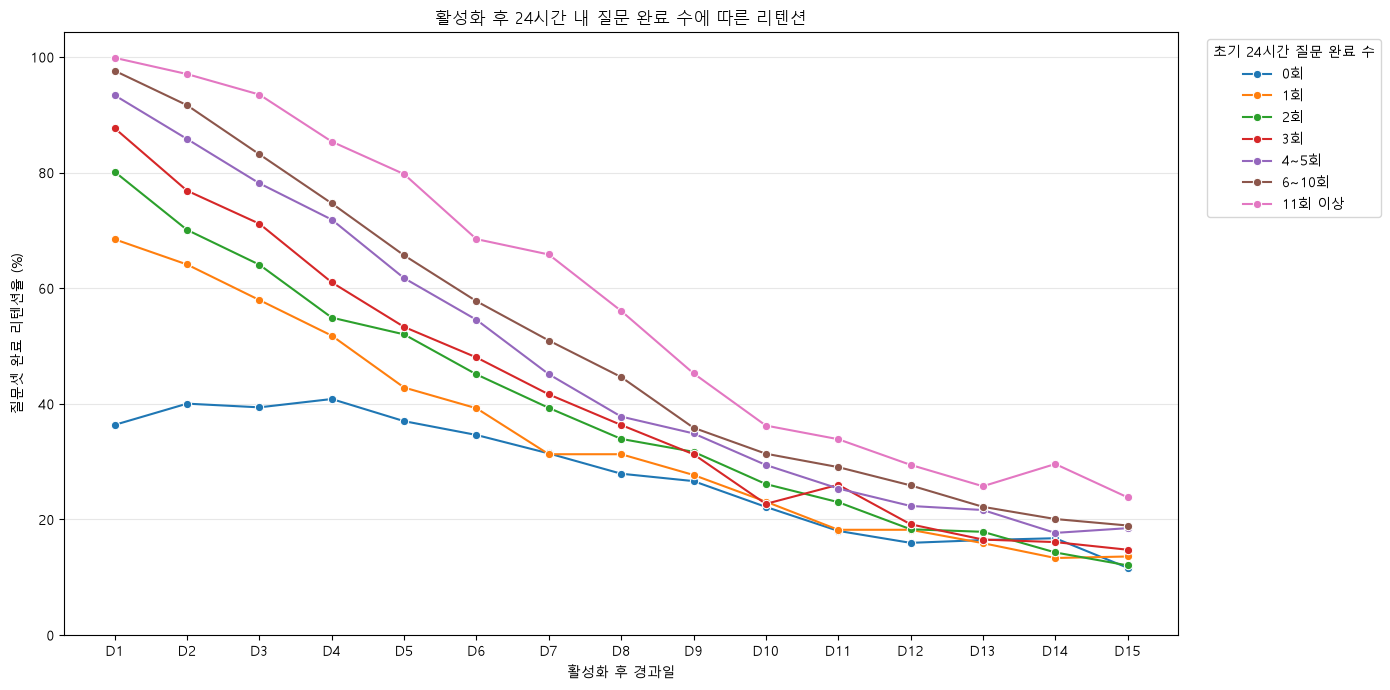

In [43]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=early_activity_retention_summary,
    x='retention_day',
    y='리텐션율(%)',
    hue='early_activity_group',
    marker='o',
)

plt.title('활성화 후 24시간 내 질문 완료 수에 따른 리텐션')
plt.xlabel('활성화 후 경과일')
plt.ylabel('질문셋 완료 리텐션율 (%)')
plt.xticks(
    range(1, 16),
    [f'D{day}' for day in range(1, 16)],
)
plt.ylim(bottom=0)
plt.grid(
    axis='y',
    alpha=0.3,
)
plt.legend(
    title='초기 24시간 질문 완료 수',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)
plt.tight_layout()
plt.show()

**해석:** 초기 완료 수가 많은 집단에서 후속 재완료가 높은 경향이 관찰되었다.
‘24시간 내 완료 3회’는 이 관계를 제품에서 검증할 **후보 목표**다. 완료 3회 자체의 인과효과나 최적 임계점은 확정하지 않는다.
질문 생성·시작 3회 분석에서 얻은 차이와 유의확률을 완료 3회의 근거로 옮겨 쓰지 않는다.

## 3. 선택받는 경험: 초기 수신보다 최근 수신이 중요한가?

### 3-1. 첫 완료 후 24시간·3일·7일의 행동 집계
핑은 제공된 투표 기록에서 선택받은 횟수다. 전체 서비스에서의 모든 수신을 포괄한다고 보장할 수 없다.
친구 수는 해당 시점까지 수락된 것으로 추정되는 고유 관계 수다.

In [44]:
# 05. 초기 24시간과 7일의 질문 활동량 생성

early_activity_source = early_valid_sets[
    ["user_id", "questionset_id", "estimated_finished_at"]
].merge(
    early_model_users[["user_id", "first_finished_at"]],
    on="user_id",
    how="inner",
    validate="many_to_one"
)

early_activity_source["elapsed_since_first"] = (
    early_activity_source["estimated_finished_at"]
    - early_activity_source["first_finished_at"]
)

early_activity_tables = []

for early_window_name, early_window_hours in early_windows.items():

    # 첫 완료 시각은 포함하고 관찰 종료 시각은 제외
    early_activity_mask = (
        (
            early_activity_source["elapsed_since_first"]
            >= pd.Timedelta(0)
        )
        & (
            early_activity_source["elapsed_since_first"]
            < pd.Timedelta(hours=early_window_hours)
        )
    )

    early_window_activity = early_activity_source.loc[
        early_activity_mask
    ].copy()

    # 첫 완료 시각부터 24시간 단위로 활동일을 구분
    early_window_activity["activity_day_index"] = (
        early_window_activity["elapsed_since_first"]
        // pd.Timedelta(days=1)
    ).astype(int)

    early_window_summary = (
        early_window_activity
        .groupby("user_id", as_index=False)
        .agg(
            completed_sets=("questionset_id", "nunique"),
            active_days=("activity_day_index", "nunique")
        )
    )

    early_window_users = early_model_users[
        [
            "user_id",
            "school_id",
            "signup_at",
            "first_finished_at",
            "d14_retained"
        ]
    ].merge(
        early_window_summary,
        on="user_id",
        how="left",
        validate="one_to_one"
    )

    early_window_users["window"] = early_window_name
    early_window_users["window_end"] = (
        early_window_users["first_finished_at"]
        + pd.Timedelta(hours=early_window_hours)
    )

    # 기준이 되는 첫 완료가 있으므로 모든 사용자에게 활동량이 있어야 함
    assert early_window_users[
        ["completed_sets", "active_days"]
    ].notna().all().all(), "질문 활동량이 연결되지 않은 사용자가 있습니다."

    early_window_users[["completed_sets", "active_days"]] = (
        early_window_users[["completed_sets", "active_days"]]
        .astype(int)
    )

    assert (
        early_window_users["completed_sets"] >= 1
    ).all(), "첫 완료가 활동량에 포함되지 않은 사용자가 있습니다."

    assert early_window_users["active_days"].between(
        1, early_window_hours // 24
    ).all(), "활동일 수가 관찰 구간을 벗어났습니다."

    early_activity_tables.append(early_window_users)

In [45]:
early_features = pd.concat(
    early_activity_tables,
    ignore_index=True
)

assert not early_features.duplicated(
    ["user_id", "window"]
).any(), "사용자와 관찰 구간 조합이 중복됩니다."

# 같은 사용자를 두 관찰 구간에서 분석하는지 확인
assert len(early_features) == len(early_model_users) * len(early_windows)

early_activity_check = (
    early_features
    .groupby("window", sort=False)
    .agg(
        user_count=("user_id", "nunique"),
        mean_completed_sets=("completed_sets", "mean"),
        median_completed_sets=("completed_sets", "median"),
        mean_active_days=("active_days", "mean"),
        min_active_days=("active_days", "min"),
        max_active_days=("active_days", "max"),
        d14_rate=("d14_retained", "mean")
    )
    .reset_index()
)

early_activity_check["d14_rate"] = (
    early_activity_check["d14_rate"] * 100
)

early_activity_check = early_activity_check.rename(
    columns={
        "window": "관찰 구간",
        "user_count": "사용자 수",
        "mean_completed_sets": "평균 완료 세트 수",
        "median_completed_sets": "완료 세트 수 중앙값",
        "mean_active_days": "평균 활동일 수",
        "min_active_days": "최소 활동일 수",
        "max_active_days": "최대 활동일 수",
        "d14_rate": "D+14 재완료율(%)"
    }
)

print("초기 질문 활동량 생성 완료")
print("완료 세트 수에는 기준이 되는 첫 완료가 포함됩니다.")
print("활동일은 첫 완료 시각부터 24시간 단위로 계산합니다.")
print("같은 사용자가 24시간과 7일 분석에 각각 포함됩니다.")

display(early_activity_check.round(2))

초기 질문 활동량 생성 완료
완료 세트 수에는 기준이 되는 첫 완료가 포함됩니다.
활동일은 첫 완료 시각부터 24시간 단위로 계산합니다.
같은 사용자가 24시간과 7일 분석에 각각 포함됩니다.


,관찰 구간,사용자 수,평균 완료 세트 수,완료 세트 수 중앙값,평균 활동일 수,최소 활동일 수,최대 활동일 수,D+14 재완료율(%)
0,24h,4812,7.05,6.0,1.00,1,1,18.33
1,3d,4812,15.34,13.0,2.71,1,3,18.33
2,7d,4812,23.66,20.0,5.23,1,7,18.33


In [46]:
# 06. 초기 24시간과 7일 동안 받은 핑 집계

early_recipient_ids = (
    early_model_users["user_id"]
    .astype("int64")
    .tolist()
)

early_ping_query_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter(
            "recipient_ids",
            "INT64",
            early_recipient_ids
        )
    ]
)

# 사용자별 관찰 구간 적용에 필요한 수신 투표 기록 조회
early_received_votes = client.query(
    f"""
    SELECT
        user_id AS sender_user_id,
        chosen_user_id AS recipient_user_id,
        question_piece_id,
        created_at
    FROM `{early_project}.{early_dataset}.accounts_userquestionrecord`
    WHERE chosen_user_id IN UNNEST(@recipient_ids)
    """,
    job_config=early_ping_query_config
).to_dataframe(create_bqstorage_client=False)

early_received_votes["created_at"] = pd.to_datetime(
    early_received_votes["created_at"],
    utc=True
)

assert early_received_votes["created_at"].notna().all(), (
    "수신 투표 기록에 시각 누락이 있습니다."
)

assert early_received_votes[
    ["sender_user_id", "recipient_user_id", "question_piece_id"]
].notna().all().all(), "수신 투표 기록에 필수 식별값 누락이 있습니다."

# 같은 투표 기록이 중복 집계되는지 확인
assert not early_received_votes.duplicated(
    ["sender_user_id", "question_piece_id"]
).any(), "같은 발신자와 질문 조각의 투표 기록이 중복됩니다."

early_received_with_start = early_received_votes.merge(
    early_model_users[["user_id", "first_finished_at"]],
    left_on="recipient_user_id",
    right_on="user_id",
    how="inner",
    validate="many_to_one"
)

early_received_with_start["elapsed_since_first"] = (
    early_received_with_start["created_at"]
    - early_received_with_start["first_finished_at"]
)

early_ping_tables = []

for early_window_name, early_window_hours in early_windows.items():

    # 첫 완료 시각은 포함하고 관찰 종료 시각은 제외
    early_ping_mask = (
        (
            early_received_with_start["elapsed_since_first"]
            >= pd.Timedelta(0)
        )
        & (
            early_received_with_start["elapsed_since_first"]
            < pd.Timedelta(hours=early_window_hours)
        )
    )

    early_window_pings = early_received_with_start.loc[
        early_ping_mask
    ].copy()

    early_ping_summary = (
        early_window_pings
        .groupby("user_id", as_index=False)
        .agg(
            received_ping_count=("recipient_user_id", "size"),
            unique_ping_senders=("sender_user_id", "nunique")
        )
    )

    early_ping_summary["window"] = early_window_name
    early_ping_tables.append(early_ping_summary)

In [47]:
early_ping_features = pd.concat(
    early_ping_tables,
    ignore_index=True
)

# 셀을 다시 실행해도 기존 열과 중복되지 않도록 처리
early_features = early_features.drop(
    columns=["received_ping_count", "unique_ping_senders"],
    errors="ignore"
).merge(
    early_ping_features,
    on=["user_id", "window"],
    how="left",
    validate="one_to_one"
)

early_ping_columns = [
    "received_ping_count",
    "unique_ping_senders"
]

early_features[early_ping_columns] = (
    early_features[early_ping_columns]
    .fillna(0)
    .astype("int64")
)

assert (
    early_features["unique_ping_senders"]
    <= early_features["received_ping_count"]
).all(), "핑 발신자 수가 받은 핑 수보다 큽니다."

# 동일 사용자의 7일 수신량은 24시간 수신량보다 작을 수 없음
early_ping_comparison = early_features.pivot(
    index="user_id",
    columns="window",
    values="received_ping_count"
)

assert (
    early_ping_comparison["7d"] >= early_ping_comparison["24h"]
).all(), "24시간과 7일의 핑 집계 범위를 확인해야 합니다."

early_ping_check = (
    early_features
    .groupby("window", sort=False)
    .agg(
        user_count=("user_id", "nunique"),
        mean_received_pings=("received_ping_count", "mean"),
        median_received_pings=("received_ping_count", "median"),
        zero_ping_users=(
            "received_ping_count",
            lambda values: int(values.eq(0).sum())
        ),
        mean_unique_senders=("unique_ping_senders", "mean")
    )
    .reset_index()
)

early_ping_check["zero_ping_rate"] = (
    early_ping_check["zero_ping_users"]
    / early_ping_check["user_count"]
    * 100
)

early_ping_check = early_ping_check.rename(
    columns={
        "window": "관찰 구간",
        "user_count": "사용자 수",
        "mean_received_pings": "평균 받은 핑 수",
        "median_received_pings": "받은 핑 수 중앙값",
        "zero_ping_users": "받은 핑이 0인 사용자 수",
        "mean_unique_senders": "평균 고유 발신자 수",
        "zero_ping_rate": "받은 핑이 0인 사용자 비율(%)"
    }
)

print("초기 받은 핑 집계 완료")
print("수신량은 제공된 내부 투표 데이터에서 확인되는 기록 기준입니다.")
print("핑이 0이라는 것은 해당 범위에서 수신 기록이 없다는 의미입니다.")

display(early_ping_check.round(2))

초기 받은 핑 집계 완료
수신량은 제공된 내부 투표 데이터에서 확인되는 기록 기준입니다.
핑이 0이라는 것은 해당 범위에서 수신 기록이 없다는 의미입니다.


,관찰 구간,사용자 수,평균 받은 핑 수,받은 핑 수 중앙값,받은 핑이 0인 사용자 수,평균 고유 발신자 수,받은 핑이 0인 사용자 비율(%)
0,24h,4812,37.15,28.0,118,13.64,2.45
1,3d,4812,93.31,78.0,59,22.43,1.23
2,7d,4812,154.92,129.0,45,27.87,0.94


In [48]:
# 07. 초기 24시간과 7일 종료 시점의 추정 친구 수 생성

early_friend_query_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter(
            "target_user_ids",
            "INT64",
            early_model_users["user_id"].astype("int64").tolist()
        )
    ]
)

# 같은 두 사용자 사이의 관계를 방향과 관계없이 하나로 정리
early_friend_pairs = client.query(
    f"""
    SELECT
        LEAST(send_user_id, receive_user_id) AS user_id_low,
        GREATEST(send_user_id, receive_user_id) AS user_id_high,
        MIN(updated_at) AS estimated_friend_at
    FROM `{early_project}.{early_dataset}.accounts_friendrequest`
    WHERE status = 'A'
      AND (
          send_user_id IN UNNEST(@target_user_ids)
          OR receive_user_id IN UNNEST(@target_user_ids)
      )
      AND send_user_id IS NOT NULL
      AND receive_user_id IS NOT NULL
      AND send_user_id != receive_user_id
    GROUP BY 1, 2
    """,
    job_config=early_friend_query_config
).to_dataframe(create_bqstorage_client=False)

early_friend_pairs["estimated_friend_at"] = pd.to_datetime(
    early_friend_pairs["estimated_friend_at"],
    utc=True
)

# 시각이 없는 관계를 임의로 현재 또는 과거 관계로 분류하지 않음
early_missing_friend_times = int(
    early_friend_pairs["estimated_friend_at"].isna().sum()
)

print(f"조회된 고유 친구 관계: {len(early_friend_pairs):,}개")
print(f"형성 시각 추정 불가 관계: {early_missing_friend_times:,}개")

assert early_missing_friend_times == 0, (
    "형성 시각을 추정할 수 없는 친구 관계가 있습니다. "
    "친구 수 집계 전에 해당 기록을 확인해야 합니다."
)

# 관계 양쪽 사용자가 각각 자신의 친구 수를 집계할 수 있도록 변환
early_friend_links = pd.concat(
    [
        early_friend_pairs.rename(
            columns={
                "user_id_low": "user_id",
                "user_id_high": "friend_user_id"
            }
        ),
        early_friend_pairs.rename(
            columns={
                "user_id_high": "user_id",
                "user_id_low": "friend_user_id"
            }
        )
    ],
    ignore_index=True
)

early_friend_links = early_friend_links.loc[
    early_friend_links["user_id"].isin(early_model_users["user_id"])
].copy()

assert not early_friend_links.duplicated(
    ["user_id", "friend_user_id"]
).any(), "같은 사용자와 친구의 관계가 중복됩니다."

early_friend_tables = []

for early_window_name in early_windows:

    early_friend_cutoffs = early_features.loc[
        early_features["window"] == early_window_name,
        ["user_id", "window_end"]
    ]

    early_window_friends = early_friend_links.merge(
        early_friend_cutoffs,
        on="user_id",
        how="inner",
        validate="many_to_one"
    )

    # 첫 완료 이전에 형성된 친구도 포함
    # 다른 변수와 동일하게 종료 시각 미만을 기준으로 집계
    early_window_friends = early_window_friends.loc[
        early_window_friends["estimated_friend_at"]
        < early_window_friends["window_end"]
    ]

    early_friend_summary = (
        early_window_friends
        .groupby("user_id", as_index=False)
        .agg(
            estimated_friend_count_end=("friend_user_id", "nunique")
        )
    )

    early_friend_summary["window"] = early_window_name
    early_friend_tables.append(early_friend_summary)

조회된 고유 친구 관계: 128,182개
형성 시각 추정 불가 관계: 0개


In [49]:
early_friend_features = pd.concat(
    early_friend_tables,
    ignore_index=True
)

early_features = early_features.drop(
    columns=["estimated_friend_count_end"],
    errors="ignore"
).merge(
    early_friend_features,
    on=["user_id", "window"],
    how="left",
    validate="one_to_one"
)

early_features["estimated_friend_count_end"] = (
    early_features["estimated_friend_count_end"]
    .fillna(0)
    .astype("int64")
)

assert not early_features.duplicated(
    ["user_id", "window"]
).any(), "사용자와 관찰 구간 조합이 중복됩니다."

assert len(early_features) == (
    len(early_model_users) * len(early_windows)
), "친구 수 연결 과정에서 분석 행 수가 변경되었습니다."

# 이 추정 방식은 관계 형성 기록을 누적하므로 7일 값이 더 작을 수 없음
early_friend_comparison = early_features.pivot(
    index="user_id",
    columns="window",
    values="estimated_friend_count_end"
)

assert (
    early_friend_comparison["7d"]
    >= early_friend_comparison["24h"]
).all(), "구간별 친구 수 집계 기준을 확인해야 합니다."

early_friend_check = (
    early_features
    .groupby("window", sort=False)
    .agg(
        user_count=("user_id", "nunique"),
        mean_friends=("estimated_friend_count_end", "mean"),
        median_friends=("estimated_friend_count_end", "median"),
        zero_friend_users=(
            "estimated_friend_count_end",
            lambda values: int(values.eq(0).sum())
        ),
        max_friends=("estimated_friend_count_end", "max")
    )
    .reset_index()
    .rename(
        columns={
            "window": "관찰 구간",
            "user_count": "사용자 수",
            "mean_friends": "종료 시점 평균 추정 친구 수",
            "median_friends": "종료 시점 추정 친구 수 중앙값",
            "zero_friend_users": "추정 친구 수가 0인 사용자 수",
            "max_friends": "최대 추정 친구 수"
        }
    )
)

print("관찰 구간 종료 시점의 추정 친구 수 생성 완료")
print("첫 완료 이전부터 존재한 것으로 추정되는 친구도 포함합니다.")
print("현재 수락 상태인 관계의 수정 시각을 이용한 추정치입니다.")
print("친구 삭제나 재등록 이력을 완전히 반영하지는 못합니다.")

display(early_friend_check.round(2))

관찰 구간 종료 시점의 추정 친구 수 생성 완료
첫 완료 이전부터 존재한 것으로 추정되는 친구도 포함합니다.
현재 수락 상태인 관계의 수정 시각을 이용한 추정치입니다.
친구 삭제나 재등록 이력을 완전히 반영하지는 못합니다.


,관찰 구간,사용자 수,종료 시점 평균 추정 친구 수,종료 시점 추정 친구 수 중앙값,추정 친구 수가 0인 사용자 수,최대 추정 친구 수
0,24h,4812,24.67,21.0,55,136
1,3d,4812,35.35,30.0,29,192
2,7d,4812,41.97,37.0,21,226


In [50]:
# 08. 초기 받은 핑 수준별 D+14 재완료율 확인

early_ping_group_order = [
    "수신 없음",
    "수신 하위 구간",
    "수신 중하위 구간",
    "수신 중상위 구간",
    "수신 상위 구간"
]

early_grouped_tables = []
early_ping_boundary_rows = []

for early_window_name in early_windows:

    early_window_data = early_features.loc[
        early_features["window"] == early_window_name
    ].copy()

    early_positive_pings = early_window_data.loc[
        early_window_data["received_ping_count"] > 0,
        "received_ping_count"
    ]

    assert len(early_positive_pings) > 0, (
        "핑을 받은 사용자가 없어 구간을 나눌 수 없습니다."
    )

    early_quantiles = early_positive_pings.quantile(
        [0.25, 0.50, 0.75]
    ).to_numpy()

    assert (
        early_quantiles[0] < early_quantiles[1]
        < early_quantiles[2]
    ), "분위수 경계가 겹칩니다. 핑 분포에 맞춰 구간을 다시 설정해야 합니다."

    early_window_data["ping_group"] = pd.cut(
        early_window_data["received_ping_count"],
        bins=[
            -np.inf,
            0,
            early_quantiles[0],
            early_quantiles[1],
            early_quantiles[2],
            np.inf
        ],
        labels=early_ping_group_order,
        right=True
    )

    assert early_window_data["ping_group"].notna().all(), (
        "핑 구간이 지정되지 않은 사용자가 있습니다."
    )

    early_ping_boundary_rows.append(
        {
            "관찰 구간": early_window_name,
            "양수 수신량 25% 경계": early_quantiles[0],
            "양수 수신량 50% 경계": early_quantiles[1],
            "양수 수신량 75% 경계": early_quantiles[2]
        }
    )

    early_grouped_tables.append(early_window_data)

early_features = pd.concat(
    early_grouped_tables,
    ignore_index=True
)

early_ping_group_summary = (
    early_features
    .groupby(["window", "ping_group"], observed=True, sort=True)
    .agg(
        user_count=("user_id", "nunique"),
        min_pings=("received_ping_count", "min"),
        max_pings=("received_ping_count", "max"),
        retained_users=("d14_retained", "sum"),
        retention_rate=("d14_retained", "mean"),
        mean_completed_sets=("completed_sets", "mean"),
        mean_active_days=("active_days", "mean"),
        mean_friends=("estimated_friend_count_end", "mean")
    )
    .reset_index()
)

In [51]:
early_ping_group_summary["retention_rate"] = (
    early_ping_group_summary["retention_rate"] * 100
)

# 구간별 집계 인원과 재완료 인원이 원래 데이터와 같은지 확인
early_group_totals = early_ping_group_summary.groupby("window").agg(
    user_count=("user_count", "sum"),
    retained_users=("retained_users", "sum")
)

assert (
    early_group_totals["user_count"] == len(early_model_users)
).all(), "핑 구간 집계 과정에서 사용자 수가 달라졌습니다."

assert (
    early_group_totals["retained_users"]
    == early_model_users["d14_retained"].sum()
).all(), "핑 구간 집계 과정에서 재완료 사용자 수가 달라졌습니다."

early_ping_group_display = early_ping_group_summary.rename(
    columns={
        "window": "관찰 구간",
        "ping_group": "받은 핑 구간",
        "user_count": "사용자 수",
        "min_pings": "최소 받은 핑",
        "max_pings": "최대 받은 핑",
        "retained_users": "D+14 재완료 사용자 수",
        "retention_rate": "D+14 재완료율(%)",
        "mean_completed_sets": "평균 완료 세트 수",
        "mean_active_days": "평균 활동일 수",
        "mean_friends": "평균 추정 친구 수"
    }
)

print("받은 핑이 0인 사용자는 별도 집단으로 구분합니다.")
print("양수 수신량의 분위수를 기준으로 나머지 네 집단을 나눕니다.")
print("같은 핑 수는 같은 집단에 포함하므로 집단 크기가 같지 않을 수 있습니다.")

display(pd.DataFrame(early_ping_boundary_rows).round(2))

for early_window_name in early_windows:
    print(f"\n초기 관찰 구간: {early_window_name}")
    display(
        early_ping_group_display.loc[
            early_ping_group_display["관찰 구간"] == early_window_name
        ].round(2)
    )

받은 핑이 0인 사용자는 별도 집단으로 구분합니다.
양수 수신량의 분위수를 기준으로 나머지 네 집단을 나눕니다.
같은 핑 수는 같은 집단에 포함하므로 집단 크기가 같지 않을 수 있습니다.


,관찰 구간,양수 수신량 25% 경계,양수 수신량 50% 경계,양수 수신량 75% 경계
0,24h,15.0,29.0,52.0
1,3d,40.0,78.0,131.0
2,7d,68.0,130.0,216.0



초기 관찰 구간: 24h


,관찰 구간,받은 핑 구간,사용자 수,최소 받은 핑,최대 받은 핑,D+14 재완료 사용자 수,D+14 재완료율(%),평균 완료 세트 수,평균 활동일 수,평균 추정 친구 수
0,24h,수신 없음,118,0,0,15,12.71,2.56,1.0,5.93
1,24h,수신 하위 구간,1263,1,15,261,20.67,4.57,1.0,13.87
2,24h,수신 중하위 구간,1097,16,29,198,18.05,6.15,1.0,20.49
3,24h,수신 중상위 구간,1178,30,52,202,17.15,7.87,1.0,27.11
4,24h,수신 상위 구간,1156,53,316,206,17.82,10.21,1.0,39.87



초기 관찰 구간: 3d


,관찰 구간,받은 핑 구간,사용자 수,최소 받은 핑,최대 받은 핑,D+14 재완료 사용자 수,D+14 재완료율(%),평균 완료 세트 수,평균 활동일 수,평균 추정 친구 수
5,3d,수신 없음,59,0,0,5,8.47,3.98,1.64,5.63
6,3d,수신 하위 구간,1193,1,40,207,17.35,9.56,2.45,18.78
7,3d,수신 중하위 구간,1189,41,78,231,19.43,14.20,2.73,29.92
8,3d,수신 중상위 구간,1199,79,131,225,18.77,16.88,2.82,39.02
9,3d,수신 상위 구간,1172,132,608,214,18.26,21.38,2.88,55.48



초기 관찰 구간: 7d


,관찰 구간,받은 핑 구간,사용자 수,최소 받은 핑,최대 받은 핑,D+14 재완료 사용자 수,D+14 재완료율(%),평균 완료 세트 수,평균 활동일 수,평균 추정 친구 수
10,7d,수신 없음,45,0,0,3,6.67,3.87,2.00,6.16
11,7d,수신 하위 구간,1207,1,68,195,16.16,14.54,4.39,22.09
12,7d,수신 중하위 구간,1181,69,130,210,17.78,22.35,5.25,35.39
13,7d,수신 중상위 구간,1190,131,216,223,18.74,26.09,5.53,47.29
14,7d,수신 상위 구간,1189,217,900,251,21.11,32.51,5.88,64.73


In [52]:
# 09. 초기 받은 핑 구간별 D+14 재완료율 시각화

# 윈도우 한글 글꼴 설정

plt.rcParams["axes.unicode_minus"] = False

early_chart_data = early_ping_group_summary.copy()

early_chart_order = [
    "수신 없음",
    "수신 하위 구간",
    "수신 중하위 구간",
    "수신 중상위 구간",
    "수신 상위 구간"
]

early_chart_colors = [
    "#ADB5BD",
    "#B8D8EC",
    "#83BADB",
    "#4C97C5",
    "#23689B"
]

early_chart_titles = {
    "24h": "초기 24시간 받은 핑",
    "7d": "초기 7일 받은 핑"
}

early_chart_notes = {
    "24h": "수신량에 따른 일관된 증가 경향은 나타나지 않음",
    "7d": "수신 구간이 높아질수록 재완료율이 높아지는 경향"
}

early_chart_ymax = max(
    25,
    np.ceil(early_chart_data["retention_rate"].max() / 5) * 5 + 5
)

early_chart_output = Path("outputs") / "early_ping_charts"
early_chart_output.mkdir(parents=True, exist_ok=True)


def early_draw_ping_chart(ax, window_name):
    chart = (
        early_chart_data.loc[
            early_chart_data["window"] == window_name
        ]
        .set_index("ping_group")
        .reindex(early_chart_order)
        .reset_index()
    )

    positions = np.arange(len(chart))

    bars = ax.bar(
        positions,
        chart["retention_rate"].astype(float),
        color=early_chart_colors,
        width=0.65,
        zorder=3
    )

    tick_labels = []

    for row in chart.itertuples(index=False):
        if row.max_pings == 0:
            ping_range = "0개"
        else:
            ping_range = f"{int(row.min_pings):,}~{int(row.max_pings):,}개"

        tick_labels.append(
            f"{ping_range}\n사용자 {int(row.user_count):,}명"
        )

    for bar, rate in zip(bars, chart["retention_rate"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            float(rate) + 0.55,
            f"{float(rate):.2f}%",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color="#243746"
        )

    overall_rate = (
        chart["retained_users"].sum()
        / chart["user_count"].sum()
        * 100
    )

    ax.axhline(
        overall_rate,
        color="#737373",
        linestyle="--",
        linewidth=1.2,
        label=f"전체 재완료율 {overall_rate:.2f}%",
        zorder=2
    )

    ax.set_title(
        f"{early_chart_titles[window_name]}\n"
        f"{early_chart_notes[window_name]}",
        fontsize=13,
        fontweight="bold",
        pad=18
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_xlabel("받은 핑 범위와 구간별 사용자 수", labelpad=12)
    ax.set_ylabel("D+14 질문세트 재완료율")
    ax.set_ylim(0, early_chart_ymax)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    ax.grid(axis="y", alpha=0.2, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(loc="upper left", frameon=False, fontsize=9)

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

    ax.spines["left"].set_color("#D0D0D0")
    ax.spines["bottom"].set_color("#D0D0D0")
    ax.tick_params(axis="both", length=0)

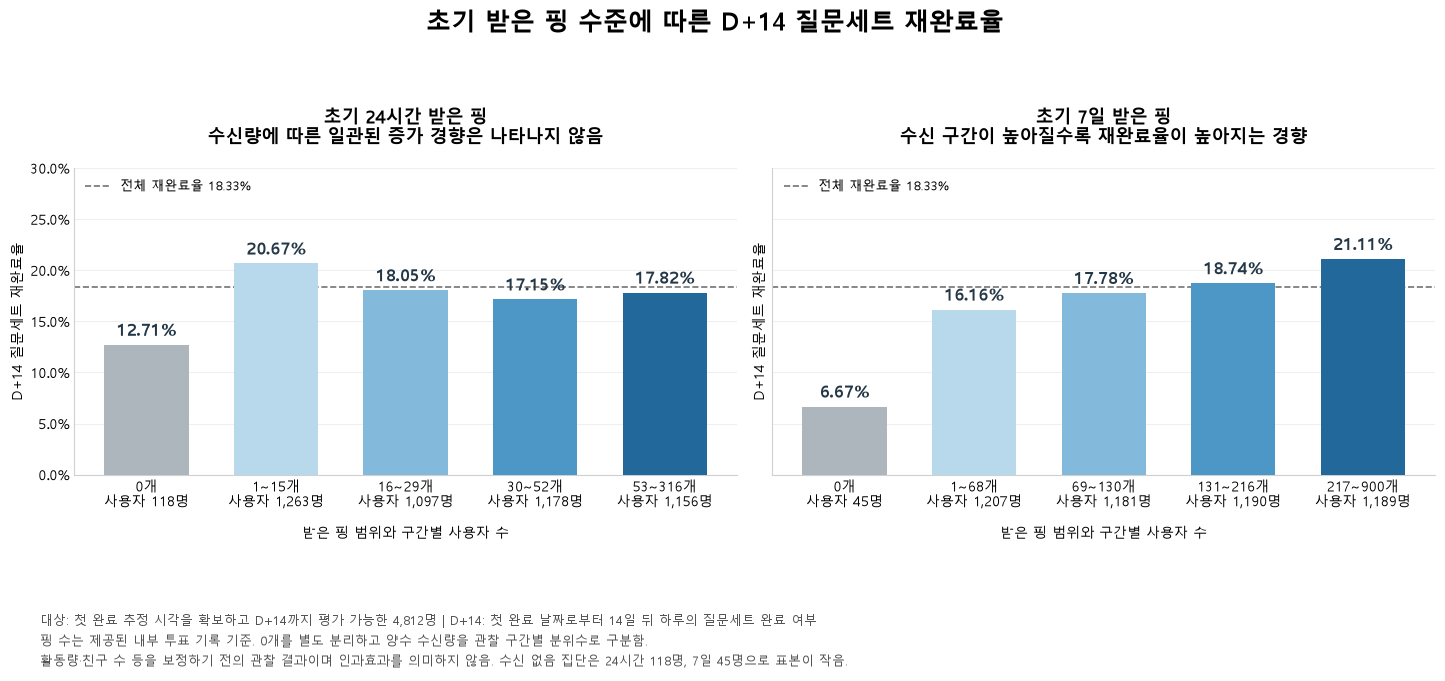

In [53]:
early_chart_footnote = (
    "대상: 첫 완료 추정 시각을 확보하고 D+14까지 평가 가능한 4,812명 | "
    "D+14: 첫 완료 날짜로부터 14일 뒤 하루의 질문세트 완료 여부\n"
    "핑 수는 제공된 내부 투표 기록 기준. 0개를 별도 분리하고 양수 수신량을 "
    "관찰 구간별 분위수로 구분함.\n"
    "활동량·친구 수 등을 보정하기 전의 관찰 결과이며 인과효과를 의미하지 않음. "
    "수신 없음 집단은 24시간 118명, 7일 45명으로 표본이 작음."
)

# 두 관찰 구간 비교 이미지
early_fig, early_axes = plt.subplots(
    1, 2,
    figsize=(15, 7),
    sharey=True
)

for early_ax, early_window in zip(early_axes, ["24h", "7d"]):
    early_draw_ping_chart(early_ax, early_window)

early_fig.suptitle(
    "초기 받은 핑 수준에 따른 D+14 질문세트 재완료율",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

early_fig.text(
    0.05, 0.035,
    early_chart_footnote,
    fontsize=9,
    color="#555555",
    va="bottom",
    linespacing=1.6
)

early_fig.tight_layout(rect=[0.02, 0.20, 0.99, 0.92])

early_combined_path = early_chart_output / "초기_핑_24시간_7일_비교.png"

plt.show()
plt.close(early_fig)

# 관찰 구간별 이미지도 별도로 저장
for early_window in ["24h", "7d"]:
    early_single_fig, early_single_ax = plt.subplots(figsize=(9, 7))

    early_draw_ping_chart(early_single_ax, early_window)

    early_single_fig.text(
        0.06, 0.04,
        "D+14는 첫 완료 날짜로부터 14일 뒤 하루의 질문세트 완료 여부입니다.\n"
        "제공된 내부 투표 기록 기준이며, 활동량·친구 수 보정 전 결과입니다.\n"
        "관찰된 연관성으로, 핑 수신의 인과효과를 의미하지 않습니다.",
        fontsize=9,
        color="#555555",
        linespacing=1.6
    )

    early_single_fig.tight_layout(rect=[0.02, 0.18, 0.99, 0.98])

    early_single_path = (
        early_chart_output / f"초기_핑_{early_window}_재완료율.png"
    )

    early_single_fig.savefig(
        early_single_path,
        dpi=200,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close(early_single_fig)

In [54]:
# 10. 초기 7일 받은 핑 수와 보정 재완료 확률의 관계 탐색

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import bs
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["axes.unicode_minus"] = False

# 초기 7일 사용자별 데이터
early_continuous_7d = early_features.loc[
    early_features["window"] == "7d"
].copy()

early_continuous_required = [
    "user_id",
    "school_id",
    "signup_at",
    "received_ping_count",
    "completed_sets",
    "active_days",
    "estimated_friend_count_end",
    "d14_retained"
]

assert early_continuous_7d[
    early_continuous_required
].notna().all().all(), "분석에 필요한 값이 누락되어 있습니다."

assert early_continuous_7d["user_id"].is_unique, (
    "같은 사용자가 중복으로 포함되어 있습니다."
)

early_continuous_7d["d14_retained"] = (
    early_continuous_7d["d14_retained"].astype(int)
)

for early_column in [
    "received_ping_count",
    "completed_sets",
    "active_days",
    "estimated_friend_count_end"
]:
    early_continuous_7d[early_column] = (
        early_continuous_7d[early_column].astype(float)
    )

early_continuous_7d["school_group"] = (
    early_continuous_7d["school_id"].astype(str)
)

early_continuous_7d["signup_month"] = (
    pd.to_datetime(early_continuous_7d["signup_at"], utc=True)
    .dt.tz_convert(early_date_timezone)
    .dt.strftime("%Y-%m")
)

early_continuous_7d["log_received_pings"] = np.log1p(
    early_continuous_7d["received_ping_count"]
)

early_continuous_7d["log_completed_sets"] = np.log1p(
    early_continuous_7d["completed_sets"]
)

early_continuous_7d["log_friend_count"] = np.log1p(
    early_continuous_7d["estimated_friend_count_end"]
)

# 받은 핑 수와 활동량, 친구 수의 비선형 관계를 허용
early_continuous_formula = (
    "d14_retained ~ "
    "bs(log_received_pings, df=4, degree=3)"
    " + C(active_days)"
    " + bs(log_completed_sets, df=4, degree=3)"
    " + bs(log_friend_count, df=4, degree=3)"
    " + C(school_group)"
    " + C(signup_month)"
)

early_continuous_model = smf.glm(
    formula=early_continuous_formula,
    data=early_continuous_7d,
    family=sm.families.Binomial(),
    missing="raise"
).fit(maxiter=200)

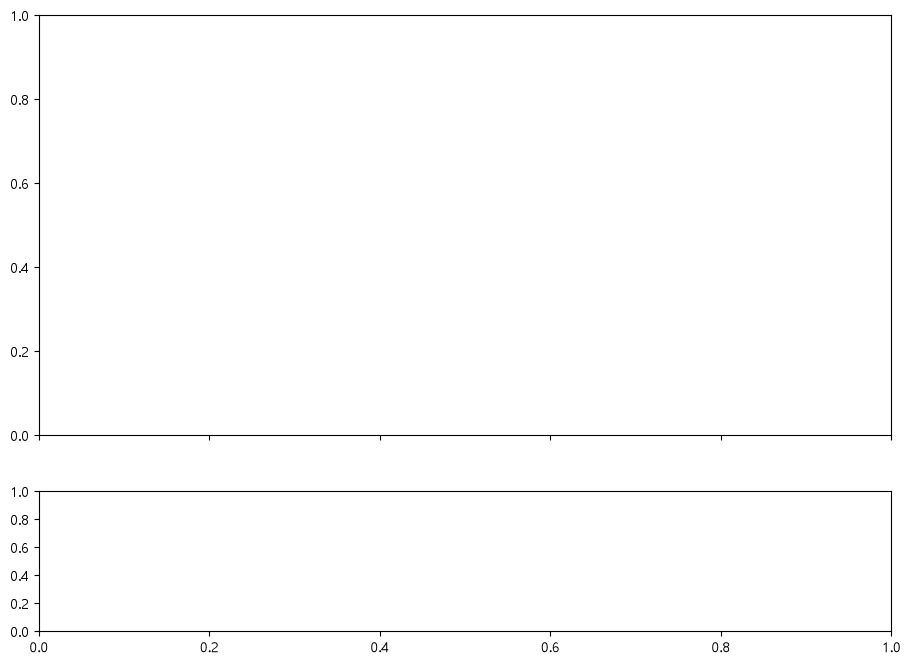

In [55]:
assert early_continuous_model.converged, "모형이 수렴하지 않았습니다."

assert early_continuous_model.nobs == len(early_continuous_7d), (
    "모형 적합 과정에서 사용자가 제외되었습니다."
)

early_continuous_design = early_continuous_model.model.exog

assert np.linalg.matrix_rank(early_continuous_design) == (
    early_continuous_design.shape[1]
), "구분되지 않거나 중복되는 설명변수가 있습니다."

assert np.isfinite(early_continuous_model.params).all(), (
    "추정 계수에 유효하지 않은 값이 있습니다."
)

# 모든 사용자는 모형 적합에 포함
# 그림만 극단적인 수신량의 영향을 줄이기 위해 95백분위까지 표시
early_ping_plot_min = int(
    early_continuous_7d["received_ping_count"].min()
)

early_ping_plot_max = int(
    np.floor(
        early_continuous_7d["received_ping_count"].quantile(0.95)
    )
)

early_ping_grid = np.unique(
    np.rint(
        np.linspace(
            early_ping_plot_min,
            early_ping_plot_max,
            121
        )
    ).astype(int)
)

# 각 사용자의 활동량·친구 수·학교·가입 월은 유지하고,
# 받은 핑 수만 같은 값으로 설정한 뒤 예측확률을 평균
early_curve_rows = []

for early_ping_value in early_ping_grid:

    early_prediction_data = early_continuous_7d.copy()

    early_prediction_data["received_ping_count"] = float(
        early_ping_value
    )
    early_prediction_data["log_received_pings"] = np.log1p(
        early_ping_value
    )

    early_predicted_probabilities = early_continuous_model.predict(
        early_prediction_data
    )

    early_curve_rows.append(
        {
            "received_ping_count": early_ping_value,
            "adjusted_probability": float(
                early_predicted_probabilities.mean()
            )
        }
    )

early_ping_curve_7d = pd.DataFrame(early_curve_rows)

early_ping_curve_7d["adjusted_rate_pct"] = (
    early_ping_curve_7d["adjusted_probability"] * 100
)

early_above_plot_count = int(
    (
        early_continuous_7d["received_ping_count"]
        > early_ping_plot_max
    ).sum()
)

# 보정 확률 곡선과 실제 사용자 분포를 함께 표시
early_curve_fig, early_curve_axes = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

In [56]:
early_curve_axes[0].plot(
    early_ping_curve_7d["received_ping_count"],
    early_ping_curve_7d["adjusted_rate_pct"],
    color="#23689B",
    linewidth=2.5
)

early_overall_rate = (
    early_continuous_7d["d14_retained"].mean() * 100
)

early_curve_axes[0].axhline(
    early_overall_rate,
    color="#888888",
    linestyle="--",
    linewidth=1.2,
    label=f"전체 관찰 재완료율 {early_overall_rate:.2f}%"
)

early_curve_axes[0].set_title(
    "초기 7일 받은 핑 수와 D+14 보정 재완료 확률",
    fontsize=16,
    fontweight="bold",
    pad=15
)

early_curve_axes[0].set_ylabel("보정 재완료 확률")
early_curve_axes[0].yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=100)
)
early_curve_axes[0].set_ylim(bottom=0)
early_curve_axes[0].legend(frameon=False)
early_curve_axes[0].grid(axis="y", alpha=0.2)

early_curve_axes[1].hist(
    early_continuous_7d["received_ping_count"],
    bins=30,
    range=(early_ping_plot_min, early_ping_plot_max),
    color="#83BADB",
    edgecolor="white"
)

early_curve_axes[1].set_xlabel("초기 7일 받은 핑 수")
early_curve_axes[1].set_ylabel("사용자 수")
early_curve_axes[1].set_xlim(
    early_ping_plot_min,
    early_ping_plot_max
)

for early_axis in early_curve_axes:
    early_axis.spines["top"].set_visible(False)
    early_axis.spines["right"].set_visible(False)

early_curve_fig.text(
    0.08,
    0.025,
    "완료 세트 수·활동일 수·종료 시점 친구 수·학교·가입 월을 보정한 탐색적 곡선입니다.\n"
    "사용자별 다른 특성은 유지하고 핑 수를 동일하게 설정한 예측확률의 평균입니다.\n"
    "신뢰구간은 아직 표시하지 않았으며, 곡선의 굴곡이나 점선과의 교차는 확정된 임계점이 아닙니다.",
    fontsize=9,
    color="#555555",
    linespacing=1.5
)

early_curve_fig.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()

print(f"분석 사용자: {len(early_continuous_7d):,}명")
print(f"학교 수: {early_continuous_7d['school_group'].nunique()}개")
print(
    f"그림 표시 범위: 핑 {early_ping_plot_min:,}"
    f"~{early_ping_plot_max:,}개"
)
print(
    f"표시 범위 초과 사용자 {early_above_plot_count:,}명도 "
    "모형 적합에는 포함했습니다."
)

분석 사용자: 4,812명
학교 수: 10개
그림 표시 범위: 핑 0~383개
표시 범위 초과 사용자 241명도 모형 적합에는 포함했습니다.


**해석:** 원본에서 초기 24시간 수신량에는 일관된 증가가 없었다. 초기 7일의 단순 구간 비교에는 증가가 보였지만,
활동량·친구 규모·학교·가입 월을 보정한 곡선에서는 일관된 증가 관계가 유지되지 않았다.
따라서 더 가까운 시점인 D7~D13의 수신 경험을 별도로 본다.

### 3-2. D7~D13 수신 핑과 D14 재완료
이 구간은 UTC 달력 기준 정확히 7일이며 결과는 바로 다음 날(D14) 하루다.
보정은 D7 이전 완료량·활동일·친구 수 및 학교·가입 월을 사용한다.

In [57]:
# 13. 날짜 기준 D7~D13 받은 핑과 D14 재완료 분석 데이터 생성

# 첫 완료 날짜를 D0로 정의
early_calendar_users = early_model_users[
    [
        "user_id",
        "school_id",
        "signup_at",
        "first_finished_at",
        "d14_start",
        "d14_end",
        "d14_retained"
    ]
].copy()

early_calendar_users["d0_start"] = (
    early_calendar_users["first_finished_at"]
    .dt.tz_convert(early_date_timezone)
    .dt.normalize()
)

early_calendar_users["d7_start"] = (
    early_calendar_users["d0_start"]
    + pd.Timedelta(days=7)
)

assert (
    early_calendar_users["d14_start"]
    - early_calendar_users["d7_start"]
).eq(pd.Timedelta(days=7)).all(), (
    "받은 핑 관찰 기간이 정확히 7일이 아닙니다."
)

# 1. 첫 완료 시각부터 D7 시작 직전까지의 질문 활동
early_calendar_activity = early_valid_sets[
    ["user_id", "questionset_id", "estimated_finished_at"]
].merge(
    early_calendar_users[
        ["user_id", "first_finished_at", "d7_start"]
    ],
    on="user_id",
    how="inner",
    validate="many_to_one"
)

early_calendar_activity = early_calendar_activity.loc[
    (
        early_calendar_activity["estimated_finished_at"]
        >= early_calendar_activity["first_finished_at"]
    )
    & (
        early_calendar_activity["estimated_finished_at"]
        < early_calendar_activity["d7_start"]
    )
].copy()

# 활동일도 같은 시간대의 달력 날짜로 계산
early_calendar_activity["activity_date"] = (
    early_calendar_activity["estimated_finished_at"]
    .dt.tz_convert(early_date_timezone)
    .dt.normalize()
)

early_calendar_activity_summary = (
    early_calendar_activity
    .groupby("user_id", as_index=False)
    .agg(
        baseline_completed_sets=("questionset_id", "nunique"),
        baseline_active_days=("activity_date", "nunique")
    )
)

# 2. D7 시작 직전의 추정 친구 수
early_calendar_friends = early_friend_links.merge(
    early_calendar_users[["user_id", "d7_start"]],
    on="user_id",
    how="inner",
    validate="many_to_one"
)

early_calendar_friends = early_calendar_friends.loc[
    early_calendar_friends["estimated_friend_at"]
    < early_calendar_friends["d7_start"]
]

early_calendar_friend_summary = (
    early_calendar_friends
    .groupby("user_id", as_index=False)
    .agg(
        baseline_friend_count=("friend_user_id", "nunique")
    )
)

In [58]:
# 3. D7 시작부터 D14 시작 직전까지의 받은 핑
early_calendar_pings = early_received_votes.merge(
    early_calendar_users[["user_id", "d7_start", "d14_start"]],
    left_on="recipient_user_id",
    right_on="user_id",
    how="inner",
    validate="many_to_one"
)

early_calendar_pings = early_calendar_pings.loc[
    (
        early_calendar_pings["created_at"]
        >= early_calendar_pings["d7_start"]
    )
    & (
        early_calendar_pings["created_at"]
        < early_calendar_pings["d14_start"]
    )
].copy()

early_calendar_ping_summary = (
    early_calendar_pings
    .groupby("user_id", as_index=False)
    .agg(
        received_ping_count=("recipient_user_id", "size"),
        unique_ping_senders=("sender_user_id", "nunique")
    )
)

# 4. 사용자별 분석 데이터 결합
early_calendar_data = (
    early_calendar_users
    .merge(
        early_calendar_activity_summary,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        early_calendar_friend_summary,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        early_calendar_ping_summary,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

assert early_calendar_data[
    ["baseline_completed_sets", "baseline_active_days"]
].notna().all().all(), "첫 주 활동량이 누락되었습니다."

early_calendar_zero_columns = [
    "baseline_friend_count",
    "received_ping_count",
    "unique_ping_senders"
]

early_calendar_data[early_calendar_zero_columns] = (
    early_calendar_data[early_calendar_zero_columns]
    .fillna(0)
    .astype(int)
)

early_calendar_data[
    ["baseline_completed_sets", "baseline_active_days"]
] = early_calendar_data[
    ["baseline_completed_sets", "baseline_active_days"]
].astype(int)

assert early_calendar_data["baseline_active_days"].between(
    1, 7
).all(), "첫 주 활동일 수를 확인해야 합니다."

assert len(early_calendar_data) == len(early_model_users)
assert early_calendar_data["user_id"].is_unique

# 5. 받은 핑 구간별 단순 재완료율
early_calendar_positive = early_calendar_data.loc[
    early_calendar_data["received_ping_count"] > 0,
    "received_ping_count"
]

In [59]:
early_calendar_quantiles = early_calendar_positive.quantile(
    [0.25, 0.50, 0.75]
).to_numpy()

assert (
    0 < early_calendar_quantiles[0]
    < early_calendar_quantiles[1]
    < early_calendar_quantiles[2]
), "핑 구간 경계가 겹칩니다."

early_calendar_data["ping_group"] = pd.cut(
    early_calendar_data["received_ping_count"],
    bins=[-np.inf, 0, *early_calendar_quantiles, np.inf],
    labels=[
        "수신 없음",
        "수신 하위 구간",
        "수신 중하위 구간",
        "수신 중상위 구간",
        "수신 상위 구간"
    ]
)

early_calendar_summary = (
    early_calendar_data
    .groupby("ping_group", observed=True)
    .agg(
        user_count=("user_id", "nunique"),
        min_pings=("received_ping_count", "min"),
        max_pings=("received_ping_count", "max"),
        retained_users=("d14_retained", "sum"),
        retention_rate=("d14_retained", "mean"),
        mean_completed_sets=("baseline_completed_sets", "mean"),
        mean_active_days=("baseline_active_days", "mean"),
        mean_friends=("baseline_friend_count", "mean")
    )
    .reset_index()
)

early_calendar_summary["retention_rate"] *= 100

assert early_calendar_summary["user_count"].sum() == len(
    early_model_users
)

assert early_calendar_summary["retained_users"].sum() == (
    early_model_users["d14_retained"].sum()
)

print(f"날짜 기준: {early_date_timezone}")
print(f"분석 사용자: {len(early_calendar_data):,}명")
print("첫 주 활동: 첫 완료 시각부터 D7 시작 직전")
print("친구 수: D7 시작 직전의 추정 친구 수")
print("받은 핑: D7~D13, 모든 사용자에게 정확히 7일")
print("결과: D14 하루의 질문세트 재완료 여부")

display(
    early_calendar_summary.rename(
        columns={
            "ping_group": "받은 핑 구간",
            "user_count": "사용자 수",
            "min_pings": "최소 받은 핑",
            "max_pings": "최대 받은 핑",
            "retained_users": "D14 재완료 사용자 수",
            "retention_rate": "D14 재완료율(%)",
            "mean_completed_sets": "첫 주 평균 완료 세트 수",
            "mean_active_days": "첫 주 평균 활동일 수",
            "mean_friends": "D7 시작 직전 평균 추정 친구 수"
        }
    ).round(2)
)

날짜 기준: UTC
분석 사용자: 4,812명
첫 주 활동: 첫 완료 시각부터 D7 시작 직전
친구 수: D7 시작 직전의 추정 친구 수
받은 핑: D7~D13, 모든 사용자에게 정확히 7일
결과: D14 하루의 질문세트 재완료 여부


,받은 핑 구간,사용자 수,최소 받은 핑,최대 받은 핑,D14 재완료 사용자 수,D14 재완료율(%),첫 주 평균 완료 세트 수,첫 주 평균 활동일 수,D7 시작 직전 평균 추정 친구 수
0,수신 없음,120,0,0,9,7.5,6.88,3.08,11.53
1,수신 하위 구간,1219,1,13,136,11.16,15.65,4.64,26.17
2,수신 중하위 구간,1183,14,28,191,16.15,22.98,5.47,37.78
3,수신 중상위 구간,1145,29,53,217,18.95,26.45,5.81,48.88
4,수신 상위 구간,1145,54,332,329,28.73,28.85,6.13,57.83


In [60]:
# 14. 날짜 기준 분석의 구간별 보정 재완료 확률 비교

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import bs

early_calendar_model_data = early_calendar_data.copy()

early_calendar_required = [
    "user_id",
    "school_id",
    "signup_at",
    "ping_group",
    "baseline_completed_sets",
    "baseline_active_days",
    "baseline_friend_count",
    "d14_retained"
]

assert early_calendar_model_data[
    early_calendar_required
].notna().all().all(), "분석 변수에 누락값이 있습니다."

assert early_calendar_model_data["user_id"].is_unique, (
    "같은 사용자가 중복으로 포함되어 있습니다."
)

early_calendar_model_data["d14_retained"] = (
    early_calendar_model_data["d14_retained"].astype(int)
)

for early_column in [
    "baseline_completed_sets",
    "baseline_active_days",
    "baseline_friend_count"
]:
    early_calendar_model_data[early_column] = (
        early_calendar_model_data[early_column].astype(float)
    )

early_calendar_model_data["log_completed_sets"] = np.log1p(
    early_calendar_model_data["baseline_completed_sets"]
)

early_calendar_model_data["log_friend_count"] = np.log1p(
    early_calendar_model_data["baseline_friend_count"]
)

early_calendar_model_data["school_group"] = (
    early_calendar_model_data["school_id"].astype(str)
)

early_calendar_model_data["signup_month"] = (
    pd.to_datetime(early_calendar_model_data["signup_at"], utc=True)
    .dt.tz_convert(early_date_timezone)
    .dt.strftime("%Y-%m")
)

early_calendar_group_order = [
    "수신 없음",
    "수신 하위 구간",
    "수신 중하위 구간",
    "수신 중상위 구간",
    "수신 상위 구간"
]

early_calendar_model_data["ping_group"] = pd.Categorical(
    early_calendar_model_data["ping_group"],
    categories=early_calendar_group_order
)

early_calendar_ping_term = (
    'C(ping_group, Treatment(reference="수신 하위 구간"))'
)

early_calendar_baseline_terms = (
    "C(baseline_active_days)"
    " + bs(log_completed_sets, df=4, degree=3)"
    " + bs(log_friend_count, df=4, degree=3)"
)

early_calendar_formulas = {
    "보정 전": (
        f"d14_retained ~ {early_calendar_ping_term}"
    ),
    "첫 주 활동·친구 보정": (
        f"d14_retained ~ {early_calendar_ping_term}"
        f" + {early_calendar_baseline_terms}"
    ),
    "학교·가입 월 추가 보정": (
        f"d14_retained ~ {early_calendar_ping_term}"
        f" + {early_calendar_baseline_terms}"
        " + C(school_group)"
        " + C(signup_month)"
    )
}

In [61]:
early_calendar_models = {}
early_calendar_adjusted_rows = []
early_calendar_fit_rows = []

for early_model_name, early_formula in early_calendar_formulas.items():

    early_fit = smf.glm(
        formula=early_formula,
        data=early_calendar_model_data,
        family=sm.families.Binomial(),
        missing="raise"
    ).fit(maxiter=200)

    assert early_fit.converged, (
        f"{early_model_name}: 모형이 수렴하지 않았습니다."
    )

    assert early_fit.nobs == len(early_calendar_model_data), (
        f"{early_model_name}: 분석 대상이 변경되었습니다."
    )

    assert np.isfinite(early_fit.params).all(), (
        f"{early_model_name}: 추정 계수에 유효하지 않은 값이 있습니다."
    )

    early_design = early_fit.model.exog

    assert np.linalg.matrix_rank(early_design) == early_design.shape[1], (
        f"{early_model_name}: 설명변수 간 중복을 확인해야 합니다."
    )

    early_calendar_models[early_model_name] = early_fit

    early_calendar_fit_rows.append(
        {
            "모형": early_model_name,
            "분석 사용자 수": int(early_fit.nobs),
            "수렴 여부": bool(early_fit.converged)
        }
    )

    # 다른 특성은 유지하고 핑 구간만 바꾼 뒤 예측확률을 평균
    for early_group in early_calendar_group_order:

        early_prediction_data = early_calendar_model_data.copy()

        early_prediction_data["ping_group"] = pd.Categorical(
            [early_group] * len(early_prediction_data),
            categories=early_calendar_group_order
        )

        early_probability = float(
            early_fit.predict(early_prediction_data).mean()
        )

        early_calendar_adjusted_rows.append(
            {
                "모형": early_model_name,
                "받은 핑 구간": early_group,
                "재완료 확률(%)": early_probability * 100
            }
        )

early_calendar_adjusted = pd.DataFrame(
    early_calendar_adjusted_rows
)

early_calendar_adjusted_table = (
    early_calendar_adjusted
    .pivot(
        index="받은 핑 구간",
        columns="모형",
        values="재완료 확률(%)"
    )
    .reindex(
        index=early_calendar_group_order,
        columns=list(early_calendar_formulas)
    )
)

early_calendar_difference = (
    early_calendar_adjusted_table.loc["수신 상위 구간"]
    - early_calendar_adjusted_table.loc["수신 하위 구간"]
)

In [62]:
display(pd.DataFrame(early_calendar_fit_rows))

print("받은 핑 구간별 재완료 확률: 단위 %")
print("활동량은 D0~D6, 친구 수는 D7 시작 직전 기준입니다.")
display(early_calendar_adjusted_table.round(2))

print("상위 구간과 하위 구간의 재완료 확률 차이")
display(
    early_calendar_difference
    .rename("상위−하위 차이(%p)")
    .to_frame()
    .round(2)
)

,모형,분석 사용자 수,수렴 여부
0,보정 전,4812,True
1,첫 주 활동·친구 보정,4812,True
2,학교·가입 월 추가 보정,4812,True


받은 핑 구간별 재완료 확률: 단위 %
활동량은 D0~D6, 친구 수는 D7 시작 직전 기준입니다.


모형,보정 전,첫 주 활동·친구 보정,학교·가입 월 추가 보정
받은 핑 구간,,,
수신 없음,7.50,11.95,15.54
수신 하위 구간,11.16,13.54,15.22
수신 중하위 구간,16.15,15.84,16.39
수신 중상위 구간,18.95,17.88,17.85
수신 상위 구간,28.73,25.45,22.73


상위 구간과 하위 구간의 재완료 확률 차이


,상위−하위 차이(%p)
모형,
보정 전,17.58
첫 주 활동·친구 보정,11.91
학교·가입 월 추가 보정,7.51


In [63]:
# 15. 학교 내 유사성을 반영한 상위−하위 재완료 확률 차이 검정

from patsy import build_design_matrices
from statsmodels.stats.sandwich_covariance import cov_cluster
from scipy.stats import t

early_final_model = early_calendar_models["학교·가입 월 추가 보정"]
early_inference_data = early_calendar_model_data.copy()

assert int(early_final_model.nobs) == len(early_inference_data)
assert early_final_model.model.data.row_labels.equals(
    early_inference_data.index
), "모형 적합 자료와 검정 자료의 행 순서가 다릅니다."

early_school_codes, early_school_levels = pd.factorize(
    early_inference_data["school_group"],
    sort=True
)

early_school_count = len(early_school_levels)
assert early_school_count >= 2, "학교가 2개 이상 필요합니다."

# 학교 단위 군집 공분산과 소표본 보정
early_cluster_cov = np.asarray(
    cov_cluster(
        early_final_model,
        early_school_codes,
        use_correction=True
    )
)

assert np.isfinite(early_cluster_cov).all(), (
    "공분산 계산 결과를 확인해야 합니다."
)

# 적합에 사용한 수식과 데이터로 변수 구성 정보를 복원
from patsy import dmatrices

early_rebuilt_y, early_rebuilt_x = dmatrices(
    early_final_model.model.formula,
    data=early_inference_data,
    return_type="dataframe",
    NA_action="raise"
)

# 복원된 행렬이 실제 모형 적합에 사용된 행렬과 같은지 검증
assert list(early_rebuilt_x.columns) == list(
    early_final_model.model.exog_names
), "복원한 설명변수의 이름 또는 순서가 다릅니다."

assert early_rebuilt_x.index.equals(early_inference_data.index), (
    "복원 과정에서 사용자 행 순서가 변경되었습니다."
)

np.testing.assert_allclose(
    early_rebuilt_x.to_numpy(dtype=float),
    np.asarray(early_final_model.model.exog, dtype=float),
    rtol=1e-10,
    atol=1e-10,
    err_msg="복원한 설명변수 행렬이 모형 적합 당시와 다릅니다."
)

np.testing.assert_allclose(
    early_rebuilt_y.to_numpy(dtype=float).ravel(),
    np.asarray(early_final_model.model.endog, dtype=float).ravel(),
    rtol=1e-10,
    atol=1e-10,
    err_msg="복원한 결과변수가 모형 적합 당시와 다릅니다."
)

early_design_info = early_rebuilt_x.design_info
early_beta = np.asarray(early_final_model.params)

early_group_probabilities = {}
early_group_gradients = {}

for early_group in ["수신 하위 구간", "수신 상위 구간"]:

    early_predict_data = early_inference_data.copy()
    early_predict_data["ping_group"] = pd.Categorical(
        [early_group] * len(early_predict_data),
        categories=early_calendar_group_order
    )

    # 적합 때 사용한 범주와 스플라인 설정을 그대로 유지
    early_predict_matrix = np.asarray(
        build_design_matrices(
            [early_design_info],
            early_predict_data
        )[0]
    )

    early_probabilities = (
        early_final_model.model.family.link.inverse(
            early_predict_matrix @ early_beta
        )
    )

    early_group_probabilities[early_group] = float(
        early_probabilities.mean()
    )

    # 평균 예측확률의 계수에 대한 변화량
    early_group_gradients[early_group] = (
        early_predict_matrix
        * (
            early_probabilities
            * (1 - early_probabilities)
        )[:, None]
    ).mean(axis=0)

In [64]:
early_probability_difference = (
    early_group_probabilities["수신 상위 구간"]
    - early_group_probabilities["수신 하위 구간"]
)

early_difference_gradient = (
    early_group_gradients["수신 상위 구간"]
    - early_group_gradients["수신 하위 구간"]
)

early_difference_variance = float(
    early_difference_gradient
    @ early_cluster_cov
    @ early_difference_gradient
)

assert early_difference_variance > 0, (
    "차이의 분산이 양수가 아닙니다. 모형을 확인해야 합니다."
)

early_difference_se = np.sqrt(early_difference_variance)
early_inference_df = early_school_count - 1
early_critical_value = t.ppf(0.975, df=early_inference_df)

early_difference_lower = (
    early_probability_difference
    - early_critical_value * early_difference_se
)
early_difference_upper = (
    early_probability_difference
    + early_critical_value * early_difference_se
)

early_difference_p = float(
    2 * t.sf(
        abs(early_probability_difference / early_difference_se),
        df=early_inference_df
    )
)

early_inference_result = pd.DataFrame(
    [{
        "학교 수": early_school_count,
        "하위 보정 확률(%)":
            early_group_probabilities["수신 하위 구간"] * 100,
        "상위 보정 확률(%)":
            early_group_probabilities["수신 상위 구간"] * 100,
        "상위−하위 차이(%p)": early_probability_difference * 100,
        "95% 신뢰구간 하한(%p)": early_difference_lower * 100,
        "95% 신뢰구간 상한(%p)": early_difference_upper * 100
    }]
)

display(early_inference_result.round(2))
print(f"양측 유의확률: {early_difference_p:.6g}")
print(f"학교 단위 군집 보정, t 분포 자유도: {early_inference_df}")
print("신뢰구간은 평균 예측확률 차이에 대한 근사 구간입니다.")
print("여러 기간과 분석 방법을 살펴본 탐색적 결과로 해석합니다.")

,학교 수,하위 보정 확률(%),상위 보정 확률(%),상위−하위 차이(%p),95% 신뢰구간 하한(%p),95% 신뢰구간 상한(%p)
0,10,15.22,22.73,7.51,3.59,11.43


양측 유의확률: 0.00188727
학교 단위 군집 보정, t 분포 자유도: 9
신뢰구간은 평균 예측확률 차이에 대한 근사 구간입니다.
여러 기간과 분석 방법을 살펴본 탐색적 결과로 해석합니다.


Text(0.5, 1.0, '받은 핑 구간별 D14 재완료 확률')

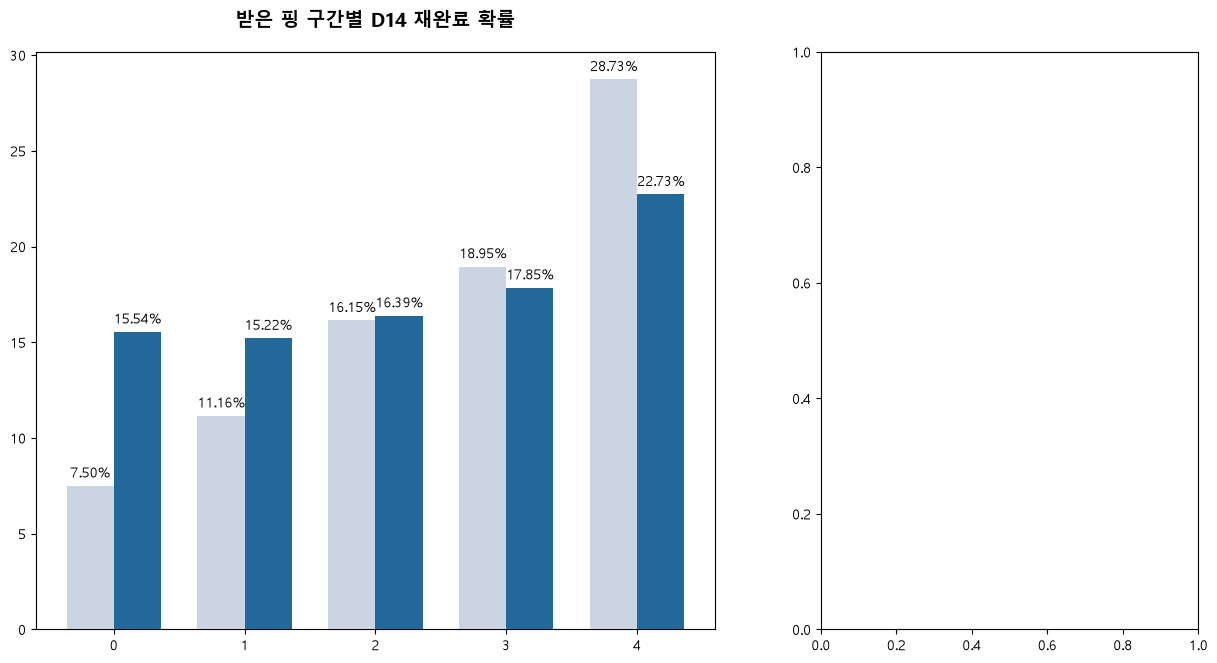

In [65]:
# 16. 받은 핑 구간별 재완료 확률과 검정 결과 시각화

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams["axes.unicode_minus"] = False

early_plot_order = early_calendar_group_order
early_final_model_name = "학교·가입 월 추가 보정"

# 실제 핑 범위와 사용자 수
early_plot_groups = (
    early_calendar_summary
    .set_index("ping_group")
    .reindex(early_plot_order)
)

early_plot_rates = early_calendar_adjusted_table.reindex(
    early_plot_order
)

early_plot_labels = []

for early_group in early_plot_order:
    early_row = early_plot_groups.loc[early_group]

    if early_row["max_pings"] == 0:
        early_range_label = "0개"
    else:
        early_range_label = (
            f"{int(early_row['min_pings']):,}"
            f"~{int(early_row['max_pings']):,}개"
        )

    early_short_label = early_group.replace("수신 ", "").replace(" 구간", "")

    early_plot_labels.append(
        f"{early_short_label}\n"
        f"{early_range_label}\n"
        f"사용자 {int(early_row['user_count']):,}명"
    )

# 앞서 계산한 검정 결과 사용
early_effect_pp = early_probability_difference * 100
early_lower_pp = early_difference_lower * 100
early_upper_pp = early_difference_upper * 100

early_fig, early_axes = plt.subplots(
    1, 2,
    figsize=(15, 7.5),
    gridspec_kw={"width_ratios": [1.8, 1]}
)

# 왼쪽: 보정 전·후 확률
early_positions = np.arange(len(early_plot_order))
early_bar_width = 0.36

for early_offset, early_column, early_color, early_label in [
    (-early_bar_width / 2, "보정 전", "#CBD5E1", "보정 전"),
    (
        early_bar_width / 2,
        early_final_model_name,
        "#23689B",
        "보정 후"
    )
]:
    early_values = early_plot_rates[early_column].to_numpy(dtype=float)

    early_bars = early_axes[0].bar(
        early_positions + early_offset,
        early_values,
        width=early_bar_width,
        color=early_color,
        label=early_label,
        zorder=3
    )

    early_axes[0].bar_label(
        early_bars,
        labels=[f"{value:.2f}%" for value in early_values],
        padding=4,
        fontsize=10
    )

early_axes[0].set_title(
    "받은 핑 구간별 D14 재완료 확률",
    fontsize=14,
    fontweight="bold",
    pad=18
)

In [66]:
early_axes[0].set_xticks(early_positions)
early_axes[0].set_xticklabels(early_plot_labels, fontsize=10)
early_axes[0].set_ylabel("D14 질문세트 재완료 확률")
early_axes[0].yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=100)
)

early_max_rate = early_plot_rates[
    ["보정 전", early_final_model_name]
].to_numpy(dtype=float).max()

early_axes[0].set_ylim(0, np.ceil((early_max_rate + 5) / 5) * 5)
early_axes[0].legend(frameon=False, loc="upper left")
early_axes[0].grid(axis="y", alpha=0.2)
early_axes[0].set_axisbelow(True)

# 오른쪽: 상위−하위 확률 차이의 신뢰구간
early_axes[1].axvline(
    0,
    color="#888888",
    linestyle="--",
    linewidth=1.3,
    label="차이 없음"
)

early_axes[1].errorbar(
    early_effect_pp,
    0,
    xerr=[
        [early_effect_pp - early_lower_pp],
        [early_upper_pp - early_effect_pp]
    ],
    fmt="o",
    color="#23689B",
    markersize=9,
    capsize=8,
    elinewidth=2.5
)

early_axes[1].text(
    early_effect_pp,
    0.18,
    f"{early_effect_pp:+.2f}%p",
    ha="center",
    fontsize=17,
    fontweight="bold",
    color="#23689B"
)

early_axes[1].text(
    0.5,
    0.16,
    f"95% 신뢰구간: {early_lower_pp:.2f}~{early_upper_pp:.2f}%p\n"
    f"양측 p = {early_difference_p:.4f}",
    transform=early_axes[1].transAxes,
    ha="center",
    fontsize=11,
    linespacing=1.7
)

early_axes[1].set_title(
    "보정 후 상위−하위 차이\n상위 54개 이상 − 하위 1~13개",
    fontsize=14,
    fontweight="bold",
    pad=18
)

early_axes[1].set_xlabel("재완료 확률 차이(%p)")
early_axes[1].set_yticks([])
early_axes[1].set_ylim(-0.6, 0.6)
early_axes[1].set_xlim(
    min(0, early_lower_pp) - 2,
    max(0, early_upper_pp) + 2
)
early_axes[1].grid(axis="x", alpha=0.2)

for early_ax in early_axes:
    early_ax.spines["top"].set_visible(False)
    early_ax.spines["right"].set_visible(False)

early_axes[1].spines["left"].set_visible(False)

early_fig.suptitle(
    "D7~D13 선택받은 경험과 D14 재완료의 연관성",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

Text(0.5, 0.98, 'D7~D13 선택받은 경험과 D14 재완료의 연관성')

In [67]:
early_fig.text(
    0.05,
    0.035,
    "대상: 10개 학교 사용자 4,812명 | D0: 첫 완료 날짜 | 핑 관찰: D7~D13 | 결과: D14 하루의 질문세트 완료\n"
    "보정: 첫 주 완료 세트 수·활동일 수, D7 시작 직전 추정 친구 수, 학교, 가입 월\n"
    "오른쪽 신뢰구간은 두 집단의 보정 확률 차이에 대한 학교 단위 군집 보정 근사 구간입니다(t 분포 자유도 9).\n"
    "핑 구간은 사용자 분포로 나눈 기준이며 임계점이 아닙니다. 여러 분석을 거친 탐색적 연관성 결과입니다.",
    fontsize=9,
    color="#555555",
    linespacing=1.6
)

early_fig.tight_layout(rect=[0.02, 0.23, 0.99, 0.92])

early_inference_output = Path("outputs") / "early_ping_charts"
early_inference_output.mkdir(parents=True, exist_ok=True)

early_inference_path = (
    early_inference_output / "D7_D13_핑_보정결과_신뢰구간.png"
)


plt.show()
plt.close(early_fig)

**원본 결과:** 0 / 1~13 / 14~28 / 29~53 / 54개 이상 구간의 사용자 수는
120 / 1,219 / 1,183 / 1,145 / 1,145명이다. 보정 전 재완료율은
7.50 / 11.16 / 16.15 / 18.95 / 28.73%였다.
학교·가입 월까지 보정한 확률은 약 15.54 / 15.22 / 16.39 / 17.85 / 22.73%였다.

54개 이상과 1~13개 집단의 보정 차이는 약 **7.51%p**(95% CI 3.59~11.43%p)였다.
학교 10개에 대한 군집 보정 결과로 표본이 적은 군집 수와 미측정 요인의 한계가 남는다.
같은 사용자의 핑 수만 강제로 늘렸을 때 같은 효과가 발생한다는 뜻은 아니다.

### 3-3. 목표 20개는 안정적인 임계점인가?
곡선의 유연성을 바꿔 형태가 유지되는지 확인한다. 20개는 운영상의 실험 후보이며 분석에서 증명된 최적점이 아니다.

In [68]:
# 17. D7~D13 받은 핑 수의 보정 곡선과 목표 후보 탐색

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_cluster
from patsy import bs, dmatrices, build_design_matrices
from scipy.stats import t
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["axes.unicode_minus"] = False

early_target_data = early_calendar_model_data.copy()

early_target_data["received_ping_count"] = (
    early_target_data["received_ping_count"].astype(float)
)
early_target_data["log_received_pings"] = np.log1p(
    early_target_data["received_ping_count"]
)

# 기존 보정변수는 유지하고 핑을 연속형으로 분석
early_target_formula = (
    "d14_retained ~ "
    "bs(log_received_pings, df=4, degree=3)"
    " + C(baseline_active_days)"
    " + bs(log_completed_sets, df=4, degree=3)"
    " + bs(log_friend_count, df=4, degree=3)"
    " + C(school_group)"
    " + C(signup_month)"
)

early_target_model = smf.glm(
    formula=early_target_formula,
    data=early_target_data,
    family=sm.families.Binomial(),
    missing="raise"
).fit(maxiter=200)

assert early_target_model.converged, "모형이 수렴하지 않았습니다."
assert early_target_model.nobs == len(early_target_data), (
    "분석 과정에서 사용자가 제외되었습니다."
)
assert np.isfinite(early_target_model.params).all()

# 설계 정보를 복원하고 적합 당시와 같은지 확인
early_target_y, early_target_x = dmatrices(
    early_target_formula,
    data=early_target_data,
    return_type="dataframe",
    NA_action="raise"
)

assert early_target_x.index.equals(early_target_data.index)
assert list(early_target_x.columns) == list(
    early_target_model.model.exog_names
)

np.testing.assert_allclose(
    early_target_x.to_numpy(),
    early_target_model.model.exog,
    rtol=1e-10,
    atol=1e-10
)
np.testing.assert_allclose(
    early_target_y.to_numpy().ravel(),
    early_target_model.model.endog,
    rtol=1e-10,
    atol=1e-10
)

assert np.linalg.matrix_rank(early_target_x.to_numpy()) == (
    early_target_x.shape[1]
), "설명변수 간 중복을 확인해야 합니다."

early_target_design_info = early_target_x.design_info

# 학교 단위 군집 공분산
early_target_school_codes, early_target_schools = pd.factorize(
    early_target_data["school_group"],
    sort=True
)

early_target_cov = np.asarray(
    cov_cluster(
        early_target_model,
        early_target_school_codes,
        use_correction=True
    )
)

In [69]:
assert np.isfinite(early_target_cov).all()

early_target_df = len(early_target_schools) - 1
early_target_critical = t.ppf(0.975, df=early_target_df)
early_target_beta = np.asarray(early_target_model.params)

# 모형 적합에는 전체 사용자를 사용하고 그림은 95백분위까지 표시
early_target_min = int(early_target_data["received_ping_count"].min())
early_target_max = int(
    np.floor(
        early_target_data["received_ping_count"].quantile(0.95)
    )
)

early_target_candidates = [
    value for value in [10, 20, 30, 40, 50, 60]
    if early_target_min <= value <= early_target_max
]

early_target_grid = np.unique(
    np.concatenate([
        np.rint(
            np.linspace(early_target_min, early_target_max, 101)
        ).astype(int),
        np.asarray(early_target_candidates, dtype=int)
    ])
)

early_target_rows = []
early_target_gradients = {}

for early_ping_value in early_target_grid:

    early_target_prediction = early_target_data.copy()
    early_target_prediction["log_received_pings"] = np.log1p(
        early_ping_value
    )
    early_target_prediction["received_ping_count"] = float(
        early_ping_value
    )

    early_target_matrix = np.asarray(
        build_design_matrices(
            [early_target_design_info],
            early_target_prediction
        )[0]
    )

    early_target_probabilities = (
        early_target_model.model.family.link.inverse(
            early_target_matrix @ early_target_beta
        )
    )

    early_target_probability = float(
        early_target_probabilities.mean()
    )

    early_target_gradient = (
        early_target_matrix
        * (
            early_target_probabilities
            * (1 - early_target_probabilities)
        )[:, None]
    ).mean(axis=0)

    early_target_variance = float(
        early_target_gradient
        @ early_target_cov
        @ early_target_gradient
    )

    assert early_target_variance >= -1e-12, (
        "확률의 분산 계산을 확인해야 합니다."
    )

    early_target_se = np.sqrt(max(early_target_variance, 0))

    # 확률 범위를 벗어나지 않도록 평균 확률의 로짓 척도에서 구간 계산
    early_target_logit = np.log(
        early_target_probability / (1 - early_target_probability)
    )
    early_target_logit_se = (
        early_target_se
        / (early_target_probability * (1 - early_target_probability))
    )

    early_target_lower = (
        early_target_model.model.family.link.inverse(
            early_target_logit
            - early_target_critical * early_target_logit_se
        )
    )
    early_target_upper = (
        early_target_model.model.family.link.inverse(
            early_target_logit
            + early_target_critical * early_target_logit_se
        )
    )

    early_target_gradients[int(early_ping_value)] = early_target_gradient

    early_target_rows.append({
        "ping_count": int(early_ping_value),
        "adjusted_rate": early_target_probability * 100,
        "lower": float(early_target_lower) * 100,
        "upper": float(early_target_upper) * 100,
        "nearby_users": int(
            early_target_data["received_ping_count"].between(
                max(0, early_ping_value - 5),
                early_ping_value + 5
            ).sum()
        )
    })

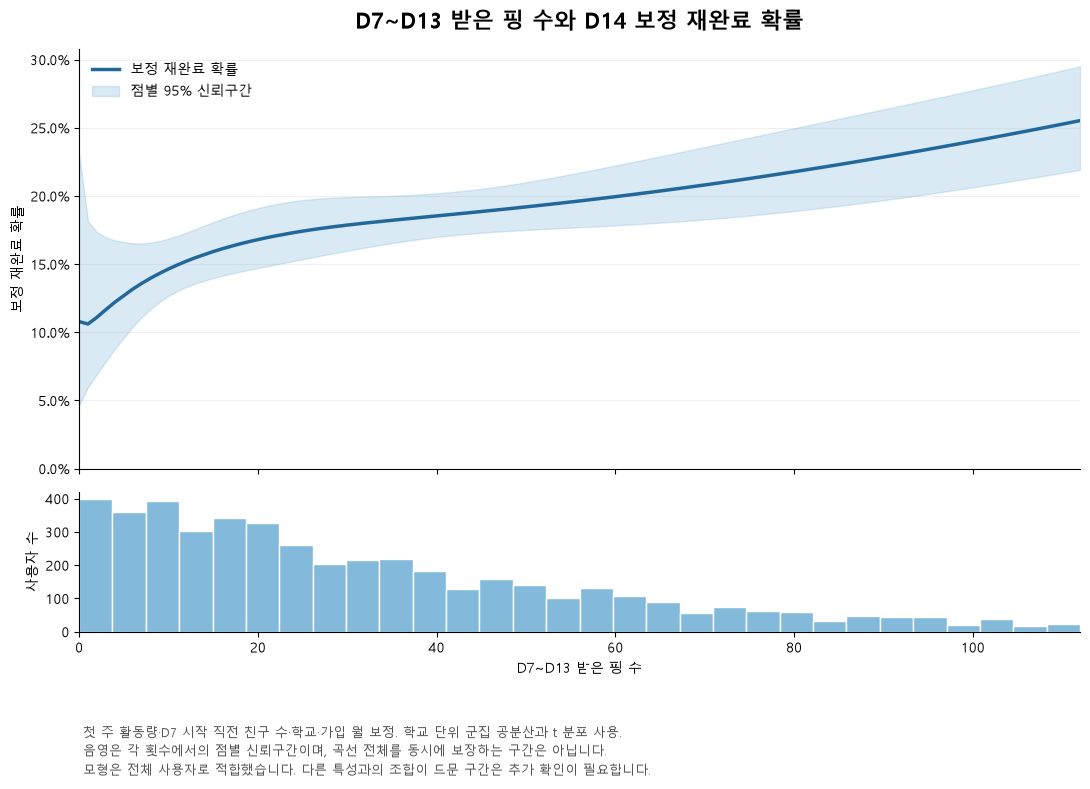

,비교용 핑 횟수,보정 재완료 확률(%),95% 신뢰구간 하한(%),95% 신뢰구간 상한(%),해당 횟수 전후 5개 이내 사용자 수
9,10,14.64,12.67,16.87,1077
18,20,16.80,14.71,19.11,864
27,30,17.86,15.98,19.92,651
36,40,18.53,16.99,20.19,524
45,50,19.20,17.51,21.00,401
54,60,19.95,17.84,22.23,316


In [70]:
early_target_curve = pd.DataFrame(early_target_rows)

# 시각화
early_target_fig, early_target_axes = plt.subplots(
    2, 1,
    figsize=(11, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

early_target_axes[0].plot(
    early_target_curve["ping_count"],
    early_target_curve["adjusted_rate"],
    color="#23689B",
    linewidth=2.5,
    label="보정 재완료 확률"
)

early_target_axes[0].fill_between(
    early_target_curve["ping_count"].to_numpy(),
    early_target_curve["lower"].to_numpy(),
    early_target_curve["upper"].to_numpy(),
    color="#83BADB",
    alpha=0.3,
    label="점별 95% 신뢰구간"
)

early_target_axes[0].set_title(
    "D7~D13 받은 핑 수와 D14 보정 재완료 확률",
    fontsize=16,
    fontweight="bold",
    pad=15
)
early_target_axes[0].set_ylabel("보정 재완료 확률")
early_target_axes[0].yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=100)
)
early_target_axes[0].set_ylim(bottom=0)
early_target_axes[0].legend(frameon=False)
early_target_axes[0].grid(axis="y", alpha=0.2)

early_target_axes[1].hist(
    early_target_data["received_ping_count"],
    bins=30,
    range=(early_target_min, early_target_max),
    color="#83BADB",
    edgecolor="white"
)
early_target_axes[1].set_ylabel("사용자 수")
early_target_axes[1].set_xlabel("D7~D13 받은 핑 수")
early_target_axes[1].set_xlim(early_target_min, early_target_max)

for early_axis in early_target_axes:
    early_axis.spines["top"].set_visible(False)
    early_axis.spines["right"].set_visible(False)

early_target_fig.text(
    0.08, 0.025,
    "첫 주 활동량·D7 시작 직전 친구 수·학교·가입 월 보정. "
    "학교 단위 군집 공분산과 t 분포 사용.\n"
    "음영은 각 횟수에서의 점별 신뢰구간이며, 곡선 전체를 동시에 보장하는 구간은 아닙니다.\n"
    "모형은 전체 사용자로 적합했습니다. 다른 특성과의 조합이 드문 구간은 추가 확인이 필요합니다.",
    fontsize=9,
    color="#555555",
    linespacing=1.5
)

early_target_fig.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()
plt.close(early_target_fig)

# 목표 후보 비교용 표
early_target_candidate_table = early_target_curve.loc[
    early_target_curve["ping_count"].isin(early_target_candidates)
].copy()

display(
    early_target_candidate_table.rename(
        columns={
            "ping_count": "비교용 핑 횟수",
            "adjusted_rate": "보정 재완료 확률(%)",
            "lower": "95% 신뢰구간 하한(%)",
            "upper": "95% 신뢰구간 상한(%)",
            "nearby_users": "해당 횟수 전후 5개 이내 사용자 수"
        }
    ).round(2)
)

In [71]:
print("표의 횟수는 비교용이며 확정된 목표나 임계점이 아닙니다.")
print("전후 5개 이내 사용자 수는 구간끼리 중복될 수 있습니다.")

표의 횟수는 비교용이며 확정된 목표나 임계점이 아닙니다.
전후 5개 이내 사용자 수는 구간끼리 중복될 수 있습니다.


In [72]:
# 18. 곡선 설정에 따른 목표 수신량 후보의 안정성 확인

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import bs
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["axes.unicode_minus"] = False

early_sensitivity_data = early_target_data.copy()

early_sensitivity_models = {}
early_sensitivity_rows = []

early_sensitivity_min = int(
    early_sensitivity_data["received_ping_count"].min()
)
early_sensitivity_max = int(
    np.floor(
        early_sensitivity_data["received_ping_count"].quantile(0.95)
    )
)

early_sensitivity_checkpoints = [
    value for value in [10, 20, 30, 40, 50, 60]
    if early_sensitivity_min <= value <= early_sensitivity_max
]

early_sensitivity_grid = np.unique(
    np.concatenate([
        np.rint(
            np.linspace(
                early_sensitivity_min,
                early_sensitivity_max,
                81
            )
        ).astype(int),
        np.asarray(early_sensitivity_checkpoints, dtype=int)
    ])
)

for early_spline_df in [3, 4, 5]:

    # 받은 핑의 곡선 유연성만 변경
    # 다른 설명변수와 보정 방식은 동일하게 유지
    early_sensitivity_formula = (
        "d14_retained ~ "
        f"bs(log_received_pings, df={early_spline_df}, degree=3)"
        " + C(baseline_active_days)"
        " + bs(log_completed_sets, df=4, degree=3)"
        " + bs(log_friend_count, df=4, degree=3)"
        " + C(school_group)"
        " + C(signup_month)"
    )

    early_sensitivity_fit = smf.glm(
        formula=early_sensitivity_formula,
        data=early_sensitivity_data,
        family=sm.families.Binomial(),
        missing="raise"
    ).fit(maxiter=200)

    assert early_sensitivity_fit.converged, (
        f"유연성 {early_spline_df}: 모형이 수렴하지 않았습니다."
    )
    assert early_sensitivity_fit.nobs == len(early_sensitivity_data), (
        "분석 사용자 수가 변경되었습니다."
    )
    assert np.isfinite(early_sensitivity_fit.params).all(), (
        "추정 계수에 유효하지 않은 값이 있습니다."
    )

    early_sensitivity_design = early_sensitivity_fit.model.exog
    assert np.linalg.matrix_rank(early_sensitivity_design) == (
        early_sensitivity_design.shape[1]
    ), "설명변수 간 중복을 확인해야 합니다."

    early_sensitivity_models[early_spline_df] = early_sensitivity_fit

    for early_ping_value in early_sensitivity_grid:

        early_sensitivity_prediction = early_sensitivity_data.copy()
        early_sensitivity_prediction["received_ping_count"] = float(
            early_ping_value
        )
        early_sensitivity_prediction["log_received_pings"] = np.log1p(
            early_ping_value
        )

        early_sensitivity_rate = float(
            early_sensitivity_fit.predict(
                early_sensitivity_prediction
            ).mean() * 100
        )

        early_sensitivity_rows.append({
            "spline_df": early_spline_df,
            "ping_count": int(early_ping_value),
            "adjusted_rate": early_sensitivity_rate
        })

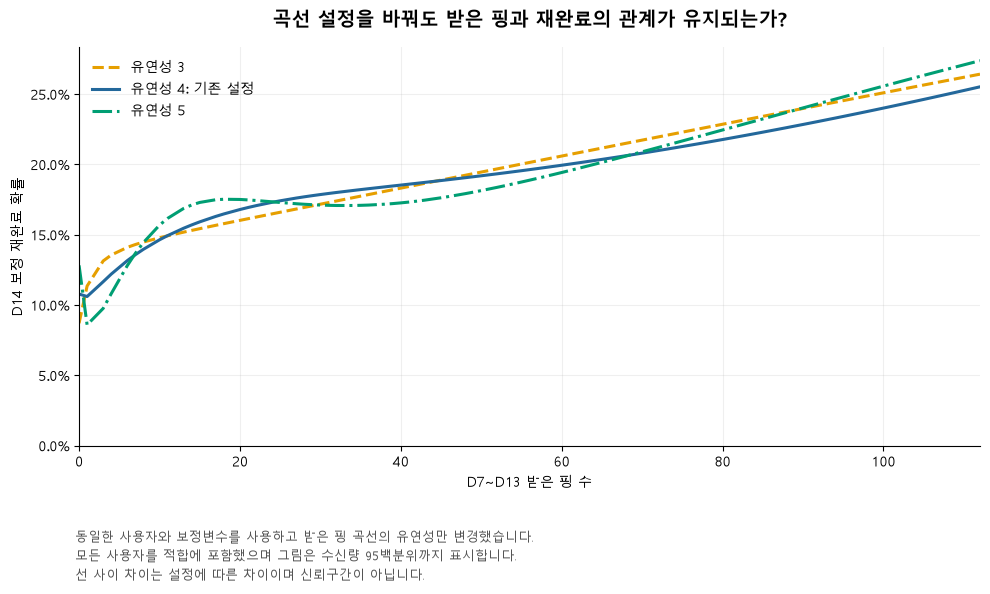

횟수별 보정 재완료 확률: 단위 %


,유연성 3,유연성 4,유연성 5
받은 핑 수,,,
10,14.79,14.64,15.69
20,16.02,16.80,17.51
30,17.18,17.86,17.11
40,18.32,18.53,17.27
50,19.46,19.20,18.14
60,20.60,19.95,19.43


In [73]:
early_sensitivity_curve = pd.DataFrame(early_sensitivity_rows)

# 곡선 비교
early_sensitivity_fig, early_sensitivity_ax = plt.subplots(
    figsize=(10, 6)
)

early_sensitivity_styles = {
    3: ("#E69F00", "--", "유연성 3"),
    4: ("#23689B", "-", "유연성 4: 기존 설정"),
    5: ("#009E73", "-.", "유연성 5")
}

for early_spline_df, early_style in early_sensitivity_styles.items():
    early_color, early_line_style, early_label = early_style

    early_sensitivity_part = early_sensitivity_curve.loc[
        early_sensitivity_curve["spline_df"] == early_spline_df
    ]

    early_sensitivity_ax.plot(
        early_sensitivity_part["ping_count"],
        early_sensitivity_part["adjusted_rate"],
        color=early_color,
        linestyle=early_line_style,
        linewidth=2.2,
        label=early_label
    )

early_sensitivity_ax.set_title(
    "곡선 설정을 바꿔도 받은 핑과 재완료의 관계가 유지되는가?",
    fontsize=14,
    fontweight="bold",
    pad=15
)
early_sensitivity_ax.set_xlabel("D7~D13 받은 핑 수")
early_sensitivity_ax.set_ylabel("D14 보정 재완료 확률")
early_sensitivity_ax.yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=100)
)
early_sensitivity_ax.set_xlim(
    early_sensitivity_min, early_sensitivity_max
)
early_sensitivity_ax.set_ylim(bottom=0)
early_sensitivity_ax.grid(alpha=0.2)
early_sensitivity_ax.legend(frameon=False)
early_sensitivity_ax.spines["top"].set_visible(False)
early_sensitivity_ax.spines["right"].set_visible(False)

early_sensitivity_fig.text(
    0.08, 0.025,
    "동일한 사용자와 보정변수를 사용하고 받은 핑 곡선의 유연성만 변경했습니다.\n"
    "모든 사용자를 적합에 포함했으며 그림은 수신량 95백분위까지 표시합니다.\n"
    "선 사이 차이는 설정에 따른 차이이며 신뢰구간이 아닙니다.",
    fontsize=9,
    color="#555555",
    linespacing=1.5
)
early_sensitivity_fig.tight_layout(rect=[0, 0.15, 1, 1])
plt.show()
plt.close(early_sensitivity_fig)

# 주요 횟수의 추정 확률 비교
early_sensitivity_table = (
    early_sensitivity_curve.loc[
        early_sensitivity_curve["ping_count"].isin(
            early_sensitivity_checkpoints
        )
    ]
    .pivot(
        index="ping_count",
        columns="spline_df",
        values="adjusted_rate"
    )
    .reindex(columns=[3, 4, 5])
)

early_sensitivity_table.index.name = "받은 핑 수"
early_sensitivity_table.columns = [
    "유연성 3", "유연성 4", "유연성 5"
]

print("횟수별 보정 재완료 확률: 단위 %")
display(early_sensitivity_table.round(2))

In [74]:
# 10개 증가 구간별 추정 확률 차이
early_sensitivity_increments = early_sensitivity_table.diff().iloc[1:].copy()
early_sensitivity_increments.index = [
    f"{int(early_sensitivity_table.index[index - 1])}"
    f" → {int(early_sensitivity_table.index[index])}개"
    for index in range(1, len(early_sensitivity_table))
]
early_sensitivity_increments.index.name = "핑 수 비교 구간"

print("10개 증가 구간별 추정 확률 차이: 단위 %p")
display(early_sensitivity_increments.round(2))

10개 증가 구간별 추정 확률 차이: 단위 %p


,유연성 3,유연성 4,유연성 5
핑 수 비교 구간,,,
10 → 20개,1.24,2.15,1.83
20 → 30개,1.15,1.06,-0.40
30 → 40개,1.14,0.67,0.15
40 → 50개,1.14,0.66,0.87
50 → 60개,1.14,0.75,1.29


### 3-4. 첫째 주에서도 비슷한 패턴이 보이는가?
검정 추가 없이 동일한 구간으로 패턴만 비교한다. 첫째 주는 첫 완료 시각부터 D7 시작 직전이라
정확한 168시간보다 짧을 수 있다. 둘째 주와 기간·구간별 인원 분포가 같지 않다는 점에 주의한다.

In [75]:
# 첫째 주·둘째 주 받은 핑과 다음 날 재완료 패턴 비교

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["axes.unicode_minus"] = False

# 기존 날짜 기준 분석과 같은 사용자 사용
pattern_users = early_calendar_data[
    ["user_id", "first_finished_at", "d14_retained"]
].copy()

assert pattern_users["user_id"].is_unique

pattern_users["d0_start"] = (
    pattern_users["first_finished_at"]
    .dt.tz_convert("UTC")
    .dt.normalize()
)

pattern_users["d7_start"] = (
    pattern_users["d0_start"] + pd.Timedelta(days=7)
)
pattern_users["d8_start"] = (
    pattern_users["d0_start"] + pd.Timedelta(days=8)
)
pattern_users["d14_start"] = (
    pattern_users["d0_start"] + pd.Timedelta(days=14)
)
pattern_users["d15_start"] = (
    pattern_users["d0_start"] + pd.Timedelta(days=15)
)

# 사용자별 수신 기록 연결
pattern_received = early_received_votes[
    ["recipient_user_id", "created_at"]
].rename(
    columns={"recipient_user_id": "user_id"}
).merge(
    pattern_users.drop(columns="d14_retained"),
    on="user_id",
    how="inner",
    validate="many_to_one"
)

pattern_received["created_at"] = pd.to_datetime(
    pattern_received["created_at"], utc=True
)

# 사용자별 질문세트 완료 기록 연결
pattern_completed = early_valid_sets[
    ["user_id", "questionset_id", "estimated_finished_at"]
].merge(
    pattern_users.drop(columns="d14_retained"),
    on="user_id",
    how="inner",
    validate="many_to_one"
)

pattern_completed["estimated_finished_at"] = pd.to_datetime(
    pattern_completed["estimated_finished_at"], utc=True
)

pattern_settings = [
    {
        "name": "첫째 주",
        "ping_start": "first_finished_at",
        "ping_end": "d7_start",
        "result_start": "d7_start",
        "result_end": "d8_start",
        "title": "D0~D6 받은 핑 → D7 재완료"
    },
    {
        "name": "둘째 주",
        "ping_start": "d7_start",
        "ping_end": "d14_start",
        "result_start": "d14_start",
        "result_end": "d15_start",
        "title": "D7~D13 받은 핑 → D14 재완료"
    }
]

pattern_group_labels = [
    "0개",
    "1~13개",
    "14~28개",
    "29~53개",
    "54개 이상"
]

In [76]:
pattern_user_tables = []

for pattern_setting in pattern_settings:

    # 해당 주차의 받은 핑
    pattern_ping_mask = (
        (
            pattern_received["created_at"]
            >= pattern_received[pattern_setting["ping_start"]]
        )
        & (
            pattern_received["created_at"]
            < pattern_received[pattern_setting["ping_end"]]
        )
    )

    pattern_ping_counts = (
        pattern_received.loc[pattern_ping_mask]
        .groupby("user_id")
        .size()
    )

    # 다음 날 하루에 질문세트를 한 번 이상 완료했는지 확인
    pattern_result_mask = (
        (
            pattern_completed["estimated_finished_at"]
            >= pattern_completed[pattern_setting["result_start"]]
        )
        & (
            pattern_completed["estimated_finished_at"]
            < pattern_completed[pattern_setting["result_end"]]
        )
    )

    pattern_returned_ids = pattern_completed.loc[
        pattern_result_mask, "user_id"
    ].unique()

    pattern_week_users = pattern_users[["user_id"]].copy()
    pattern_week_users["week"] = pattern_setting["name"]

    pattern_week_users["ping_count"] = (
        pattern_week_users["user_id"]
        .map(pattern_ping_counts)
        .fillna(0)
        .astype(int)
    )

    pattern_week_users["retained"] = (
        pattern_week_users["user_id"]
        .isin(pattern_returned_ids)
        .astype(int)
    )

    pattern_week_users["ping_group"] = pd.cut(
        pattern_week_users["ping_count"],
        bins=[-np.inf, 0, 13, 28, 53, np.inf],
        labels=pattern_group_labels
    )

    pattern_user_tables.append(pattern_week_users)

pattern_comparison_users = pd.concat(
    pattern_user_tables,
    ignore_index=True
)

# 둘째 주 재집계 결과가 기존 분석과 일치하는지 확인
pattern_second_week = (
    pattern_comparison_users.loc[
        pattern_comparison_users["week"] == "둘째 주"
    ]
    .set_index("user_id")
    .sort_index()
)

pattern_existing = (
    early_calendar_data
    .set_index("user_id")
    .sort_index()
)

assert pattern_second_week["ping_count"].eq(
    pattern_existing.loc[
        pattern_second_week.index, "received_ping_count"
    ]
).all(), "둘째 주 수신량이 기존 분석과 다릅니다."


D0~D6 받은 핑 → D7 재완료


,받은 핑,사용자 수,다음 날 재완료 사용자 수,다음 날 재완료율(%)
5,0개,46,7,15.22
6,1~13개,218,55,25.23
7,14~28개,271,104,38.38
8,29~53개,475,200,42.11
9,54개 이상,3802,2003,52.68



D7~D13 받은 핑 → D14 재완료


,받은 핑,사용자 수,다음 날 재완료 사용자 수,다음 날 재완료율(%)
0,0개,120,9,7.50
1,1~13개,1219,136,11.16
2,14~28개,1183,191,16.15
3,29~53개,1145,217,18.95
4,54개 이상,1145,329,28.73


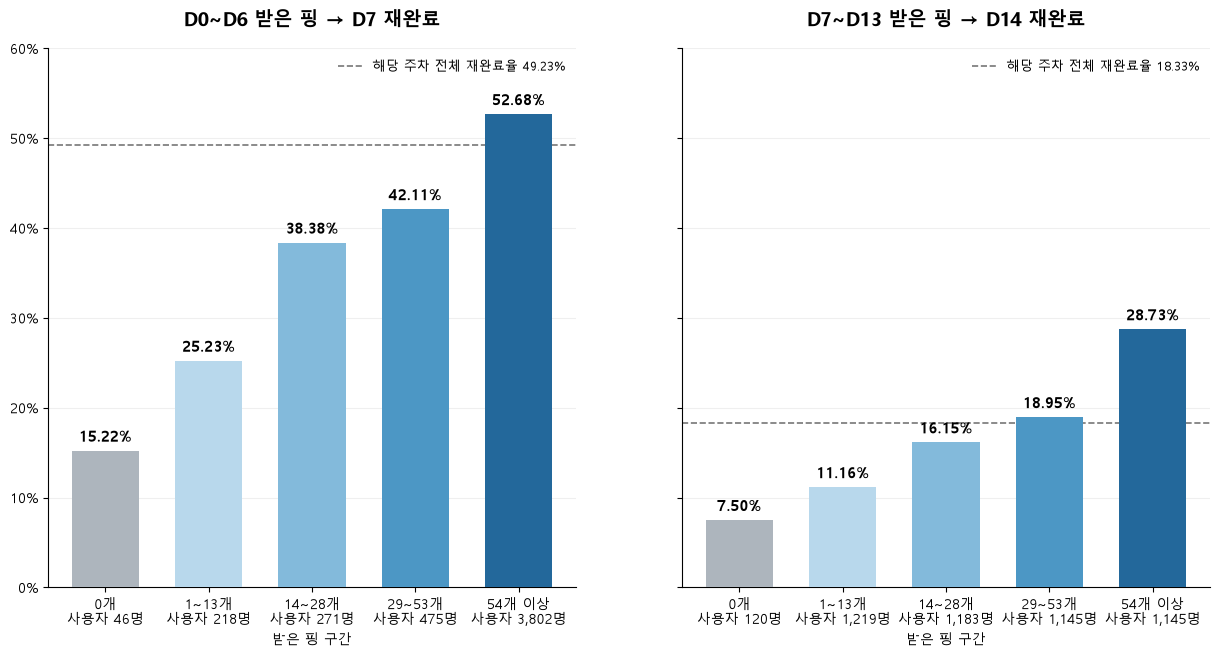

In [77]:
assert pattern_second_week["retained"].eq(
    pattern_existing.loc[
        pattern_second_week.index, "d14_retained"
    ]
).all(), "D14 재완료 여부가 기존 분석과 다릅니다."

# 구간별 인원과 재완료율
pattern_summary = (
    pattern_comparison_users
    .groupby(["week", "ping_group"], observed=False)
    .agg(
        user_count=("user_id", "nunique"),
        retained_count=("retained", "sum")
    )
    .reset_index()
)

# 사용자가 없는 구간은 재완료율을 0이 아닌 결측으로 표시
pattern_summary["retention_rate"] = (
    pattern_summary["retained_count"]
    / pattern_summary["user_count"].replace(0, np.nan)
    * 100
)

for pattern_setting in pattern_settings:
    pattern_week_summary = pattern_summary.loc[
        pattern_summary["week"] == pattern_setting["name"]
    ]

    assert pattern_week_summary["user_count"].sum() == len(pattern_users)

    print(f"\n{pattern_setting['title']}")
    display(
        pattern_week_summary[
            [
                "ping_group",
                "user_count",
                "retained_count",
                "retention_rate"
            ]
        ].rename(
            columns={
                "ping_group": "받은 핑",
                "user_count": "사용자 수",
                "retained_count": "다음 날 재완료 사용자 수",
                "retention_rate": "다음 날 재완료율(%)"
            }
        ).round(2)
    )

# 동일한 세로축으로 나란히 시각화
pattern_colors = [
    "#ADB5BD", "#B8D8EC", "#83BADB", "#4C97C5", "#23689B"
]

pattern_ymax = min(
    100,
    max(
        30,
        np.ceil(
            (pattern_summary["retention_rate"].max() + 5) / 10
        ) * 10
    )
)

pattern_fig, pattern_axes = plt.subplots(
    1, 2,
    figsize=(15, 7),
    sharey=True
)

for pattern_ax, pattern_setting in zip(
    pattern_axes, pattern_settings
):
    pattern_chart = (
        pattern_summary.loc[
            pattern_summary["week"] == pattern_setting["name"]
        ]
        .set_index("ping_group")
        .reindex(pattern_group_labels)
    )

    pattern_x = np.arange(len(pattern_group_labels))

    pattern_ax.bar(
        pattern_x,
        pattern_chart["retention_rate"],
        color=pattern_colors,
        width=0.65,
        zorder=3
    )

    for pattern_index, pattern_row in enumerate(
        pattern_chart.itertuples()
    ):
        if pattern_row.user_count > 0:
            pattern_ax.text(
                pattern_index,
                pattern_row.retention_rate + 1,
                f"{pattern_row.retention_rate:.2f}%",
                ha="center",
                fontsize=11,
                fontweight="bold"
            )

    pattern_overall = (
        pattern_chart["retained_count"].sum()
        / pattern_chart["user_count"].sum()
        * 100
    )

    pattern_ax.axhline(
        pattern_overall,
        color="#777777",
        linestyle="--",
        linewidth=1.2,
        label=f"해당 주차 전체 재완료율 {pattern_overall:.2f}%"
    )

    pattern_ax.set_xticks(pattern_x)
    pattern_ax.set_xticklabels([
        f"{label}\n사용자 {int(count):,}명"
        for label, count in zip(
            pattern_group_labels,
            pattern_chart["user_count"]
        )
    ], fontsize=10)

    pattern_ax.set_title(
        pattern_setting["title"],
        fontsize=14,
        fontweight="bold",
        pad=16
    )
    pattern_ax.set_xlabel("받은 핑 구간")
    pattern_ax.set_ylim(0, pattern_ymax)
    pattern_ax.yaxis.set_major_formatter(
        mticker.PercentFormatter(xmax=100)
    )
    pattern_ax.grid(axis="y", alpha=0.2)
    pattern_ax.set_axisbelow(True)
    pattern_ax.legend(frameon=False, fontsize=9)
    pattern_ax.spines["top"].set_visible(False)
    pattern_ax.spines["right"].set_visible(False)

In [78]:
pattern_axes[0].set_ylabel("다음 날 질문세트 재완료율")

pattern_fig.suptitle(
    "주간 선택받는 경험과 다음 날 재완료 패턴 비교",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

pattern_fig.text(
    0.05, 0.035,
    f"동일 사용자 {len(pattern_users):,}명 · UTC 날짜 기준 · 보정 및 통계검정 없는 관찰 결과\n"
    "첫째 주는 첫 완료 시각부터 D7 시작 직전까지, 둘째 주는 D7~D13의 정확한 7일입니다.\n"
    "두 주차에 같은 핑 구간을 적용했습니다. 같은 사용자라도 주차에 따라 다른 구간에 속할 수 있습니다.",
    fontsize=9,
    color="#555555",
    linespacing=1.6
)

pattern_fig.tight_layout(rect=[0.02, 0.18, 0.99, 0.92])
plt.show()

**해석:** 두 주차 모두 받은 핑이 많은 집단에서 직후 하루 재완료율이 높은 패턴을 보인다.
첫째 주는 54개 이상에 사용자가 많이 집중되어 있으므로 두 곡선의 크기를 곧바로 효과 차이로 비교하지 않는다.

## 4. 친구 관계: 가입 초기 확보한 친구와 후속 유지

가입 후 첫 24시간의 친구 수를 측정하고, **가입+24시간과 첫 완료 중 늦은 시각**을 기준으로
이후 각 24시간의 재완료를 본다. 핑 분석의 ‘첫 완료 후 24시간 친구 수’와 다른 분석이다.
실제 친구가 0명이라는 뜻과 이력에서 친구가 확인되지 않았다는 뜻도 구분해야 한다.

In [79]:
# 사용자별 가입 후 24시간 종료 시각
signup_24h_friend_base = (
    user_activation[
        [
            'user_id',
            'signup_at',
        ]
    ]
    .dropna(
        subset=[
            'user_id',
            'signup_at',
        ]
    )
    .drop_duplicates('user_id')
    .copy()
)

signup_24h_friend_base['signup_24h_end_at'] = (
    signup_24h_friend_base['signup_at']
    + pd.Timedelta(hours=24)
)

In [80]:
# 가입 후 24시간 종료 직전의 친구 수
friend_history_for_24h = (
    target_friend_history[
        [
            'user_id',
            'friendship_at',
            'friend_cnt_after',
        ]
    ]
    .dropna(
        subset=[
            'user_id',
            'friendship_at',
        ]
    )
    .sort_values(
        [
            'friendship_at',
            'user_id',
        ]
    )
    .copy()
)

signup_24h_friend_base = (
    signup_24h_friend_base
    .sort_values(
        [
            'signup_24h_end_at',
            'user_id',
        ]
    )
)

signup_24h_friend = pd.merge_asof(
    signup_24h_friend_base,
    friend_history_for_24h,
    left_on='signup_24h_end_at',
    right_on='friendship_at',
    by='user_id',
    direction='backward',

    # 가입 후 정확히 24시간째 생성된 친구는 제외
    allow_exact_matches=False,
)

signup_24h_friend['friend_count_24h'] = (
    signup_24h_friend['friend_cnt_after']
    .fillna(0)
    .astype(int)
)

In [81]:
# 사용자별 첫 질문셋 완료 시각
first_questionset_completion = (
    questionset_completion[
        [
            'user_id',
            'estimated_completed_at',
        ]
    ]
    .dropna(
        subset=[
            'user_id',
            'estimated_completed_at',
        ]
    )
    .groupby(
        'user_id',
        as_index=False,
    )
    .agg(
        first_completed_at=(
            'estimated_completed_at',
            'min',
        )
    )
)

In [82]:
# 가입 후 24시간 친구 수와 첫 완료 시각 연결
signup_friend_retention_base = (
    signup_24h_friend[
        [
            'user_id',
            'signup_at',
            'signup_24h_end_at',
            'friend_count_24h',
        ]
    ]
    .merge(
        first_questionset_completion,
        on='user_id',
        how='inner',
        validate='one_to_one',
    )
)

In [83]:
# 리텐션 기준점 생성
signup_friend_retention_base[
    'retention_anchor_at'
] = (
    signup_friend_retention_base[
        [
            'signup_24h_end_at',
            'first_completed_at',
        ]
    ]
    .max(axis=1)
)

In [84]:
# 시간 정합성 확인
invalid_first_completion = (
    signup_friend_retention_base[
        'first_completed_at'
    ].lt(
        signup_friend_retention_base[
            'signup_at'
        ]
    )
)

print(
    '가입 이전 첫 질문셋 완료 사용자 수:',
    invalid_first_completion.sum(),
)

가입 이전 첫 질문셋 완료 사용자 수: 0


In [85]:
invalid_anchor = (
    signup_friend_retention_base[
        'retention_anchor_at'
    ].lt(
        signup_friend_retention_base[
            'signup_24h_end_at'
        ]
    )
    |
    signup_friend_retention_base[
        'retention_anchor_at'
    ].lt(
        signup_friend_retention_base[
            'first_completed_at'
        ]
    )
)

print(
    '잘못 생성된 리텐션 기준점 수:',
    invalid_anchor.sum(),
)

잘못 생성된 리텐션 기준점 수: 0


In [86]:
# D1 ~ D15 경과일 생성
signup_friend_retention_days = pd.DataFrame({
    'retention_day': range(1, 16),
})

In [87]:
# 사용자와 D1 ~ D15 조합 생성
signup_friend_user_day = (
    signup_friend_retention_base
    .merge(
        signup_friend_retention_days,
        how='cross',
    )
)

In [88]:
# 경과일별 관찰 시작 / 종료 시각 생성
signup_friend_user_day['window_start_at'] = (
    signup_friend_user_day[
        'retention_anchor_at'
    ]
    + pd.to_timedelta(
        signup_friend_user_day[
            'retention_day'
        ],
        unit='D',
    )
)

signup_friend_user_day['window_end_at'] = (
    signup_friend_user_day[
        'window_start_at'
    ]
    + pd.Timedelta(days=1)
)

In [89]:
signup_friend_observed = (
    signup_friend_user_day[
        signup_friend_user_day[
            'window_end_at'
        ].le(analysis_end_at)
    ]
    .copy()
)

In [90]:
# 관찰 가능한 사용자 수 확인
signup_friend_observed_count = (
    signup_friend_observed
    .groupby(
        'retention_day',
        as_index=False,
    )
    .agg(
        관찰가능사용자수=(
            'user_id',
            'nunique',
        )
    )
)

signup_friend_observed_count['경과일'] = (
    'D'
    + signup_friend_observed_count[
        'retention_day'
    ].astype(str)
)

display(
    signup_friend_observed_count[
        [
            '경과일',
            '관찰가능사용자수',
        ]
    ]
)

,경과일,관찰가능사용자수
0,D1,4812
1,D2,4812
2,D3,4812
3,D4,4812
4,D5,4812
5,D6,4812
6,D7,4812
7,D8,4812
8,D9,4812
9,D10,4812


In [91]:
# 리텐션 관찰 구간과 질문셋 완료 기록 연결
signup_friend_retention_records = (
    signup_friend_observed[
        [
            'user_id',
            'retention_day',
            'window_start_at',
            'window_end_at',
        ]
    ]
    .merge(
        questionset_completion[
            [
                'user_id',
                'questionset_id',
                'estimated_completed_at',
            ]
        ],
        on='user_id',
        how='left',
        validate='many_to_many',
    )
)

In [92]:
# 해당 경과일 안의 질문셋 완료 여부 계산
signup_friend_retention_records[
    'completed_in_window'
] = (
    signup_friend_retention_records[
        'estimated_completed_at'
    ].ge(
        signup_friend_retention_records[
            'window_start_at'
        ]
    )
    &
    signup_friend_retention_records[
        'estimated_completed_at'
    ].lt(
        signup_friend_retention_records[
            'window_end_at'
        ]
    )
)

In [93]:
# 사용자 / 경과일별 재완료 여부 집계
signup_friend_retention_result = (
    signup_friend_retention_records
    .groupby(
        [
            'user_id',
            'retention_day',
        ],
        as_index=False,
    )
    .agg(
        retained=(
            'completed_in_window',
            'any',
        ),
        completed_questionsets=(
            'completed_in_window',
            'sum',
        ),
    )
)

In [94]:
# 친구 수와 리텐션 결과 연결
signup_friend_retention = (
    signup_friend_observed
    .merge(
        signup_friend_retention_result,
        on=[
            'user_id',
            'retention_day',
        ],
        how='left',
        validate='one_to_one',
    )
)

signup_friend_retention['retained'] = (
    signup_friend_retention['retained']
    .fillna(False)
    .astype(bool)
)

signup_friend_retention['completed_questionsets'] = (
    signup_friend_retention[
        'completed_questionsets'
    ]
    .fillna(0)
    .astype(int)
)

In [95]:
# 중복 및 결과 확인
print(
    '사용자-경과일 중복 수:',
    signup_friend_retention.duplicated(
        [
            'user_id',
            'retention_day',
        ]
    ).sum(),
)

사용자-경과일 중복 수: 0


In [96]:
# 전체 리텐션 확인
signup_friend_overall_retention = (
    signup_friend_retention
    .groupby(
        'retention_day',
        as_index=False,
    )
    .agg(
        관찰가능사용자수=(
            'user_id',
            'nunique',
        ),
        유지사용자수=(
            'retained',
            'sum',
        ),
        retention_rate=(
            'retained',
            'mean',
        ),
    )
)

signup_friend_overall_retention[
    'Retention(%)'
] = (
    signup_friend_overall_retention[
        'retention_rate'
    ]
    * 100
).round(2)

signup_friend_overall_retention['경과일'] = (
    'D'
    + signup_friend_overall_retention[
        'retention_day'
    ].astype(str)
)

display(
    signup_friend_overall_retention[
        [
            '경과일',
            '관찰가능사용자수',
            '유지사용자수',
            'Retention(%)',
        ]
    ]
)

,경과일,관찰가능사용자수,유지사용자수,Retention(%)
0,D1,4812,3987,82.86
1,D2,4812,3673,76.33
2,D3,4812,3314,68.87
3,D4,4812,2973,61.78
4,D5,4812,2614,54.32
5,D6,4812,2304,47.88
6,D7,4812,2019,41.96
7,D8,4812,1728,35.91
8,D9,4812,1449,30.11
9,D10,4812,1306,27.14


In [97]:
# 분석 사용자당 한 행으로 정리
signup_friend_user_base = (
    signup_friend_retention[
        [
            'user_id',
            'friend_count_24h',
        ]
    ]
    .drop_duplicates('user_id')
    .copy()
)

print(
    '분석 사용자 수:',
    signup_friend_user_base[
        'user_id'
    ].nunique(),
)

분석 사용자 수: 4812


In [98]:
# 가입 후 24시간 친구 수 요약
display(
    signup_friend_user_base[
        'friend_count_24h'
    ]
    .describe(
        percentiles=[
            .25,
            .5,
            .75,
            .9,
            .95,
            .99,
        ]
    )
)

count    4812.000000
mean       21.159601
std        17.557575
min         0.000000
25%         9.000000
50%        17.000000
75%        29.000000
90%        44.000000
95%        54.000000
99%        80.000000
max       129.000000
Name: friend_count_24h, dtype: float64

In [99]:
# 친구 수별 사용자 수와 비율
friend_count_24h_distribution = (
    signup_friend_user_base[
        'friend_count_24h'
    ]
    .value_counts()
    .sort_index()
    .rename_axis('가입 후 24시간 친구 수')
    .reset_index(name='사용자 수')
)

friend_count_24h_distribution[
    '사용자 비율(%)'
] = (
    friend_count_24h_distribution[
        '사용자 수'
    ]
    / friend_count_24h_distribution[
        '사용자 수'
    ].sum()
    * 100
).round(2)

display(friend_count_24h_distribution)

,가입 후 24시간 친구 수,사용자 수,사용자 비율(%)
0,0,246,5.11
1,1,101,2.10
2,2,94,1.95
3,3,104,2.16
4,4,112,2.33
...,...,...,...
104,122,1,0.02
105,123,1,0.02
106,124,1,0.02
107,127,2,0.04


In [100]:
# 누적 사용자 비율 추가
friend_count_24h_distribution[
    '누적 사용자 비율(%)'
] = (
    friend_count_24h_distribution[
        '사용자 비율(%)'
    ]
    .cumsum()
    .round(2)
)

display(friend_count_24h_distribution)

,가입 후 24시간 친구 수,사용자 수,사용자 비율(%),누적 사용자 비율(%)
0,0,246,5.11,5.11
1,1,101,2.10,7.21
2,2,94,1.95,9.16
3,3,104,2.16,11.32
4,4,112,2.33,13.65
...,...,...,...,...
104,122,1,0.02,99.84
105,123,1,0.02,99.86
106,124,1,0.02,99.88
107,127,2,0.04,99.92


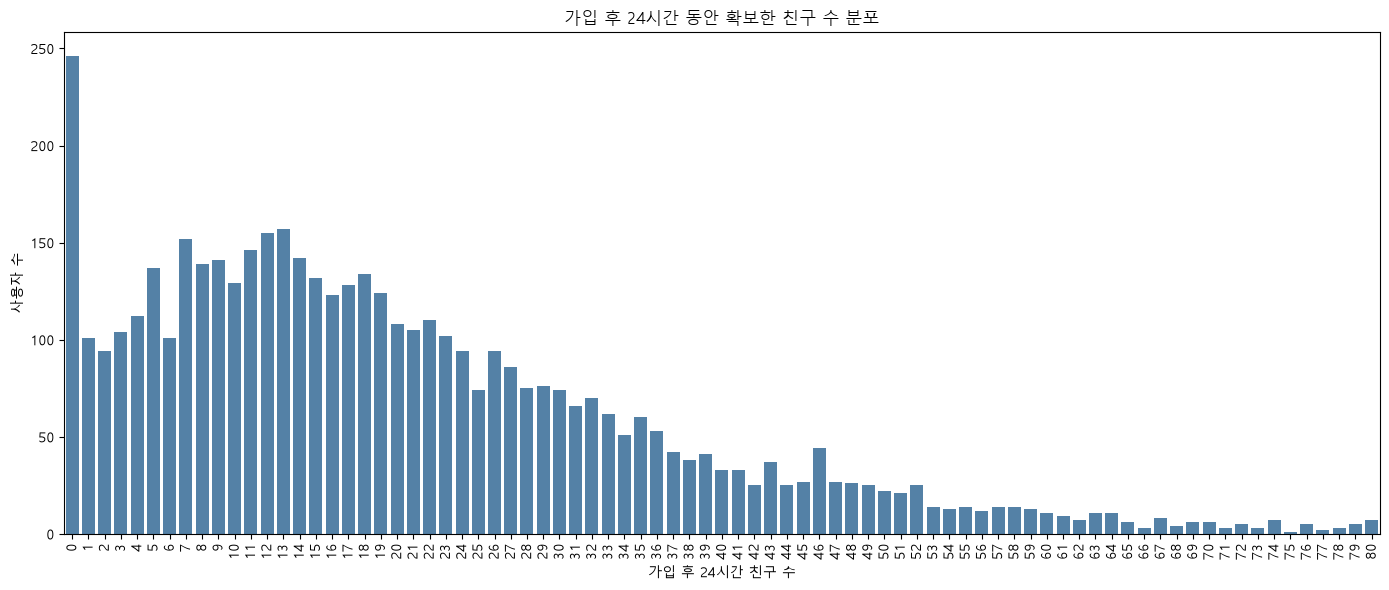

In [101]:
# 분포 시각화
friend_count_24h_p99 = int(
    signup_friend_user_base[
        'friend_count_24h'
    ].quantile(.99)
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=friend_count_24h_distribution[
        friend_count_24h_distribution[
            '가입 후 24시간 친구 수'
        ].le(friend_count_24h_p99)
    ],
    x='가입 후 24시간 친구 수',
    y='사용자 수',
    color='steelblue',
)

plt.title(
    '가입 후 24시간 동안 확보한 친구 수 분포'
)
plt.xlabel('가입 후 24시간 친구 수')
plt.ylabel('사용자 수')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [102]:
# 친구 수 / 경과일별 리텐션 집계
friend_24h_retention_summary = (
    signup_friend_retention
    .groupby(
        [
            'friend_count_24h',
            'retention_day',
        ],
        as_index=False,
    )
    .agg(
        관찰가능사용자수=(
            'user_id',
            'nunique',
        ),
        유지사용자수=(
            'retained',
            'sum',
        ),
        retention_rate=(
            'retained',
            'mean',
        ),
    )
)

friend_24h_retention_summary[
    'Retention(%)'
] = (
    friend_24h_retention_summary[
        'retention_rate'
    ]
    * 100
).round(2)

In [103]:
# 리텐션 피벗 테이블
friend_24h_retention_pivot = (
    friend_24h_retention_summary
    .pivot(
        index='friend_count_24h',
        columns='retention_day',
        values='Retention(%)',
    )
    .rename(
        columns=lambda day: f'D{day}'
    )
)

friend_24h_retention_pivot.index.name = (
    '가입 후 24시간 친구 수'
)

display(friend_24h_retention_pivot)

retention_day,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
가입 후 24시간 친구 수,,,,,,,,,,,,,,,
0,80.89,73.98,71.95,60.57,58.13,53.66,46.34,40.65,33.74,30.49,24.39,27.24,18.70,17.48,15.04
1,80.20,77.23,69.31,61.39,57.43,55.45,43.56,46.53,34.65,26.73,35.64,27.72,20.79,18.81,21.78
2,70.21,69.15,62.77,53.19,42.55,45.74,37.23,32.98,25.53,31.91,23.40,18.09,23.40,13.83,21.28
3,74.04,70.19,67.31,63.46,51.92,45.19,47.12,31.73,29.81,32.69,24.04,18.27,20.19,17.31,15.38
4,80.36,71.43,64.29,62.50,57.14,50.00,51.79,41.07,39.29,27.68,28.57,25.00,24.11,20.54,18.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,0.00
123,100.00,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
124,100.00,100.00,100.00,0.00,100.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [104]:
# 표본 수 피벗 테이블
friend_24h_sample_pivot = (
    friend_24h_retention_summary
    .pivot(
        index='friend_count_24h',
        columns='retention_day',
        values='관찰가능사용자수',
    )
    .rename(
        columns=lambda day: f'D{day}'
    )
)

friend_24h_sample_pivot.index.name = (
    '가입 후 24시간 친구 수'
)

display(friend_24h_sample_pivot)

retention_day,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
가입 후 24시간 친구 수,,,,,,,,,,,,,,,
0,246,246,246,246,246,246,246,246,246,246,246,246,246,246,246
1,101,101,101,101,101,101,101,101,101,101,101,101,101,101,101
2,94,94,94,94,94,94,94,94,94,94,94,94,94,94,94
3,104,104,104,104,104,104,104,104,104,104,104,104,104,104,104
4,112,112,112,112,112,112,112,112,112,112,112,112,112,112,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
123,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
124,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [105]:
# 친구 수 구간 생성
friend_24h_bins = [
    -float('inf'),
    4,
    9,
    14,
    19,
    24,
    29,
    float('inf'),
]

friend_24h_labels = [
    '0~4명',
    '5~9명',
    '10~14명',
    '15~19명',
    '20~24명',
    '25~29명',
    '30명 이상',
]

signup_friend_retention[
    'friend_count_24h_group'
] = pd.cut(
    signup_friend_retention[
        'friend_count_24h'
    ],
    bins=friend_24h_bins,
    labels=friend_24h_labels,
    right=True,
)

In [106]:
# 구간별 리텐션 집계
friend_24h_group_summary = (
    signup_friend_retention
    .groupby(
        [
            'friend_count_24h_group',
            'retention_day',
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        관찰가능사용자수=(
            'user_id',
            'nunique',
        ),
        유지사용자수=(
            'retained',
            'sum',
        ),
        retention_rate=(
            'retained',
            'mean',
        ),
    )
)

friend_24h_group_summary[
    'Retention(%)'
] = (
    friend_24h_group_summary[
        'retention_rate'
    ]
    * 100
).round(2)

In [107]:
# 리텐션 표
friend_24h_group_retention_pivot = (
    friend_24h_group_summary
    .pivot(
        index='friend_count_24h_group',
        columns='retention_day',
        values='Retention(%)',
    )
    .reindex(friend_24h_labels)
    .rename(
        columns=lambda day: f'D{day}'
    )
)

friend_24h_group_retention_pivot.index.name = (
    '가입 후 24시간 친구 수'
)

display(friend_24h_group_retention_pivot)

retention_day,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
가입 후 24시간 친구 수,,,,,,,,,,,,,,,
0~4명,78.08,72.75,68.19,60.43,54.64,50.84,45.66,39.12,33.03,29.98,26.64,24.20,20.85,17.66,17.66
5~9명,74.48,68.21,63.73,57.91,52.69,46.42,42.39,37.46,29.10,27.91,24.18,22.99,21.94,18.21,17.01
10~14명,77.78,71.33,61.87,55.83,50.34,43.21,36.21,33.88,30.86,25.24,24.28,18.79,17.56,15.91,16.74
15~19명,84.56,77.22,72.07,62.56,58.35,48.67,45.24,36.35,30.89,29.64,25.74,23.87,21.06,18.88,17.32
20~24명,85.36,81.12,72.64,66.09,54.72,51.64,41.43,37.19,32.37,31.02,24.86,22.74,20.23,20.04,19.27
25~29명,86.91,83.21,72.84,71.11,55.31,51.85,44.94,39.51,32.35,27.65,24.69,21.23,19.75,20.00,20.74
30명 이상,89.92,81.02,71.70,62.89,54.83,46.52,40.64,32.49,26.45,23.09,20.32,18.64,17.80,15.03,14.69


In [108]:
# 표본 수 확인
friend_24h_group_sample_pivot = (
    friend_24h_group_summary
    .pivot(
        index='friend_count_24h_group',
        columns='retention_day',
        values='관찰가능사용자수',
    )
    .reindex(friend_24h_labels)
    .rename(
        columns=lambda day: f'D{day}'
    )
)

friend_24h_group_sample_pivot.index.name = (
    '가입 후 24시간 친구 수'
)

display(friend_24h_group_sample_pivot)

retention_day,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
가입 후 24시간 친구 수,,,,,,,,,,,,,,,
0~4명,657,657,657,657,657,657,657,657,657,657,657,657,657,657,657
5~9명,670,670,670,670,670,670,670,670,670,670,670,670,670,670,670
10~14명,729,729,729,729,729,729,729,729,729,729,729,729,729,729,729
15~19명,641,641,641,641,641,641,641,641,641,641,641,641,641,641,641
20~24명,519,519,519,519,519,519,519,519,519,519,519,519,519,519,519
25~29명,405,405,405,405,405,405,405,405,405,405,405,405,405,405,405
30명 이상,1191,1191,1191,1191,1191,1191,1191,1191,1191,1191,1191,1191,1191,1191,1191


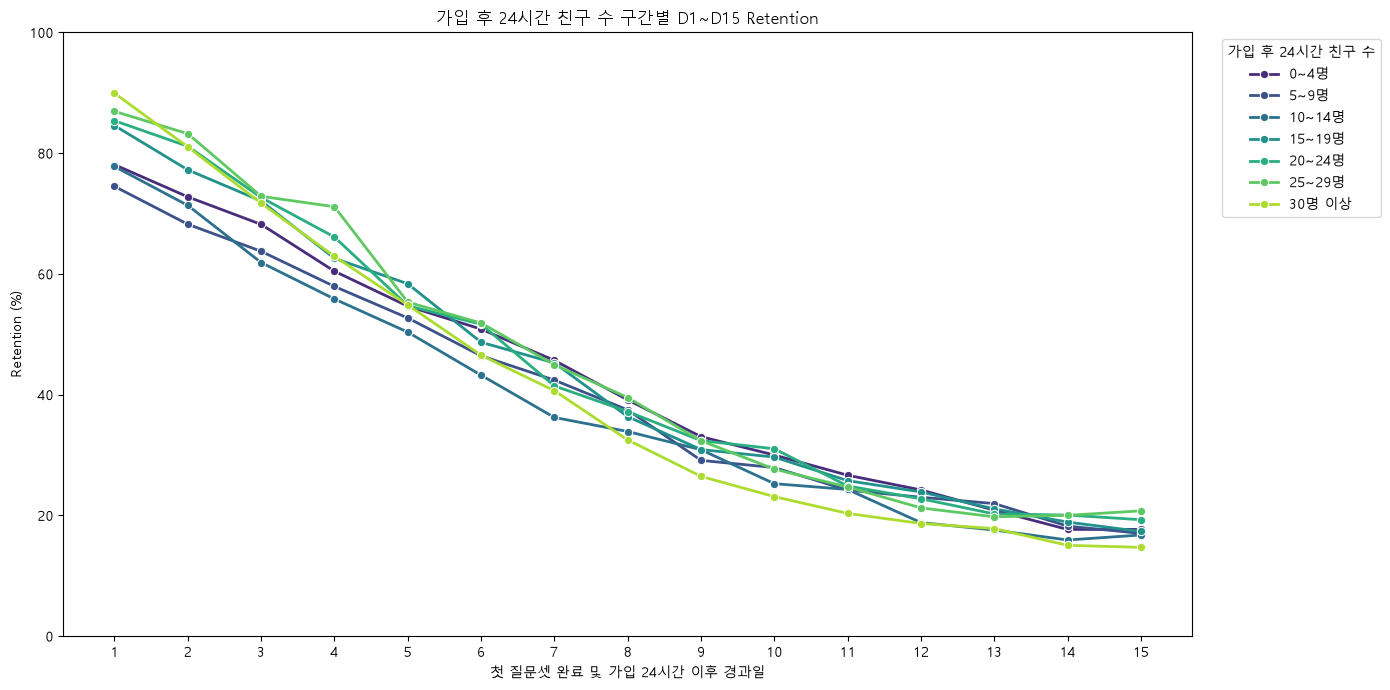

In [109]:
# 선 그래프
plot_data = friend_24h_group_summary.copy()

plot_data['경과일'] = (
    'D'
    + plot_data[
        'retention_day'
    ].astype(str)
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=plot_data,
    x='retention_day',
    y='Retention(%)',
    hue='friend_count_24h_group',
    hue_order=friend_24h_labels,
    marker='o',
    linewidth=2,
    palette='viridis',
)

plt.title(
    '가입 후 24시간 친구 수 구간별 D1~D15 Retention'
)
plt.xlabel('첫 질문셋 완료 및 가입 24시간 이후 경과일')
plt.ylabel('Retention (%)')
plt.xticks(range(1, 16))
plt.ylim(0, 100)

plt.legend(
    title='가입 후 24시간 친구 수',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)

plt.tight_layout()
plt.show()

**해석:** 초기에는 친구가 많은 일부 집단의 재완료율이 높지만, 시간이 지나면 구간 간 차이가 줄고
D14 부근에는 친구 수에 따른 일관된 증가가 보이지 않는다. 유리한 친구 수 임계값을 단정하지 않는다.
친구 형성 지원은 검증할 가설로만 연결하며, 친구 수 자체와 관계의 활동성을 같은 개념으로 취급하지 않는다.

## 5. 분석에서 개선 실험으로

| 분석 결과 | 제품 가설 | 실험에서 확인할 것 |
|---|---|---|
| 초기 반복 완료와 후속 유지의 연관성 | 초기에 질문 완료 경험을 반복하도록 지원 | 완료 3회 유도와 후속 재완료 |
| 최근 선택받는 경험과 직후 재완료의 연관성 | 친구가 질문을 골라 핑을 보내는 참여 카드 제공 | D7~D13 수신 증가와 D14 재완료 |
| 가입 초기 친구 관계와 유지 패턴 | 초기 친구 형성을 지원 | 친구 확보와 후속 재완료, 알림 피로 |

### 핑 실험 초안
첫 완료 후 D7에 도달하고 실험 시작 전에 정한 최근 활동 조건을 충족하는 사용자를 모집한다.
신규 가입자만으로 한정하지 않는다. 사용자 단위 1:1 무작위 배정에서 A는 기존 화면,
B는 친구에게 어울리는 질문 선택 카드와 참여 보상을 제공한다.
수신 20개는 후보 목표로 모니터링하되, 미달 때마다 친구에게 알림을 반복 발송하는 정책은 사용하지 않는다.
노출·알림 빈도 상한과 동일 친구 요청 제한을 사전에 정한다.

주지표는 **D14 하루 질문세트 재완료율**, 보조지표는 D7~D13 수신 수·20개 도달률,
가드레일은 알림 끄기·차단·신고·보상 비용이다. 배정된 전체 적격자를 기준으로 분석한다(ITT).
친구 사이의 상호작용으로 A/B가 영향을 주고받을 수 있으므로 군집 배정 또는 오염 측정이 필요하다.

효과 크기는 상대 5%가 아니라 **절대 5%p** 증가를 가정한다.
아래 표본 수는 사용자 독립·동일 배정의 단순 근사이며 친구 군집 배정에는 별도 설계효과가 필요하다.
전체 표본의 18.33%를 임시 기준으로 사용했으므로 실제 실험 적격자의 기준율로 다시 산정한다.

In [110]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

ab_baseline = early_model_users["d14_retained"].mean()
ab_mde = 0.05
ab_effect = abs(proportion_effectsize(ab_baseline, ab_baseline + ab_mde))
ab_per_arm = int(np.ceil(NormalIndPower().solve_power(
    effect_size=ab_effect, alpha=0.05, power=0.80, ratio=1,
    alternative="two-sided")))
print(f"임시 기준율 {ab_baseline:.2%}, MDE +5%p: 그룹당 {ab_per_arm:,}명 / 총 {2*ab_per_arm:,}명")
ab_duration = pd.DataFrame({"하루 최초 적격 등록자": [50, 100, 200]})
ab_duration["모집 기간(일)"] = np.ceil(2 * ab_per_arm / ab_duration["하루 최초 적격 등록자"]).astype(int)
ab_duration["관찰 완료까지(일, 근사)"] = ab_duration["모집 기간(일)"] + 8
display(ab_duration)
print("D7 등록 후 D14 하루가 끝날 때까지 약 8일. 적격 등록자는 DAU나 신규 가입자 수와 다릅니다.")

임시 기준율 18.33%, MDE +5%p: 그룹당 1,033명 / 총 2,066명


,하루 최초 적격 등록자,모집 기간(일),"관찰 완료까지(일, 근사)"
0,50,42,50
1,100,21,29
2,200,11,19


D7 등록 후 D14 하루가 끝날 때까지 약 8일. 적격 등록자는 DAU나 신규 가입자 수와 다릅니다.


## 6. D14 유지 개선을 위한 조기 위험 예측

### 6-1. D14 직접 예측의 한계와 분석 방향 전환
**프로젝트의 최종 목적은 D14 유지율 개선이다.** 처음에는 첫 질문 완료 후 24시간의 행동으로
D14 재완료 여부를 직접 예측했다. 부록 B-1의 로지스틱 회귀는 AP 0.2458, ROC-AUC 0.5904로
초기 행동만을 이용한 예측력이 제한적이었다.

동일한 핵심 5개 변수를 사용한 관찰 기간 비교(부록 B-2)에서는 다음과 같았다.

| 관찰 기간 | D14 재완료 AP | ROC-AUC |
|---|---:|---:|
| 첫 24시간 | 0.2458 | 0.5883 |
| 첫 3일 | 0.3034 | 0.6583 |
| 첫 7일 | 0.3854 | 0.7310 |

더 오래 관찰하면 예측력은 개선됐지만 개입 시점도 늦어진다. 따라서 **D7이 D14와 연관되는지 먼저 확인하고,
D7을 더 이른 중간 지표로 삼아 예측하는 방향**을 검토했다.
‘예측 시점과 D14가 멀어서 성능이 낮다’는 설명은 가설이며, 낮은 성능의 원인을 별도로 검증한 것은 아니다.

분석 흐름: **D14 직접 예측 → 관찰 기간 확장의 효과와 개입 지연 확인 → D7·D14 연관성 검정 → 초기 24시간으로 D7 위험 예측**.

### 6-2. 입력 변수 생성
첫 완료 이후 **24시간 이내**의 정보만 생성한다. 학교·학급 ID와 절대 시각, 사용자 ID는 모델 입력에서 제외한다.
출석은 날짜만 있어 정확한 24시간 경계를 구분하기 어려워 제외한다. 사용자 ID는 연결·분할 검증용으로만 쓴다.
사용하지 않기로 한 5개 테이블은 모델 변수 생성에서 조회하지 않는다.

In [111]:
# 분류 모델링 01. 분석 대상과 사용 가능한 테이블 구조 확인

prediction_project = PROJECT_ID
prediction_dataset = DATA_SET

# 사용자가 제외한 테이블
prediction_excluded_tables = {
    "accounts_failpaymenthistory",
    "accounts_user_contacts",
    "accounts_userwithdraw",
    "event_receipts",
    "polls_usercandidate"
}

# 실제 테이블 구조를 확인할 후보
prediction_expected_columns = {
    "accounts_paymenthistory": [
        "id", "user_id", "productId", "created_at"
    ],
    "accounts_pointhistory": [
        "id", "user_id", "user_question_record_id",
        "delta_point", "created_at"
    ],
    "accounts_timelinereport": [
        "id", "user_id", "reported_user_id",
        "user_question_record_id", "created_at"
    ],
    "polls_questionreport": [
        "id", "user_id", "question_id", "created_at"
    ],
    "accounts_blockrecord": [
        "id", "user_id", "block_user_id", "created_at"
    ],
    "accounts_friendrequest": [
        "id", "send_user_id", "receive_user_id",
        "status", "created_at", "updated_at"
    ],
    "accounts_attendance": [
        "id", "user_id", "attendance_date_list"
    ],
    "accounts_userquestionrecord": [
        "id", "user_id", "chosen_user_id",
        "question_id", "question_piece_id", "created_at"
    ],
    "accounts_user": [
        "id", "group_id", "created_at"
    ],
    "accounts_group": [
        "id", "school_id", "grade", "class_num"
    ],
    "accounts_school": [
        "id", "school_type"
    ]
}

assert not (
    set(prediction_expected_columns) & prediction_excluded_tables
), "제외하기로 한 테이블이 조회 목록에 포함되어 있습니다."

# 기존 분석 데이터는 수정하지 않고 별도 복사
prediction_base_columns = [
    "user_id",
    "school_id",
    "signup_at",
    "first_finished_at",
    "window_end",
    "completed_sets",
    "active_days",
    "received_ping_count",
    "unique_ping_senders",
    "estimated_friend_count_end",
    "d14_retained"
]

prediction_missing_base_columns = [
    column
    for column in prediction_base_columns
    if column not in early_features.columns
]

assert not prediction_missing_base_columns, (
    f"기존 데이터에 필요한 열이 없습니다: "
    f"{prediction_missing_base_columns}"
)

prediction_users = early_features.loc[
    early_features["window"] == "24h",
    prediction_base_columns
].copy()

In [112]:
assert len(prediction_users) > 0, "24시간 분석 대상이 없습니다."
assert prediction_users["user_id"].is_unique, (
    "사용자당 한 행이어야 합니다."
)

assert prediction_users[
    ["user_id", "first_finished_at", "window_end", "d14_retained"]
].notna().all().all(), "분석 기준값 또는 정답이 누락되어 있습니다."

assert (
    prediction_users["window_end"]
    - prediction_users["first_finished_at"]
).eq(pd.Timedelta(hours=24)).all(), (
    "일부 사용자의 관찰 구간이 24시간이 아닙니다."
)

assert prediction_users["d14_retained"].isin([0, 1]).all(), (
    "결과변수에 0과 1 이외의 값이 있습니다."
)

prediction_users["d14_retained"] = (
    prediction_users["d14_retained"].astype(int)
)

# 상수인 활동일 수는 설명변수 후보에서 제외
prediction_constant_columns = [
    column
    for column in [
        "completed_sets",
        "active_days",
        "received_ping_count",
        "unique_ping_senders",
        "estimated_friend_count_end"
    ]
    if prediction_users[column].nunique(dropna=False) <= 1
]

# 데이터 행 조회 없이 테이블 메타데이터만 확인
prediction_schema_rows = []
prediction_schema_status_rows = []

for prediction_table_name, prediction_columns in (
    prediction_expected_columns.items()
):
    try:
        prediction_table = client.get_table(
            f"{prediction_project}.{prediction_dataset}."
            f"{prediction_table_name}"
        )

    except Exception as prediction_error:
        prediction_schema_status_rows.append({
            "테이블": prediction_table_name,
            "확인 상태": "조회 실패",
            "예상 컬럼 중 미확인": "",
            "오류": str(prediction_error)[:250]
        })
        continue

    prediction_actual_fields = {
        field.name: field
        for field in prediction_table.schema
    }

    prediction_missing_columns = [
        column
        for column in prediction_columns
        if column not in prediction_actual_fields
    ]

    prediction_schema_status_rows.append({
        "테이블": prediction_table_name,
        "확인 상태": (
            "컬럼 확인 필요"
            if prediction_missing_columns
            else "확인 완료"
        ),
        "예상 컬럼 중 미확인": ", ".join(prediction_missing_columns),
        "오류": ""
    })

    for prediction_field in prediction_table.schema:
        prediction_schema_rows.append({
            "테이블": prediction_table_name,
            "컬럼": prediction_field.name,
            "자료형": prediction_field.field_type,
            "모드": prediction_field.mode
        })

In [113]:
prediction_schema = pd.DataFrame(prediction_schema_rows)
prediction_schema_status = pd.DataFrame(prediction_schema_status_rows)

# 시간순 분리 가능성을 보기 위한 첫 완료 월별 분포
prediction_cohort_summary = (
    prediction_users.assign(
        first_completion_month=(
            prediction_users["first_finished_at"]
            .dt.tz_convert("UTC")
            .dt.strftime("%Y-%m")
        )
    )
    .groupby("first_completion_month", as_index=False)
    .agg(
        user_count=("user_id", "nunique"),
        retained_count=("d14_retained", "sum")
    )
)

prediction_cohort_summary["retention_rate"] = (
    prediction_cohort_summary["retained_count"]
    / prediction_cohort_summary["user_count"]
    * 100
)

print(f"모델링 대상: {len(prediction_users):,}명")
print(
    f"D14 재완료 사용자: "
    f"{prediction_users['d14_retained'].sum():,}명"
)
print(
    f"D14 재완료율: "
    f"{prediction_users['d14_retained'].mean():.2%}"
)
print(f"상수 변수: {prediction_constant_columns}")
print("지정된 제외 테이블은 조회하지 않았습니다.")
print("구매·포인트 등의 실제 데이터 행은 아직 조회하지 않았습니다.")

display(prediction_schema_status)

print("\n첫 완료 월별 사용자 분포")
display(
    prediction_cohort_summary.rename(
        columns={
            "first_completion_month": "첫 완료 월",
            "user_count": "사용자 수",
            "retained_count": "D14 재완료 사용자 수",
            "retention_rate": "D14 재완료율(%)"
        }
    ).round(2)
)

print("\n변수 생성에 사용할 실제 컬럼 구조")
display(prediction_schema)

모델링 대상: 4,812명
D14 재완료 사용자: 882명
D14 재완료율: 18.33%
상수 변수: ['active_days']
지정된 제외 테이블은 조회하지 않았습니다.
구매·포인트 등의 실제 데이터 행은 아직 조회하지 않았습니다.


,테이블,확인 상태,예상 컬럼 중 미확인,오류
0,accounts_paymenthistory,확인 완료,,
1,accounts_pointhistory,확인 완료,,
2,accounts_timelinereport,확인 완료,,
3,polls_questionreport,확인 완료,,
4,accounts_blockrecord,확인 완료,,
5,accounts_friendrequest,확인 완료,,
6,accounts_attendance,확인 완료,,
7,accounts_userquestionrecord,확인 완료,,
8,accounts_user,확인 완료,,
9,accounts_group,확인 완료,,



첫 완료 월별 사용자 분포


,첫 완료 월,사용자 수,D14 재완료 사용자 수,D14 재완료율(%)
0,2023-04,337,51,15.13
1,2023-05,4436,830,18.71
2,2023-06,33,1,3.03
3,2023-07,3,0,0.00
4,2023-09,1,0,0.00
5,2023-11,1,0,0.00
6,2024-03,1,0,0.00



변수 생성에 사용할 실제 컬럼 구조


,테이블,컬럼,자료형,모드
0,accounts_paymenthistory,id,INTEGER,NULLABLE
1,accounts_paymenthistory,productId,STRING,NULLABLE
2,accounts_paymenthistory,phone_type,STRING,NULLABLE
3,accounts_paymenthistory,created_at,TIMESTAMP,NULLABLE
4,accounts_paymenthistory,user_id,INTEGER,NULLABLE
...,...,...,...,...
66,accounts_group,school_id,INTEGER,NULLABLE
67,accounts_school,id,INTEGER,NULLABLE
68,accounts_school,address,STRING,NULLABLE
69,accounts_school,student_count,INTEGER,NULLABLE


In [114]:
# 분류 모델링 02. 초기 24시간 구매·포인트 변수 생성

prediction_user_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter(
            "user_ids",
            "INT64",
            prediction_users["user_id"].astype("int64").tolist()
        )
    ]
)

# 구매 기록 조회
prediction_payment_raw = client.query(
    f"""
    SELECT
        id,
        user_id,
        productId,
        created_at
    FROM `{prediction_project}.{prediction_dataset}.accounts_paymenthistory`
    WHERE user_id IN UNNEST(@user_ids)
    """,
    job_config=prediction_user_config
).to_dataframe(create_bqstorage_client=False)

# 포인트 증감 기록 조회
prediction_point_raw = client.query(
    f"""
    SELECT
        id,
        user_id,
        delta_point,
        created_at
    FROM `{prediction_project}.{prediction_dataset}.accounts_pointhistory`
    WHERE user_id IN UNNEST(@user_ids)
    """,
    job_config=prediction_user_config
).to_dataframe(create_bqstorage_client=False)

prediction_record_checks = []

def prediction_filter_initial_24h(records, source_name):
    records = records.copy()

    assert records["id"].notna().all(), (
        f"{source_name}: 기록 ID가 누락되어 있습니다."
    )
    assert records["id"].is_unique, (
        f"{source_name}: 같은 기록 ID가 중복됩니다."
    )

    records["created_at"] = pd.to_datetime(
        records["created_at"], utc=True
    )

    assert records["created_at"].notna().all(), (
        f"{source_name}: 발생 시각이 누락되어 있습니다."
    )

    linked = records.merge(
        prediction_users[
            ["user_id", "first_finished_at", "window_end"]
        ],
        on="user_id",
        how="inner",
        validate="many_to_one"
    )

    selected = linked.loc[
        (linked["created_at"] >= linked["first_finished_at"])
        & (linked["created_at"] < linked["window_end"])
    ].copy()

    prediction_record_checks.append({
        "기록 종류": source_name,
        "대상 사용자 전체 기간 기록 수": len(records),
        "초기 24시간 기록 수": len(selected),
        "초기 24시간 기록 보유 사용자 수": selected["user_id"].nunique()
    })

    return selected

prediction_payment_24h = prediction_filter_initial_24h(
    prediction_payment_raw, "구매"
)

In [115]:
prediction_point_24h = prediction_filter_initial_24h(
    prediction_point_raw, "포인트"
)

prediction_point_24h["delta_point"] = pd.to_numeric(
    prediction_point_24h["delta_point"],
    errors="raise"
).astype(float)

assert prediction_point_24h["delta_point"].notna().all(), (
    "초기 포인트 기록의 증감량이 누락되어 있습니다."
)
assert np.isfinite(prediction_point_24h["delta_point"]).all(), (
    "초기 포인트 증감량에 유효하지 않은 값이 있습니다."
)

# 사용자별 구매 기록 수
prediction_payment_summary = (
    prediction_payment_24h.groupby("user_id", as_index=False)
    .agg(purchase_record_count_24h=("id", "size"))
)

# 부호의 의미를 확인하기 전까지 증가·감소로 구분
prediction_point_24h["positive_amount"] = (
    prediction_point_24h["delta_point"].clip(lower=0)
)
prediction_point_24h["negative_amount"] = (
    -prediction_point_24h["delta_point"].clip(upper=0)
)
prediction_point_24h["is_positive"] = (
    prediction_point_24h["delta_point"] > 0
).astype(int)
prediction_point_24h["is_negative"] = (
    prediction_point_24h["delta_point"] < 0
).astype(int)

prediction_point_summary = (
    prediction_point_24h.groupby("user_id", as_index=False)
    .agg(
        point_positive_count_24h=("is_positive", "sum"),
        point_negative_count_24h=("is_negative", "sum"),
        point_positive_amount_24h=("positive_amount", "sum"),
        point_negative_amount_24h=("negative_amount", "sum")
    )
)

# 기존 분석 자료와 분리된 모델링용 데이터
prediction_features = (
    prediction_users
    .drop(columns=["active_days"])
    .merge(
        prediction_payment_summary,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        prediction_point_summary,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

prediction_transaction_columns = [
    "purchase_record_count_24h",
    "point_positive_count_24h",
    "point_negative_count_24h",
    "point_positive_amount_24h",
    "point_negative_amount_24h"
]

# 현재 제공된 테이블에서 해당 시간 내 기록이 없으면 0
prediction_features[prediction_transaction_columns] = (
    prediction_features[prediction_transaction_columns].fillna(0)
)

for prediction_column in [
    "purchase_record_count_24h",
    "point_positive_count_24h",
    "point_negative_count_24h"
]:
    prediction_features[prediction_column] = (
        prediction_features[prediction_column].astype(int)
    )

In [116]:
prediction_features["has_purchase_record_24h"] = (
    prediction_features["purchase_record_count_24h"] > 0
).astype(int)

assert len(prediction_features) == len(prediction_users)
assert prediction_features["user_id"].is_unique

print("조회 및 초기 24시간 필터 결과")
display(pd.DataFrame(prediction_record_checks))

prediction_feature_labels = {
    "purchase_record_count_24h": "구매 기록 수",
    "point_positive_count_24h": "포인트 증가 기록 수",
    "point_negative_count_24h": "포인트 감소 기록 수",
    "point_positive_amount_24h": "포인트 증가량 합계",
    "point_negative_amount_24h": "포인트 감소량 절댓값 합계"
}

prediction_transaction_checks = []

for prediction_column, prediction_label in prediction_feature_labels.items():
    prediction_values = prediction_features[prediction_column]

    prediction_transaction_checks.append({
        "변수": prediction_label,
        "0보다 큰 사용자 수": int(prediction_values.gt(0).sum()),
        "0인 비율(%)": prediction_values.eq(0).mean() * 100,
        "평균": prediction_values.mean(),
        "중앙값": prediction_values.median(),
        "최댓값": prediction_values.max()
    })

print("사용자별 파생변수 분포")
display(pd.DataFrame(prediction_transaction_checks).round(2))

print("초기 24시간에 관찰된 포인트 증감값: 빈도 상위 15개")

print("출석 테이블의 실제 컬럼")
display(
    prediction_schema.loc[
        prediction_schema["테이블"] == "accounts_attendance"
    ]
)

조회 및 초기 24시간 필터 결과


,기록 종류,대상 사용자 전체 기간 기록 수,초기 24시간 기록 수,초기 24시간 기록 보유 사용자 수
0,구매,643,139,111
1,포인트,2324849,410623,4812


사용자별 파생변수 분포


,변수,0보다 큰 사용자 수,0인 비율(%),평균,중앙값,최댓값
0,구매 기록 수,111,97.69,0.03,0.0,4.0
1,포인트 증가 기록 수,4812,0.00,81.77,70.0,419.0
2,포인트 감소 기록 수,3667,23.79,3.56,2.0,92.0
3,포인트 증가량 합계,4812,0.00,817.23,700.0,4179.0
4,포인트 감소량 절댓값 합계,3667,23.79,810.81,600.0,10200.0


초기 24시간에 관찰된 포인트 증감값: 빈도 상위 15개
출석 테이블의 실제 컬럼


,테이블,컬럼,자료형,모드
32,accounts_attendance,id,INTEGER,NULLABLE
33,accounts_attendance,attendance_date_list,STRING,NULLABLE
34,accounts_attendance,user_id,INTEGER,NULLABLE


In [117]:
# 분류 모델링 03. 초기 24시간 신고·차단·친구 요청 변수 생성

prediction_action_specs = {
    "timeline_report": {
        "table": "accounts_timelinereport",
        "label": "내가 한 타임라인 신고",
        "feature": "timeline_report_count_24h"
    },
    "question_report": {
        "table": "polls_questionreport",
        "label": "내가 한 질문 신고",
        "feature": "question_report_count_24h"
    },
    "block": {
        "table": "accounts_blockrecord",
        "label": "내가 한 차단",
        "feature": "block_count_24h"
    }
}

prediction_action_raw = {}
prediction_action_24h = {}
prediction_action_summaries = []
prediction_action_checks = []

for prediction_action_name, prediction_spec in prediction_action_specs.items():

    assert prediction_spec["table"] not in prediction_excluded_tables

    prediction_records = client.query(
        f"""
        SELECT id, user_id, created_at
        FROM `{prediction_project}.{prediction_dataset}.{prediction_spec["table"]}`
        WHERE user_id IN UNNEST(@user_ids)
        """,
        job_config=prediction_user_config
    ).to_dataframe(create_bqstorage_client=False)

    prediction_action_raw[prediction_action_name] = prediction_records

    # 앞 셀의 함수 재사용: 첫 완료 이상, 24시간 종료 미만
    prediction_selected = prediction_filter_initial_24h(
        prediction_records,
        prediction_spec["label"]
    )

    prediction_action_24h[prediction_action_name] = prediction_selected

    prediction_summary = (
        prediction_selected.groupby("user_id")
        .size()
        .rename(prediction_spec["feature"])
        .reset_index()
    )
    prediction_action_summaries.append(prediction_summary)

    prediction_action_checks.append({
        "기록 종류": prediction_spec["label"],
        "초기 24시간 기록 수": len(prediction_selected),
        "기록 보유 사용자 수": prediction_selected["user_id"].nunique()
    })

# 보낸 친구 요청과 받은 친구 요청을 한 번에 조회
prediction_friend_request_raw = client.query(
    f"""
    SELECT id, send_user_id, receive_user_id, created_at
    FROM `{prediction_project}.{prediction_dataset}.accounts_friendrequest`
    WHERE send_user_id IN UNNEST(@user_ids)
       OR receive_user_id IN UNNEST(@user_ids)
    """,
    job_config=prediction_user_config
).to_dataframe(create_bqstorage_client=False)

assert prediction_friend_request_raw["id"].notna().all()
assert prediction_friend_request_raw["id"].is_unique, (
    "친구 요청 기록 ID가 중복됩니다."
)
assert prediction_friend_request_raw[
    ["send_user_id", "receive_user_id"]
].notna().all().all(), "친구 요청의 사용자 식별값이 누락되어 있습니다."

prediction_friend_request_raw["created_at"] = pd.to_datetime(
    prediction_friend_request_raw["created_at"],
    utc=True
)

In [118]:
assert prediction_friend_request_raw["created_at"].notna().all(), (
    "친구 요청 생성 시각이 누락되어 있습니다."
)

prediction_request_directions = [
    (
        "send_user_id",
        "receive_user_id",
        "보낸 친구 요청",
        "friend_request_sent_count_24h",
        "friend_request_sent_unique_users_24h"
    ),
    (
        "receive_user_id",
        "send_user_id",
        "받은 친구 요청",
        "friend_request_received_count_24h",
        "friend_request_received_unique_users_24h"
    )
]

for (
    prediction_owner_column,
    prediction_other_column,
    prediction_label,
    prediction_count_name,
    prediction_unique_name
) in prediction_request_directions:

    prediction_direction_records = (
        prediction_friend_request_raw[
            [
                "id",
                prediction_owner_column,
                prediction_other_column,
                "created_at"
            ]
        ]
        .rename(
            columns={
                prediction_owner_column: "user_id",
                prediction_other_column: "other_user_id"
            }
        )
    )

    prediction_direction_records = prediction_direction_records.loc[
        prediction_direction_records["user_id"].isin(
            prediction_users["user_id"]
        )
    ].copy()

    prediction_selected = prediction_filter_initial_24h(
        prediction_direction_records,
        prediction_label
    )

    prediction_summary = (
        prediction_selected.groupby("user_id", as_index=False)
        .agg(
            **{
                prediction_count_name: ("id", "size"),
                prediction_unique_name: ("other_user_id", "nunique")
            }
        )
    )

    prediction_action_summaries.append(prediction_summary)

    prediction_action_checks.append({
        "기록 종류": prediction_label,
        "초기 24시간 기록 수": len(prediction_selected),
        "기록 보유 사용자 수": prediction_selected["user_id"].nunique()
    })

# 다시 실행해도 열이 중복되지 않도록 새 변수만 교체
prediction_new_action_columns = [
    column
    for summary in prediction_action_summaries
    for column in summary.columns
    if column != "user_id"
]

prediction_features = prediction_features.drop(
    columns=prediction_new_action_columns,
    errors="ignore"
)

In [119]:
for prediction_summary in prediction_action_summaries:
    prediction_features = prediction_features.merge(
        prediction_summary,
        on="user_id",
        how="left",
        validate="one_to_one"
    )

prediction_features[prediction_new_action_columns] = (
    prediction_features[prediction_new_action_columns]
    .fillna(0)
    .astype(int)
)

assert len(prediction_features) == len(prediction_users)
assert prediction_features["user_id"].is_unique

print("초기 24시간 행동 기록 집계")
display(pd.DataFrame(prediction_action_checks))


print("출석은 시각 정보가 부족하여 모델 입력에서 제외했습니다.")

초기 24시간 행동 기록 집계


,기록 종류,초기 24시간 기록 수,기록 보유 사용자 수
0,내가 한 타임라인 신고,69,34
1,내가 한 질문 신고,135,103
2,내가 한 차단,25,19
3,보낸 친구 요청,33072,3063
4,받은 친구 요청,53162,4434


출석은 시각 정보가 부족하여 모델 입력에서 제외했습니다.


In [120]:
# 분류 모델링 04. 초기 질문 활동의 양과 지속성 변수 생성

prediction_time_bounds = prediction_users[
    ["user_id", "first_finished_at", "window_end"]
].copy()

# 1. 초기 24시간의 완료 세트
prediction_completed_24h = early_valid_sets[
    ["user_id", "questionset_id", "estimated_finished_at"]
].merge(
    prediction_time_bounds,
    on="user_id",
    how="inner",
    validate="many_to_one"
)

prediction_completed_24h = prediction_completed_24h.loc[
    (
        prediction_completed_24h["estimated_finished_at"]
        >= prediction_completed_24h["first_finished_at"]
    )
    & (
        prediction_completed_24h["estimated_finished_at"]
        < prediction_completed_24h["window_end"]
    )
].copy()

assert not prediction_completed_24h.duplicated(
    ["user_id", "questionset_id"]
).any(), "완료 세트가 중복되어 있습니다."

prediction_completed_24h["hours_after_first"] = (
    (
        prediction_completed_24h["estimated_finished_at"]
        - prediction_completed_24h["first_finished_at"]
    )
    / pd.Timedelta(hours=1)
)

# 0~6시간, 6~12시간, 12~18시간, 18~24시간
prediction_completed_24h["activity_block"] = (
    prediction_completed_24h["hours_after_first"] // 6
).astype(int)

prediction_completed_24h = prediction_completed_24h.sort_values(
    ["user_id", "estimated_finished_at", "questionset_id"]
)

prediction_completed_24h["completion_order"] = (
    prediction_completed_24h.groupby("user_id").cumcount() + 1
)

prediction_completion_summary = (
    prediction_completed_24h
    .groupby("user_id", as_index=False)
    .agg(
        rebuilt_completed_sets=("questionset_id", "nunique"),
        active_6h_blocks_24h=("activity_block", "nunique"),
        last_completion_at=("estimated_finished_at", "max")
    )
)

prediction_second_completion = (
    prediction_completed_24h.loc[
        prediction_completed_24h["completion_order"] == 2,
        ["user_id", "hours_after_first"]
    ]
    .rename(
        columns={
            "hours_after_first": "hours_to_second_completion"
        }
    )
)

# 2. 초기 24시간에 보낸 투표
prediction_sent_24h = early_sent_votes[
    ["user_id", "question_piece_id", "created_at"]
].merge(
    prediction_time_bounds,
    on="user_id",
    how="inner",
    validate="many_to_one"
)

prediction_sent_24h = prediction_sent_24h.loc[
    (prediction_sent_24h["created_at"] >= prediction_sent_24h["first_finished_at"])
    & (prediction_sent_24h["created_at"] < prediction_sent_24h["window_end"])
].copy()

In [121]:
prediction_sent_summary = (
    prediction_sent_24h
    .groupby("user_id", as_index=False)
    .agg(sent_vote_count_24h=("question_piece_id", "size"))
)

# 기존 early_sent_votes에는 선택 대상 ID가 없으므로
# 선택한 고유 사용자 수는 이후 필요한 컬럼을 조회한 뒤 생성

prediction_activity_new_columns = [
    "rebuilt_completed_sets",
    "active_6h_blocks_24h",
    "last_completion_at",
    "hours_to_second_completion",
    "sent_vote_count_24h",
    "additional_completed_sets_24h",
    "has_additional_completion_24h",
    "hours_since_last_completion",
    "hours_signup_to_first_completion",
    "has_timeline_report_24h",
    "has_question_report_24h",
    "has_block_24h"
]

# 셀 재실행 시 기존 생성 열만 교체
prediction_features = prediction_features.drop(
    columns=prediction_activity_new_columns,
    errors="ignore"
)

for prediction_summary in [
    prediction_completion_summary,
    prediction_second_completion,
    prediction_sent_summary
]:
    prediction_features = prediction_features.merge(
        prediction_summary,
        on="user_id",
        how="left",
        validate="one_to_one"
    )

assert prediction_features["rebuilt_completed_sets"].notna().all()

assert (
    prediction_features["rebuilt_completed_sets"]
    == prediction_features["completed_sets"]
).all(), "기존 완료 세트 수와 재집계 결과가 다릅니다."

prediction_features["additional_completed_sets_24h"] = (
    prediction_features["completed_sets"] - 1
).astype(int)

prediction_features["has_additional_completion_24h"] = (
    prediction_features["additional_completed_sets_24h"] > 0
).astype(int)

prediction_features["hours_since_last_completion"] = (
    (
        prediction_features["window_end"]
        - prediction_features["last_completion_at"]
    )
    / pd.Timedelta(hours=1)
)

prediction_features["hours_signup_to_first_completion"] = (
    (
        prediction_features["first_finished_at"]
        - prediction_features["signup_at"]
    )
    / pd.Timedelta(hours=1)
)

prediction_features["sent_vote_count_24h"] = (
    prediction_features["sent_vote_count_24h"].fillna(0).astype(int)
)

# 드문 행동은 발생 여부도 생성
for prediction_count_column, prediction_flag_column in [
    ("timeline_report_count_24h", "has_timeline_report_24h"),
    ("question_report_count_24h", "has_question_report_24h"),
    ("block_count_24h", "has_block_24h")
]:
    prediction_features[prediction_flag_column] = (
        prediction_features[prediction_count_column] > 0
    ).astype(int)

In [122]:
assert prediction_features["active_6h_blocks_24h"].between(1, 4).all()
assert prediction_features["hours_since_last_completion"].between(0, 24).all()
assert (
    prediction_features["hours_signup_to_first_completion"] >= 0
).all()

# 두 번째 완료가 없을 때 경과시간은 0으로 채우지 않음
assert (
    prediction_features["hours_to_second_completion"].notna()
    == prediction_features["has_additional_completion_24h"].eq(1)
).all()

assert len(prediction_features) == len(prediction_users)
assert prediction_features["user_id"].is_unique

prediction_activity_labels = {
    "additional_completed_sets_24h": "첫 세트 이후 추가 완료 수",
    "active_6h_blocks_24h": "완료 활동이 있었던 6시간 구간 수",
    "hours_to_second_completion": "두 번째 완료까지 시간",
    "hours_since_last_completion": "예측 시점 기준 마지막 완료 후 시간",
    "sent_vote_count_24h": "보낸 투표 수",
    "hours_signup_to_first_completion": "가입부터 첫 완료까지 시간"
}

prediction_activity_checks = []

for prediction_column, prediction_label in prediction_activity_labels.items():
    prediction_values = prediction_features[prediction_column]

    prediction_activity_checks.append({
        "변수": prediction_label,
        "값이 있는 사용자 수": int(prediction_values.notna().sum()),
        "결측 사용자 수": int(prediction_values.isna().sum()),
        "평균": prediction_values.mean(),
        "중앙값": prediction_values.median(),
        "최댓값": prediction_values.max()
    })

display(pd.DataFrame(prediction_activity_checks).round(2))

print(
    "추가 완료 사용자: "
    f"{prediction_features['has_additional_completion_24h'].sum():,}명"
)
print("두 번째 완료가 없는 사용자의 소요 시간은 결측으로 유지합니다.")
print("출석은 이번 모델의 입력 후보에서 제외합니다.")

,변수,값이 있는 사용자 수,결측 사용자 수,평균,중앙값,최댓값
0,첫 세트 이후 추가 완료 수,4812,0,6.05,5.00,26.00
1,완료 활동이 있었던 6시간 구간 수,4812,0,2.86,3.00,4.00
2,두 번째 완료까지 시간,4415,397,4.14,1.64,24.00
3,예측 시점 기준 마지막 완료 후 시간,4812,0,5.92,2.14,24.00
4,보낸 투표 수,4812,0,48.69,41.00,236.00
5,가입부터 첫 완료까지 시간,4812,0,17.05,0.25,4269.72


추가 완료 사용자: 4,415명
두 번째 완료가 없는 사용자의 소요 시간은 결측으로 유지합니다.
출석은 이번 모델의 입력 후보에서 제외합니다.


### 6-3. D7·D14 연관성 확인과 검정
D14 분석 코호트에 D7 결과를 연결하여 원본의 비교 대상을 유지한다.
따라서 모든 D7 관찰 가능 사용자를 새로 모집한 모델이 아니라, 기존 4,812명 표본 안의 탐색 모델이다.

In [123]:
# ==========================================
# D+7 질문세트 재완료 여부 생성
# D+14와 동일한 정의 사용
# ==========================================

# D+7 측정 구간
early_analysis_users["d7_start"] = (
    early_analysis_users["first_finished_date"]
    + pd.Timedelta(days=7)
)

early_analysis_users["d7_end"] = (
    early_analysis_users["d7_start"]
    + pd.Timedelta(days=1)
)


# D+7까지 실제 관찰 가능한 사용자 여부
early_analysis_users["d7_observable"] = (
    early_analysis_users["d7_end"]
    <= early_observed_end
)


# 사용자별 D+7 질문세트 완료 기록 연결
early_d7_candidates = early_valid_sets[
    ["user_id", "questionset_id", "estimated_finished_at"]
].merge(
    early_analysis_users[
        ["user_id", "d7_start", "d7_end"]
    ],
    on="user_id",
    how="inner",
    validate="many_to_one"
)


# D+7 날짜 하루 동안 완료한 질문세트
early_d7_mask = (
    (
        early_d7_candidates["estimated_finished_at"]
        >= early_d7_candidates["d7_start"]
    )
    &
    (
        early_d7_candidates["estimated_finished_at"]
        < early_d7_candidates["d7_end"]
    )
)


early_d7_counts = (
    early_d7_candidates.loc[early_d7_mask]
    .groupby("user_id")["questionset_id"]
    .nunique()
)


# D+7 완료 수
early_analysis_users["d7_completed_count"] = (
    early_analysis_users["user_id"]
    .map(early_d7_counts)
    .fillna(0)
    .astype("Int64")
)


# D+7까지 관찰할 수 없는 사용자는 결측
early_analysis_users.loc[
    ~early_analysis_users["d7_observable"],
    "d7_completed_count"
] = pd.NA


# D+7 유지 여부
early_analysis_users["d7_retained"] = (
    early_analysis_users["d7_completed_count"] > 0
).astype("Int64")


# 확인
d7_eligible = early_analysis_users[
    early_analysis_users["d7_observable"]
]

print(
    "D+7 평가 가능 사용자:",
    f"{len(d7_eligible):,}명"
)

D+7 평가 가능 사용자: 4,812명


In [124]:
print(
    "D+7 재완료 사용자:",
    f"{int(d7_eligible['d7_retained'].sum()):,}명"
)

print(
    "D+7 재완료율:",
    f"{d7_eligible['d7_retained'].mean():.2%}"
)

D+7 재완료 사용자: 2,369명
D+7 재완료율: 49.23%


In [125]:
# ==========================================
# D+7 유지와 D+14 유지의 관계 확인
# ==========================================

d7_d14_users = early_analysis_users.loc[
    early_analysis_users["d7_observable"]
    & early_analysis_users["d14_observable"],
    [
        "user_id",
        "d7_retained",
        "d14_retained"
    ]
].copy()


# 1. 실제 사용자 수
cross_count = pd.crosstab(
    d7_d14_users["d7_retained"],
    d7_d14_users["d14_retained"]
)

print("[사용자 수]")
display(cross_count)


# 2. D7 그룹별 D14 유지 비율
cross_rate = pd.crosstab(
    d7_d14_users["d7_retained"],
    d7_d14_users["d14_retained"],
    normalize="index"
)

print("[D7 그룹별 D14 유지 비율]")
display(cross_rate.round(4))

[사용자 수]


d14_retained,0,1
d7_retained,,
0,2248,195
1,1682,687


[D7 그룹별 D14 유지 비율]


d14_retained,0,1
d7_retained,,
0,0.9202,0.0798
1,0.7100,0.2900


In [126]:
p_d14_given_d7 = (
    d7_d14_users.loc[
        d7_d14_users["d7_retained"] == 1,
        "d14_retained"
    ].mean()
)

p_d14_given_not_d7 = (
    d7_d14_users.loc[
        d7_d14_users["d7_retained"] == 0,
        "d14_retained"
    ].mean()
)

lift = (
    p_d14_given_d7
    / p_d14_given_not_d7
)

print(
    f"D7 유지자의 D14 유지율: "
    f"{p_d14_given_d7:.2%}"
)

print(
    f"D7 미유지자의 D14 유지율: "
    f"{p_d14_given_not_d7:.2%}"
)

print(
    f"Lift: {lift:.2f}배"
)

D7 유지자의 D14 유지율: 29.00%
D7 미유지자의 D14 유지율: 7.98%
Lift: 3.63배


In [127]:
# 원본 analyisis_kkw.ipynb의 D7·D14 카이제곱 검정 복원
from scipy.stats import chi2_contingency

d7_d14_cross = cross_count.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
chi2_d7_d14, p_d7_d14, dof_d7_d14, expected_d7_d14 = chi2_contingency(d7_d14_cross)

d14_retained_total = int(d7_d14_cross[1].sum())
d14_also_d7 = int(d7_d14_cross.loc[1, 1])
d14_with_prior_d7_share = d14_also_d7 / d14_retained_total

print(f"카이제곱 통계량: {chi2_d7_d14:.4f} / 자유도: {dof_d7_d14}")
print(f"p-value: {p_d7_d14:.3e}")
print(f"최소 기대빈도: {expected_d7_d14.min():.2f}")
print(f"D14 재완료자 중 D7에도 재완료한 사용자: {d14_also_d7:,}/{d14_retained_total:,}명 ({d14_with_prior_d7_share:.2%})")


카이제곱 통계량: 353.5078 / 자유도: 1
p-value: 7.299e-79
최소 기대빈도: 434.22
D14 재완료자 중 D7에도 재완료한 사용자: 687/882명 (77.89%)


### 6-4. D7을 중간 예측 목표로 선택한 근거

| D7 행동 | 사용자 수 | D14 재완료자 수 | D14 재완료율 |
|---|---:|---:|---:|
| D7 미재완료 | 2,443 | 195 | 7.98% |
| D7 재완료 | 2,369 | 687 | 29.00% |

D7 재완료자의 D14 재완료율은 약 **3.63배** 높았고, D14 재완료자 882명 중 687명(**77.89%**)은
D7에도 재완료했다. 원본의 카이제곱 독립성 검정에서도 유의한 연관성이 관찰되었다(χ²≈353.51, p<0.001).

이에 따라 **D14 유지 개선이라는 최종 목적은 유지하고, 모델의 예측 대상은 D7 재완료 여부로 변경**했다.
운영에서는 첫 24시간 행동으로 D7 미재완료 위험을 파악해 조기에 개입하는 시제품으로 활용한다.

이 검정은 사용자 독립을 가정한 비보정 탐색 결과다. 학교·친구 관계 및 활동 수준을 보정한 인과 검정은 아니며,
**D7을 개선하면 D14도 개선된다는 사실이나 D7이 D14의 대체 지표라는 사실까지 검증한 것은 아니다.**
따라서 개선 실험의 최종 성과는 여전히 D14 재완료율로 확인한다.


In [128]:
# D7 target 연결
early_features_d7 = (
    early_features
    .drop(columns=["d7_retained"], errors="ignore")
    .merge(
        early_analysis_users[
            ["user_id", "d7_retained", "d7_observable"]
        ],
        on="user_id",
        how="left",
        validate="many_to_one"
    )
)

# D7까지 평가 가능한 사용자만 사용
early_features_d7 = early_features_d7[
    early_features_d7["d7_observable"]
].copy()

print(
    early_features_d7.groupby("window")["user_id"].nunique()
)

print(
    "D7 유지율:",
    f"{early_features_d7['d7_retained'].mean():.2%}"
)

window
24h    4812
3d     4812
7d     4812
Name: user_id, dtype: int64
D7 유지율: 49.23%


In [129]:
# ============================================================
# 변수 실험용 24시간 데이터 준비
# ============================================================

# 24시간 관찰 데이터
feature_test_24h = (
    early_features_d7[
        early_features_d7["window"] == "24h"
    ]
    .copy()
)

# 확장 변수 + 6시간 활성구간 변수
extra_features = [
    "purchase_record_count_24h",
    "point_positive_count_24h",
    "point_negative_count_24h",
    "point_positive_amount_24h",
    "point_negative_amount_24h",
    "timeline_report_count_24h",
    "question_report_count_24h",
    "block_count_24h",
    "friend_request_sent_count_24h",
    "friend_request_sent_unique_users_24h",
    "friend_request_received_count_24h",
    "friend_request_received_unique_users_24h",
    "sent_vote_count_24h",
    "hours_signup_to_first_completion",
    "active_6h_blocks_24h"
]

feature_test_24h = feature_test_24h.merge(
    prediction_features[
        ["user_id"] + extra_features
    ],
    on="user_id",
    how="left",
    validate="one_to_one"
)

print(feature_test_24h.shape)

(4812, 30)


### 6-5. 본문 모델 선정: 핵심 행동 5개 로지스틱 회귀
완료 세트 수, 활동한 6시간 구간 수, 수신 핑 수, 고유 발신자 수, 관찰 종료 시점 추정 친구 수를 사용한다.
원본의 시간순 평가에서 5개 모델은 위험 AP 약 0.666·ROC-AUC 0.681,
28개 모델은 약 0.638·0.646이었다. 28개에는 같은 완료량을 중복 표현하는 변수도 있어
**단순한 5개 모델을 시제품 대표 모델로 선정**한다. 이것은 테스트 결과를 이미 살펴본 후의 선택으로,
새로운 미사용 데이터의 독립 검증이 필요하다.

첫 완료 시각 순으로 학습 60%·검증 20%·평가 20%를 나눈다. 이는 시간순 일반화 점검이며,
학습 라벨 확정 시점까지 분리 경계에서 비우는 운영 시뮬레이션은 아니다.
양성 클래스는 아래 위험 평가에서 **D7 미재완료=1**이다. 유지 양성 AP와 직접 비교하지 않는다.

In [130]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# 1. Base_v2 변수
# ============================================================

time_features = [
    "completed_sets",
    "active_6h_blocks_24h",
    "received_ping_count",
    "unique_ping_senders",
    "estimated_friend_count_end"
]

# D7 타깃이 들어있는 기존 데이터프레임 사용
# 예: feature_test_24h 또는 네가 D7 모델링에 사용한 최종 DF
time_model_df = feature_test_24h.copy()

# first_finished_at이 없다면 prediction_features에서 연결
if "first_finished_at" not in time_model_df.columns:
    time_model_df = time_model_df.merge(
        prediction_features[["user_id", "first_finished_at"]],
        on="user_id",
        how="left",
        validate="one_to_one"
    )

# 시간순 정렬
time_model_df = (
    time_model_df
    .sort_values(["first_finished_at", "user_id"])
    .reset_index(drop=True)
)

print("전체 사용자 수:", len(time_model_df))
print(
    "기간:",
    time_model_df["first_finished_at"].min(),
    "~",
    time_model_df["first_finished_at"].max()
)

전체 사용자 수: 4812
기간: 2023-04-28 12:29:33+00:00 ~ 2024-03-19 12:57:17+00:00


In [131]:
# ============================================================
# 2. 시간순 60 / 20 / 20 분할
# ============================================================

n = len(time_model_df)

train_end = int(n * 0.60)
valid_end = int(n * 0.80)

time_train = time_model_df.iloc[:train_end].copy()
time_valid = time_model_df.iloc[train_end:valid_end].copy()
time_test  = time_model_df.iloc[valid_end:].copy()

split_check = pd.DataFrame({
    "split": ["train", "valid", "test"],
    "users": [
        len(time_train),
        len(time_valid),
        len(time_test)
    ],
    "start": [
        time_train["first_finished_at"].min(),
        time_valid["first_finished_at"].min(),
        time_test["first_finished_at"].min()
    ],
    "end": [
        time_train["first_finished_at"].max(),
        time_valid["first_finished_at"].max(),
        time_test["first_finished_at"].max()
    ],
    "D7_retained_rate": [
        time_train["d7_retained"].mean(),
        time_valid["d7_retained"].mean(),
        time_test["d7_retained"].mean()
    ]
})

display(split_check)

,split,users,start,end,D7_retained_rate
0,train,2887,2023-04-28 12:29:33+00:00,2023-05-12 15:33:58+00:00,0.507447
1,valid,962,2023-05-12 15:37:57+00:00,2023-05-17 22:55:49+00:00,0.445946
2,test,963,2023-05-17 23:34:00+00:00,2024-03-19 12:57:17+00:00,0.493250


In [132]:
# ============================================================
# 3. Logistic Regression 학습
# ============================================================

X_train = time_train[time_features]
X_valid = time_valid[time_features]
X_test  = time_test[time_features]

y_train_retained = time_train["d7_retained"].astype(int)
y_valid_retained = time_valid["d7_retained"].astype(int)
y_test_retained  = time_test["d7_retained"].astype(int)

# 위험군 orientation
y_train_risk = 1 - y_train_retained
y_valid_risk = 1 - y_valid_retained
y_test_risk  = 1 - y_test_retained


# train 기준으로만 전처리 fit
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_valid_imp = imputer.transform(X_valid)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_valid_scaled = scaler.transform(X_valid_imp)
X_test_scaled  = scaler.transform(X_test_imp)


model_time = LogisticRegression(
    max_iter=1000
)

model_time.fit(
    X_train_scaled,
    y_train_retained
)

# retention probability
valid_retention_prob = model_time.predict_proba(X_valid_scaled)[:, 1]
test_retention_prob  = model_time.predict_proba(X_test_scaled)[:, 1]

# risk probability
valid_risk_prob = 1 - valid_retention_prob
test_risk_prob  = 1 - test_retention_prob

In [133]:
# 검증 데이터에서만 임계값 선택. 원본과 같은 0~1, 0.0001 간격을 사용한다.
def risk_threshold_table(y_risk, risk_probability):
    thresholds = np.linspace(0, 1, 10001)
    y = np.asarray(y_risk, dtype=int)
    probability = np.asarray(risk_probability, dtype=float)
    order = np.argsort(probability)
    sorted_probability = probability[order]
    positive_prefix = np.r_[0, np.cumsum(y[order])]
    cut = np.searchsorted(sorted_probability, thresholds, side="left")
    predicted = len(y) - cut
    true_positive = y.sum() - positive_prefix[cut]
    return pd.DataFrame({
        "threshold": thresholds,
        "risk_recall": true_positive / max(y.sum(), 1),
        "risk_precision": np.divide(true_positive, predicted,
            out=np.zeros(len(thresholds)), where=predicted > 0),
        "intervention_rate": predicted / len(y)
    })

threshold_table = risk_threshold_table(y_valid_risk, valid_risk_prob)
candidate_thresholds = threshold_table.loc[threshold_table["risk_recall"] >= 0.85]
best_row = candidate_thresholds.sort_values(
    ["risk_precision", "threshold"], ascending=[False, False]).iloc[0]
time_risk_threshold = best_row["threshold"]
display(best_row.to_frame("검증 결과"))

,검증 결과
threshold,0.391400
risk_recall,0.859287
risk_precision,0.599476
intervention_rate,0.794179


In [134]:
# ============================================================
# 5. 시간순 Test 평가
# ============================================================

test_pred_risk = (
    test_risk_prob >= time_risk_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test_risk,
    test_pred_risk
).ravel()

time_result = pd.DataFrame([{
    "split_method": "time_ordered",
    "risk_threshold": time_risk_threshold,

    "Risk_PR_AUC": average_precision_score(
        y_test_risk,
        test_risk_prob
    ),

    "ROC_AUC": roc_auc_score(
        y_test_risk,
        test_risk_prob
    ),

    "Brier": brier_score_loss(
        y_test_risk,
        test_risk_prob
    ),

    "Risk_Precision": precision_score(
        y_test_risk,
        test_pred_risk,
        zero_division=0
    ),

    "Risk_Recall": recall_score(
        y_test_risk,
        test_pred_risk,
        zero_division=0
    ),

    "Risk_F1": f1_score(
        y_test_risk,
        test_pred_risk,
        zero_division=0
    ),

    "intervention_users": int(test_pred_risk.sum()),
    "intervention_rate": test_pred_risk.mean(),

    "missed_risk_users": int(fn),
    "unnecessary_intervention_users": int(fp),

    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp)
}])

display(time_result.round(4))

,split_method,risk_threshold,Risk_PR_AUC,ROC_AUC,Brier,Risk_Precision,Risk_Recall,Risk_F1,intervention_users,intervention_rate,missed_risk_users,unnecessary_intervention_users,TN,FP,FN,TP
0,time_ordered,0.3914,0.6659,0.6812,0.2287,0.5589,0.9037,0.6907,789,0.8193,47,348,127,348,47,441


In [135]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# 재완료(1) 기준 평가
# ============================================================

# 필요하면 threshold는 0.5부터 먼저 확인
retention_threshold = 0.5

test_pred_retained = (
    test_retention_prob >= retention_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test_retained,
    test_pred_retained
).ravel()

retention_result = pd.DataFrame([{
    "split_method": "time_ordered",

    "retention_threshold": retention_threshold,

    "PR_AUC": average_precision_score(
        y_test_retained,
        test_retention_prob
    ),

    "ROC_AUC": roc_auc_score(
        y_test_retained,
        test_retention_prob
    ),

    "Brier": brier_score_loss(
        y_test_retained,
        test_retention_prob
    ),

    "Precision": precision_score(
        y_test_retained,
        test_pred_retained,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test_retained,
        test_pred_retained,
        zero_division=0
    ),

    "F1": f1_score(
        y_test_retained,
        test_pred_retained,
        zero_division=0
    ),

    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp)
}])

display(retention_result.round(4))

,split_method,retention_threshold,PR_AUC,ROC_AUC,Brier,Precision,Recall,F1,TN,FP,FN,TP
0,time_ordered,0.5,0.6603,0.6812,0.2287,0.6387,0.6253,0.6319,320,168,178,297


In [136]:
# 최종 모델과 결과를 부록의 비교 코드가 덮어쓰지 않도록 보관한다.
final_model = model_time
final_imputer = imputer
final_scaler = scaler
final_features = list(time_features)
final_threshold = float(time_risk_threshold)
final_risk_metrics = time_result.copy()
final_retention_metrics = retention_result.copy()
final_classification_report = pd.DataFrame(classification_report(
    y_test_risk, test_pred_risk,
    labels=[0, 1], target_names=["D7 재완료", "D7 미재완료 위험"],
    output_dict=True, zero_division=0)).T
final_classification_report.loc["accuracy", ["precision", "recall"]] = np.nan
final_classification_report.loc["accuracy", "support"] = len(y_test_risk)
display(final_classification_report.round(4))
display(pd.DataFrame(confusion_matrix(y_test_risk, test_pred_risk, labels=[0, 1]),
    index=["실제 재완료", "실제 미재완료"], columns=["재완료 예측", "미재완료 예측"]))
baseline_risk_probability = np.repeat(y_train_risk.mean(), len(y_test_risk))
display(pd.DataFrame([{
    "모델": "학습 위험 비율 고정 예측", "위험 AP": average_precision_score(y_test_risk, baseline_risk_probability),
    "ROC-AUC": roc_auc_score(y_test_risk, baseline_risk_probability),
    "Brier": brier_score_loss(y_test_risk, baseline_risk_probability)
}]).round(4))

,precision,recall,f1-score,support
D7 재완료,0.7299,0.2674,0.3914,475.0
D7 미재완료 위험,0.5589,0.9037,0.6907,488.0
accuracy,NaN,NaN,0.5898,963.0
macro avg,0.6444,0.5855,0.5410,963.0
weighted avg,0.6433,0.5898,0.5430,963.0


,재완료 예측,미재완료 예측
실제 재완료,127,348
실제 미재완료,47,441


,모델,위험 AP,ROC-AUC,Brier
0,학습 위험 비율 고정 예측,0.5067,0.5,0.2502


**모델 해석:** 원본의 대표 모델은 위험 재현율 약 90.4%지만 평가 사용자의 약 81.9%를 개입 대상으로 지정했다.
위험 정밀도는 약 55.9%로, 소수 위험 사용자만 정밀하게 골라내는 모델이라고 말하기 어렵다.
첫 24시간의 행동에는 신호가 있지만 무차별 개입보다 나은 비용 대비 효과가 있는지는 추가 검증이 필요하다.
검증에서 재현율 85% 이상을 만족하는 임계값을 골랐다고 새 데이터에서도 이를 보장하지 않는다.

## 7. 결론과 한계

1. 초기 반복 완료와 최근 선택받는 경험은 후속 재완료와 연결되는 행동 후보다.
2. 최근 핑과 D14 재완료의 연관성은 일부 변수를 보정해도 남았지만 인과효과는 확정되지 않았다.
3. 완료 3회·수신 20개는 A/B 실험에서 검증할 운영 목표다.
4. 친구 수 분석은 기준 시점이 서로 달라 구분하며, 친구 수 증가가 D14 유지 개선으로 이어진다고 단정하지 않는다.
5. D14 직접 예측의 한계를 확인하고 D7·D14의 연관성을 검정한 뒤, D7을 조기 개입을 위한 중간 예측 목표로 정했다. 최종 개선 성과는 D14로 평가하며, 모델의 개입 규모·정밀도·비용을 함께 확인한다.

질문 기록의 학교 범위 제한, 실제 완료 시각 부재, 친구 이력 복원의 한계,
학교 10개라는 적은 군집 수, 다수 탐색 결과 및 테스트 데이터 재사용은 해석 범위를 제한한다.

# 부록 A. 본문 분석의 보완 결과

본문에서는 완료 횟수 분석만 다룬다. 다음은 연속형 완료 수와 친구 수의 탐색적 연관성 및
다른 기준으로 집계한 친구 수 분포다. 여러 날짜에 대한 반복 검정이므로 유의확률을 확정적 증거로 사용하지 않는다.

In [137]:
initial_activity_test_results = []

for day in range(1, 16):
    day_data = (
        early_retention_observed[
            early_retention_observed[
                'retention_day'
            ].eq(day)
        ][
            [
                'user_id',
                'completed_questionsets_24h',
                'retained',
            ]
        ]
        .dropna()
        .drop_duplicates('user_id')
        .copy()
    )

    variable = 'completed_questionsets_24h'

    X = sm.add_constant(
        day_data[[variable]]
    )
    y = day_data['retained'].astype(int)

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
    ).fit(
        cov_type='HC3',
    )

    confidence_interval = (
        model.conf_int().loc[variable]
    )

    initial_activity_test_results.append({
        '경과일': f'D{day}',
        '사용자수': len(day_data),
        '계수': model.params[variable],
        '오즈비': np.exp(
            model.params[variable]
        ),
        '95% CI 하한': np.exp(
            confidence_interval.iloc[0]
        ),
        '95% CI 상한': np.exp(
            confidence_interval.iloc[1]
        ),
        'p-value': model.pvalues[variable],
    })

initial_activity_test_results = pd.DataFrame(
    initial_activity_test_results
)

display(
    initial_activity_test_results.style.format({
        '계수': '{:.4f}',
        '오즈비': '{:.4f}',
        '95% CI 하한': '{:.4f}',
        '95% CI 상한': '{:.4f}',
        'p-value': '{:.3e}',
    })
)

,경과일,사용자수,계수,오즈비,95% CI 하한,95% CI 상한,p-value
0,D1,4880,0.6385,1.8936,1.7843,2.0097,2.816e-98
1,D2,4880,0.3451,1.4121,1.3673,1.4583,6.529e-98
2,D3,4880,0.2282,1.2563,1.2282,1.2852,1.325e-86
3,D4,4880,0.1569,1.1699,1.1495,1.1907,3.855e-68
4,D5,4880,0.1319,1.1410,1.1236,1.1588,3.466e-63
5,D6,4880,0.0993,1.1044,1.0890,1.1199,7.870e-44
6,D7,4880,0.1032,1.1087,1.0935,1.1242,3.409e-48
7,D8,4880,0.0830,1.0866,1.0719,1.1014,3.514e-33
8,D9,4880,0.0540,1.0555,1.0413,1.0699,5.724e-15
9,D10,4880,0.0506,1.0519,1.0372,1.0668,1.637e-12


In [138]:
friend_24h_continuous_results = []

for day in range(1, 16):
    day_data = (
        signup_friend_retention[
            signup_friend_retention[
                'retention_day'
            ].eq(day)
        ]
        [
            [
                'user_id',
                'friend_count_24h',
                'retained',
            ]
        ]
        .dropna()
        .drop_duplicates('user_id')
        .copy()
    )

    X = sm.add_constant(
        day_data[
            [
                'friend_count_24h',
            ]
        ]
    )

    y = day_data[
        'retained'
    ].astype(int)

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
    ).fit(
        cov_type='HC3',
    )

    variable = 'friend_count_24h'

    confidence_interval = (
        model.conf_int()
        .loc[variable]
    )

    friend_24h_continuous_results.append({
        '경과일': f'D{day}',
        '사용자수': len(day_data),
        '계수': model.params[variable],
        '오즈비': np.exp(
            model.params[variable]
        ),
        '95% CI 하한': np.exp(
            confidence_interval.iloc[0]
        ),
        '95% CI 상한': np.exp(
            confidence_interval.iloc[1]
        ),
        'p-value': model.pvalues[variable],
    })

friend_24h_continuous_results = pd.DataFrame(
    friend_24h_continuous_results
)

display(
    friend_24h_continuous_results.style.format({
        '계수': '{:.4f}',
        '오즈비': '{:.4f}',
        '95% CI 하한': '{:.4f}',
        '95% CI 상한': '{:.4f}',
        'p-value': '{:.3e}',
    })
)

,경과일,사용자수,계수,오즈비,95% CI 하한,95% CI 상한,p-value
0,D1,4812,0.0227,1.0230,1.0169,1.0291,5.301e-14
1,D2,4812,0.0124,1.0125,1.0078,1.0171,1.048e-07
2,D3,4812,0.0048,1.0048,1.0011,1.0085,1.185e-02
3,D4,4812,0.0027,1.0027,0.9993,1.0062,1.210e-01
4,D5,4812,0.0003,1.0003,0.9971,1.0035,8.607e-01
5,D6,4812,-0.0007,0.9993,0.9961,1.0026,6.875e-01
6,D7,4812,-0.0015,0.9985,0.9952,1.0018,3.698e-01
7,D8,4812,-0.0052,0.9948,0.9914,0.9983,3.125e-03
8,D9,4812,-0.0051,0.9949,0.9913,0.9985,5.620e-03
9,D10,4812,-0.0075,0.9925,0.9889,0.9962,7.363e-05


In [139]:
# 19. 초기 24시간 종료 시점 친구 수와 D14 재완료율 확인

early_friend24_data = early_features.loc[
    early_features["window"] == "24h"
].copy()

early_friend24_required = [
    "user_id",
    "estimated_friend_count_end",
    "completed_sets",
    "received_ping_count",
    "d14_retained"
]

assert early_friend24_data[
    early_friend24_required
].notna().all().all(), "분석에 필요한 값이 누락되어 있습니다."

assert early_friend24_data["user_id"].is_unique, (
    "같은 사용자가 중복으로 포함되어 있습니다."
)

# 친구가 있는 사용자들의 분포로 구간 설정
early_friend24_positive = early_friend24_data.loc[
    early_friend24_data["estimated_friend_count_end"] > 0,
    "estimated_friend_count_end"
]

assert len(early_friend24_positive) > 0, (
    "친구 수가 양수인 사용자가 없습니다."
)

early_friend24_quantiles = early_friend24_positive.quantile(
    [0.25, 0.50, 0.75]
).to_numpy()

assert (
    0 < early_friend24_quantiles[0]
    < early_friend24_quantiles[1]
    < early_friend24_quantiles[2]
), "친구 수 구간 경계가 겹칩니다. 분포를 확인해야 합니다."

early_friend24_order = [
    "친구 없음",
    "친구 수 하위",
    "친구 수 중하위",
    "친구 수 중상위",
    "친구 수 상위"
]

early_friend24_data["friend_group"] = pd.cut(
    early_friend24_data["estimated_friend_count_end"],
    bins=[-np.inf, 0, *early_friend24_quantiles, np.inf],
    labels=early_friend24_order
)

assert early_friend24_data["friend_group"].notna().all()

early_friend24_summary = (
    early_friend24_data
    .groupby("friend_group", observed=True)
    .agg(
        user_count=("user_id", "nunique"),
        min_friends=("estimated_friend_count_end", "min"),
        max_friends=("estimated_friend_count_end", "max"),
        retained_users=("d14_retained", "sum"),
        retention_rate=("d14_retained", "mean"),
        mean_completed_sets=("completed_sets", "mean"),
        mean_received_pings=("received_ping_count", "mean")
    )
    .reset_index()
)

early_friend24_summary["retention_rate"] *= 100

assert early_friend24_summary["user_count"].sum() == len(
    early_friend24_data
)

assert early_friend24_summary["retained_users"].sum() == (
    early_friend24_data["d14_retained"].sum()
)

print(f"분석 사용자: {len(early_friend24_data):,}명")
print("친구 수: 첫 완료 추정 시각으로부터 24시간 종료 직전의 추정 총 친구 수")

분석 사용자: 4,812명
친구 수: 첫 완료 추정 시각으로부터 24시간 종료 직전의 추정 총 친구 수


In [140]:
print("완료 세트 수와 받은 핑도 동일한 초기 24시간 기준입니다.")
print("결과: 첫 완료 날짜 기준 D14 하루의 질문세트 재완료 여부")

display(
    early_friend24_summary.rename(
        columns={
            "friend_group": "친구 수 구간",
            "user_count": "사용자 수",
            "min_friends": "최소 친구 수",
            "max_friends": "최대 친구 수",
            "retained_users": "D14 재완료 사용자 수",
            "retention_rate": "D14 재완료율(%)",
            "mean_completed_sets": "평균 완료 세트 수",
            "mean_received_pings": "평균 받은 핑 수"
        }
    ).round(2)
)

완료 세트 수와 받은 핑도 동일한 초기 24시간 기준입니다.
결과: 첫 완료 날짜 기준 D14 하루의 질문세트 재완료 여부


,친구 수 구간,사용자 수,최소 친구 수,최대 친구 수,D14 재완료 사용자 수,D14 재완료율(%),평균 완료 세트 수,평균 받은 핑 수
0,친구 없음,55,0,0,6,10.91,3.16,15.31
1,친구 수 하위,1236,1,12,245,19.82,4.39,17.71
2,친구 수 중하위,1210,13,21,237,19.59,6.41,27.87
3,친구 수 중상위,1139,22,33,208,18.26,8.02,39.60
4,친구 수 상위,1172,34,136,186,15.87,9.73,65.89


In [141]:
# ============================================================
# 1. 첫 질문 완료 이후 7일까지 새로 형성된 친구 추출
# ============================================================

friend_growth = (
    early_friend_links
    .merge(
        early_model_users[
            ["user_id", "first_finished_at"]
        ],
        on="user_id",
        how="inner",
        validate="many_to_one"
    )
    .copy()
)

# 첫 질문 완료 후 친구 형성까지 걸린 시간
friend_growth["hours_after_first"] = (
    friend_growth["estimated_friend_at"]
    - friend_growth["first_finished_at"]
).dt.total_seconds() / 3600


# 첫 완료 이후 ~ 7일 이내 새 친구만
friend_growth_7d = friend_growth.loc[
    (friend_growth["hours_after_first"] >= 0)
    & (friend_growth["hours_after_first"] < 168)
].copy()


print("7일 내 새 친구 관계 수:", len(friend_growth_7d))
print("해당 사용자 수:", friend_growth_7d["user_id"].nunique())

7일 내 새 친구 관계 수: 181494
해당 사용자 수: 4742


In [142]:
# ============================================================
# 2. 첫 질문 완료 후 7일까지
#    6시간 단위 신규 친구 형성량 확인
# ============================================================

# 6시간 구간 생성
friend_growth_7d["hour_block"] = (
    friend_growth_7d["hours_after_first"] // 6
).astype(int)

friend_growth_7d["time_range"] = (
    (friend_growth_7d["hour_block"] * 6).astype(str)
    + "~"
    + ((friend_growth_7d["hour_block"] + 1) * 6).astype(str)
    + "h"
)


# 구간별 신규 친구 관계 수
friend_time_summary = (
    friend_growth_7d
    .groupby(
        ["hour_block", "time_range"],
        as_index=False
    )
    .agg(
        new_friend_count=("friend_user_id", "count"),
        users_with_new_friend=("user_id", "nunique")
    )
    .sort_values("hour_block")
)


# 전체 신규 친구 중 해당 구간 비율
friend_time_summary["friend_share"] = (
    friend_time_summary["new_friend_count"]
    / friend_time_summary["new_friend_count"].sum()
    * 100
)


# 누적 비율
friend_time_summary["cumulative_friend_share"] = (
    friend_time_summary["friend_share"].cumsum()
)


display(
    friend_time_summary[
        [
            "time_range",
            "new_friend_count",
            "users_with_new_friend",
            "friend_share",
            "cumulative_friend_share"
        ]
    ].round(2)
)

,time_range,new_friend_count,users_with_new_friend,friend_share,cumulative_friend_share
0,0~6h,54569,4319,30.07,30.07
1,6~12h,16204,3267,8.93,38.99
2,12~18h,13127,2937,7.23,46.23
3,18~24h,14322,3117,7.89,54.12
4,24~30h,11461,2849,6.31,60.43
5,30~36h,5599,1914,3.08,63.52
6,36~42h,5788,1897,3.19,66.71
7,42~48h,8218,2292,4.53,71.24
8,48~54h,7197,2144,3.97,75.2
9,54~60h,4110,1484,2.26,77.47


In [143]:
# ============================================================
# 3. 사용자별 마지막 신규 친구 확보 시점
# ============================================================

last_friend_time = (
    friend_growth_7d
    .groupby("user_id", as_index=False)
    .agg(
        last_friend_hour=("hours_after_first", "max"),
        new_friend_count_7d=("friend_user_id", "nunique")
    )
)

# 시점별 누적 비율 확인
check_hours = [6, 12, 24, 48, 72, 96, 120, 168]

last_friend_summary = pd.DataFrame({
    "시간": check_hours,
    "해당 시점까지 마지막 친구 확보를 마친 사용자 비율": [
        (last_friend_time["last_friend_hour"] < h).mean() * 100
        for h in check_hours
    ]
})

display(last_friend_summary.round(2))

,시간,해당 시점까지 마지막 친구 확보를 마친 사용자 비율
0,6,1.14
1,12,1.94
2,24,3.99
3,48,8.94
4,72,17.10
5,96,28.49
6,120,43.32
7,168,100.00


In [144]:
# ============================================================
# 4. 사용자별 7일 친구 수 대비 시점별 확보 비율
# ============================================================

check_hours = [6, 12, 24, 48, 72, 96, 120, 168]

# 사용자별 7일 동안 확보한 전체 신규 친구 수
user_total_friends = (
    friend_growth_7d
    .groupby("user_id")["friend_user_id"]
    .nunique()
    .rename("total_new_friends_7d")
)

rows = []

for h in check_hours:

    # 해당 시점까지 확보한 친구 수
    acquired = (
        friend_growth_7d.loc[
            friend_growth_7d["hours_after_first"] < h
        ]
        .groupby("user_id")["friend_user_id"]
        .nunique()
        .rename("friends_by_time")
    )

    temp = pd.concat(
        [user_total_friends, acquired],
        axis=1
    ).fillna(0)

    # 7일 친구 중 해당 시점까지 확보한 비율
    temp["acquisition_ratio"] = (
        temp["friends_by_time"]
        / temp["total_new_friends_7d"]
    )

    rows.append({
        "시간": h,
        "평균_확보율": temp["acquisition_ratio"].mean() * 100,
        "중앙값_확보율": temp["acquisition_ratio"].median() * 100,
        "50%이상_확보_사용자비율":
            (temp["acquisition_ratio"] >= 0.5).mean() * 100,
        "80%이상_확보_사용자비율":
            (temp["acquisition_ratio"] >= 0.8).mean() * 100
    })

friend_acquisition_progress = pd.DataFrame(rows)

display(friend_acquisition_progress.round(2))

,시간,평균_확보율,중앙값_확보율,50%이상_확보_사용자비율,80%이상_확보_사용자비율
0,6,31.74,29.17,22.65,3.18
1,12,41.16,40.82,38.06,6.39
2,24,56.31,59.09,65.25,17.46
3,48,72.64,77.50,86.21,45.40
4,72,83.07,87.88,95.00,70.73
5,96,89.88,94.00,97.83,86.12
6,120,94.50,97.73,99.09,94.79
7,168,100.00,100.00,100.00,100.00


In [145]:
# D7 시작 직전 친구 수 구간별
# 이후 D7~D13 Ping 수신 경험 비교

friend_ping_check = early_calendar_data[
    [
        "user_id",
        "baseline_friend_count",
        "received_ping_count",
        "unique_ping_senders"
    ]
].copy()

# 친구 수 4분위 구간 생성
friend_ping_check["friend_group"] = pd.qcut(
    friend_ping_check["baseline_friend_count"],
    q=4,
    duplicates="drop"
)

friend_ping_summary = (
    friend_ping_check
    .groupby("friend_group", observed=True)
    .agg(
        user_count=("user_id", "nunique"),
        mean_friend_count=("baseline_friend_count", "mean"),
        median_friend_count=("baseline_friend_count", "median"),

        mean_received_pings=("received_ping_count", "mean"),
        median_received_pings=("received_ping_count", "median"),

        ping_received_rate=(
            "received_ping_count",
            lambda x: (x > 0).mean() * 100
        ),

        mean_unique_senders=("unique_ping_senders", "mean"),
        median_unique_senders=("unique_ping_senders", "median")
    )
    .reset_index()
)

display(friend_ping_summary.round(2))

,friend_group,user_count,mean_friend_count,median_friend_count,mean_received_pings,median_received_pings,ping_received_rate,mean_unique_senders,median_unique_senders
0,"(-0.001, 21.0]",1211,12.75,13.0,19.16,11.0,91.00,6.55,5.0
1,"(21.0, 37.0]",1250,29.17,29.0,29.26,20.0,99.52,9.51,8.0
2,"(37.0, 57.0]",1182,46.65,46.0,43.94,34.0,99.75,14.43,13.0
3,"(57.0, 223.0]",1169,79.67,74.0,59.62,49.0,99.83,21.49,19.0


In [146]:
corr_result = (
    friend_ping_check[
        [
            "baseline_friend_count",
            "received_ping_count",
            "unique_ping_senders"
        ]
    ]
    .corr(method="spearman")
)

display(corr_result.round(3))

,baseline_friend_count,received_ping_count,unique_ping_senders
baseline_friend_count,1.000,0.509,0.626
received_ping_count,0.509,1.000,0.903
unique_ping_senders,0.626,0.903,1.000


In [147]:
friend_24h_dist = early_features.loc[
    early_features["window"] == "24h",
    ["user_id", "estimated_friend_count_end"]
].copy()

In [148]:
bins = [-1, 0, 3, 7, 12, 17, 30, float("inf")]

labels = [
    "0명",
    "1~3명",
    "4~7명",
    "8~12명",
    "13~17명",
    "18~30명",
    "31명 이상"
]

friend_24h_dist["friend_group"] = pd.cut(
    friend_24h_dist["estimated_friend_count_end"],
    bins=bins,
    labels=labels
)

friend_24h_summary = (
    friend_24h_dist
    .groupby("friend_group", observed=True)
    .agg(
        user_count=("user_id", "nunique")
    )
    .reset_index()
)

friend_24h_summary["ratio_pct"] = (
    friend_24h_summary["user_count"]
    / friend_24h_summary["user_count"].sum()
    * 100
)

display(friend_24h_summary.round(2))

,friend_group,user_count,ratio_pct
0,0명,55,1.14
1,1~3명,168,3.49
2,4~7명,403,8.37
3,8~12명,665,13.82
4,13~17명,709,14.73
5,18~30명,1420,29.51
6,31명 이상,1392,28.93


친구 형성 속도 표는 첫 완료 후 7일 안에 새 친구가 확인된 사용자에 한정한다.
‘전체 사용자의 친구 중 60%’ 또는 ‘가입 직후의 친구 중 60%’로 확장해서 해석하지 않는다.

# 부록 B. 모델 비교 실험

본문의 대표 모델과 별개로 원본의 비교 과정을 보존한다. 테스트 결과를 여러 번 확인한 탐색 결과이며
독립적인 최종 성능 보증이 아니다. 임계값은 검증 데이터에서 정한다.
원본의 테스트셋 임계값 훑기와 중복 평가 셀은 제외했다.
아래 원본 코드의 `PR-AUC` 열은 실제로 `average_precision_score`로 계산한 **AP**이다.

## B-1. 24시간 변수로 D14 재완료 예측: 로지스틱·랜덤포레스트·XGBoost

In [149]:
# 1. 사용할 변수 정의
features = [
    # 질문 핵심 행동
    "completed_sets",
    "active_6h_blocks_24h",
    "hours_to_second_completion",
    "hours_since_last_completion",
    "hours_signup_to_first_completion",
    "sent_vote_count_24h",

    # 사회적 상호작용
    "received_ping_count",
    "unique_ping_senders",
    "estimated_friend_count_end",
    "friend_request_sent_count_24h",
    "friend_request_sent_unique_users_24h",
    "friend_request_received_count_24h",
    "friend_request_received_unique_users_24h",

    # 구매 / 포인트
    "purchase_record_count_24h",
    "point_positive_count_24h",
    "point_negative_count_24h",
    "point_positive_amount_24h",
    "point_negative_amount_24h",

    # 신고 / 차단
    "timeline_report_count_24h",
    "question_report_count_24h",
    "block_count_24h"
]

target = "d14_retained"

In [150]:
# ==========================================
# Logistic Regression
# Train / Validation / Test
# ==========================================


# 1. X / y 설정
X_lr = prediction_features[features].copy()
y_lr = prediction_features["d14_retained"].copy()


# 2. Train / Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_lr,
    y_lr,
    test_size=0.2,
    random_state=42,
    stratify=y_lr
)


# 3. Train / Validation 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)


# 4. 결측값 처리
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_valid_imp = imputer.transform(X_valid)
X_test_imp = imputer.transform(X_test)


# 5. 스케일링
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_valid_scaled = scaler.transform(X_valid_imp)
X_test_scaled = scaler.transform(X_test_imp)


# 6. Logistic Regression 학습
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train_scaled, y_train)


# ==========================================
# 7. Validation 데이터에서 최적 threshold 탐색
# ==========================================

valid_prob = model_lr.predict_proba(X_valid_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_valid,
    valid_prob
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print("\nBest threshold:", round(best_threshold, 4))
print("Validation Best F1:", round(f1_scores[best_idx], 4))
print("Precision:", round(precision[best_idx], 4))
print("Recall:", round(recall[best_idx], 4))


# ==========================================
# 8. Test 데이터 최종 평가
# ==========================================

test_prob = model_lr.predict_proba(X_test_scaled)[:, 1]

Train: (2886, 21)
Validation: (963, 21)
Test: (963, 21)

Best threshold: 0.1724
Validation Best F1: 0.3384
Precision: 0.2232
Recall: 0.6989


In [151]:
test_pred = (
    test_prob >= best_threshold
).astype(int)


print("\n[Test Classification Report]")

print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)


# 9. 핵심 성능 지표
metrics_df = pd.DataFrame({
    "model": ["Logistic Regression"],
    "PR-AUC": [
        average_precision_score(y_test, test_prob)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, test_prob)
    ],
    "Brier": [
        brier_score_loss(y_test, test_prob)
    ]
}).round(4)

display(metrics_df)


# 10. Confusion Matrix
cm = pd.DataFrame(
    confusion_matrix(y_test, test_pred),
    index=["실제 0", "실제 1"],
    columns=["예측 0", "예측 1"]
)

display(cm)


[Test Classification Report]
              precision    recall  f1-score   support

           0     0.8540    0.4911    0.6236       786
           1     0.2172    0.6271    0.3227       177

    accuracy                         0.5161       963
   macro avg     0.5356    0.5591    0.4731       963
weighted avg     0.7369    0.5161    0.5683       963



,model,PR-AUC,ROC-AUC,Brier
0,Logistic Regression,0.2458,0.5904,0.1476


,예측 0,예측 1
실제 0,386,400
실제 1,66,111


In [152]:
# ==========================================
# Random Forest
# ==========================================

model_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_rf.fit(X_train_imp, y_train)


# 1. Validation에서 threshold 탐색
valid_prob_rf = model_rf.predict_proba(X_valid_imp)[:, 1]

precision_rf, recall_rf, thresholds_rf = precision_recall_curve(
    y_valid,
    valid_prob_rf
)

f1_scores_rf = (
    2 * precision_rf[:-1] * recall_rf[:-1]
    / (precision_rf[:-1] + recall_rf[:-1] + 1e-10)
)

best_idx_rf = np.argmax(f1_scores_rf)
best_threshold_rf = thresholds_rf[best_idx_rf]

print("Best threshold:", round(best_threshold_rf, 4))
print("Validation Best F1:", round(f1_scores_rf[best_idx_rf], 4))
print("Precision:", round(precision_rf[best_idx_rf], 4))
print("Recall:", round(recall_rf[best_idx_rf], 4))


# 2. Test 확률 예측
test_prob_rf = model_rf.predict_proba(X_test_imp)[:, 1]

test_pred_rf = (
    test_prob_rf >= best_threshold_rf
).astype(int)


# 3. Classification Report
print("\n[Test Classification Report]")

print(
    classification_report(
        y_test,
        test_pred_rf,
        digits=4,
        zero_division=0
    )
)


# 4. 핵심 성능 지표
metrics_rf = pd.DataFrame({
    "model": ["Random Forest"],
    "PR-AUC": [
        average_precision_score(y_test, test_prob_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, test_prob_rf)
    ],
    "Brier": [
        brier_score_loss(y_test, test_prob_rf)
    ]
}).round(4)

display(metrics_rf)


# 5. Confusion Matrix
cm_rf = pd.DataFrame(
    confusion_matrix(y_test, test_pred_rf),
    index=["실제 0", "실제 1"],
    columns=["예측 0", "예측 1"]
)

display(cm_rf)

Best threshold: 0.2733
Validation Best F1: 0.3321
Precision: 0.2132
Recall: 0.75

[Test Classification Report]
              precision    recall  f1-score   support

           0     0.8699    0.3830    0.5318       786
           1     0.2139    0.7458    0.3325       177

    accuracy                         0.4496       963
   macro avg     0.5419    0.5644    0.4321       963
weighted avg     0.7494    0.4496    0.4952       963



,model,PR-AUC,ROC-AUC,Brier
0,Random Forest,0.2106,0.5601,0.173


,예측 0,예측 1
실제 0,301,485
실제 1,45,132


In [153]:
from xgboost import XGBClassifier

In [154]:
# ==========================================
# XGBoost
# ==========================================

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model_xgb.fit(X_train_imp, y_train)


# 1. Validation에서 threshold 탐색
valid_prob_xgb = model_xgb.predict_proba(X_valid_imp)[:, 1]

precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_valid,
    valid_prob_xgb
)

f1_scores_xgb = (
    2 * precision_xgb[:-1] * recall_xgb[:-1]
    / (precision_xgb[:-1] + recall_xgb[:-1] + 1e-10)
)

best_idx_xgb = np.argmax(f1_scores_xgb)
best_threshold_xgb = thresholds_xgb[best_idx_xgb]

print("Best threshold:", round(best_threshold_xgb, 4))
print("Validation Best F1:", round(f1_scores_xgb[best_idx_xgb], 4))
print("Precision:", round(precision_xgb[best_idx_xgb], 4))
print("Recall:", round(recall_xgb[best_idx_xgb], 4))


# 2. Test 확률 예측
test_prob_xgb = model_xgb.predict_proba(X_test_imp)[:, 1]

test_pred_xgb = (
    test_prob_xgb >= best_threshold_xgb
).astype(int)


# 3. Classification Report
print("\n[Test Classification Report]")

print(
    classification_report(
        y_test,
        test_pred_xgb,
        digits=4,
        zero_division=0
    )
)


# 4. 핵심 성능 지표
metrics_xgb = pd.DataFrame({
    "model": ["XGBoost"],
    "PR-AUC": [
        average_precision_score(y_test, test_prob_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, test_prob_xgb)
    ],
    "Brier": [
        brier_score_loss(y_test, test_prob_xgb)
    ]
}).round(4)

display(metrics_xgb)


# 5. Confusion Matrix
cm_xgb = pd.DataFrame(
    confusion_matrix(y_test, test_pred_xgb),
    index=["실제 0", "실제 1"],
    columns=["예측 0", "예측 1"]
)

display(cm_xgb)

Best threshold: 0.1394
Validation Best F1: 0.3152
Precision: 0.204
Recall: 0.6932

[Test Classification Report]
              precision    recall  f1-score   support

           0     0.8588    0.3791    0.5260       786
           1     0.2078    0.7232    0.3228       177

    accuracy                         0.4424       963
   macro avg     0.5333    0.5511    0.4244       963
weighted avg     0.7391    0.4424    0.4887       963



,model,PR-AUC,ROC-AUC,Brier
0,XGBoost,0.2224,0.5673,0.1525


,예측 0,예측 1
실제 0,298,488
실제 1,49,128


In [155]:
# 6. 세 모델 비교
model_compare = pd.concat(
    [
        metrics_df,
        metrics_rf,
        metrics_xgb
    ],
    ignore_index=True
)

display(model_compare)

,model,PR-AUC,ROC-AUC,Brier
0,Logistic Regression,0.2458,0.5904,0.1476
1,Random Forest,0.2106,0.5601,0.1730
2,XGBoost,0.2224,0.5673,0.1525


## B-2. D14 예측: 관찰 기간과 모델 비교
사용자를 한 번 분할해 24시간·3일·7일에 동일하게 적용한다.
관찰 기간이 길면 성능이 좋아질 수 있지만 개입 시점도 늦어진다.

In [156]:
# ==========================================
# 2차 분류모델링 테스트
# 관찰기간 × 모델 성능 비교
# ==========================================

window_list = ["24h", "3d", "7d"]

features_window = [
    "completed_sets",
    "active_days",
    "received_ping_count",
    "unique_ping_senders",
    "estimated_friend_count_end"
]


# --------------------------------------------------
# 1. 사용자 ID 기준으로 Train / Validation / Test를 한 번만 분리
# --------------------------------------------------

base_users = (
    early_features.loc[
        early_features["window"] == "24h",
        ["user_id", "d14_retained"]
    ]
    .drop_duplicates("user_id")
    .copy()
)

train_users, test_users = train_test_split(
    base_users,
    test_size=0.2,
    random_state=42,
    stratify=base_users["d14_retained"]
)

train_users, valid_users = train_test_split(
    train_users,
    test_size=0.25,
    random_state=42,
    stratify=train_users["d14_retained"]
)

train_ids = set(train_users["user_id"])
valid_ids = set(valid_users["user_id"])
test_ids = set(test_users["user_id"])


results = []


# --------------------------------------------------
# 2. 관찰기간별 반복
# --------------------------------------------------

for window_name in window_list:

    temp = (
        early_features[
            early_features["window"] == window_name
        ]
        .copy()
    )

    train_df = temp[temp["user_id"].isin(train_ids)].copy()
    valid_df = temp[temp["user_id"].isin(valid_ids)].copy()
    test_df = temp[temp["user_id"].isin(test_ids)].copy()


    X_train = train_df[features_window]
    y_train = train_df["d14_retained"]

    X_valid = valid_df[features_window]
    y_valid = valid_df["d14_retained"]

    X_test = test_df[features_window]
    y_test = test_df["d14_retained"]


    # --------------------------------------------------
    # 3. 결측값 처리
    # --------------------------------------------------

    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(X_train)
    X_valid_imp = imputer.transform(X_valid)
    X_test_imp = imputer.transform(X_test)


    # --------------------------------------------------
    # 4. Logistic Regression용 Scaling
    # --------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_valid_scaled = scaler.transform(X_valid_imp)
    X_test_scaled = scaler.transform(X_test_imp)


    # --------------------------------------------------
    # 5. 세 모델 정의
    # --------------------------------------------------

    models = {
        "Logistic Regression": (
            LogisticRegression(
                max_iter=1000,
                random_state=42
            ),
            X_train_scaled,
            X_valid_scaled,
            X_test_scaled
        ),

        "Random Forest": (
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            ),
            X_train_imp,
            X_valid_imp,
            X_test_imp
        ),

        "XGBoost": (
            XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42
            ),
            X_train_imp,
            X_valid_imp,
            X_test_imp
        )
    }


    # --------------------------------------------------
    # 6. 모델별 학습 및 평가
    # --------------------------------------------------

    for model_name, (
        model,
        X_tr,
        X_val,
        X_te
    ) in models.items():

        model.fit(X_tr, y_train)


        # Validation 확률
        valid_prob = model.predict_proba(X_val)[:, 1]

        precision, recall, thresholds = precision_recall_curve(
            y_valid,
            valid_prob
        )

        f1_scores = (
            2 * precision[:-1] * recall[:-1]
            / (
                precision[:-1]
                + recall[:-1]
                + 1e-10
            )
        )

        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]


        # Test
        test_prob = model.predict_proba(X_te)[:, 1]

        test_pred = (
            test_prob >= best_threshold
        ).astype(int)


        results.append({
            "window": window_name,
            "model": model_name,
            "threshold": best_threshold,

            "PR-AUC": average_precision_score(
                y_test,
                test_prob
            ),

            "ROC-AUC": roc_auc_score(
                y_test,
                test_prob
            ),

            "Brier": brier_score_loss(
                y_test,
                test_prob
            ),

            "Precision": precision_score(
                y_test,
                test_pred,
                zero_division=0
            ),

            "Recall": recall_score(
                y_test,
                test_pred,
                zero_division=0
            ),

            "F1": f1_score(
                y_test,
                test_pred,
                zero_division=0
            )
        })

In [157]:
# --------------------------------------------------
# 7. 결과표
# --------------------------------------------------

model_window_compare = (
    pd.DataFrame(results)
    .sort_values(
        ["window", "PR-AUC"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
    .round(4)
)

display(model_window_compare)

,window,model,threshold,PR-AUC,ROC-AUC,Brier,Precision,Recall,F1
0,24h,XGBoost,0.1404,0.2497,0.6014,0.1489,0.2121,0.7514,0.3308
1,24h,Logistic Regression,0.1769,0.2458,0.5883,0.1478,0.2323,0.5763,0.3312
2,24h,Random Forest,0.1367,0.2073,0.5536,0.1879,0.1933,0.8418,0.3143
3,3d,Logistic Regression,0.2173,0.3034,0.6583,0.1433,0.2831,0.4350,0.3430
4,3d,XGBoost,0.1989,0.2596,0.6292,0.1474,0.2643,0.5480,0.3566
5,3d,Random Forest,0.2900,0.2296,0.6067,0.1828,0.2437,0.6554,0.3553
6,7d,Logistic Regression,0.2092,0.3854,0.7310,0.1346,0.3079,0.6384,0.4154
7,7d,XGBoost,0.2267,0.3181,0.6958,0.1424,0.3401,0.5706,0.4262
8,7d,Random Forest,0.2500,0.2922,0.6730,0.1710,0.2688,0.7062,0.3894


## B-3. D7 예측: 24시간과 3일 비교

In [158]:
# ==========================================
# 24h vs 3d 행동으로 D7 유지 예측
# ==========================================

window_list = ["24h", "3d"]

features_window = [
    "completed_sets",
    "active_days",
    "received_ping_count",
    "unique_ping_senders",
    "estimated_friend_count_end"
]


# --------------------------------------------------
# 1. 동일 사용자를 train / validation / test로 분리
# --------------------------------------------------

base_users = (
    early_features_d7.loc[
        early_features_d7["window"] == "24h",
        ["user_id", "d7_retained"]
    ]
    .drop_duplicates("user_id")
    .copy()
)

train_users, test_users = train_test_split(
    base_users,
    test_size=0.2,
    random_state=42,
    stratify=base_users["d7_retained"]
)

train_users, valid_users = train_test_split(
    train_users,
    test_size=0.25,
    random_state=42,
    stratify=train_users["d7_retained"]
)

train_ids = set(train_users["user_id"])
valid_ids = set(valid_users["user_id"])
test_ids = set(test_users["user_id"])


results = []


# --------------------------------------------------
# 2. 관찰기간별 모델링
# --------------------------------------------------

for window_name in window_list:

    temp = early_features_d7[
        early_features_d7["window"] == window_name
    ].copy()

    train_df = temp[temp["user_id"].isin(train_ids)]
    valid_df = temp[temp["user_id"].isin(valid_ids)]
    test_df = temp[temp["user_id"].isin(test_ids)]

    X_train = train_df[features_window]
    y_train = train_df["d7_retained"].astype(int)

    X_valid = valid_df[features_window]
    y_valid = valid_df["d7_retained"].astype(int)

    X_test = test_df[features_window]
    y_test = test_df["d7_retained"].astype(int)


    # 결측값
    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(X_train)
    X_valid_imp = imputer.transform(X_valid)
    X_test_imp = imputer.transform(X_test)


    # Scaling
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_valid_scaled = scaler.transform(X_valid_imp)
    X_test_scaled = scaler.transform(X_test_imp)


    # Logistic Regression
    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )


    # Validation에서 threshold 결정
    valid_prob = model.predict_proba(
        X_valid_scaled
    )[:, 1]

    precision, recall, thresholds = precision_recall_curve(
        y_valid,
        valid_prob
    )

    f1_scores = (
        2 * precision[:-1] * recall[:-1]
        / (
            precision[:-1]
            + recall[:-1]
            + 1e-10
        )
    )

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]


    # Test
    test_prob = model.predict_proba(
        X_test_scaled
    )[:, 1]

    test_pred = (
        test_prob >= best_threshold
    ).astype(int)


    results.append({
        "window": window_name,

        "threshold": best_threshold,

        "PR-AUC": average_precision_score(
            y_test,
            test_prob
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            test_prob
        ),

        "Brier": brier_score_loss(
            y_test,
            test_prob
        ),

        "Precision": precision_score(
            y_test,
            test_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            test_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            test_pred,
            zero_division=0
        )
    })

In [159]:
d7_window_compare = (
    pd.DataFrame(results)
    .round(4)
)

display(d7_window_compare)

,window,threshold,PR-AUC,ROC-AUC,Brier,Precision,Recall,F1
0,24h,0.3592,0.5978,0.6205,0.2399,0.5150,0.9409,0.6657
1,3d,0.3105,0.6733,0.6935,0.2207,0.5672,0.8903,0.6929


In [160]:
# ============================================================
# 운영 목적 기준 변수셋 비교
# - 목표: D7 미유지 위험 사용자 탐지
# - Validation에서 Risk Recall >= 85% 조건
# - 그중 Risk Precision이 가장 높은 threshold 선택
# ============================================================

feature_sets = {
    "Base_old": [
        "completed_sets",
        "active_days",
        "received_ping_count",
        "unique_ping_senders",
        "estimated_friend_count_end"
    ],

    "Base_v2": [
        "completed_sets",
        "active_6h_blocks_24h",
        "received_ping_count",
        "unique_ping_senders",
        "estimated_friend_count_end"
    ],

    "Extended": [
        "completed_sets",
        "active_days",
        "received_ping_count",
        "unique_ping_senders",
        "estimated_friend_count_end",

        "purchase_record_count_24h",
        "point_positive_count_24h",
        "point_negative_count_24h",
        "point_positive_amount_24h",
        "point_negative_amount_24h",

        "timeline_report_count_24h",
        "question_report_count_24h",
        "block_count_24h",

        "friend_request_sent_count_24h",
        "friend_request_sent_unique_users_24h",
        "friend_request_received_count_24h",
        "friend_request_received_unique_users_24h",

        "sent_vote_count_24h",
        "hours_signup_to_first_completion"
    ]
}


# ------------------------------------------------------------
# 1. 24시간 데이터만 사용
# ------------------------------------------------------------

temp = feature_test_24h.copy()

train_df = temp[temp["user_id"].isin(train_ids)].copy()
valid_df = temp[temp["user_id"].isin(valid_ids)].copy()
test_df = temp[temp["user_id"].isin(test_ids)].copy()


results = []

target_risk_recall = 0.85


# ------------------------------------------------------------
# 2. 변수셋별 반복
# ------------------------------------------------------------

for feature_name, feature_list in feature_sets.items():

    X_train = train_df[feature_list]
    y_train = train_df["d7_retained"].astype(int)

    X_valid = valid_df[feature_list]
    y_valid = valid_df["d7_retained"].astype(int)

    X_test = test_df[feature_list]
    y_test = test_df["d7_retained"].astype(int)


    # --------------------------------------------------------
    # 결측값 처리
    # --------------------------------------------------------

    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(X_train)
    X_valid_imp = imputer.transform(X_valid)
    X_test_imp = imputer.transform(X_test)


    # --------------------------------------------------------
    # Scaling
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_valid_scaled = scaler.transform(X_valid_imp)
    X_test_scaled = scaler.transform(X_test_imp)


    # --------------------------------------------------------
    # Logistic Regression
    # --------------------------------------------------------

    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )


    # ========================================================
    # Validation
    # ========================================================

    # 유지 확률
    valid_retention_prob = (
        model.predict_proba(X_valid_scaled)[:, 1]
    )

    # 미유지 위험 확률
    valid_risk_prob = (
        1 - valid_retention_prob
    )

    # 실제 위험 여부
    # 1 = D7 미유지
    # 0 = D7 유지
    y_valid_risk = (
        1 - y_valid
    )


    precision, recall, thresholds = precision_recall_curve(
        y_valid_risk,
        valid_risk_prob
    )

    threshold_table = pd.DataFrame({
        "risk_threshold": thresholds,
        "risk_precision": precision[:-1],
        "risk_recall": recall[:-1]
    })


    # Risk Recall 85% 이상 후보
    candidates = threshold_table[
        threshold_table["risk_recall"]
        >= target_risk_recall
    ].copy()


    # 후보 중 Risk Precision이 가장 높은 threshold
    best_row = candidates.loc[
        candidates["risk_precision"].idxmax()
    ]

    best_risk_threshold = (
        best_row["risk_threshold"]
    )


    # ========================================================
    # Test
    # ========================================================

    test_retention_prob = (
        model.predict_proba(X_test_scaled)[:, 1]
    )

    test_risk_prob = (
        1 - test_retention_prob
    )

    y_test_risk = (
        1 - y_test
    )

    test_risk_pred = (
        test_risk_prob
        >= best_risk_threshold
    ).astype(int)


    # --------------------------------------------------------
    # 위험 사용자 기준 혼동행렬
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_test_risk,
        test_risk_pred
    ).ravel()


    # --------------------------------------------------------
    # 운영 지표
    # --------------------------------------------------------

    risk_precision = precision_score(
        y_test_risk,
        test_risk_pred,
        zero_division=0
    )

    risk_recall = recall_score(
        y_test_risk,
        test_risk_pred,
        zero_division=0
    )

    risk_f1 = f1_score(
        y_test_risk,
        test_risk_pred,
        zero_division=0
    )


    intervention_count = (
        test_risk_pred.sum()
    )

    intervention_rate = (
        intervention_count
        / len(test_risk_pred)
    )


    # --------------------------------------------------------
    # 확률 성능
    # --------------------------------------------------------

    risk_pr_auc = average_precision_score(
        y_test_risk,
        test_risk_prob
    )

    roc_auc = roc_auc_score(
        y_test,
        test_retention_prob
    )

    brier = brier_score_loss(
        y_test,
        test_retention_prob
    )


    results.append({
        "feature_set": feature_name,
        "n_features": len(feature_list),

        "risk_threshold": best_risk_threshold,

        "Risk_PR_AUC": risk_pr_auc,
        "ROC_AUC": roc_auc,
        "Brier": brier,

        "Risk_Precision": risk_precision,
        "Risk_Recall": risk_recall,
        "Risk_F1": risk_f1,

        "Intervention_Count": intervention_count,
        "Intervention_Rate": intervention_rate,

        "Missed_Risk_Users": fn,
        "Unnecessary_Intervention": fp,

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

In [161]:
# ------------------------------------------------------------
# 3. 최종 비교표
# ------------------------------------------------------------

risk_feature_compare = (
    pd.DataFrame(results)
    .sort_values(
        ["Risk_Recall", "Risk_Precision"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
    .round(4)
)

display(risk_feature_compare)

,feature_set,n_features,risk_threshold,Risk_PR_AUC,ROC_AUC,Brier,Risk_Precision,Risk_Recall,Risk_F1,Intervention_Count,Intervention_Rate,Missed_Risk_Users,Unnecessary_Intervention,TN,FP,FN,TP
0,Base_old,5,0.4119,0.6198,0.6205,0.2399,0.5445,0.8630,0.6677,775,0.8048,67,353,121,353,67,422
1,Base_v2,5,0.4046,0.6209,0.6169,0.2399,0.5468,0.8609,0.6688,770,0.7996,68,349,125,349,68,421
2,Extended,19,0.4237,0.6171,0.6202,0.2405,0.5505,0.8466,0.6672,752,0.7809,75,338,136,338,75,414


## B-4. 전체 행동 28개 모델: 무작위 및 시간순 분할
원본의 변수 구성을 보존했다. `completed_sets`, `rebuilt_completed_sets`,
`additional_completed_sets_24h` 등은 같은 정보의 중복 표현이므로 계수 크기를 독립적인 중요도로 읽지 않는다.

In [162]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

full_features = [
    "completed_sets",
    "received_ping_count",
    "unique_ping_senders",
    "estimated_friend_count_end",
    "purchase_record_count_24h",
    "point_positive_count_24h",
    "point_negative_count_24h",
    "point_positive_amount_24h",
    "point_negative_amount_24h",
    "has_purchase_record_24h",
    "timeline_report_count_24h",
    "question_report_count_24h",
    "block_count_24h",
    "friend_request_sent_count_24h",
    "friend_request_sent_unique_users_24h",
    "friend_request_received_count_24h",
    "friend_request_received_unique_users_24h",
    "rebuilt_completed_sets",
    "active_6h_blocks_24h",
    "hours_to_second_completion",
    "sent_vote_count_24h",
    "additional_completed_sets_24h",
    "has_additional_completion_24h",
    "hours_since_last_completion",
    "hours_signup_to_first_completion",
    "has_timeline_report_24h",
    "has_question_report_24h",
    "has_block_24h"
]

In [163]:
def evaluate_risk_model(
    train_df,
    valid_df,
    test_df,
    features,
    target="d7_retained",
    min_recall=0.85
):
    # -----------------------------
    # 1. X / y
    # -----------------------------
    X_train = train_df[features]
    X_valid = valid_df[features]
    X_test = test_df[features]

    y_train_ret = train_df[target].astype(int)
    y_valid_ret = valid_df[target].astype(int)
    y_test_ret = test_df[target].astype(int)

    # risk = 미재완료
    y_train_risk = 1 - y_train_ret
    y_valid_risk = 1 - y_valid_ret
    y_test_risk = 1 - y_test_ret

    # -----------------------------
    # 2. 전처리
    # -----------------------------
    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(X_train)
    X_valid_imp = imputer.transform(X_valid)
    X_test_imp = imputer.transform(X_test)

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_valid_scaled = scaler.transform(X_valid_imp)
    X_test_scaled = scaler.transform(X_test_imp)

    # -----------------------------
    # 3. 모델
    # -----------------------------
    model = LogisticRegression(
        max_iter=2000
    )

    model.fit(X_train_scaled, y_train_ret)

    valid_ret_prob = model.predict_proba(X_valid_scaled)[:, 1]
    test_ret_prob = model.predict_proba(X_test_scaled)[:, 1]

    valid_risk_prob = 1 - valid_ret_prob
    test_risk_prob = 1 - test_ret_prob

    # -----------------------------
    # 4. validation threshold 선택
    # -----------------------------
    threshold_table = risk_threshold_table(y_valid_risk, valid_risk_prob)

    candidates = threshold_table.loc[
        threshold_table["risk_recall"] >= min_recall
    ].copy()

    best = (
        candidates
        .sort_values(
            ["risk_precision", "threshold"],
            ascending=[False, False]
        )
        .iloc[0]
    )

    threshold = best["threshold"]

    # -----------------------------
    # 5. test 평가
    # -----------------------------
    test_pred_risk = (
        test_risk_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_risk,
        test_pred_risk
    ).ravel()

    result = {
        "risk_threshold": threshold,

        "Risk_PR_AUC": average_precision_score(
            y_test_risk,
            test_risk_prob
        ),

        "ROC_AUC": roc_auc_score(
            y_test_risk,
            test_risk_prob
        ),

        "Brier": brier_score_loss(
            y_test_risk,
            test_risk_prob
        ),

        "Risk_Precision": precision_score(
            y_test_risk,
            test_pred_risk,
            zero_division=0
        ),

        "Risk_Recall": recall_score(
            y_test_risk,
            test_pred_risk,
            zero_division=0
        ),

        "Risk_F1": f1_score(
            y_test_risk,
            test_pred_risk,
            zero_division=0
        ),

        "intervention_users": int(test_pred_risk.sum()),
        "intervention_rate": test_pred_risk.mean(),

        "missed_risk_users": int(fn),
        "unnecessary_intervention_users": int(fp),

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    return model, imputer, scaler, result

In [164]:
# prediction_features에 D7 타깃 붙이기
full_model_df = prediction_features.copy()

# feature_test_24h에서 D7 타깃만 가져오기
full_model_df = full_model_df.merge(
    feature_test_24h[
        ["user_id", "d7_retained"]
    ],
    on="user_id",
    how="inner",
    validate="one_to_one"
)

print(full_model_df.shape)

# 필요한 변수 누락 확인
missing = [
    col for col in full_features
    if col not in full_model_df.columns
]

print("누락 변수:", missing)

(4812, 36)
누락 변수: []


In [165]:
random_df = full_model_df.copy()

train_valid_df, random_test = train_test_split(
    random_df,
    test_size=0.20,
    stratify=random_df["d7_retained"],
    random_state=42
)

random_train, random_valid = train_test_split(
    train_valid_df,
    test_size=0.25,
    stratify=train_valid_df["d7_retained"],
    random_state=42
)

random_model, random_imputer, random_scaler, random_result = (
    evaluate_risk_model(
        random_train,
        random_valid,
        random_test,
        full_features
    )
)

random_result["split_method"] = "random"
random_result["feature_count"] = len(full_features)

display(pd.DataFrame([random_result]).round(4))

,risk_threshold,Risk_PR_AUC,ROC_AUC,Brier,Risk_Precision,Risk_Recall,Risk_F1,intervention_users,intervention_rate,missed_risk_users,unnecessary_intervention_users,TN,FP,FN,TP,split_method,feature_count
0,0.4198,0.629,0.6232,0.2387,0.5513,0.8466,0.6677,751,0.7799,75,337,137,337,75,414,random,28


In [166]:
time_df = (
    full_model_df
    .sort_values(["first_finished_at", "user_id"])
    .reset_index(drop=True)
)

n = len(time_df)

train_end = int(n * 0.60)
valid_end = int(n * 0.80)

time_train = time_df.iloc[:train_end].copy()
time_valid = time_df.iloc[train_end:valid_end].copy()
time_test = time_df.iloc[valid_end:].copy()

time_model, time_imputer, time_scaler, time_result = (
    evaluate_risk_model(
        time_train,
        time_valid,
        time_test,
        full_features
    )
)

time_result["split_method"] = "time_ordered"
time_result["feature_count"] = len(full_features)

display(pd.DataFrame([time_result]).round(4))

,risk_threshold,Risk_PR_AUC,ROC_AUC,Brier,Risk_Precision,Risk_Recall,Risk_F1,intervention_users,intervention_rate,missed_risk_users,unnecessary_intervention_users,TN,FP,FN,TP,split_method,feature_count
0,0.3999,0.6379,0.6458,0.2376,0.5569,0.8217,0.6639,720,0.7477,87,319,156,319,87,401,time_ordered,28


In [167]:
full_compare = pd.DataFrame([
    random_result,
    time_result
])

display(
    full_compare[
        [
            "split_method",
            "feature_count",
            "risk_threshold",
            "Risk_PR_AUC",
            "ROC_AUC",
            "Brier",
            "Risk_Precision",
            "Risk_Recall",
            "Risk_F1",
            "intervention_rate",
            "missed_risk_users",
            "unnecessary_intervention_users"
        ]
    ].round(4)
)

,split_method,feature_count,risk_threshold,Risk_PR_AUC,ROC_AUC,Brier,Risk_Precision,Risk_Recall,Risk_F1,intervention_rate,missed_risk_users,unnecessary_intervention_users
0,random,28,0.4198,0.6290,0.6232,0.2387,0.5513,0.8466,0.6677,0.7799,75,337
1,time_ordered,28,0.3999,0.6379,0.6458,0.2376,0.5569,0.8217,0.6639,0.7477,87,319


In [168]:
# Random split 모델 기준 피처 중요도
random_importance = pd.DataFrame({
    "feature": full_features,
    "coef": random_model.coef_[0]
})

random_importance["importance"] = random_importance["coef"].abs()

random_importance = (
    random_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(random_importance.round(4))

,feature,coef,importance
0,received_ping_count,0.3628,0.3628
1,point_positive_count_24h,-0.2414,0.2414
2,point_positive_amount_24h,-0.2369,0.2369
3,unique_ping_senders,-0.2344,0.2344
4,hours_since_last_completion,-0.2159,0.2159
5,timeline_report_count_24h,0.2072,0.2072
6,sent_vote_count_24h,0.1997,0.1997
7,completed_sets,0.1679,0.1679
8,additional_completed_sets_24h,0.1679,0.1679
9,rebuilt_completed_sets,0.1679,0.1679


In [169]:
time_importance = pd.DataFrame({
    "feature": full_features,
    "coef": time_model.coef_[0]
})

time_importance["importance"] = time_importance["coef"].abs()

time_importance = (
    time_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(time_importance.round(4))

,feature,coef,importance
0,received_ping_count,0.2776,0.2776
1,point_positive_count_24h,-0.2624,0.2624
2,block_count_24h,-0.2442,0.2442
3,unique_ping_senders,-0.2035,0.2035
4,has_block_24h,0.2032,0.2032
5,point_positive_amount_24h,-0.1984,0.1984
6,completed_sets,0.1759,0.1759
7,additional_completed_sets_24h,0.1759,0.1759
8,rebuilt_completed_sets,0.1759,0.1759
9,hours_since_last_completion,-0.1231,0.1231


In [170]:
check_cols = [
    "received_ping_count",
    "unique_ping_senders",

    "completed_sets",
    "rebuilt_completed_sets",
    "additional_completed_sets_24h",

    "point_positive_count_24h",
    "point_positive_amount_24h",

    "timeline_report_count_24h",
    "has_timeline_report_24h",

    "block_count_24h",
    "has_block_24h"
]

corr_check = (
    full_model_df[check_cols]
    .corr(method="spearman")
)

display(corr_check.round(3))

,received_ping_count,unique_ping_senders,completed_sets,rebuilt_completed_sets,additional_completed_sets_24h,point_positive_count_24h,point_positive_amount_24h,timeline_report_count_24h,has_timeline_report_24h,block_count_24h,has_block_24h
received_ping_count,1.000,0.918,0.529,0.529,0.529,0.796,0.794,0.043,0.043,0.030,0.030
unique_ping_senders,0.918,1.000,0.485,0.485,0.485,0.743,0.741,0.042,0.042,0.032,0.032
completed_sets,0.529,0.485,1.000,1.000,1.000,0.852,0.851,0.062,0.062,0.047,0.047
rebuilt_completed_sets,0.529,0.485,1.000,1.000,1.000,0.852,0.851,0.062,0.062,0.047,0.047
additional_completed_sets_24h,0.529,0.485,1.000,1.000,1.000,0.852,0.851,0.062,0.062,0.047,0.047
point_positive_count_24h,0.796,0.743,0.852,0.852,0.852,1.000,0.998,0.065,0.065,0.047,0.047
point_positive_amount_24h,0.794,0.741,0.851,0.851,0.851,0.998,1.000,0.064,0.064,0.056,0.056
timeline_report_count_24h,0.043,0.042,0.062,0.062,0.062,0.065,0.064,1.000,1.000,0.034,0.034
has_timeline_report_24h,0.043,0.042,0.062,0.062,0.062,0.065,0.064,1.000,1.000,0.034,0.034
block_count_24h,0.030,0.032,0.047,0.047,0.047,0.047,0.056,0.034,0.034,1.000,1.000


# 제출 및 재현 정보

원본 세 파일은 수정하지 않았다. 개별 사용자 원본 행 출력, 디버깅용 확인, 중복·폐기된 분석은 제거했다.
별도 코드가 없는 활동 감소 및 학급·학교 동시 가입 수치는 요청에 따라 제외했다.
전처리 코드는 후속 추가하며 원본 데이터 파일은 첨부하지 않는다.
본문/부록 코드의 출처는 각 셀의 `source_origin` 메타데이터에 원본 파일명과 0부터 시작하는 셀 번호로 기록했다.

In [171]:
import importlib.metadata as metadata
runtime_versions = pd.DataFrame([
    {"라이브러리": name, "버전": metadata.version(name)}
    for name in ["pandas", "numpy", "scipy", "statsmodels", "scikit-learn", "xgboost", "google-cloud-bigquery"]
])
display(runtime_versions)
print("후속 작업: 0-1절에 원천 전처리를 추가한 뒤 사용할 노트북 환경에서 전체 실행하고 저장합니다.")

,라이브러리,버전
0,pandas,3.0.5
1,numpy,2.5.2
2,scipy,1.18.1
3,statsmodels,0.15.0
4,scikit-learn,1.9.1
5,xgboost,3.4.1
6,google-cloud-bigquery,3.44.0


후속 작업: 0-1절에 원천 전처리를 추가한 뒤 사용할 노트북 환경에서 전체 실행하고 저장합니다.
